# Chapter 13 — Geophysical Fluid Dynamics

*Fluid Mechanics, 5th edition — Pijush K. Kundu, Ira M. Cohen, David R. Dowling (2012).*
This notebook teaches every new idea of the chapter with plain words, step-by-step mathematics, small worked examples, tested Python from the `fluidpy` package, figures, animations and interactive explainers. It does not reproduce the book's text or figures; equations are shown in full with their book numbers so you can follow along in your copy.

---

**The big idea in one paragraph**

Look at a weather map: the wind does not blow from high pressure to low, it blows *around* the highs and lows. Look at a map of
ocean currents: the water piles up in the middle of each basin and circles it. Two things make the atmosphere and the ocean
behave so unlike water in a sink — the earth turns, and the fluid is layered, light over heavy. This chapter adds those two
ingredients to everything the book has built. Rotation first: on a thin shell only the local vertical part of the earth's spin
matters, and slow flows stay close to a stand-off between the Coriolis force and the pressure gradient (geostrophy), with a
vertical shear wherever temperature changes horizontally (thermal wind) and thin friction layers at the sea surface and the
ground (Ekman layers) that move water at right angles to the wind. Then the waves that a rotating layer supports — fast ones
that cannot go slower than the earth's own turning rate, a coast-hugging one, and one slow planetary wave that exists only
because the Coriolis parameter changes with latitude. One conserved quantity, potential vorticity, organises all the slow
motion. Finally, why weather exists at all (baroclinic instability) and why its eddies grow into jets instead of breaking down
(two-dimensional turbulence).

**Road map** — the new ideas of this chapter, in the order they build on each other:

1. **The equations on a thin rotating shell** — only the vertical part of the earth's spin turns the wind (`C01`).
2. **Geostrophic balance** — Coriolis force against pressure gradient (`C02`).
3. **Thermal wind** — a horizontal temperature gradient sets the change of wind with height (`C03`).
4. **The surface Ekman spiral** — friction against rotation makes a layer of fixed thickness (`C04`).
5. **Ekman transport and pumping** — the water goes at right angles to the wind (`C05`).
6. **The bottom Ekman layer** — why air spirals into a low (`C06`).
7. **The shallow-water equations** — three equations for a thin layer (`C07`).
8. **Vertical normal modes** — a stratified ocean as a stack of shallow layers (`C08`).
9. **One cubic for all the waves** — two fast roots, one slow (`C09`).
10. **Poincaré waves** — gravity waves with a floor under their frequency (`C10`).
11. **The Kelvin wave** — the wave that leans on a coast (`C11`).
12. **The Rossby radius and geostrophic adjustment** — what rotation holds up (`C12`).
13. **Potential vorticity** — what every column keeps (`C13`).
14. **Inertia–gravity waves** — internal waves between $f$ and $N$ (`C14`).
15. **Rossby waves (and barotropic instability)** — crests west, energy either way (`C15`).
16. **The Eady problem** — where storms come from (`C16`).
17. **Two conserved quantities and the inverse cascade** — why eddies merge (`C17`).

**What you should already know** (each is recapped where it is used):

- the rotating-frame momentum equation $\rho\big(\frac{D'\mathbf u'}{Dt}\big)_{O'1'2'3'}=-\nabla'p+\rho\big[\mathbf g-\frac{d\mathbf U}{dt}-2\boldsymbol\Omega\times\mathbf u'-\frac{d\boldsymbol\Omega}{dt}\times\mathbf x'-\boldsymbol\Omega\times(\boldsymbol\Omega\times\mathbf x')\big]+\mu\nabla'^2\mathbf u'$ (4.45) — for the steadily turning earth only the Coriolis and centrifugal terms of the bracket survive — and the Boussinesq approximation (Ch. 4)
- static stability, potential temperature and the two lapse-rate conventions (Ch. 1)
- vorticity, stretching and the column argument (Ch. 5)
- surface and internal gravity waves, group velocity (Ch. 7); the Stokes layer (Ch. 8); boundary-layer scaling (Ch. 9)
- Rayleigh's criterion and normal modes with a complex phase speed (Ch. 11); eddy viscosity and the energy cascade (Ch. 12)

## 🎮 Interactive explainers in this chapter

| # | Explainer | What it makes clear |
|---|---|---|
| 1 | **Why doesn't air flow straight from high to low pressure?** | the Coriolis force keeps turning the moving air, so that on average it runs along the isobars; only with drag does it settle |
| 2 | **Why is there a jet stream, and why is it westerly in both hemispheres?** | a horizontal temperature gradient sets the change of wind with height |
| 3 | **The wind blows east — why does the water go south?** | the eddy viscosity sets how deep the spiral reaches, not how much water it carries |
| 4 | **Why does air spiral into a low?** | friction weakens the Coriolis force near the ground and the pressure force wins |
| 5 | **How can one layer stand for a stratified ocean?** | each vertical mode is a shallow-water system of its own, much shallower, depth |
| 6 | **Are Poincaré, Kelvin and Rossby waves separate theories?** | three roots of one cubic, decades apart in frequency |
| 7 | **Why does this wave run only one way along a coast?** | only one direction gives a slope that decays offshore |
| 8 | **Why doesn't a pile of water flatten out on a rotating planet?** | rotation holds up whatever lies beyond a Rossby radius |
| 9 | **The crests go west — so how does the energy go east?** | phase and group velocity part company at the Rossby radius |
| 10 | **Where do storms come from?** | two boundary waves that hold each other in place and grow, feeding on the tilt of the density surfaces |

Each one opens right where its idea is taught and fills the window (no scrolling). Start with the **Walkthrough**, then **Explore** with the sliders and presets, read **Explain** (every number worked out with your settings, and what it means), step through the **Derivation** where there is one, read the **Equations** and the **Code**, and finish with **Check yourself**. On the web page they are full-window; in Colab and Jupyter they appear in the cell output (use ⤢ *Full screen* or *Open in new tab* for more room).

## ⚙️ Setup — run this cell first

It works in three places without changes:
* **Google Colab** — clones the public repository into `/content/fluidpy` (the `fluidpy` package, its tests and the
  interactive explainers) and installs the one package Colab lacks (`pint`). No GPU is needed.
* **Jupyter / VS Code on your computer** — finds the repository root (the folder with `book.yaml`) and imports from it.
* **The published web page** — already executed; nothing to run.

In [1]:
# ── Setup: find (or fetch) the fluidpy repository, then load the house style ─────────────────────────────
import os, sys, subprocess, pathlib                     # standard library only, so this cell never fails on imports

IN_COLAB = "google.colab" in sys.modules                 # True when this notebook runs inside Google Colab
REPO_URL = "https://github.com/shammun/fluidpy.git"               # the public repository with the fluidpy package

if IN_COLAB:
    ROOT = pathlib.Path("/content/fluidpy")              # where the repository is cloned on Colab
    if not ROOT.exists():                                 # first run in this Colab session: clone it
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(ROOT)], check=True)
    else:                                                 # later runs: fetch the newest version
        subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only", "-q"], check=False)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(ROOT / "requirements-colab.txt")], check=True)
else:
    ROOT = pathlib.Path.cwd().resolve()                   # start where Jupyter was launched …
    while not (ROOT / "book.yaml").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent                                # … and walk up until we find the repository root

os.chdir(ROOT)                                            # relative paths (outputs/, viz/) now resolve from the root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))                         # make `import fluidpy` work

from fluidpy.core.style import setup_notebook            # matplotlib + plotly style shared with the explainers
from fluidpy.core.embed import show_viz                  # shows an interactive explainer in the notebook
from fluidpy.core.anim import show_animation             # plays a matplotlib animation inline
FAST = setup_notebook()                                   # FAST=True (env FLUIDPY_FAST=1) shrinks grids for quick runs
print(f"IN_COLAB = {IN_COLAB} | repository root: {ROOT.name} | FAST = {FAST}")  # folder name only (no local path)

IN_COLAB = False | repository root: Fluid Dynamics | FAST = False


## 📦 Imports and our own inputs

One cell loads everything the chapter uses. The physics lives in three new core modules — `GFD` (rotation, balances, Ekman
layers, waves, instability), `VM` (vertical modes) and `SW` (our numerical shallow-water and vorticity models) — and the
chapter module `ch13` re-exports all of them, so `ch13.rossby_omega` and `GFD.rossby_omega` are the same function.

In [2]:
import logging                                                 # to silence one harmless library message
import numpy as np                                             # arrays and maths
import sympy as sp                                             # symbolic algebra (derivation checks)
import matplotlib.pyplot as plt                                # static figures
import pandas as pd                                            # small tables
import plotly.graph_objects as go                              # interactive 3-D figures
from scipy.integrate import solve_ivp, cumulative_trapezoid    # ODE integration and running integrals
from scipy.optimize import brentq, minimize_scalar             # root finding and one-variable minimisation
from scipy.linalg import eigh_tridiagonal                      # eigenvalues of a symmetric tridiagonal matrix
from fluidpy import ch13_geophysical_fluid_dynamics as ch13    # the tested chapter module (re-exports GFD, VM, SW)
from fluidpy.core import gfd as GFD, vertical_modes as VM, shallow_water as SW   # the three new core modules
from fluidpy.core import rotating as ROT, stratification as STRAT, similarity as SIM   # Ch. 4 and Ch. 1 primitives
from fluidpy.core import waves as WAV, stability as ST, laminar as LAM, turbstats as TS, dimensional as DIM   # Ch. 7, 11, 8, 12, 1
from fluidpy import ch05_vorticity_dynamics as ch05, ch11_instability as ch11, ch12_turbulence as ch12   # earlier chapter modules
from fluidpy.core.interact import slider_figure, animate_figure, live   # plotly sliders (work on the page) and live widgets
from fluidpy.core.anim import animate                          # builds a matplotlib animation
from fluidpy.core.style import COLORS, savefig                 # the shared palette and a figure saver
from fluidpy.core.thermo import G0                             # standard gravity 9.80665 m/s^2
sys.path.insert(0, "scripts")                                  # the folder with our sketch helpers
from ch13_drawings import *                                    # draw_tangent_plane, draw_taylor_column, ... (pure matplotlib)

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # no font-substitution messages under figures
plt.rcParams["figure.dpi"] = min(plt.rcParams["figure.dpi"], 80)       # modest figure resolution keeps the notebook and the page light
inp = ch13.illustrative_inputs()                               # OUR illustrative inputs (never the book's numbers)
lat = inp["lat"]                                               # 35 degrees north, in radians
f35 = GFD.coriolis_parameter(lat)                              # Coriolis parameter f = 2 Omega sin(latitude) at 35 N [1/s]
f60 = GFD.coriolis_parameter(inp["lat_ekman"])                 # the same at 60 N (used for the Ekman layers)
f12 = GFD.coriolis_parameter(inp["lat_rossby"])                # the same at 12 N (used for Rossby waves)
beta35 = GFD.beta_parameter(lat)                               # beta = df/dy at 35 N [1/(m s)]
beta12 = GFD.beta_parameter(inp["lat_rossby"])                 # beta at 12 N
Gamma_a = STRAT.adiabatic_lapse_rate()                         # adiabatic temperature gradient dT/dz = -g/c_p [K/m] (Kundu sign)
print(f"f(35N) = {f35:.4e} 1/s   f(60N) = {f60:.4e} 1/s   f(12N) = {f12:.4e} 1/s")   # the three Coriolis parameters
print(f"beta(35N) = {beta35:.4e} 1/(m s)   beta(12N) = {beta12:.4e} 1/(m s)")        # and the two beta values
print(f"Gamma_a = {Gamma_a*1e3:.2f} K/km (Kundu)  <=>  Gamma_d = {-Gamma_a*1e3:.2f} K/km (meteorology)")   # both conventions

f(35N) = 8.3652e-05 1/s   f(60N) = 1.2630e-04 1/s   f(12N) = 3.0322e-05 1/s
beta(35N) = 1.8752e-11 1/(m s)   beta(12N) = 2.2391e-11 1/(m s)
Gamma_a = -9.76 K/km (Kundu)  <=>  Gamma_d = 9.76 K/km (meteorology)


**What does the code above do?**

1. The first block imports numerical, symbolic and plotting tools; each is recalled where it is first used.
2. `GFD`, `VM`, `SW` are the new modules of this chapter; `ROT`, `STRAT`, `SIM`, `WAV`, `ST`, `LAM`, `TS`, `DIM` are primitives
   written for earlier chapters and reused here unchanged.
3. `inp = ch13.illustrative_inputs()` holds **our own** illustrative numbers (35° N and 35° S for most examples, 60° N for the
   Ekman layers, 12° N for Rossby waves; an ocean 4200 m deep, an atmosphere 9 km deep, and so on).
4. `f35`, `f60`, `f12` are the Coriolis parameter $f=2\Omega\sin\theta$ *(13.8)* at three latitudes; `beta35`, `beta12` its
   northward rate of change; `Gamma_a` the adiabatic temperature gradient in Kundu's sign.

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named) — §13.1–§13.4

- **negate the number, flip the inequality** — multiplying both sides of an inequality by $-1$ reverses it: $a>b\Leftrightarrow-a<-b$ — the whole difference between the two lapse-rate conventions. *(Ch. 1, P48)*
- **second partial derivatives; mixed partials commute** — for a smooth field the order of two partial derivatives does not matter, $\frac{\partial^2p}{\partial x\,\partial z}=\frac{\partial^2p}{\partial z\,\partial x}$ (Schwarz's theorem). *(Ch. 4, P121)*
- **partial derivative ∂/∂x** — $\partial F/\partial x$ is the rate of change of $F$ along $x$ with every other variable held fixed. *(Ch. 1, P25)*
- **latitude θ and the local vertical** — latitude $\theta$ is the angle between the local vertical and the equatorial plane; the earth's axis makes the angle $\theta$ with the local horizontal. *(Ch. 4, P126)*
- **plotly 3-D figures with a dropdown** — a `go.Figure` holds several precomputed cases; a dropdown button only switches which traces are visible, so it works on the web page without Python. *(Ch. 2, P64)*
- **scaling with two length scales** — in a thin layer a horizontal derivative is of size $1/L$ and a vertical one $1/H$, with $H\ll L$; keep the two apart when estimating terms. *(Ch. 8, P188)*
- **cross product as a determinant** — $\mathbf a\times\mathbf b$ is the determinant with rows $(\mathbf e_x,\mathbf e_y,\mathbf e_z)$, $\mathbf a$, $\mathbf b$; it is perpendicular to both vectors. *(Ch. 1, P53)*
- **logarithmic bar chart** — on a logarithmic axis equal steps are equal factors, so bars that differ by powers of ten can be compared in one picture. *(Ch. 1, P13)*
- **first-order Taylor expansion** — near a point, $F(y)\approx F(0)+F'(0)\,y$: the value plus the slope times the distance; the error grows like $y^2$. *(Ch. 1, P26)*
- **`slider_figure` (plotly)** — `slider_figure(fn, name, values, …)` precomputes one set of curves per slider position, so the slider also works on the web page. *(Ch. 1, P17)*
- **`assert np.allclose` / `np.isclose`** — `np.allclose(a, b)` is True when two arrays agree within a tolerance; inside `assert` it stops the cell if they do not. *(Ch. 1, P15)*
- **sympy engines returning a residual and "ok"** — sympy does algebra with symbols; our engines build an identity, return what is left over (`residual`) and `ok = True` when that is zero. *(Ch. 1, P40)*

## ⚠️ Conventions in this chapter (read once, come back often)

**(a) Axes.** The coordinate $x$ points east, $y$ north, $z$ up; the velocity is $(u, v, w)$.

**(b) Where is $z=0$?** It moves from section to section (trap **T4**):

| Section | $z=0$ is | The fluid is in |
|---|---|---|
| §13.6 (surface Ekman layer), §13.9 (vertical modes), §13.14 (internal waves) | the sea surface | $z<0$ |
| §13.7 (bottom Ekman layer) | the solid surface | $z>0$ |
| §13.8 (shallow water) | the flat bottom | $0<z<H+\eta$ |
| §13.17 (Eady problem) | the lower lid | $0<z<H$ |

**(c) Hemisphere.** Every "to the right", "clockwise" and "coast on the right" in the book is the northern-hemisphere case
$f>0$. In this notebook each such sentence says so and adds *mirror for $f<0$* (trap **T5**); the code takes the sign of $f$.

**(d) Primes are dropped.** From the thin-shell equations of `C01` on, $p$ and $\rho$ are *perturbations* from a state of
rest (trap **T3**).

**(e) Overloaded letters** (trap **T13**) — the table printed by the next cell: $f$, $\Omega/\omega$, $\beta$, $N$,
$H/h/\eta$, $c/c_n$, $k/l/m/K$, $\zeta$, $\theta$, $\delta$, $\Lambda/\lambda$, $\psi$, $E/\mathrm{Ro}/R$, $\alpha$, $U/V/\tau$.

**(f) Four more traps, one line each.** Three Rossby radii share one name — external $\sqrt{gH}/f$, internal $NH/(n\pi f)$,
and the Eady radius $NH/f$ without the $\pi$ (trap **T11**; `C12`, `C16`). Two Rossby numbers — $U/(fL)$ here, $U/(2\Omega L)$
in Chapter 4 (trap **T17**; `C02`). The stream function here has $u=-\partial\psi/\partial y$, $v=\partial\psi/\partial x$, the
opposite sign to Chapters 4 and 11 (trap **T14**; `C02`, `C15`). The spectrum of §13.18 is one-sided with no factor ½
(trap **T16**; `C17`).

**(g) Cross-references.**

> ⚠️ **slip #9 — the book prints** cross-references to Section 4.18 (for the Boussinesq set), Section 8.7 (for the
> impulsively started plate), Section 5.7 (for vortex stretching) and to equation number 7.128 **; the correct form is**
> §4.9, §8.4, §5.6 and the definition
> $N^2\equiv-\frac g{\rho_0}\frac{d\bar\rho}{dz}$ (7.127). We cite our own section numbers and write the equation out.

**(h) Slips and traps are kept apart.** A *slip* is false as printed (each is taught in corrected form in a `slip #k` box;
two rows of the table are only *loose* order-of-magnitude statements and are labelled so); a *trap* is true as printed but
easy to misread (each is a ⚠️ *Common confusion* callout). The next cell counts and lists them.

**(i) Which inputs?** All worked numbers use our own illustrative inputs (`ch13.illustrative_inputs()`) or easy round
values, never the book's.

In [3]:
pd.set_option("display.max_colwidth", 90)                      # let long table cells show
display(ch13.conventions_table())                              # the overloaded letters: book meanings, our symbol, code name

,symbol,meanings,ours,code
0,f,"Coriolis parameter f = 2Ω sin θ, signed (positive north, negative south)","f, and f0 at the central latitude; a frequency is always ω","f, f0"
1,"Ω, ω","Ω rotation rate of the Earth; ω wave frequency; ω_x, ω_y horizontal vorticity (Ekman l...","Ω (sidereal value), ω, vorticity always with its subscript","Omega, omega, omega_x"
2,β,df/dy = 2Ω cos θ0 / R; in §13.3 also the haline contraction coefficient,β = df/dy only; β_S for salt,beta
3,N,buoyancy frequency from potential density,"N; counts are n, nx, n_modes","N, N2"
4,"H, h, η","layer depth, ocean depth, WKB scale of N, lid separation, scale height c²/g; h total d...",H depth; H_N; H_s; H_e equivalent depth; h; η,"H, He, h, eta"
5,c,sound speed (§13.2–13.3); long-wave speed sqrt(gH) (§13.8 on); modal speed c_n; comple...,c_s sound; c long-wave; c_n; c = c_r + i c_i said each time,"c, c_n"
6,"k, l, m, K","eastward, northward, vertical wavenumbers; K magnitude; K also the perturbation kineti...","k, l, m, K; KE for energy; K_v(z) eddy viscosity profile","k, l, m, K"
7,ζ,relative vorticity ∂v/∂x − ∂u/∂y,ζ; ζ_g geostrophic,zeta
8,θ,latitude (§13.4); angle of the wavevector above the horizontal (§13.14); potential tem...,θ latitude; θ_K wavevector angle; θ_p potential temperature,lat_rad
9,δ,Ekman e-folding thickness sqrt(2ν_v/|f|); the oceanographic Ekman depth is πδ,δ; D_E = πδ,ekman_depth(convention=)


**What does this show?** One row per overloaded letter: what it means in this chapter (and meant earlier), the symbol this
notebook uses to keep the meanings apart, and the name in the code. Each block repeats the row it needs.

In [4]:
slips = pd.DataFrame(ch13.book_slips()).T                      # the slip table, one row each
display(slips[["kind", "where", "taught_in", "how_to_tell"]])  # slip or loose statement, where it is, which block treats it, how to tell
traps_tab = pd.DataFrame(ch13.traps())                         # the traps (true as printed, easy to misread)
display(traps_tab[["id", "what", "where"]])                    # what is easy to misread and where the callout sits
print(f"{len(slips)} rows in the slip table ({(slips['kind'] == 'loose').sum()} of them loose statements), {len(traps_tab)} traps — kept in two separate tables on purpose")   # the counts

,kind,where,taught_in,how_to_tell
1,slip,"(13.2), §13.3",C01 (R04),a fluid at rest must satisfy the equation; the next two displays on the page carry the...
2,slip,§13.3 and (13.6),"C01 (R10), D01","dimensions: stress gradient is N/m³, the right side of (13.6) is m/s²"
3,slip,"(13.17), §13.5","C03 (N21), D05",(13.12) with f = 2Ω; with the printed sign cross-differentiation gives ∂u/∂x − ∂v/∂y =...
4,slip,"(13.26), §13.6","C04 (N28), D06",z = 0 is the sea surface and the ocean lies below; the text after (13.29) says −∞
5,slip,"§13.4, after the inertial period",C01 (N15),T_i is a scalar
6,slip,"§13.9, after (13.69)",C08 (R22),"the next step uses tan x ≈ x; the root is N sqrt(H/g), a few hundredths"
7,slip,"§13.10, end of the low-frequency paragraph","C09 (N83), D13",the paragraph is about very slow waves; for ω ≫ f the ω³ term is one of the two domina...
8,slip,"§13.14, opening",C14 (N105),(13.99) writes N²(z) and the WKB section needs it
9,slip,cross-references,conventions block,section titles of the book's own table of contents
10,loose,"§13.7, laminar Ekman thickness of air",C06 (N48),recompute


,id,what,where
0,T1,the book's Ω is one turn per solar day; the sidereal value is 0.27 % larger,C01
1,T2,'close to neutral' compares the troposphere with the moist adiabat; it is stable to dr...,§13.2 recap
2,T3,"from the thin-shell equations on, p and ρ are perturbations with the primes dropped","C01, C03"
3,T4,where z = 0 is changes from section to section,"C04, C06, C07, C08, C16"
4,T5,"every formula with sqrt(f), 'to the right', 'clockwise', exp(−fy/c) assumes f > 0","C04, C11"
5,T6,δ is an e-folding scale; the 'Ekman depth' is πδ,C04
6,T7,the 'orbit' figure is a velocity hodograph; the axis ratio is quoted as ω/f in §13.11 ...,"C10, C14"
7,T8,with ω > 0 a Rossby wave has k < 0; the 'maximum' phase speed is a maximum of magnitude,C15
8,T9,"'all roots real, two superinertial' holds under β-plane scaling; the fast roots have o...",C09
9,T10,f is replaced by f0 except where it is differentiated; PV conservation itself needs no...,"C09, C13"


14 rows in the slip table (2 of them loose statements), 18 traps — kept in two separate tables on purpose


**What does this show?** The first table lists the places where the printed text is wrong (kind "slip") or only loosely
consistent (kind "loose"), and the block that treats each; the second the places where it is right but invites a misreading. Slips are false as printed;
traps are true but misleading — they are never mixed.

---

## 13.1 Introduction

**What is this section about?** What makes the atmosphere and the ocean a subject of their own: the earth's rotation and the
layering of density. And the words — easterly, eastward, cyclonic — that the rest of the chapter uses.

📝 **Note.** **N01 [C]** **The picture.** Geophysical fluid dynamics is the dynamics of the atmosphere and the ocean. Two features set it apart:
rotation and vertical density stratification. Their most visible signature is that large-scale flow runs *along* lines of
constant pressure, not across them. Rotation is the subject of `C01`–`C06`; stratification of the §13.2 recap, `C08`, `C14`
and `C16`.

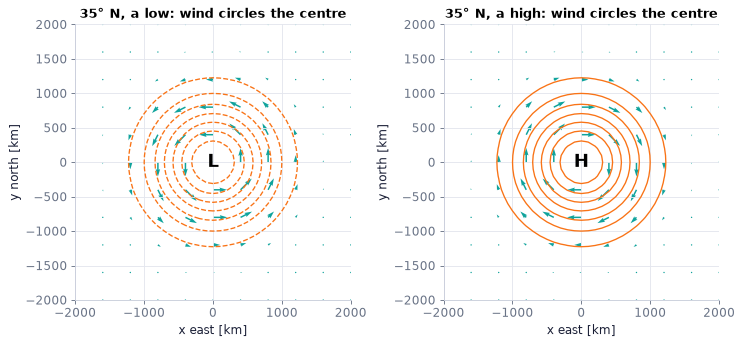

In [5]:
x = np.linspace(-2.0e6, 2.0e6, 41)                             # east-west distance from the centre [m]
y = np.linspace(-2.0e6, 2.0e6, 41)                             # north-south distance [m]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))   # a new figure and its panel(s); figsize in inches
for ax, kind in zip(axes, ("low", "high")):                    # one panel for a low, one for a high
    pc = ch13.pressure_centre(x, y, dp=400.0, R_c=6.0e5, lat_rad=lat, kind=kind)   # a 400 Pa = 4 hPa pressure anomaly (1 hPa = 100 Pa = 1 millibar) and its balanced wind at 35 N
    ax.contour(x/1e3, y/1e3, pc["p"]/100, 7, colors=COLORS["orange"], linewidths=1.2)   # isobars [hPa anomaly], orange = pressure
    ax.quiver(x[::4]/1e3, y[::4]/1e3, pc["u"][::4, ::4], pc["v"][::4, ::4], color=COLORS["teal"], scale=70)   # the wind, every fourth point (an arrow as long as the panel is wide would be 70 m/s)
    ax.text(0, 0, "L" if kind == "low" else "H", ha="center", va="center", fontsize=16, weight="bold")   # mark the centre
    ax.set(title=f"35° N, a {kind}: wind circles the centre", xlabel="x east [km]", ylabel="y north [km]", aspect="equal")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure

**What you see.** Isobars (orange; pressure in hectopascals, 1 hPa = 100 Pa) of a low and of a high at 35° N, and the wind (teal arrows) that balances each of them. The arrows circle the centres: counter-clockwise round the low, clockwise round the high (northern hemisphere, $f>0$; mirror for $f<0$).

**How to read it.** No arrow points at the low. Each one runs along an isobar, with low pressure on its left. Why that is the only steady possibility is the subject of `C02`.

**What would change if…** …the same two pressure patterns sat at 35° S? Both circulations would reverse (`C02` shows all four cases).

> 📎 **Primer — geographic vocabulary: zonal / meridional, easterly wind vs eastward current, poleward / equatorward, cyclonic / anticyclonic.** `P307` · Zonal = along a latitude circle (east–west); meridional = north–south. A wind is named by where it comes FROM (a westerly
blows toward the east); a current by where it goes TO (an eastward current). Poleward and equatorward avoid saying north or
south. Cyclonic = turning in the same sense as the earth below: counter-clockwise in the northern hemisphere, clockwise in the
southern.

In [6]:
print(ch13.wind_from_to(10.0, 0.0))        # u = +10 m/s: a 'westerly' wind, an 'eastward' current
print(GFD.hemisphere(np.deg2rad(-35.0)))   # 35 S: sign -1, turns 'left', cyclonic = 'clockwise'

{'wind_name': 'westerly', 'current_name': 'eastward', 'from_deg': 270.0, 'to_deg': 90.0}
{'sign': -1.0, 'name': 'southern', 'turns': 'left', 'cyclonic': 'clockwise'}


📝 **Note.** **N02 [B]** **Conventions in words.** Height $z$ is positive upward. Winds are named by origin, currents by destination. All the book's
figures are drawn for the northern hemisphere; the sign of every rotational effect follows the sign of $f$.

In [7]:
rows = [dict(latitude=f"{np.rad2deg(L):+.0f}°", **GFD.hemisphere(L)) for L in (lat, -lat)]   # 35 N and 35 S side by side
display(pd.DataFrame(rows).rename(columns={"sign": "sign of f", "name": "hemisphere", "turns": "moving fluid is turned to the", "cyclonic": "sense round a low"}))   # the two-row table

,latitude,sign of f,hemisphere,moving fluid is turned to the,sense round a low
0,+35°,1.0,northern,right,counter-clockwise
1,-35°,-1.0,southern,left,clockwise


**What does this show?** The same four facts for the two hemispheres: the sign of $f$, the side to which moving fluid is
deflected, and the sense of the circulation round a low. Everything "right-handed" at 35° N is "left-handed" at 35° S.

---

## 13.2 Vertical Variation of Density in the Atmosphere and Ocean

**What is this section about?** A reminder of static stability from Chapter 1, in the form this chapter needs: which density
gradient decides stability, how the lapse rate says the same thing in two sign conventions, and the buoyancy frequency $N(z)$
that later sets the speed of internal modes (`C08`), the frequency range of internal waves (`C14`) and the growth of storms
(`C16`).

> 🔁 **Recap — Static stability is decided by the potential density `R01`** (Ch. 1 §1.10, where the same statement is $\frac{d\rho_\theta}{dz}=\frac{d\rho}{dz}-\frac{d\rho_a}{dz}\cong\frac{d\rho}{dz}+\frac{\rho g}{c^2}$ (1.35)). A parcel moved up expands and its density falls even if nothing else changes. What decides whether it sinks back is the density
it would have at a common pressure — the potential density $\rho_\theta$:
$\dfrac{d\rho_\theta}{dz}=\dfrac{d\rho}{dz}+\dfrac{g\rho}{c^2}$ (13.1), where $c$ is the speed of sound ($c_s$ in our own
lines). Stable when $d\rho_\theta/dz<0$.

In [8]:
rho_w, c_sound, drho_dz = 1027.0, 1500.0, -5.24e-3             # sea-water density [kg/m^3], sound speed [m/s], in-situ gradient [kg/m^4] (our inputs)
adiab = STRAT.isentropic_density_gradient(rho_w, c_sound)      # adiabatic gradient -g rho / c^2: what compression alone does
pot = STRAT.ocean_potential_density_gradient(drho_dz, rho_w, c_sound)   # Eq. (13.1): potential-density gradient
print(f"adiabatic gradient  = {adiab:.3e} kg m^-4")            # the part due to compression
print(f"potential gradient  = {pot:.3e} kg m^-4  (negative -> stable)")   # the part that decides stability

adiabatic gradient  = -4.476e-03 kg m^-4
potential gradient  = -7.638e-04 kg m^-4  (negative -> stable)


**What does the code above do?**

1. `isentropic_density_gradient` returns $-g\rho/c_s^2$: how fast density rises with depth just because deeper water is squeezed.
2. `ocean_potential_density_gradient` adds $g\rho/c_s^2$ to the in-situ gradient, as $\frac{d\rho_\theta}{dz}=\frac{d\rho}{dz}+\frac{g\rho}{c^2}$ *(13.1)* says; a negative result means stable.

📝 **Note.** **N03 [B]** **Most of the increase of in-situ density with depth is compression.** The budget for our inputs is computed below: only a
small part of the measured gradient is real stratification. So $N^2$ must be built from the *potential* density — the in-situ
gradient would overstate it several-fold.

In [9]:
b = ch13.ocean_density_gradient_budget(drho_dz=-5.24e-3, rho=1027.0, c=1500.0)   # split the in-situ gradient into its two parts
print(f"in situ {b['in_situ']:.3e} = adiabatic {b['adiabatic']:.3e} + potential {b['potential']:.3e}  [kg m^-4]")   # the budget
print(f"compression share = {100*b['compression_share']:.1f} %;  in-situ / potential = {b['in_situ']/b['potential']:.1f}")   # how misleading the raw gradient is

in situ -5.240e-03 = adiabatic -4.476e-03 + potential -7.638e-04  [kg m^-4]
compression share = 85.4 %;  in-situ / potential = 6.9


**What does this show?** About 85 % of the in-situ gradient is compression; using it for $N^2$ would overstate the
stratification almost sevenfold (the printed ratio).

> 🔁 **Recap — The adiabatic gradient, in two sign conventions `R02`** (Ch. 1 §1.10 (C52–C55) and Ch. 12 (C14)). The adiabatic density gradient is $-g\rho/c^2$. For a gas the same idea is the adiabatic temperature gradient.
**Kundu:** $\Gamma\equiv dT/dz$, adiabatic value $\Gamma_a=-g/C_p\approx-9.8$ K/km, stable when $dT/dz>\Gamma_a$.
**Meteorology:** $\Gamma_{met}\equiv-dT/dz$, dry adiabatic value $\Gamma_d=+g/C_p\approx+9.8$ K/km, stable when
$\Gamma_{met}<\Gamma_d$. Same physics: negate the number, flip the inequality. This section of the book writes no symbol
$\Gamma$; it quotes rates of decrease in words, which are the meteorological magnitudes.

In [10]:
tab = ch13.lapse_rate_table(-6.5e-3, Gamma_a=Gamma_a)          # the standard troposphere, dT/dz = -6.5 K/km, in both conventions
display(tab)                                                   # two rows: Kundu and meteorology, same verdict

,symbol,value_K_per_km,adiabatic_K_per_km,criterion,verdict
Kundu,dT/dz,-6.5,-9.760745,dT/dz = −6.5 > −9.8 K/km,stable
meteorology,Γ_met = −dT/dz,6.5,9.760745,Γ_met = 6.5 < Γ_d = 9.8 K/km,stable


**What does this show?** One atmosphere, two rows. Kundu's row compares $dT/dz=-6.5$ with $\Gamma_a=-9.8$ K/km (stable
because $-6.5>-9.8$); the meteorological row compares $\Gamma_{met}=6.5$ with $\Gamma_d=9.8$ K/km (stable because $6.5<9.8$).
The number is negated and the inequality flipped; the verdict is the same.

> ⚠️ **Common confusion (trap T2, the library string):** The Chapter 1 function `STRAT.lapse_rate_stability(..., convention='meteorology').text` prints "Γ < Γa". Read it as
$\Gamma_{met}<\Gamma_d$: in that convention the library's Γa is the positive number +9.8 K/km. We do not show that raw string
again; every label below is built by this notebook and carries both forms.

#### ✏️ Tiny example: is a −8 K/km layer stable?

1. **Kundu:** $dT/dz=-8$ K/km; is $-8>-9.8$? Yes → stable.
2. **Meteorology:** negate the number, $\Gamma_{met}=+8$ K/km; flip the inequality: is $8<9.8$? Yes → stable.
3. **Margin:** 1.8 K/km in both.
4. **A −11 K/km layer:** $-11>-9.8$ is false; $11<9.8$ is false → unstable in both.

📝 **Note.** **N04 [B]** **The standard atmosphere** (our version of the book's temperature sketch, from the 1976 standard atmosphere): the
*troposphere*, where temperature falls with height, ends at the *tropopause*; above it the *stratosphere* is first isothermal
and then warms up to the *stratopause*. The right panel is the buoyancy frequency squared, $N^2$.

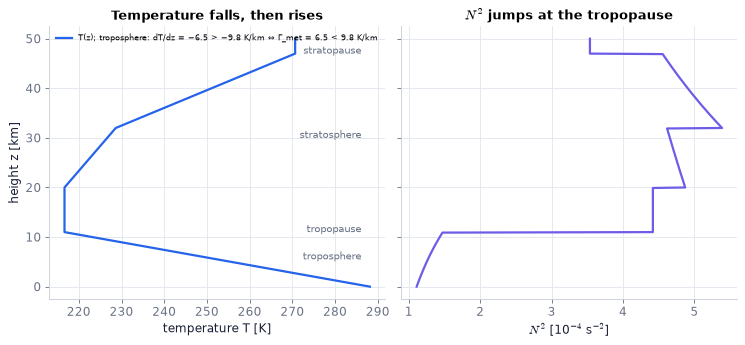

ground: N^2 = 1.110e-04 1/s^2, N = 1.053e-02 1/s, period 2 pi/N = 9.9 min
20 km (lower stratosphere): N^2 = 4.871e-04 1/s^2 = 4.4 x the ground value


In [11]:
z_atm = np.linspace(0.0, 5.0e4, 501)                           # height from the ground to 50 km [m]
atm = ch13.atmosphere_layers(z_atm)                            # temperature T [K], dT/dz [K/m] (Kundu sign), N^2 [1/s^2], layer names
fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 4.2), sharey=True)   # a new figure and its panel(s); figsize in inches
a.plot(atm["T"], z_atm/1e3, color=COLORS["blue"], label="T(z); troposphere: dT/dz = −6.5 > −9.8 K/km ⇔ Γ_met = 6.5 < 9.8 K/km")   # temperature profile, both conventions in the label
for name, zc in (("troposphere", 5.5), ("tropopause", 11.0), ("stratosphere", 30.0), ("stratopause", 47.0)):   # name the layers
    a.text(atm["T"].max() - 2, zc, name, ha="right", fontsize=9, color=COLORS["muted"])   # label at its height
a.set(xlabel="temperature T [K]", ylabel="height z [km]", title="Temperature falls, then rises")   # axis labels (with units), title and fixed ranges of this panel
a.legend(fontsize=7, loc="upper center")   # the legend names every curve
b.plot(atm["N2"]*1e4, z_atm/1e3, color=COLORS["accent"])       # N^2 in units of 1e-4 1/s^2
b.set(xlabel="$N^2$ [10$^{-4}$ s$^{-2}$]", title="$N^2$ jumps at the tropopause")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure
N2_ground = atm["N2"][0]                                       # N^2 at the ground [1/s^2]
i20 = np.argmin(abs(z_atm - 2.0e4))                            # index of the level z = 20 km
print(f"ground: N^2 = {N2_ground:.3e} 1/s^2, N = {np.sqrt(N2_ground):.3e} 1/s, period 2 pi/N = {2*np.pi/np.sqrt(N2_ground)/60:.1f} min")   # tropospheric values
print(f"20 km (lower stratosphere): N^2 = {atm['N2'][i20]:.3e} 1/s^2 = {atm['N2'][i20]/N2_ground:.1f} x the ground value")   # the jump

**What you see.** Left: temperature against height, falling at 6.5 K/km through the troposphere, constant in the lower stratosphere, rising above. Right: $N^2$, a few times larger in the stratosphere than in the troposphere.

**How to read it.** The troposphere is stable in both conventions — $dT/dz=-6.5>-9.8$ K/km, i.e. $\Gamma_{met}=6.5<9.8$ K/km — and $N^2$ jumps at the tropopause: the stratosphere acts as a lid on the weather layer. The printed lines give the numbers.

**What would change if…** …the troposphere followed the dry adiabat exactly? Then $N^2=0$ there, parcels would feel no restoring force, and the storm growth rate of `C16` (which is proportional to $1/N$) would be unbounded.

📝 **Note.** **N05 [B]** ⚠️ **Common confusion (trap T2).** "The troposphere is close to neutral" compares the observed lapse rate with the **moist**
adiabat (named only: saturated air cools more slowly as it rises, because condensation releases heat). To *dry* displacements
the standard troposphere is statically stable in both conventions: $\Gamma_a<dT/dz<0$ (Kundu), i.e.
$0<\Gamma_{met}<\Gamma_d$ (meteorology); $N^2>0$. The gradient Richardson number of Chapter 12, $N^2$ divided by the squared
shear, says the same for a typical shear:

In [12]:
ri = ch12.gradient_richardson_thermal(-6.5e-3, 3.0e-3, 1/288.15, Gamma_a=Gamma_a)   # dT/dz = -6.5 K/km, shear 3 m/s per km, alpha = 1/T
badge = f"stable · dT/dz = −6.5 > −{-Gamma_a*1e3:.1f} K/km · Γ_met = 6.5 < {-Gamma_a*1e3:.1f} K/km"   # OUR label, both conventions
print(f"Ri = N^2/(dU/dz)^2 = {ri['Ri']:.1f}   ->  {badge}")    # far above the critical value 1/4 of Ch. 11

Ri = N^2/(dU/dz)^2 = 12.3   ->  stable · dT/dz = −6.5 > −9.8 K/km · Γ_met = 6.5 < 9.8 K/km


**What does this show?** With a shear of 3 m/s per kilometre the Richardson number is about 12 — some fifty times the
critical value ¼ of Chapter 11. The label is built here so that it carries both sign conventions.

#### 🎚️ The same verdict in two conventions

Drag the environmental temperature gradient. A parcel is displaced by $\zeta$ metres and the figure shows the buoyancy
acceleration it then feels, $-N^2\zeta$, with $N^2=\frac{g}{T}\big(\frac{dT}{dz}-\Gamma_a\big)$.

In [13]:
zeta_ax = np.linspace(-200.0, 200.0, 9)                        # vertical displacement of the parcel [m]
nan_ax = np.full_like(zeta_ax, np.nan)                         # an empty curve (hides a trace)

def f2(dTdz_km):                                               # curves for one environmental gradient dT/dz [K/km] (Kundu sign)
    N2 = STRAT.brunt_vaisala_sq_from_lapse(288.15, dTdz_km*1e-3)   # N^2 = (g/T)(dT/dz - Gamma_a) [1/s^2]
    acc = -N2*zeta_ax                                          # buoyancy acceleration of the displaced parcel [m/s^2]
    return {"stable: dT/dz > Γa = −9.8 K/km ⇔ Γ_met < Γd = +9.8 K/km (pushed back)": (zeta_ax, acc if N2 > 0 else nan_ax),   # hand the result back to the caller
            "unstable: dT/dz < Γa = −9.8 K/km ⇔ Γ_met > Γd = +9.8 K/km (pushed further)": (zeta_ax, acc if N2 < 0 else nan_ax),
            "neutral reference: dT/dz = Γa ⇔ Γ_met = Γd (no force)": (zeta_ax, 0*zeta_ax)}

figF2 = slider_figure(f2, "dT/dz (Kundu; Γ_met is minus this)", np.arange(-12.0, 2.01, 0.5), unit="K/km",
                      xlabel="displacement ζ of the parcel [m]", ylabel="buoyancy acceleration −N²ζ [m/s²]",
                      title="The verdict flips at the adiabatic value, whichever sign you write it with")   # 29 slider positions
figF2.show()   # display the interactive figure (the slider works on the web page too)
for g_km in (-6.5, -9.76, -11.0):                              # three sample gradients [K/km]
    t2 = ch13.lapse_rate_table(g_km*1e-3, Gamma_a=Gamma_a)     # both conventions for this gradient
    print(f"dT/dz = {g_km:+.2f} K/km:  {t2.loc['Kundu', 'criterion']}  ⇔  {t2.loc['meteorology', 'criterion']}  →  {t2.loc['Kundu', 'verdict']}")   # one line each

dT/dz = -6.50 K/km:  dT/dz = −6.5 > −9.8 K/km  ⇔  Γ_met = 6.5 < Γ_d = 9.8 K/km  →  stable
dT/dz = -9.76 K/km:  dT/dz = −9.760 > −9.761 K/km  ⇔  Γ_met = 9.760 < Γ_d = 9.761 K/km  →  stable
dT/dz = -11.00 K/km:  dT/dz = −11.0 < −9.8 K/km  ⇔  Γ_met = 11.0 > Γ_d = 9.8 K/km  →  unstable


**What does the code above do?**

1. `f2` computes $N^2$ for one gradient and returns the acceleration $-N^2\zeta$ on the *stable* trace or on the *unstable*
   one (the other is left empty), so the legend always names the regime in **both** conventions.
2. The three printed lines are `ch13.lapse_rate_table` at a stable, a neutral and an unstable gradient.

**What you see.** A straight line through the origin whose slope is $-N^2$. For gradients to the right of −9.8 K/km on the slider the slope is negative (a displaced parcel is pushed back); to the left it is positive (pushed further).

**How to read it.** The verdict flips where the line passes through the horizontal — at the adiabatic value, $dT/dz=\Gamma_a=-9.8$ K/km in Kundu's sign, $\Gamma_{met}=\Gamma_d=+9.8$ K/km in the meteorological one. The slider shows Kundu's number; the meteorological number is its negative.

**What would change if…** …the air were an inversion, $dT/dz=+2$ K/km ($\Gamma_{met}=-2$ K/km)? The line is at its steepest: the strongest restoring force on the slider, and the largest $N^2$.

📝 **Note.** **N06 [B]** **The ocean** (our idealised version of the book's sketch; `ch13.ocean_profile_idealized`): a warm *mixed layer* stirred by the
wind, the *thermocline* where temperature falls quickly, and the cold, nearly uniform *abyss*. Salinity is secondary and left
out of our profile. The same shape of $N(z)$ feeds `C08`.

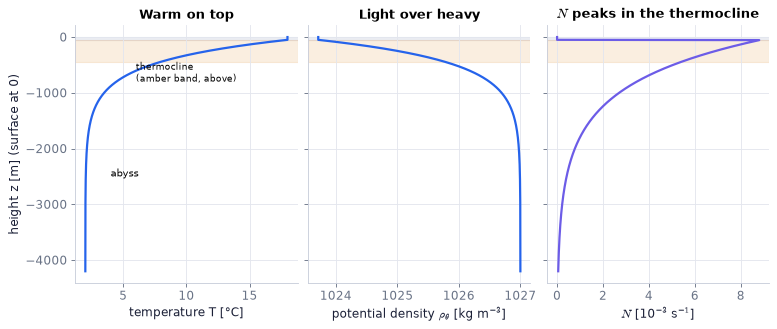

In [14]:
z_oc = np.linspace(-4200.0, 0.0, 841)                          # depth from the bottom (-4200 m) to the surface [m]
prof = ch13.ocean_profile_idealized(z_oc)                      # T [deg C], potential density [kg/m^3], N^2 and N (analytic)
fig, axes = plt.subplots(1, 3, figsize=(9.6, 4.0), sharey=True)   # a new figure and its panel(s); figsize in inches
axes[0].plot(prof["T"], z_oc, color=COLORS["blue"])            # temperature profile
axes[0].set(xlabel="temperature T [°C]", ylabel="height z [m] (surface at 0)", title="Warm on top")   # axis labels (with units), title and fixed ranges of this panel
axes[1].plot(prof["rho_theta"], z_oc, color=COLORS["blue"])    # potential density profile
axes[1].set(xlabel=r"potential density $\rho_\theta$ [kg m$^{-3}$]", title="Light over heavy")   # axis labels (with units), title and fixed ranges of this panel
axes[2].plot(prof["N"]*1e3, z_oc, color=COLORS["accent"])      # buoyancy frequency in units of 1e-3 1/s
axes[2].set(xlabel="$N$ [10$^{-3}$ s$^{-1}$]", title="$N$ peaks in the thermocline")   # axis labels (with units), title and fixed ranges of this panel
for ax in axes:                                                # name the three layers in every panel
    ax.axhspan(-50, 0, color=COLORS["grid"], alpha=0.7)        # the mixed layer (top 50 m)
    ax.axhspan(-450, -50, color=COLORS["amber"], alpha=0.12)   # the thermocline
axes[0].text(6, -800, "thermocline\n(amber band, above)", fontsize=8)   # label, placed below the band so that it can be read
axes[0].text(4, -2500, "abyss", fontsize=9)                    # label
plt.show()   # display the figure

**What you see.** Temperature, potential density and buoyancy frequency against depth. The change is fastest just under the thin mixed layer and fades with depth; the amber band marks the upper 450 m, and below about 1500 m the ocean is cold and nearly uniform.

**How to read it.** The buoyancy frequency follows the slope of the density curve: zero in the mixed layer (the thin band at the very top), largest at the top of the thermocline just beneath it, and decaying smoothly into the abyss.

**What would change if…** …the thermocline were deeper? The peak of $N$ moves down, and the first internal mode of `C08` travels faster.

> 🔁 **Recap — The buoyancy frequency `R03`** (Ch. 1, $N^2=-\frac g\rho\big(\frac{d\rho}{dz}-\frac{d\rho_a}{dz}\big)$ (1.29); Ch. 7, $N^2\equiv-\frac g{\rho_0}\frac{d\bar\rho}{dz}$ (7.127)). Its definition is $N^2\equiv-\dfrac{g}{\rho_0}\dfrac{d\rho}{dz}$ with $\rho$ the **potential** density and $\rho_0$ a constant reference value:
the squared frequency at which a displaced parcel bobs. Where it enters this chapter: `C08` (mode speeds
$c_n\approx NH/n\pi$), `C14` (internal waves need $\omega<N$), `C16` (the Eady radius $NH/f$ and the growth rate).

In [15]:
N2_num = GFD.buoyancy_frequency_sq(z_oc, prof["rho_theta"], 1027.0)   # N^2 = -(g/rho0) d(rho_theta)/dz by finite differences
inner = (z_oc < -60.0) & (z_oc > -4190.0)                      # below the base of the mixed layer (a kink at -50 m) and off the bottom
assert np.allclose(N2_num[inner], prof["N2"][inner], rtol=2e-2, atol=1e-12)   # the numerical derivative matches the analytic profile
print(f"✓ N^2 from differences and the analytic N^2 agree to 2 % (largest N^2 = {prof['N2'].max():.2e} 1/s^2)")   # visible confirmation

✓ N^2 from differences and the analytic N^2 agree to 2 % (largest N^2 = 7.75e-05 1/s^2)


**What does this show?** Differentiating the potential-density profile numerically reproduces the profile's own analytic
$N^2$: the function does exactly what the definition says.

📝 **Note.** **N07 [C]** **The fastest bobbing in our thermocline.** The largest $N$ of the profile gives the shortest buoyancy period, computed below.
It is the upper frequency limit of the internal waves of `C14` and the profile maximum of `C08`.

In [16]:
N_max = np.sqrt(prof["N2"].max())                              # largest buoyancy frequency of the profile [1/s]
print(f"N_max = {N_max:.2e} 1/s  ->  buoyancy period 2 pi/N = {STRAT.stability_timescale(prof['N2'].max())[1]/60:.0f} min")   # the shortest period

N_max = 8.80e-03 1/s  ->  buoyancy period 2 pi/N = 12 min


**What does this show?** A parcel in the sharpest part of our thermocline bobs with a period of some tens of minutes; nothing
internal can oscillate faster.

---

## 13.3 Equations of Motion

**What is this section about?** The starting equations — Chapter 4's Boussinesq set written in a rotating frame — and the one
new modelling choice: friction by eddies, with a large horizontal and a small vertical eddy viscosity.

> 🔁 **Recap — The rotating Boussinesq equations `R04`** (Ch. 4: the rotating-frame equation $\rho\big(\frac{D'\mathbf u'}{Dt}\big)_{O'1'2'3'}=-\nabla'p+\rho\big[\mathbf g-\frac{d\mathbf U}{dt}-2\boldsymbol\Omega\times\mathbf u'-\frac{d\boldsymbol\Omega}{dt}\times\mathbf x'-\boldsymbol\Omega\times(\boldsymbol\Omega\times\mathbf x')\big]+\mu\nabla'^2\mathbf u'$ (4.45) and the Boussinesq momentum equation $\frac{D\mathbf u}{Dt}=-\frac1{\rho_0}\nabla p'+\frac{\rho'}{\rho_0}\mathbf g+\nu\nabla^2\mathbf u$ (4.86)). Continuity $\nabla\cdot\mathbf u=0$; momentum
$\dfrac{D\mathbf u}{Dt}+2\boldsymbol\Omega\times\mathbf u=-\dfrac1{\rho_0}\nabla p-\dfrac{g\rho}{\rho_0}\mathbf e_z+\mathbf F$;
density $\dfrac{D\rho}{Dt}=0$ (13.2). Term by term (momentum equation): acceleration seen from the turning earth, the Coriolis
acceleration, the pressure-gradient force, weight, friction per unit mass.

> ⚠️ **slip #1 — the book prints** the pressure term of the momentum equation as $+\frac1{\rho_0}\nabla p$ **; the correct form is** $-\frac1{\rho_0}\nabla p$ (a fluid at rest must satisfy $0=-\nabla p-g\rho\,\mathbf e_z$).

In [17]:
ok_corr = ch13.boussinesq_rotating_sympy()                     # the corrected momentum equation, tested on the state of rest
ok_prnt = ch13.boussinesq_rotating_sympy(printed=True)         # the same test with the sign as printed
print("corrected sign: rest state satisfies it ->", ok_corr["ok"])                 # True
print("printed sign:   rest state satisfies it ->", ok_prnt["ok"], "| left over:", ok_prnt["residual"])   # False, with a residual

corrected sign: rest state satisfies it -> True
printed sign:   rest state satisfies it -> False | left over: -2*g*rhobar(z)/rho_0


**What does this show?** A fluid at rest in hydrostatic balance satisfies the corrected equation exactly. With the printed
sign a term twice the weight is left over — the printed form cannot even describe a motionless ocean.

> 🔁 **Recap — When Boussinesq holds `R05`** (Ch. 4 §4.9). The layer must be thin against the scale height $c^2/g$ (written $c_s^2/g$ in our lines), the height over which density
changes by its own size through compression.

In [18]:
print(f"scale height, sea water (c_s = 1500 m/s): {GFD.scale_height(1500.0)/1e3:.0f} km")   # far deeper than any ocean
print(f"scale height, air       (c_s =  340 m/s): {GFD.scale_height(340.0)/1e3:.1f} km")    # comparable with the troposphere

scale height, sea water (c_s = 1500 m/s): 229 km
scale height, air       (c_s =  340 m/s): 11.8 km


**What does this show?** The condition holds for any ocean depth, but only roughly for the troposphere — which is why
meteorology often uses pressure as the vertical coordinate (not in the book).

> 🔁 **Recap — Density is carried with the fluid `R06`** (Ch. 4, the Boussinesq heat equation $DT/Dt=\kappa\nabla^2T$ (4.89) with its diffusion term dropped; Ch. 1 linear equation of state). The statement $D\rho/Dt=0$ follows from $DT/Dt=0$ (or $DS/Dt=0$) and a linear equation of state, $\delta\rho/\rho_0=-\alpha\,\delta T$ and
$\delta\rho/\rho_0=\beta_S\,\delta S$. ⚠️ The book writes the haline coefficient as $\beta$; from §13.4 on $\beta$ is $df/dy$,
so we write $\beta_S$ here. The expansion coefficient $\alpha$ comes back in `C03`.

> 🔁 **Recap — The state of rest `R07`** (Ch. 1, $dp/dz=-\rho g$ (1.8)). It obeys $\dfrac{d\bar p}{dz}=-\bar\rho g$ (13.3): the hydrostatic balance of the motionless reference state.

> 🔁 **Recap — Rest state plus perturbation `R08`** (Ch. 4, where $p'=p-p_s$, $\rho'=\rho-\rho_s$ give $\rho\frac{D\mathbf u}{Dt}=-\nabla p'+\rho'\mathbf g+\mu\nabla^2\mathbf u$ (4.84); Ch. 7, $\rho=\bar\rho(z)+\rho'$ (7.124)). Write $\rho(\mathbf x,t)=\bar\rho(z)+\rho'(\mathbf x,t)$ and $p(\mathbf x,t)=\bar p(z)+p'(\mathbf x,t)$ (13.4).
⚠️ **Trap T3:** from the thin-shell equations of `C01` on, the book drops the primes: $p$ and $\rho$ there are *perturbations*.

> 🔁 **Recap — The pressure and gravity terms keep their form `R09`** (Ch. 4, derivation D27). Subtract the rest state: $-\dfrac1{\rho_0}\nabla p-\dfrac{g\rho}{\rho_0}\mathbf e_z=-\dfrac1{\rho_0}\nabla p'-\dfrac{g\rho'}{\rho_0}\mathbf e_z$,
because $\nabla\bar p=(d\bar p/dz)\,\mathbf e_z=-\bar\rho g\,\mathbf e_z$ cancels the weight of the rest state.

In [19]:
print("perturbation form of pressure + gravity terms holds ->", ch13.perturbation_form_sympy()["ok"])   # the engine agrees: True

perturbation form of pressure + gravity terms holds -> True


**What does this show?** A sympy engine subtracts the rest state symbolically and finds nothing left over.

> 🔁 **Recap — Friction per unit mass, and the eddy-viscosity idea `R10`** (Ch. 4 §4.4 and Ch. 12, the eddy-viscosity hypothesis $\overline{u_iu_j}=\frac23\bar e\delta_{ij}-\nu_T\big(\frac{\partial U_i}{\partial x_j}+\frac{\partial U_j}{\partial x_i}\big)$ (12.94)). The friction force per unit mass is the divergence of the stress divided by density,
$F_i=\dfrac1\rho\dfrac{\partial\tau_{ij}}{\partial x_j}$. For large-scale flow the stress is carried by turbulent eddies and is
modelled as an eddy viscosity times a velocity gradient.

> ⚠️ **slip #2 — the book prints** $F_i=\partial\tau_{ij}/\partial x_j$ for a force per unit mass **; the correct form is** $F_i=\frac1\rho\,\partial\tau_{ij}/\partial x_j$ (N/m³ divided by kg/m³ gives m/s²).

📝 **Note.** **N08 [B]** **The six eddy stresses:**
$\tau_{xz}=\tau_{zx}=\rho\nu_v\frac{\partial u}{\partial z}+\rho\nu_H\frac{\partial w}{\partial x}$,
$\tau_{yz}=\tau_{zy}=\rho\nu_v\frac{\partial v}{\partial z}+\rho\nu_H\frac{\partial w}{\partial y}$,
$\tau_{xy}=\tau_{yx}=\rho\nu_H\big(\frac{\partial u}{\partial y}+\frac{\partial v}{\partial x}\big)$,
$\tau_{xx}=2\rho\nu_H\frac{\partial u}{\partial x}$, $\tau_{yy}=2\rho\nu_H\frac{\partial v}{\partial y}$,
$\tau_{zz}=2\rho\nu_v\frac{\partial w}{\partial z}$ (13.5). Two coefficients because the eddies are wide and flat: horizontal exchange
is strong, vertical exchange weak, $\nu_H\gg\nu_v$.

In [20]:
rng = np.random.default_rng(13)                                # a fixed random seed, so the numbers repeat
Gm = rng.normal(size=(3, 3))                                   # a velocity-gradient matrix G[i, j] = d u_i / d x_j [1/s]
Gm -= np.trace(Gm)/3*np.eye(3)                                 # make it divergence-free (incompressible)
tau_iso = ch13.anisotropic_eddy_stress(Gm, 5.0, 5.0, 1027.0)   # Eq. (13.5) with nu_H = nu_v = 5 m^2/s
S = 0.5*(Gm + Gm.T)                                            # strain-rate tensor S_ij of Ch. 4
assert np.allclose(tau_iso, 2*1027.0*5.0*S)                    # equal coefficients -> the Newtonian form 2 rho nu S_ij
print("✓ with nu_H = nu_v the eddy stress equals 2 rho nu S_ij (max difference", f"{abs(tau_iso - 2*1027.0*5.0*S).max():.1e} Pa)")   # visible check

✓ with nu_H = nu_v the eddy stress equals 2 rho nu S_ij (max difference 0.0e+00 Pa)


**What does this show?** With the two coefficients equal, the six stresses collapse to the Newtonian stress
$2\rho\nu S_{ij}$ of Chapter 4. The anisotropy is the only new ingredient.

📝 **Note.** **N09 [C]** **A defect the book accepts.** This stress is not frame-indifferent: a rigid rotation in a vertical plane, $u=\omega_rz$,
$w=-\omega_rx$, has no deformation at all, yet it gives $\tau_{xz}=\rho\,\omega_r(\nu_v-\nu_H)\neq0$ (the cell below). The
book accepts the defect for simplicity; so do we. Pointer: Ch. 4 §4.5.

In [21]:
G_rot = np.zeros((3, 3)); G_rot[0, 2], G_rot[2, 0] = 1.0, -1.0 # rigid rotation at 1 rad/s: du/dz = +1, dw/dx = -1, no strain
tau_rot = ch13.anisotropic_eddy_stress(G_rot, 300.0, 0.03, 1027.0)   # nu_H = 300, nu_v = 0.03 m^2/s (our illustrative values)
print(f"tau_xz for a rigid rotation = {tau_rot[0, 2]:.3e} Pa  (rho*(nu_v - nu_H) = {1027.0*(0.03 - 300.0):.3e})")   # non-zero: the defect

tau_xz for a rigid rotation = -3.081e+05 Pa  (rho*(nu_v - nu_H) = -3.081e+05)


**What does this show?** A motion without any deformation produces a stress — impossible for a true material law, and
harmless here because large-scale flows never rotate rigidly in a vertical plane.

📝 **Note.** **N10 [B]** **The friction force** per unit mass, component by component:
$F_x=\nu_H\big(\frac{\partial^2u}{\partial x^2}+\frac{\partial^2u}{\partial y^2}\big)+\nu_v\frac{\partial^2u}{\partial z^2}$,
$F_y=\nu_H\big(\frac{\partial^2v}{\partial x^2}+\frac{\partial^2v}{\partial y^2}\big)+\nu_v\frac{\partial^2v}{\partial z^2}$,
$F_z=\nu_H\big(\frac{\partial^2w}{\partial x^2}+\frac{\partial^2w}{\partial y^2}\big)+\nu_v\frac{\partial^2w}{\partial z^2}$ (13.6).
The book states this without the steps. The six differentiations and the use of continuity are written out as derivation
`D01` inside the `C01` block below.

In [22]:
Fx = GFD.eddy_friction(lap_h=-1.0e-11, d2z=-2.0e-6, nu_H=3.0e4, nu_v=7.0)   # one component: nu_H * (horizontal Laplacian) + nu_v * (d2/dz2)
print(f"F_x = {Fx:.2e} m/s^2  (horizontal part {3.0e4*-1.0e-11:.1e}, vertical part {7.0*-2.0e-6:.1e})")   # the vertical part dominates

F_x = -1.43e-05 m/s^2  (horizontal part -3.0e-07, vertical part -1.4e-05)


**What does this show?** For a wind that varies over 1000 km horizontally and 1 km vertically, the vertical mixing term is the
larger one even though $\nu_v\ll\nu_H$ — because the vertical scale is so much shorter.

📝 **Note.** **N11 [C]** **How big are the eddy coefficients?** A small table of **our own illustrative** values (not the book's) against molecular
ones. They are used where $\nu_v$ sets the Ekman thickness (`C04`, `C06`).

| Fluid | $\nu_v$ (eddy, illustrative) [m² s⁻¹] | $\nu_H$ (eddy, illustrative) [m² s⁻¹] | molecular $\nu$ [m² s⁻¹] |
|---|---|---|---|
| lower atmosphere | 7 | 3 × 10⁴ | 1.5 × 10⁻⁵ |
| upper ocean | 0.03 | 300 | 1.0 × 10⁻⁶ |

---

## 13.4 Approximate Equations for a Thin Layer on a Rotating Sphere

**What is this section about?** Standing at one latitude, we replace the sphere by its tangent plane and ask which parts of the
earth's rotation a thin layer of fluid can feel. The answer is one number per latitude, $f$, and a set of equations that every
later section simplifies further.

### 🧩 The equations of motion on a thin rotating shell: $\dfrac{Du}{Dt}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}+F_x$, $\dfrac{Dv}{Dt}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}+F_y$, $\dfrac{Dw}{Dt}=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial z}-\dfrac{g\rho}{\rho_0}+F_z$ (13.9) — $(F_x,F_y,F_z)$ being the eddy friction of note N10 — with $f=2\Omega\sin\theta$ (13.8) `C01`

*The question:* Which part of the earth's rotation does a thin layer of air or water actually feel?

#### The problem in plain words

The atmosphere is about 10 km deep and its weather systems are 1000 km and more across: a sheet thinner, in proportion, than the
paper of a wall map. In such a sheet the fluid can hardly move up or down. Of the earth's spin, the part that matters is the
part about the *local vertical* — a turntable under your feet that turns once a day at the pole and not at all on the equator.
Climate models call dropping the rest the "traditional approximation"; every dynamical core makes it.

#### The idea

```
         Ω (earth's axis)
         ↑        at latitude θ the axis is tilted θ above the northward horizontal
  Ω sin θ ↑  ↗ Ω
(vertical)| /
          |/____→  Ω cos θ  (northward, horizontal)

Ω sin θ : spins the ground under you            → turns horizontal motion
Ω cos θ : tips the ground about a north–south line → only couples to vertical motion
```

| Place | Vertical part $\Omega\sin\theta$ | Horizontal part $\Omega\cos\theta$ | Coriolis parameter |
|---|---|---|---|
| pole ($\theta=90°$) | all of it | none | $f=2\Omega$ |
| equator ($\theta=0$) | none | all of it | $f=0$ |

> 🔁 **Recap — How fast the earth turns `R11`** (Ch. 4 §4.7). One turn against the stars takes 86 164 s (a sidereal day), so $\Omega=2\pi/86\,164\ \mathrm{s}=7.292\times10^{-5}$ rad/s
(`ROT.OMEGA_EARTH`). ⚠️ **Trap T1:** the book takes $\Omega=2\pi$ rad/day with a 24-hour solar day, 0.27 % smaller. Every
number of ours uses the sidereal value.

> 📎 **Primer — sidereal day vs solar day.** `P308` · In one year the earth turns 366.25 times against the stars but the sun crosses the sky only 365.25 times, because one turn is
used up going round the sun. So one true rotation takes 24 h × 365.25/366.25 = 23 h 56 min 4 s. Dynamics cares about the true
rotation.

In [23]:
T_sid = 86400.0 * 365.25 / 366.25                # one rotation against the stars [s]
print(T_sid, 2*np.pi/T_sid)                      # 86164.1 s and 7.2921e-05 rad/s
print(GFD.OMEGA_EARTH / (2*np.pi/86400.0) - 1)   # 0.00274: the solar-day value is 0.27 % smaller

86164.09556313993 7.292115429419613e-05
0.0027377917376967265


📝 **Note.** **N13 [B]** **The rotation vector on the tangent plane.** With $x$ east, $y$ north and $z$ up at latitude $\theta$,
$\boldsymbol\Omega=(0,\ \Omega\cos\theta,\ \Omega\sin\theta)$: no eastward part, a northward horizontal part and a vertical
part. The figure lets you move the tangent plane to four latitudes.

In [24]:
uu, vv = np.meshgrid(np.linspace(0, 2*np.pi, 40), np.linspace(-np.pi/2, np.pi/2, 20))   # longitude and latitude grids for a unit sphere
figS = go.Figure(go.Surface(x=np.cos(vv)*np.cos(uu), y=np.cos(vv)*np.sin(uu), z=np.sin(vv), opacity=0.25, showscale=False,
                            colorscale=[[0, COLORS["grid"]], [1, COLORS["grid"]]], hoverinfo="skip"))   # the earth, pale grey
figS.add_trace(go.Scatter3d(x=[0, 0], y=[0, 0], z=[-1.4, 1.4], mode="lines", line=dict(color=COLORS["ink"], width=5), name="rotation axis"))   # the axis
lats_deg = [0.0, 35.0, 60.0, 90.0]                              # the four dropdown latitudes
for j, ld in enumerate(lats_deg):                               # three arrows per latitude
    th = np.deg2rad(ld)                                         # latitude in radians
    comp = GFD.earth_rotation_local(th)/GFD.OMEGA_EARTH         # (0, cos(theta), sin(theta)): local components of Omega, in units of Omega
    P0 = np.array([np.cos(th), 0.0, np.sin(th)])                # the point on the sphere (longitude 0)
    up = P0                                                     # local vertical unit vector
    north = np.array([-np.sin(th), 0.0, np.cos(th)])            # local northward unit vector
    for vec, col, nm in ((comp[2]*up, COLORS["teal"], f"vertical part Ω sin θ = {comp[2]:.2f} Ω (= f/2)"),
                         (comp[1]*north, COLORS["orange"], f"northward part Ω cos θ = {comp[1]:.2f} Ω"),
                         (comp[1]*north + comp[2]*up, COLORS["accent"], "Ω itself (parallel to the axis)")):
        Q = P0 + 0.6*vec                                        # tip of the arrow (scaled to fit the picture)
        figS.add_trace(go.Scatter3d(x=[P0[0], Q[0]], y=[P0[1], Q[1]], z=[P0[2], Q[2]], mode="lines+markers", name=nm,
                                    marker=dict(size=[0, 5], color=col), line=dict(color=col, width=7), visible=(j == 1)))   # one arrow
buttons = [dict(label=f"latitude {ld:.0f}°", method="update",
                args=[{"visible": [True, True] + [k//3 == j for k in range(3*len(lats_deg))]}]) for j, ld in enumerate(lats_deg)]   # show one latitude's arrows
figS.update_layout(height=520, title="The local vertical part of the earth's spin shrinks toward the equator",
                   updatemenus=[dict(buttons=buttons, active=1, x=0.0, y=1.08, xanchor="left")],
                   scene=dict(aspectmode="data", xaxis_visible=False, yaxis_visible=False, zaxis_visible=False), margin=dict(l=0, r=0, t=60, b=0))   # layout and dropdown
figS.show()   # display the interactive figure (the slider works on the web page too)

**What does the code above do?**

1. The pale sphere and the black axis are drawn once.
2. For each of four latitudes, `GFD.earth_rotation_local` gives the components $(0,\Omega\cos\theta,\Omega\sin\theta)$; three
   arrows are drawn at the point: the vertical part (teal), the northward part (orange) and their sum (purple), which is
   parallel to the axis.
3. The dropdown only switches which three arrows are visible.

**What you see.** A point on the globe with three arrows: the earth's rotation vector (purple, always parallel to the axis) and its two local parts — along the local vertical (teal) and toward the north (orange).

**How to read it.** The teal arrow is $f/2$. At 35° it is 57 % of $\Omega$; at the pole it is all of $\Omega$; on the equator it vanishes and the whole rotation is 'horizontal'.

**What would change if…** …you stood at 35° S? The teal arrow would point *into* the ground: $f<0$, and everything that turns right in the north turns left.

📝 **Note.** **N12 [B]** **How small is the vertical velocity?** Continuity $\partial u/\partial x+\partial v/\partial y+\partial w/\partial z=0$ with
horizontal scale $L$, depth $H$ and velocity scales $U$, $W$ gives $U/L\sim W/H$, so $W/U\sim H/L$: the aspect ratio. It is
used in step 3 of `D02`.

In [25]:
W = GFD.vertical_velocity_scale(14.0, 9000.0, 1.4e6)           # W = U H / L for U = 14 m/s, H = 9 km, L = 1400 km [m/s]
print(f"W = {W:.3f} m/s,  aspect ratio H/L = {9000.0/1.4e6:.1e}")   # centimetres per second against metres per second

W = 0.090 m/s,  aspect ratio H/L = 6.4e-03


**What does this show?** A 14 m/s wind in a weather system comes with vertical motion of only about 9 cm/s: the flow is
almost horizontal.

#### 🧮 Derivation — The friction force from the anisotropic eddy stress `D01` ★★ (Eq. 13.6: $F_x=\nu_H\Big(\frac{\partial^2u}{\partial x^2}+\frac{\partial^2u}{\partial y^2}\Big)+\nu_v\frac{\partial^2u}{\partial z^2},\ \dots$)

**What we want to show.** Turn the six eddy stresses into a friction force that can stand in the momentum equation — and see why it comes out so simple. The book says only that the stresses "become" it.

**Assumptions.** ρ, ν_H, ν_v uniform (step 2); incompressible (step 5).

**The plan.**

1. Write out the sum over the three faces.
2. Insert the stresses and differentiate.
3. Collect the terms that form the divergence of the velocity.
4. Remove them with continuity.

**Tools we use** (each explained before this point): index notation and the summation convention (Ch. 2, reminder) · second partial derivatives and Schwarz's theorem (P121, reminder) · continuity $\nabla\cdot\mathbf u=0$ (R04)

**We start from**

$$ \begin{array}{l}F_i=\dfrac1\rho\dfrac{\partial\tau_{ij}}{\partial x_j}\ \text{(slip \#2 corrected: per unit mass) with the stresses} \\ \tau_{xx}=2\rho\nu_H\dfrac{\partial u}{\partial x}\ \text{,}\ \tau_{xy}=\rho\nu_H\Big(\dfrac{\partial u}{\partial y}+\dfrac{\partial v}{\partial x}\Big)\ \text{,} \\ \tau_{xz}=\rho\nu_v\dfrac{\partial u}{\partial z}+\rho\nu_H\dfrac{\partial w}{\partial x}\ \text{, three of the six members of (13.5)}\end{array} $$

*In words:* The force on a parcel is the net stress on its faces

---

**Step 1 of 6 — Write the x-component of the force.**

$$ F_x=\dfrac1\rho\Big(\dfrac{\partial\tau_{xx}}{\partial x}+\dfrac{\partial\tau_{xy}}{\partial y}+\dfrac{\partial\tau_{xz}}{\partial z}\Big) $$

- *Why we can do this:* The repeated index j is summed over x, y and z; dividing by ρ turns a force per volume into a force per mass, which is what the momentum equation needs.
- *In words:* The net push on a parcel is the difference of the stresses on opposite faces, face by face.

---

**Step 2 of 6 — Insert the three stresses.**

$$ F_x=\dfrac{\partial}{\partial x}\Big(2\nu_H\dfrac{\partial u}{\partial x}\Big)+\dfrac{\partial}{\partial y}\Big[\nu_H\Big(\dfrac{\partial u}{\partial y}+\dfrac{\partial v}{\partial x}\Big)\Big]+\dfrac{\partial}{\partial z}\Big(\nu_v\dfrac{\partial u}{\partial z}+\nu_H\dfrac{\partial w}{\partial x}\Big) $$

- *Why we can do this:* Substitution of the Start; ρ is uniform, so it passes through the derivatives and cancels the 1/ρ in front.
- *In words:* Each stress is an eddy viscosity times a velocity gradient.

---

**Step 3 of 6 — Differentiate term by term.**

$$ F_x=2\nu_H\dfrac{\partial^2u}{\partial x^2}+\nu_H\dfrac{\partial^2u}{\partial y^2}+\nu_H\dfrac{\partial^2v}{\partial y\,\partial x}+\nu_v\dfrac{\partial^2u}{\partial z^2}+\nu_H\dfrac{\partial^2w}{\partial z\,\partial x} $$

- *Why we can do this:* The two eddy viscosities are constants, so only the velocities are differentiated (linearity of the derivative).
- *In words:* Five second derivatives: three of u, one of v, one of w.

---

**Step 4 of 6 — Split the first term and regroup.**

$$ F_x=\nu_H\Big(\dfrac{\partial^2u}{\partial x^2}+\dfrac{\partial^2u}{\partial y^2}\Big)+\nu_v\dfrac{\partial^2u}{\partial z^2}+\nu_H\dfrac{\partial}{\partial x}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}\Big) $$

- *Why we can do this:* Mixed partial derivatives may be taken in either order (Schwarz), so the three leftover terms share an outer ∂/∂x; we group them because their bracket is the divergence.
- *In words:* Everything except a Laplacian-like part is the x-derivative of the velocity divergence.

---

**Step 5 of 6 — Use continuity.**

$$ F_x=\nu_H\Big(\dfrac{\partial^2u}{\partial x^2}+\dfrac{\partial^2u}{\partial y^2}\Big)+\nu_v\dfrac{\partial^2u}{\partial z^2}\ \text{(13.6), first member} $$

- *Why we can do this:* The fluid is incompressible, so the bracket of step 4 is zero everywhere and so is its derivative.
- *In words:* Horizontal mixing with the large coefficient, vertical mixing with the small one.

---

**Step 6 of 6 — Repeat for the other components.**

$$ F_z=\nu_H\Big(\dfrac{\partial^2w}{\partial x^2}+\dfrac{\partial^2w}{\partial y^2}\Big)+\nu_v\dfrac{\partial^2w}{\partial z^2}+\nu_v\dfrac{\partial}{\partial z}(\nabla\cdot\mathbf u)\ \text{, last term zero} $$

- *Why we can do this:* The same four moves with the stresses of the y- and z-faces; in the z-component the leftover terms carry ν_v, and again form the divergence.
- *In words:* All three components have the same form: ν_H on horizontal second derivatives, ν_v on vertical ones.

---

**Result**

$$ \begin{array}{l}F_x=\nu_H\Big(\dfrac{\partial^2u}{\partial x^2}+\dfrac{\partial^2u}{\partial y^2}\Big)+\nu_v\dfrac{\partial^2u}{\partial z^2}\ \text{, and the same with v and with w —} \\ \text{the three members of (13.6), per unit mass: "anisotropic diffusion of} \\ \text{momentum".}\end{array} $$

*In words:* Friction is diffusion of momentum: fast sideways, slow vertically

**What it means.** Friction acts like diffusion of each velocity component, fast sideways and slow vertically. **Fails when:** the eddy viscosities vary in space (extra terms with their gradients — the Ekman layer with $K_v(z)$ of C05 keeps them) or the flow is compressible.

**Check it.** Units — ν [m²/s] × velocity/length² = m/s² ✓ (the printed form without 1/ρ would be N/m³ on one side and m/s² on the other). Limit — ν_H = ν_v = ν gives $\nu\nabla^2u$, the Newtonian term of Chapter 4. Code — `ch13.eddy_friction_force_sympy()["ok"]` is True.

> ⚠️ **Common confusion (traps in `D01`):** Forgetting the 1/ρ (slip #2); dropping the cross terms without saying that continuity removes them (trap T15); writing ν_v on the horizontal derivatives of w.

In [26]:
print("friction force (13.6) follows from the stresses (13.5) ->", ch13.eddy_friction_force_sympy()["ok"])   # sympy repeats D01: True

friction force (13.6) follows from the stresses (13.5) -> True


**What does this show?** The sympy engine differentiates the six stresses, uses continuity and finds the three friction
components of `D01` with nothing left over.

#### 🧮 Derivation — The Coriolis components, the Coriolis parameter and the thin-shell equations `D02` ★★ (Eq. 13.9: $\frac{Du}{Dt}-fv=-\frac{1}{\rho_0}\frac{\partial p}{\partial x}+\nu_H\Big(\frac{\partial^2u}{\partial x^2}+\frac{\partial^2u}{\partial y^2}\Big)+\nu_v\frac{\partial^2u}{\partial z^2},\ \dots$)

**What we want to show.** Reduce the rotating Boussinesq momentum equation to the form every later section uses, and see exactly which terms are thrown away and why.

**Assumptions.** Thin layer, H ≪ L (steps 3–4, 6); not at the equator (step 4).

**The plan.**

1. Resolve Ω on the tangent plane.
2. Take the cross product.
3. Use thinness twice (once on each dropped term).
4. Write the three components.

**Tools we use** (each explained before this point): components of a vector · the cross product as a determinant (P53, reminder) · scaling with two lengths (P188, reminder) · N12's $W/U\sim H/L$

**We start from**

$$ \begin{array}{l}\dfrac{D\mathbf u}{Dt}+2\boldsymbol\Omega\times\mathbf u=-\dfrac1{\rho_0}\nabla p-\dfrac{g\rho}{\rho_0}\mathbf e_z+\mathbf F\ \text{, the momentum member of (13.2) with} \\ \text{its sign corrected (slip \#1), p and ρ being perturbations}\end{array} $$

*In words:* Acceleration + Coriolis = pressure + buoyancy + friction

---

**Step 1 of 9 — Resolve the rotation vector locally.**

$$ \boldsymbol\Omega=(0,\ \Omega\cos\theta,\ \Omega\sin\theta) $$

- *Why we can do this:* At latitude θ the earth's axis lies in the north–vertical plane, at angle θ above the northward horizontal; there is no eastward part. We need components along x (east), y (north), z (up).
- *In words:* Part of the spin is about the local vertical, part about the northward horizontal.

---

**Step 2 of 9 — Take the cross product.**

$$ 2\boldsymbol\Omega\times\mathbf u=2\Omega\big[\mathbf e_x(w\cos\theta-v\sin\theta)+\mathbf e_yu\sin\theta-\mathbf e_zu\cos\theta\big] $$

- *Why we can do this:* Expand the determinant with rows (e_x, e_y, e_z), (0, 2Ω cos θ, 2Ω sin θ), (u, v, w); this is the exact Coriolis acceleration.
- *In words:* Four Coriolis terms: two in the east equation, one each in the north and vertical equations.

---

**Step 3 of 9 — Compare w with v.**

$$ \dfrac{w\cos\theta}{v\sin\theta}\sim\dfrac{H}{L}\cot\theta\approx0.1 $$

- *Why we can do this:* Continuity makes the vertical velocity smaller than the horizontal by the aspect ratio, $W/U\sim H/L$ (N12), about 10⁻² or less; cot θ is of order one away from the equator.
- *In words:* In a thin layer the Coriolis term with w is a hundred times smaller than the one with v.

---

**Step 4 of 9 — Drop the small term.**

$$ 2\boldsymbol\Omega\times\mathbf u\cong(-2\Omega v\sin\theta,\ 2\Omega u\sin\theta,\ -2\Omega u\cos\theta) $$

- *Why we can do this:* Step 3 justifies neglecting w cos θ beside v sin θ (≅ marks the approximation); it fails within a few degrees of the equator, where sin θ → 0.
- *In words:* Horizontal motion is turned only by the vertical part of the earth's spin.

---

**Step 5 of 9 — Name the recurring factor.**

$$ f=2\Omega\sin\theta\ \text{(13.8), so that}\ 2\boldsymbol\Omega\times\mathbf u\cong(-fv,\ fu,\ -2\Omega u\cos\theta)\ \text{(13.7)} $$

- *Why we can do this:* A definition; it saves writing and names the one number through which rotation enters horizontal dynamics.
- *In words:* The Coriolis parameter is twice the local vertical rotation rate; it changes sign across the equator.

---

**Step 6 of 9 — Compare the vertical Coriolis term with buoyancy.**

$$ \dfrac{2\Omega u\cos\theta}{g\rho/\rho_0}\sim\dfrac{10^{-3}\ \mathrm{m\,s^{-2}}}{10^{-2}\ \mathrm{m\,s^{-2}}}\approx0.1 $$

- *Why we can do this:* For winds of order ten metres per second the term is about 10⁻³ m/s², against a buoyancy of 10⁻² m/s² for a density perturbation of one part in a thousand. A tenth is small rather than negligible (against the full weight g the term is 10⁻⁴). So it is dropped.
- *In words:* In the vertical, rotation is negligible next to weight and pressure.

---

**Step 7 of 9 — Write the x-component.**

$$ \begin{array}{l}\dfrac{Du}{Dt}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}+\nu_H\Big(\dfrac{\partial^2u}{\partial x^2}+\dfrac{\partial^2u}{\partial y^2}\Big)+\nu_v\dfrac{\partial^2u}{\partial z^2}\ \text{(13.9), first} \\ \text{member}\end{array} $$

- *Why we can do this:* Take the x-component of the Start with step 5 and the friction force of D01.
- *In words:* Eastward acceleration, minus f times the northward velocity, equals the pressure push plus friction.

---

**Step 8 of 9 — Write the y-component.**

$$ \begin{array}{l}\dfrac{Dv}{Dt}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}+\nu_H\Big(\dfrac{\partial^2v}{\partial x^2}+\dfrac{\partial^2v}{\partial y^2}\Big)+\nu_v\dfrac{\partial^2v}{\partial z^2}\ \text{(13.9), second} \\ \text{member}\end{array} $$

- *Why we can do this:* The same, with the y-component fu of the Coriolis acceleration; note the sign opposite to the x-equation.
- *In words:* The Coriolis terms couple the two horizontal equations with opposite signs — that is what makes things turn.

---

**Step 9 of 9 — Write the z-component.**

$$ \begin{array}{l}\dfrac{Dw}{Dt}=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial z}-\dfrac{g\rho}{\rho_0}+\nu_H\Big(\dfrac{\partial^2w}{\partial x^2}+\dfrac{\partial^2w}{\partial y^2}\Big)+\nu_v\dfrac{\partial^2w}{\partial z^2}\ \text{(13.9),} \\ \text{third member}\end{array} $$

- *Why we can do this:* The z-component with the Coriolis term dropped by step 6; buoyancy stays because it is one of the two largest terms.
- *In words:* No rotation in the vertical equation at all.

---

**Result**

$$ \begin{array}{l}\text{the three members of (13.9):}\ \dfrac{Du}{Dt}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}+F_x\ \text{,}\ \dfrac{Dv}{Dt}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}+F_y\ \text{,} \\ \dfrac{Dw}{Dt}=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial z}-\dfrac{g\rho}{\rho_0}+F_z\end{array} $$

*In words:* Rotation enters through f alone, and only in the horizontal

**What it means.** Every later block is this set with more terms switched off. Dropping the Ω cos θ terms is the "traditional approximation" (a name the book does not use). **Fails when:** near the equator, or for deep convection where w is not small.

**Check it.** Units — f [1/s] × velocity = m/s² ✓. Limits — at the pole f = 2Ω and the layer turns like a turntable; at the equator f = 0 and step 3 fails. Number — 35° N: f = 8.365 × 10⁻⁵ s⁻¹; dropped/kept in step 3 = 0.9 % for U = 14 m/s, H = 9 km, L = 1400 km. Code — `ch13.thin_layer_sympy()["ok"]`.

> ⚠️ **Common confusion (traps in `D02`):** The sign of fu in the y-equation; which term is dropped against which; from here on p and ρ are perturbations (trap T3).

📝 **Note.** **N14 [B]** **The approximation has a name.** Before any approximation the $x$-component of the Coriolis acceleration is
$2\Omega(w\cos\theta-v\sin\theta)$. Dropping $w\cos\theta$ against $v\sin\theta$ (steps 3–4 of `D02`) and the vertical
component against gravity (step 6) leaves $2\boldsymbol\Omega\times\mathbf u\cong(-fv,\ fu,\ -2\Omega u\cos\theta)$ (13.7). This
is the "traditional approximation" (the book does not name it).

> ⚠️ **Common confusion (trap T18):** The text calls $-2\Omega u\cos\theta$ the vertical component of the Coriolis *force*. It is the third component of the Coriolis
*acceleration* $2\boldsymbol\Omega\times\mathbf u\cong(-fv,\ fu,\ -2\Omega u\cos\theta)$ (13.7), a term on the left-hand side of the
vertical equation; the force per unit mass is its negative, $+2\Omega u\cos\theta$ (upward for an eastward wind).
`GFD.coriolis_acceleration_local` returns the acceleration.

In [27]:
print("thin-shell equations (13.9) follow from the rotating Boussinesq set ->", ch13.thin_layer_sympy()["ok"])   # the engine agrees: True

thin-shell equations (13.9) follow from the rotating Boussinesq set ->

 True


**What does this show?** The same reduction done symbolically: resolving $\boldsymbol\Omega$, taking the cross product and
dropping the two small terms gives the three thin-shell equations.

> 🔁 **Recap — The Coriolis parameter `R12`** (Ch. 4 §4.7, Ch. 5 §5.6). It is $f=2\Omega\sin\theta$ (13.8): twice the local vertical component of the earth's rotation, also called the planetary vorticity.
Positive in the northern hemisphere, negative in the southern, zero on the equator, odd in latitude.

In [28]:
for name, L in (("35 N", lat), ("35 S", -lat), ("pole", np.pi/2)):   # three latitudes [rad]
    print(f"f at {name}: {GFD.coriolis_parameter(L):+.4e} 1/s")       # Eq. (13.8): f = 2 Omega sin(latitude)

f at 35 N: +8.3652e-05 1/s
f at 35 S: -8.3652e-05 1/s
f at pole: +1.4584e-04 1/s


**What does this show?** The parameter is odd in latitude (equal and opposite at 35° N and 35° S) and largest at the pole,
where it equals $2\Omega$.

📝 **Note.** **N15 [B]** **The inertial period**, $T_i=2\pi/f$, is the time the Coriolis force takes to turn a moving parcel through a full circle
(`C10` shows the circle). It is half a "pendulum day" and grows toward the equator.

In [29]:
for name, f_ in (("35 N", f35), ("60 N", f60), ("12 N", f12), ("pole", GFD.coriolis_parameter(np.pi/2))):   # four latitudes
    print(f"inertial period at {name}: {GFD.inertial_period(f_)/3600:.2f} h")   # T_i = 2 pi / |f|, in hours

inertial period at 35 N: 20.86 h
inertial period at 60 N: 13.82 h
inertial period at 12 N: 57.56 h
inertial period at pole: 11.97 h


**What does this show?** About 21 hours at 35°, 14 hours at 60°, 12 hours at the pole (half a sidereal day), and more than two
days at 12°.

> ⚠️ **slip #5 — the book prints** after $T_i=2\pi/f$, a remark that the subscript of $T_i$ stands for a vector component **; the correct form is** that it does **not**: in $T_i=2\pi/f$ the letter i is only a label, for "inertial".

#### ✏️ Tiny example: f, β and the size of what we dropped at 30° N

Take $\Omega\approx7.3\times10^{-5}$ s⁻¹, $R\approx6400$ km, $\sin30°=0.5$, $\cos30°\approx0.87$.

1. $f=2\Omega\sin\theta=2\times7.3\times10^{-5}\times0.5=7.3\times10^{-5}$ s⁻¹.
2. Inertial period $2\pi/f\approx86\,000$ s ≈ 24 h (at 30° the inertial period is one day — half the pendulum day).
3. $\beta=2\Omega\cos\theta/R=1.46\times10^{-4}\times0.87/6.4\times10^{6}\approx2.0\times10^{-11}$ m⁻¹ s⁻¹.
4. A storm with $U=20$ m/s, $L=2000$ km, $H=10$ km: $W\approx UH/L=0.1$ m/s.
5. Dropped term over kept term: $(W\cos\theta)/(U\sin\theta)=(0.1\times0.87)/(20\times0.5)\approx0.009$ — under one per cent.

In [30]:
terms = GFD.thin_layer_terms(14.0, 1.4e6, 9000.0, lat, nu_H=3.0e4, nu_v=7.0)   # sizes of every term for U = 14 m/s, L = 1400 km, H = 9 km at 35 N
display(ch13.term_table_thin_layer(14.0, 1.4e6, 9000.0, lat, nu_H=3.0e4, nu_v=7.0))   # the same as a table [m/s^2] with ratios to the Coriolis term
full = GFD.coriolis_acceleration_local(14.0, 0.0, 0.09, lat, thin=False)       # exact 2 Omega x u for (u, v, w) = (14, 0, 0.09) m/s
thin = GFD.coriolis_acceleration_local(14.0, 0.0, 0.09, lat, thin=True)        # the thin-layer form (-f v, f u, -2 Omega u cos(theta))
print(f"Ro = {terms['Ro']:.3f};  dropped x-term 2 Omega cos(theta) W = {terms['x']['coriolis_w']:.2e} m/s^2 = {100*terms['x']['coriolis_w']/terms['x']['coriolis']:.1f} % of f U")   # Rossby number, size of the dropped term
print(f"vertical Coriolis 2 Omega U cos(theta) = {terms['z']['coriolis']:.2e} m/s^2 = {terms['z']['coriolis']/G0:.1e} of g")   # tiny against gravity
print("exact [m/s^2]:", [f"{a_:+.2e}" for a_ in full], " thin:", [f"{a_:+.2e}" for a_ in thin])   # the two forms differ only in the x-component

,x,z,x_over_coriolis,z_over_coriolis
acceleration,1.400000e-04,9.000000e-07,0.119543,0.000768
coriolis,1.171124e-03,1.672538e-03,1.000000,1.428148
coriolis_w,1.075203e-05,NaN,0.009181,NaN
pressure,1.171124e-03,NaN,1.000000,NaN
buoyancy,NaN,9.806650e-03,NaN,8.373708
friction_H,2.142857e-07,1.377551e-09,0.000183,0.000001
friction_v,1.209877e-06,7.777778e-09,0.001033,0.000007


Ro = 0.120;  dropped x-term 2 Omega cos(theta) W = 1.08e-05 m/s^2 = 0.9 % of f U
vertical Coriolis 2 Omega U cos(theta) = 1.67e-03 m/s^2 = 1.7e-04 of g
exact [m/s^2]: ['+1.08e-05', '+1.17e-03', '-1.67e-03']  thin: ['-0.00e+00', '+1.17e-03', '-1.67e-03']


**What does the code above do?**

1. `GFD.thin_layer_terms` estimates every term of the three thin-shell equations from the scales $U$, $L$, $H$; the table shows
   them in m/s² and as fractions of the Coriolis term. An entry NaN ("not a number") means only that this term does not
   occur in that equation (there is no buoyancy in the horizontal equation, for instance).
2. The Rossby number $U/(fL)$ is about 0.12: the acceleration is an eighth of the Coriolis term.
3. The dropped piece $2\Omega\cos\theta\,W$ is under 1 % of $fU$ — step 3 of `D02` in numbers.
4. In the vertical, the Coriolis term is some 10⁻⁴ of $g$: rotation is negligible next to weight and pressure.

In [31]:
# From scratch: f, beta and the full Coriolis acceleration typed out
f_mine = 2*GFD.OMEGA_EARTH*np.sin(lat)                         # Eq. (13.8): f = 2 Omega sin(latitude)
beta_mine = 2*GFD.OMEGA_EARTH*np.cos(lat)/GFD.EARTH_RADIUS_MEAN   # Eq. (13.10): beta = 2 Omega cos(latitude) / R
cor_mine = 2*np.cross(GFD.earth_rotation_local(lat), [14.0, 0.0, 0.09])   # 2 Omega x u with Omega = (0, Omega cos, Omega sin)
assert np.isclose(f_mine, f35) and np.isclose(beta_mine, beta35)           # same numbers as the library
assert np.allclose(cor_mine, GFD.coriolis_acceleration_local(14.0, 0.0, 0.09, lat, thin=False))   # same exact acceleration
gap = np.linalg.norm(cor_mine - np.array(thin))/np.linalg.norm(cor_mine)    # relative size of what the thin-layer form drops
print(f"✓ f, beta and 2 Omega x u agree with the library; the thin-layer form differs by {100*gap:.2f} % of the acceleration")   # visible confirmation

✓ f, beta and 2 Omega x u agree with the library; the thin-layer form differs by 0.53 % of the acceleration


**What does the code above do?**

`np.cross(a, b)` is the cross product of two 3-vectors. The definitions typed out reproduce `GFD.coriolis_parameter`,
`GFD.beta_parameter` and `GFD.coriolis_acceleration_local`; the last line measures how little the traditional approximation
changes.

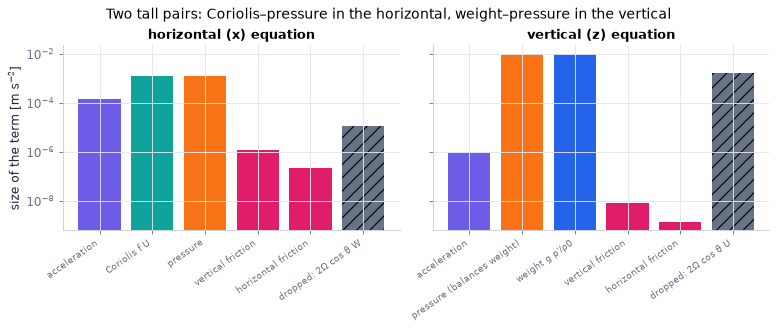

In [32]:
x_terms = [("acceleration", terms["x"]["acceleration"], COLORS["accent"], None), ("Coriolis f U", terms["x"]["coriolis"], COLORS["teal"], None),
           ("pressure", terms["x"]["pressure"], COLORS["orange"], None), ("vertical friction", terms["x"]["friction_v"], COLORS["rose"], None),
           ("horizontal friction", terms["x"]["friction_H"], COLORS["rose"], None), ("dropped: 2Ω cos θ W", terms["x"]["coriolis_w"], COLORS["muted"], "//")]   # the x-equation
z_terms = [("acceleration", terms["z"]["acceleration"], COLORS["accent"], None), ("pressure (balances weight)", terms["z"]["buoyancy"], COLORS["orange"], None),
           ("weight g ρ'/ρ0", terms["z"]["buoyancy"], COLORS["blue"], None), ("vertical friction", terms["z"]["friction_v"], COLORS["rose"], None),
           ("horizontal friction", terms["z"]["friction_H"], COLORS["rose"], None), ("dropped: 2Ω cos θ U", terms["z"]["coriolis"], COLORS["muted"], "//")]   # the z-equation
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0), sharey=True)   # a new figure and its panel(s); figsize in inches
for ax, rows, ttl in zip(axes, (x_terms, z_terms), ("horizontal (x) equation", "vertical (z) equation")):   # one panel per equation
    ax.bar(range(len(rows)), [r[1] for r in rows], color=[r[2] for r in rows], hatch=[r[3] for r in rows])   # one bar per term, coloured by kind
    ax.set_xticks(range(len(rows)), [r[0] for r in rows], rotation=35, ha="right", fontsize=8)   # the names of the terms
    ax.set(yscale="log", title=ttl)   # axis labels (with units), title and fixed ranges of this panel
axes[0].set_ylabel("size of the term [m s$^{-2}$]")   # label / range / scale of this axis
fig.suptitle("Two tall pairs: Coriolis–pressure in the horizontal, weight–pressure in the vertical")   # the message of the whole figure
plt.show()   # display the figure

**What you see.** The estimated size of every term of the horizontal and vertical thin-shell equations for a mid-latitude weather system, on a logarithmic axis. Hatched grey bars are the pieces of the Coriolis acceleration that were dropped.

**How to read it.** In the horizontal, Coriolis (teal) and pressure (orange) tower over everything else; in the vertical, pressure and weight do. These two tall pairs are the two balances of the next blocks: geostrophic (`C02`) and hydrostatic.

**What would change if…** …$L$ shrinks to 10 km (a thunderstorm)? Then Ro ≈ 17: the acceleration bar overtakes Coriolis and rotation stops mattering.

📝 **Note.** **N16 [C]** **The f-plane:** hold $f$ at its value at the central latitude, $f=f_0=2\Omega\sin\theta_0$ (`GFD.f_plane(lat)`). Used in
`C04`–`C12`, `C14`, `C16`.

📝 **Note.** **N17 [B]** **The β-plane:** keep the first term of a Taylor expansion in the northward distance $y$:
$f=f_0+\beta y$ with $\beta\equiv(df/dy)_{\theta_0}=(df/d\theta\cdot d\theta/dy)_{\theta_0}=2\Omega\cos\theta_0/R$ (13.10),
since $dy=R\,d\theta$. The result is stated, not derived; its error is measured in the next figure.

In [33]:
print(f"f-plane value at 35 N: f0 = {GFD.f_plane(lat):.4e} 1/s")                       # f held constant
print(f"beta at 35 N = {GFD.beta_parameter(lat):.4e},  at 12 N = {GFD.beta_parameter(inp['lat_rossby']):.4e}  1/(m s)")   # Eq. (13.10)
for y_km in (500.0, 1000.0, 2000.0, -2000.0):                                          # northward distances from 35 N [km]
    print(f"  y = {y_km:+6.0f} km: beta-plane error = {100*GFD.beta_plane_error(y_km*1e3, lat):+.2f} %")   # (f_beta - f_exact)/f_exact

f-plane value at 35 N: f0 = 8.3652e-05 1/s
beta at 35 N = 1.8752e-11,  at 12 N = 2.2391e-11  1/(m s)
  y =   +500 km: beta-plane error = +0.29 %
  y =  +1000 km: beta-plane error = +1.09 %
  y =  +2000 km: beta-plane error = +4.04 %
  y =  -2000 km: beta-plane error = +8.14 %


**What does this show?** The straight-line approximation of $f$ is good to a fraction of a per cent within 500 km of the
central latitude and to a few per cent within 2000 km; the error grows like $y^2$ and is larger on the equatorward side.

In [34]:
y_bp = np.linspace(-2.0e6, 2.0e6, 33)                          # northward distance from the central latitude [m]

def f1(lat0_deg):                                              # curves for one central latitude [degrees]
    lat0 = np.deg2rad(lat0_deg)                                # in radians
    f_exact = 2*GFD.OMEGA_EARTH*np.sin(lat0 + y_bp/GFD.EARTH_RADIUS_MEAN)   # the true f at each y [1/s]
    f_beta = GFD.beta_plane(y_bp, lat0)                        # Eq. (13.10): f0 + beta y
    return {"exact f = 2Ω sin(θ0 + y/R)": (y_bp/1e3, f_exact*1e4),   # hand the result back to the caller
            "β-plane f0 + βy": (y_bp/1e3, f_beta*1e4),
            "10 × (β-plane − exact)": (y_bp/1e3, 10*(f_beta - f_exact)*1e4)}

figF1 = slider_figure(f1, "central latitude θ0", np.arange(5.0, 75.1, 5.0), unit="°", xlabel="northward distance y [km]",
                      ylabel="f [10⁻⁴ s⁻¹]", title="The β-plane is a straight line through the true curve", active=6)   # 15 slider positions, starting at 35 degrees
figF1.show()   # display the interactive figure (the slider works on the web page too)

**What does the code above do?**

1. `f1` computes the exact $f$ along a north–south line and the β-plane straight line through the same central point.
2. The third trace is their difference magnified ten times, so that it can be seen on the same axis.

**What you see.** The true Coriolis parameter (a piece of a sine curve), the β-plane straight line through its central point, and ten times their difference.

**How to read it.** The difference is a parabola: the error grows like $y^2$. At low central latitudes the line is steep ($\beta$ large) while $f_0$ itself is small, so the *relative* error is largest there.

**What would change if…** …the central latitude were 75°? The curve flattens (β → 0 toward the pole) and bends more: the β-plane is least useful where β matters least.

#### Reading the three equations

$$ \underbrace{\frac{Du}{Dt}}_{\text{acceleration}}\underbrace{-fv}_{\text{Coriolis}}=\underbrace{-\frac1{\rho_0}\frac{\partial p}{\partial x}}_{\text{pressure}}+\underbrace{F_x}_{\text{friction}},\qquad
\frac{Dv}{Dt}+fu=-\frac1{\rho_0}\frac{\partial p}{\partial y}+F_y,\qquad
\frac{Dw}{Dt}=-\frac1{\rho_0}\frac{\partial p}{\partial z}-\frac{g\rho}{\rho_0}+F_z \qquad\text{(13.9)} $$

Rotation enters through $f$ alone, and only in the horizontal; the two Coriolis terms have opposite signs, which is what makes
things turn. Colour code used from here on: acceleration purple, Coriolis teal, pressure orange, friction rose, density blue.

**What would change if…** the flow is slow and wide, so that the acceleration and friction bars are negligible? Only the two
tall bars are left in each horizontal equation — geostrophic balance (`C02`).

---

## 13.5 Geostrophic Flow

**What is this section about?** The balance that rules every slow, large-scale flow: Coriolis force against pressure gradient.
Then its two consequences — a wind that changes with height wherever temperature changes horizontally, and, when it does not,
fluid that moves in rigid columns.

### 🧩 Geostrophic balance: $-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}$ and $fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}$ (13.11)–(13.12) `C02`

*The question:* Why doesn't the air simply flow from high to low pressure?

#### The problem in plain words

Open any weather map. The wind arrows run *along* the isobars, with low pressure on their left in the northern hemisphere. A
ball on a hill rolls downhill; air on a pressure "hill" goes round it. The reason is that on a turning earth anything that
moves is pushed sideways, and the push grows with speed. The air speeds up toward low pressure, is turned, overshoots and is turned
back: released from rest, a frictionless parcel traces a row of arches along the isobar. Averaged over an arch it moves along
the isobars, at the one speed for which the sideways push cancels the pressure force. Friction, or the radiation of waves
(`C12`), removes the arches and leaves that steady drift. Oceanographers use
the same balance backwards: an altimeter measures the slope of the sea surface, and the slope gives the current.

#### The idea

```
(1) at rest             (2) moving, being turned           (3) on average: along the isobar
 L                        L                                  L
 ↑ pressure force         ↑ pressure force                   ↑ pressure force
 ●                        ●→  velocity                       ●━━━▶ velocity (along the isobar)
                          ↘ Coriolis (right of motion,       ↓ Coriolis = − pressure force
                            grows with speed)
```

In the northern hemisphere ($f>0$); mirror for $f<0$. The Coriolis force is always at right angles to the motion, so it can
cancel the pressure force only when the motion is at right angles to the pressure force — along the isobars. A parcel
released from rest does not stop there: it overshoots (at its fastest it moves at twice the balanced speed), and its
*velocity* circles the balanced value once per inertial period for ever, unless something damps it. Its *path* is then a row
of cycloid arches with cusps — no closed loops — drifting along the isobar. Panel (3) is the *average* over an arch.

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **order-of-magnitude scaling** — replace each derivative by (typical change)/(typical distance) — $\partial u/\partial x\sim U/L$ — to compare the sizes of terms without solving anything. *(Ch. 4, P130)*
- **`np.meshgrid`, the [j, i] grid layout, array slicing for centred differences** — `X, Y = np.meshgrid(x, y)` gives arrays indexed `[j, i]` = (row y, column x); `(p[:, 2:] - p[:, :-2])/(2*dx)` is a centred x-difference on the interior columns. *(Ch. 2, P76)*
- **contour, quiver** — `ax.contour` draws lines of equal value of a field; `ax.quiver` draws an arrow for a vector at each grid point. *(Ch. 2, P78)*
- **inertial loops of a released parcel; `GFD.parcel_adjust`; complex numbers in numpy** — numpy handles complex numbers natively: `1j` is $i$, `z.real` and `z.imag` are the two parts, `abs(z)` the length — one complex number carries a horizontal vector. *(Ch. 6, P153)*
- **`show_viz` explainers** — `show_viz(chapter, slug)` embeds an interactive explainer in the cell output (full window on the web page). *(Ch. 1, P18)*

> 📎 **Primer — reading a pressure map: isobars, the pressure-gradient force points from high to low, tight spacing = strong force.** `P309` · An isobar joins points of equal pressure, like a height contour on a hiking map. The pressure-gradient force per unit mass is
$-\nabla p/\rho_0$: it points straight across the isobars from high to low, and it is large where the lines are close.

In [35]:
dp, dn, rho0 = 400.0, 3.0e5, 1.2      # 4 hPa between isobars 300 km apart; air density [kg/m^3]
print(dp / dn / rho0)                 # force per unit mass: 1.1e-3 m/s^2 (compare g = 9.8)

0.0011111111111111111


> 🔁 **Recap — The Rossby number `R13`** (Ch. 4 §4.7). It is $\mathrm{Ro}=\dfrac{U^2/L}{fU}=\dfrac{U}{fL}$ (13.13): the acceleration of the flow divided by the Coriolis acceleration.
Small Ro = rotation rules. ⚠️ **Trap T17:** Chapter 4's `SIM.rossby_number(U, Omega, l)` is $U/(2\Omega l)$; the two differ
by $\sin\theta$.

In [36]:
Ro_here = GFD.rossby_number(14.0, f35, 1.4e6)                  # Eq. (13.13): U/(f L) for U = 14 m/s, L = 1400 km at 35 N
Ro_ch4 = SIM.rossby_number(14.0, GFD.OMEGA_EARTH, 1.4e6)       # Chapter 4's version U/(2 Omega L)
print(f"Ro = U/(fL) = {Ro_here:.3f};  Ch. 4's U/(2 Omega L) = {Ro_ch4:.4f};  ratio = {Ro_ch4/Ro_here:.3f} = sin(35 deg)")   # the two definitions

Ro = U/(fL) = 0.120;  Ch. 4's U/(2 Omega L) = 0.0686;  ratio = 0.574 = sin(35 deg)


**What does this show?** Both numbers are small, so rotation dominates a weather system; they differ by the factor
$\sin 35°=0.574$, because this chapter uses $f$ where Chapter 4 used $2\Omega$.

📝 **Note.** **N22 [B]** **The Ekman number** $E=\dfrac{\rho\nu U/L^2}{\rho fU}=\dfrac{\nu}{fL^2}$ (13.18) is friction over Coriolis. Geostrophy needs
both $\mathrm{Ro}\ll1$ and $E\ll1$.

In [37]:
E_vert = GFD.ekman_number(7.0, f35, 1000.0)                    # vertical eddy friction over a depth of 1 km (nu_v = 7 m^2/s)
E_horiz = GFD.ekman_number(3.0e4, f35, 1.4e6)                  # horizontal eddy friction over 1400 km (nu_H = 3e4 m^2/s)
print(f"E (vertical, lowest km) = {E_vert:.3f};  E (horizontal) = {E_horiz:.1e}")   # the first is not small

E (vertical, lowest km) = 0.084;  E (horizontal) = 1.8e-04


**What does this show?** Horizontal friction is utterly negligible, but within the lowest kilometre vertical friction is
about a tenth of the Coriolis force — not small. That is the Ekman layer of `C06`. In `C04` the same number appears as
$(\delta/L)^2/2$.

#### 🧮 Derivation — Geostrophic balance from the thin-shell equations `D03` ★ (Eq. 13.11: $-fv=-\frac{1}{\rho_0}\frac{\partial p}{\partial x}$)

**What we want to show.** Find what is left of the horizontal momentum equations for slow, large-scale flow, and what that says about the direction of the wind.

**Assumptions.** Ro ≪ 1 and time scale ≫ 1/f (step 3); E ≪ 1 (step 3); constant f (step 6).

**The plan.**

1. Estimate the size of each term.
2. Form two ratios.
3. Drop what is small.
4. Read the direction of the wind from what is left.

**Tools we use** (each explained before this point): order-of-magnitude scaling (P130, reminder) · the dot product of two vectors

**We start from**

$$ \begin{array}{l}\dfrac{Du}{Dt}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}+F_x\ \text{and}\ \dfrac{Dv}{Dt}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}+F_y\ \text{, the horizontal members of} \\ \text{(13.9)}\end{array} $$

*In words:* Acceleration + Coriolis = pressure force + friction

---

**Step 1 of 6 — Estimate the size of each term.**

$$ \dfrac{Du}{Dt}\sim\dfrac{U^2}{L},\qquad fv\sim fU,\qquad F_x\sim\dfrac{\nu_vU}{H^2} $$

- *Why we can do this:* Replace each derivative by a typical change over a typical distance: velocity U, horizontal scale L, vertical scale H. We need sizes, not values.
- *In words:* Three candidate terms to balance the pressure force.

---

**Step 2 of 6 — Divide by the Coriolis term.**

$$ \mathrm{Ro}=\dfrac{U^2/L}{fU}=\dfrac{U}{fL}\ \text{(13.13), and}\ E=\dfrac{\nu_v}{fH^2} $$

- *Why we can do this:* Ratios are dimensionless, so "small" has a meaning; these two are the Rossby number and the Ekman number.
- *In words:* Ro compares acceleration with Coriolis, E compares friction with Coriolis.

---

**Step 3 of 6 — Assume both are small.**

$$ \mathrm{Ro}\ll1,\quad E\ll1 $$

- *Why we can do this:* For weather systems and ocean gyres away from boundaries Ro is about 0.1 and E far smaller; the flow must also change slowly compared with 1/f, or ∂u/∂t would not be small.
- *In words:* Slow, wide, frictionless motion.

---

**Step 4 of 6 — Drop the small terms.**

$$ -fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}\ \text{and}\ fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}\ \text{(13.11)–(13.12)} $$

- *Why we can do this:* What is left must balance to the accuracy of Ro and E: only the Coriolis term can match the pressure-gradient force.
- *In words:* Coriolis force and pressure force cancel.

---

**Step 5 of 6 — Dot the velocity with the pressure gradient.**

$$ \mathbf u\cdot\nabla p=\dfrac1{\rho_0f}\Big(-\dfrac{\partial p}{\partial y}\dfrac{\partial p}{\partial x}+\dfrac{\partial p}{\partial x}\dfrac{\partial p}{\partial y}\Big)=0 $$

- *Why we can do this:* Insert u and v from step 4; a zero dot product means the two vectors are perpendicular.
- *In words:* The wind blows along the isobars, never across them.

---

**Step 6 of 6 — Define a stream function.**

$$ \psi=\dfrac{p}{f\rho_0}:\quad u=-\dfrac{\partial\psi}{\partial y},\quad v=\dfrac{\partial\psi}{\partial x} $$

- *Why we can do this:* For constant f, step 4 has exactly this form; such a flow has no horizontal divergence, and lines of constant ψ — the isobars — are its streamlines.
- *In words:* A pressure map is a map of the flow.

---

**Result**

$$ -fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}\ \text{,}\ fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y} $$

*In words:* The wind follows the isobars with low pressure on its left for f > 0 (on its right for f < 0), at a speed proportional to their spacing

**What it means.** The balance is *diagnostic*: it gives the wind from the pressure but cannot say how either changes (that needs the small terms — C15, C16). **Fails when:** near the equator; in boundary layers (C06); in fast or small systems (Ro of order 1).

**Check it.** Units — fU [m/s²] against Δp/(ρ₀L) [Pa/(kg m⁻²)] = m/s² ✓. Number — 4 hPa over 300 km at 35° N, ρ₀ = 1.2 kg/m³: 13.3 m/s. Limits — f → 0 gives infinite wind: the balance cannot hold at the equator. Code — `GFD.geostrophic_from_field` and the dot product at round-off.

> ⚠️ **Common confusion (traps in `D03`):** The stream-function sign is opposite to Chapters 4 and 11 (trap T14); ψ exists only for constant f; "low on the left" flips with the sign of f; the Rossby number of Chapter 4 used 2Ω, not f (trap T17).

📝 **Note.** **N18 [B]** **The wind blows along the isobars, and pressure is its stream function** (steps 5–6 of `D03`): $\mathbf u\cdot\nabla p=0$, and
for constant $f$ the function $\psi=p/(f\rho_0)$ gives $u=-\partial\psi/\partial y$, $v=\partial\psi/\partial x$
(`GFD.geostrophic_streamfunction`).

> ⚠️ **Common confusion (trap T14):** Chapters 4 and 11 used $u=+\partial\psi/\partial y$. Here the sign is the other way, so that $\psi$ is high where $p$ is high
(for $f>0$).

#### ✏️ Tiny example: the wind from two isobars

Isobars 4 hPa (400 Pa) apart lie 400 km apart; $\rho_0\approx1.25$ kg/m³; $f\approx10^{-4}$ s⁻¹ (about 43° N).

1. Pressure-gradient force per unit mass: $400/(4\times10^{5}\times1.25)=8\times10^{-4}$ m/s².
2. Balance $f\,U=\frac1{\rho_0}\lvert\nabla p\rvert$: $U=8\times10^{-4}/10^{-4}=8$ m/s.
3. Direction: along the isobars, low pressure on the left (northern hemisphere, $f>0$; on the right for $f<0$).
4. Halve the spacing → 16 m/s.
5. The same isobars at 20° N ($f\approx5\times10^{-5}$ s⁻¹): 16 m/s — and at the equator the formula gives infinity: geostrophy
   fails there.

In [38]:
u_n, v_n = GFD.geostrophic_velocity(0.0, 400.0/3.0e5, f35, 1.2)     # pressure rising northward by 4 hPa in 300 km, at 35 N
u_s, v_s = GFD.geostrophic_velocity(0.0, 400.0/3.0e5, -f35, 1.2)    # the same pressure field at 35 S (f < 0)
u_oc, v_oc = GFD.geostrophic_from_height(np.outer([0.0, 0.1, 0.2], np.ones(3)), 1.0e5, 1.0e5, f35)   # a sea surface rising northward by 0.1 m per 100 km
print(f"35 N: u = {u_n:+.2f} m/s ({ch13.wind_from_to(u_n, v_n)['wind_name']} wind; high pressure on its right)")   # Eq. (13.12)
print(f"35 S: u = {u_s:+.2f} m/s ({ch13.wind_from_to(u_s, v_s)['wind_name']} wind; high pressure on its left)")    # the mirror
print(f"ocean: surface slope 0.1 m per 100 km -> current u = {u_oc[1, 1]:+.3f} m/s")   # Eq. (13.116) used as a current meter

35 N: u = -13.28 m/s (easterly wind; high pressure on its right)
35 S: u = +13.28 m/s (westerly wind; high pressure on its left)
ocean: surface slope 0.1 m per 100 km -> current u = -0.117 m/s


**What does the code above do?**

1. `GFD.geostrophic_velocity(dpdx, dpdy, f, rho0)` solves the two balance equations for $(u, v)$.
2. With high pressure to the north the wind at 35° N is an easterly of about 13 m/s (low pressure on the left of the motion);
   at 35° S the same pressure field drives a westerly of the same speed.
3. `GFD.geostrophic_from_height` is the oceanographer's version: a surface slope of 0.1 m in 100 km means a current of about
   0.12 m/s.

In [39]:
# From scratch: the geostrophic wind of a low, by centred differences written with slices
xg = np.linspace(-2.0e6, 2.0e6, 81); yg = np.linspace(-2.0e6, 2.0e6, 81)   # grid [m]; arrays are indexed [j, i] = (y, x)
dxg, dyg, rho0 = xg[1] - xg[0], yg[1] - yg[0], 1.2             # grid spacings [m] and air density [kg/m^3]
pc = ch13.pressure_centre(xg, yg, dp=400.0, R_c=6.0e5, lat_rad=lat, kind="low")   # a 4 hPa low at 35 N
p = pc["p"]                                                    # pressure anomaly [Pa]
dpdx = np.zeros_like(p); dpdy = np.zeros_like(p)               # arrays for the two pressure gradients
dpdx[:, 1:-1] = (p[:, 2:] - p[:, :-2])/(2*dxg)                 # centred difference along x (columns)
dpdy[1:-1, :] = (p[2:, :] - p[:-2, :])/(2*dyg)                 # centred difference along y (rows)
u_mine = -dpdy/(rho0*f35)                                      # Eq. (13.12): f u = -(1/rho0) dp/dy
v_mine = dpdx/(rho0*f35)                                       # Eq. (13.11): -f v = -(1/rho0) dp/dx
u_lib, v_lib = GFD.geostrophic_from_field(p, dxg, dyg, f35, rho0)   # the tested function
assert np.allclose(u_mine[1:-1, 1:-1], u_lib[1:-1, 1:-1]) and np.allclose(v_mine[1:-1, 1:-1], v_lib[1:-1, 1:-1])   # same interior values
cross = np.abs(u_mine*dpdx + v_mine*dpdy)[1:-1, 1:-1].max()    # u . grad p: zero if the wind is along the isobars
print(f"✓ hand-written differences agree with GFD.geostrophic_from_field; max |u·∇p| = {cross:.1e} (round-off: wind along isobars)")   # visible confirmation

✓ hand-written differences agree with GFD.geostrophic_from_field; max |u·∇p| = 1.1e-19 (round-off: wind along isobars)


**What does the code above do?**

The two balance equations, with the derivatives written as array slices, reproduce the library; and $\mathbf u\cdot\nabla p$ is
zero to round-off — the wind crosses no isobar.

> 🔁 **Recap — Highs and lows `R14`** (Ch. 4 §4.7). Round a low the geostrophic wind turns counter-clockwise in the northern hemisphere ($f>0$) and clockwise in the southern
($f<0$); round a high the other way. The pressure force $-\nabla p/\rho_0$ points inward for a low; the Coriolis force
$-f\,\mathbf e_z\times\mathbf u$ must point outward.

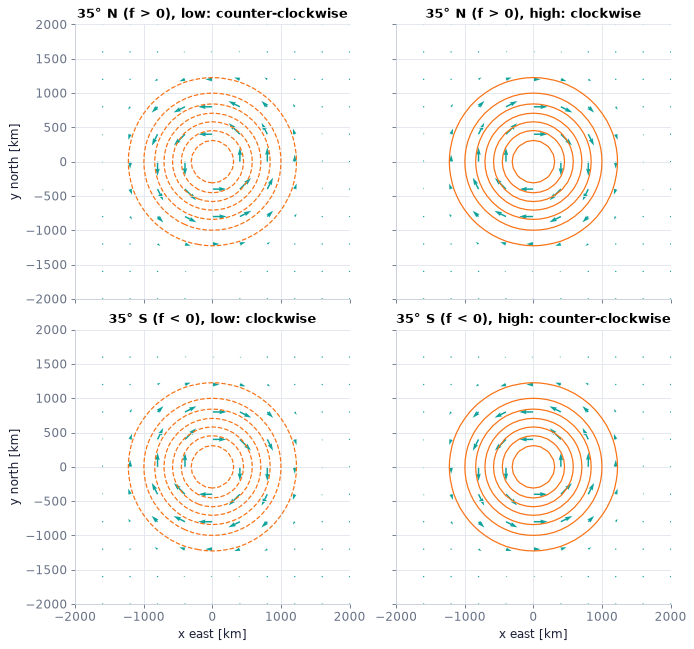

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(8.6, 8.0), sharex=True, sharey=True)   # a new figure and its panel(s); figsize in inches
for row, (L, hemi) in enumerate(((lat, "35° N (f > 0)"), (-lat, "35° S (f < 0)"))):   # one row per hemisphere
    for col, kind in enumerate(("low", "high")):               # one column per kind of centre
        pc4 = ch13.pressure_centre(x, y, dp=400.0, R_c=6.0e5, lat_rad=L, kind=kind)   # pressure anomaly and its geostrophic wind
        ax = axes[row, col]                                    # this panel
        ax.contour(x/1e3, y/1e3, pc4["p"]/100, 7, colors=COLORS["orange"], linewidths=1.1)   # isobars (orange = pressure)
        ax.quiver(x[::4]/1e3, y[::4]/1e3, pc4["u"][::4, ::4], pc4["v"][::4, ::4], color=COLORS["teal"], scale=70)   # geostrophic wind, every fourth point
        sense = GFD.hemisphere(L)["cyclonic"] if kind == "low" else ("clockwise" if L > 0 else "counter-clockwise")   # sense of rotation
        ax.set(title=f"{hemi}, {kind}: {sense}", aspect="equal")   # axis labels (with units), title and fixed ranges of this panel
for ax in axes[1]:
    ax.set_xlabel("x east [km]")   # label / range / scale of this axis
for ax in axes[:, 0]:
    ax.set_ylabel("y north [km]")   # label / range / scale of this axis
plt.show()   # display the figure

**What you see.** Four panels: a low and a high, at 35° N (top) and 35° S (bottom). Isobars are orange, the geostrophic wind teal; each title names the sense of rotation.

**How to read it.** In the top row low pressure is on the left of every arrow; in the bottom row it is on the right. Lows are cyclonic in both hemispheres — but cyclonic means counter-clockwise in the north and clockwise in the south.

**What would change if…** …the pressure difference doubles? Every arrow doubles in length; no arrow turns.

#### Where geostrophy fails, and how it is set up

(The verbal part of note **N19**; its quantitative part is the adjustment problem of `C12`.) Geostrophy fails near the equator
($f\to0$), where friction matters ($E$ not small), and when the flow changes in less than about a day (the acceleration is not
small). And how is the balance reached? Release a parcel from rest in a uniform pressure gradient and it does not go to the
low — it swings from side to side of the isobar in arches. `GFD.parcel_adjust` is the exact solution of $dV/dt+(r+if)V=-G$ for the complex velocity $V=u+iv$, with $G$
the pressure-gradient acceleration and $r$ a linear drag (ours).

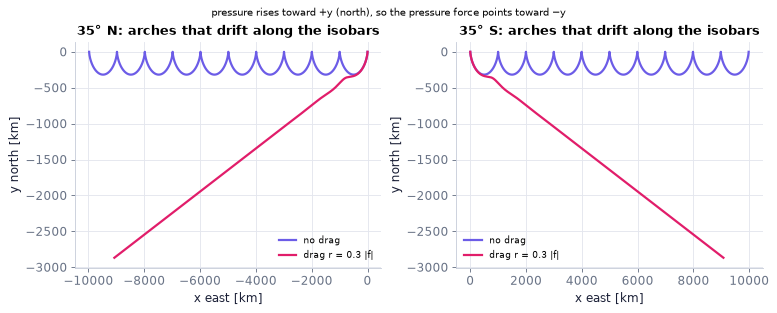

mean drift of the frictionless parcel = -13.28 -0.00i m/s; geostrophic velocity = -13.28 +0.00i m/s


In [41]:
G = (0.0 + 1j*400.0/3.0e5)/1.2                                 # complex pressure-gradient acceleration (1/rho0)(dp/dx + i dp/dy) [m/s^2]
T_i = GFD.inertial_period(f35)                                 # inertial period at 35 N [s]
t_p = np.linspace(0.0, 10*T_i, 4001)                           # ten inertial periods [s]
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.8))   # a new figure and its panel(s); figsize in inches
for ax, f_, ttl in ((a, f35, "35° N"), (b, -f35, "35° S")):    # one panel per hemisphere
    for r_, col, lab in ((0.0, COLORS["accent"], "no drag"), (0.3*abs(f_), COLORS["rose"], "drag r = 0.3 |f|")):   # two parcels
        V = GFD.parcel_adjust(t_p, G, f_, r=r_)                # complex velocity u + iv of the released parcel [m/s]
        Z = cumulative_trapezoid(V, t_p, initial=0)            # its position x + iy by integrating the velocity [m]
        ax.plot(Z.real/1e3, Z.imag/1e3, color=col, label=lab)  # the path
    ax.set(title=f"{ttl}: arches that drift along the isobars", xlabel="x east [km]", ylabel="y north [km]")   # axis labels (with units), title and fixed ranges of this panel
    ax.legend(fontsize=8)   # the legend names every curve
fig.suptitle("pressure rises toward +y (north), so the pressure force points toward −y", fontsize=9)   # the message of the whole figure
plt.show()   # display the figure
V0 = GFD.parcel_adjust(t_p, G, f35, r=0.0)                     # the frictionless parcel at 35 N again
drift = np.trapezoid(V0, t_p)/t_p[-1]                          # its mean velocity over ten inertial periods
Vg = complex(*GFD.geostrophic_velocity(0.0, 400.0/3.0e5, f35, 1.2))   # the geostrophic velocity for the same gradient
print(f"mean drift of the frictionless parcel = {drift.real:+.2f} {drift.imag:+.2f}i m/s; geostrophic velocity = {Vg.real:+.2f} {Vg.imag:+.2f}i m/s")   # they agree

**What you see.** Paths of a parcel released from rest in a uniform pressure gradient (pressure increasing northward, so the pressure force points south). Without drag (purple) it traces a row of arches, coming to rest for an instant at each cusp; with drag (rose) the wiggles die out within a few hundred kilometres and the path becomes a straight line.

**How to read it.** Each arch is one inertial circle added to a steady drift *along* the isobars (a cycloid) — and the printed line shows that the mean drift is exactly the geostrophic velocity. Geostrophy is the average of the motion; the arches are what is left of the start. With drag, the parcel ends up moving steadily at an angle to the isobars, toward low pressure (a preview of `C06`).

**What would change if…** …$f<0$ (right panel)? The parcel is turned to the left instead: the arches and the drift go east instead of west.

#### 🎮 Interactive: Why doesn't air flow straight from high to low pressure?

**Why interactive rather than a static figure:** releasing a parcel and watching the Coriolis arrow grow and turn with the velocity shows how the balance is approached — the parcel overshoots and swings about it in arches, and only with drag do the bars settle; a static map shows only the end state.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Press play with the default low and watch the teal Coriolis arrow swing round and overshoot; with drag switched on it settles opposite the orange pressure arrow.
- Switch to S: the circulation reverses at once.
- Drag the latitude toward 5°: Ro climbs past 1 and the parcel cuts across the isobars.
- Turn on drag: the wind settles at an angle to the isobars, toward low pressure — a preview of `C06`.

In [42]:
show_viz("ch13", "geostrophic_balance")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/geostrophic_balance]

**What would change if…** …the density, and so the pressure pattern, differs from one height to the next? Then the geostrophic wind differs too: the
thermal wind (`C03`).

### 🧩 Thermal wind: $\dfrac{\partial v}{\partial z}=-\dfrac{g}{\rho_0f}\dfrac{\partial\rho}{\partial x}$ and $\dfrac{\partial u}{\partial z}=\dfrac{g}{\rho_0f}\dfrac{\partial\rho}{\partial y}$ (13.15) `C03`

*The question:* Why is there a jet stream high up, and why is it westerly in both hemispheres?

#### The problem in plain words

Airliners flying east across the Atlantic ride a river of air moving at 150 km/h or more; the wind at the ground below is far
gentler. The jet sits above the place where the temperature changes fastest from south to north. That is no coincidence. Cold
air is dense, so pressure falls faster with height in the cold column than in the warm one; the pressure difference between
the columns therefore grows with height, and with it the geostrophic wind. The temperature gradient does not set the wind — it
sets how the wind *changes with height*.

*Two words.* A state in which surfaces of constant pressure and constant density coincide is **barotropic** (no thermal wind);
one in which they cross is **baroclinic** (the wind changes with height).

#### The idea

```
pole (cold)                         equator (warm)
───────────────── p = 300 hPa ──────────────╱      ← the upper pressure surface slopes down toward the pole
  short, dense column          tall, light column
───────────────── p = 1000 hPa ─────────────       ← flat at the ground
     ⊙ weak wind at the ground,  ⊙⊙⊙ strong wind aloft (out of the page = eastward)
```

| Hemisphere | Cold air lies to the | Sign of $f$ | Shear $\partial u/\partial z$ |
|---|---|---|---|
| northern | north | $f>0$ | westerly (eastward wind grows with height) |
| southern | south | $f<0$ | westerly again — both signs flip |

> 🔁 **Recap — The perturbation is hydrostatic `R15`** (Ch. 1 hydrostatics $dp/dz=-\rho g$ (1.8); Ch. 7 $p'=\rho g\eta$ (7.52)). The balance is $0=-\dfrac{\partial p}{\partial z}-g\rho$ (13.14). ⚠️ **Trap T3 again:** the symbols $p$ and $\rho$ are the perturbations from the state
of rest (primes dropped).

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named) — the only two tools `D04` needs are the first two

- **cross-differentiation to eliminate a variable** — differentiate one equation in $z$ and another in $x$ so that both contain the same mixed derivative, then equate (or subtract) to remove the pressure. *(Ch. 7, P177)*
- **`scipy.integrate.cumulative_trapezoid`** — `cumulative_trapezoid(y, x, initial=0)` returns the running integral of sampled data — here a shear integrated upward into a wind profile. *(Ch. 8, P190)*
- **hypotheses of a theorem (necessary conditions)** — a theorem holds only under its stated hypotheses; drop one (here: uniform density) and the conclusion may fail. *(Ch. 11, P255)*

#### 🧮 Derivation — Thermal wind, and its temperature form (ours) `D04` ★★ (Eq. 13.15: $\frac{\partial v}{\partial z}=-\frac{g}{\rho_0f}\frac{\partial\rho}{\partial x},\ \ \frac{\partial u}{\partial z}=\frac{g}{\rho_0f}\frac{\partial\rho}{\partial y}$)

**What we want to show.** Show that a horizontal density (temperature) gradient forces the geostrophic wind to change with height. The book says "eliminating p".

**Assumptions.** f does not depend on z (steps 1, 4); Boussinesq (ρ₀ constant); steps 6–7 need $\rho'=-\rho_0\alpha T'$.

**The plan.**

1. Differentiate the geostrophic equations in z.
2. Differentiate the hydrostatic equation in x and in y.
3. Equate the mixed derivatives of p.
4. (ours) replace density by temperature.

**Tools we use** (each explained before this point): cross-differentiation (P177) and Schwarz's theorem (P121), reminders · the linear equation of state (R06)

**We start from**

$$ \begin{array}{l}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}\ \text{and}\ fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}\ \text{(13.11)–(13.12), with}\ 0=-\dfrac{\partial p}{\partial z}-g\rho \\ \text{(13.14)}\end{array} $$

*In words:* Geostrophic in the horizontal, hydrostatic in the vertical

---

**Step 1 of 7 — Differentiate the first balance in z.**

$$ -f\dfrac{\partial v}{\partial z}=-\dfrac1{\rho_0}\dfrac{\partial^2p}{\partial z\,\partial x} $$

- *Why we can do this:* Both sides are differentiable and f and ρ₀ do not depend on z, so they pass through; we want the shear of v on the left.
- *In words:* The change of wind with height is tied to the change with height of the pressure gradient.

---

**Step 2 of 7 — Differentiate the hydrostatic balance in x.**

$$ \dfrac{\partial^2p}{\partial x\,\partial z}=-g\dfrac{\partial\rho}{\partial x} $$

- *Why we can do this:* Gravity g is constant; this expresses the same mixed derivative of p through the density.
- *In words:* Where the fluid is denser, pressure falls faster with height.

---

**Step 3 of 7 — Equate the mixed derivatives.**

$$ \dfrac{\partial v}{\partial z}=-\dfrac{g}{\rho_0f}\dfrac{\partial\rho}{\partial x}\ \text{(13.15), first member} $$

- *Why we can do this:* The order of differentiation does not matter (Schwarz), so steps 1 and 2 share $\partial^2p/\partial x\partial z$; eliminate it and divide by −f.
- *In words:* Density increasing eastward makes the northward wind decrease with height (f > 0).

---

**Step 4 of 7 — Do the same with the second balance.**

$$ f\dfrac{\partial u}{\partial z}=-\dfrac1{\rho_0}\dfrac{\partial^2p}{\partial z\,\partial y},\qquad\dfrac{\partial^2p}{\partial y\,\partial z}=-g\dfrac{\partial\rho}{\partial y} $$

- *Why we can do this:* The same two differentiations applied to the y-equation and to the hydrostatic balance in y.
- *In words:* The same link in the north–south direction.

---

**Step 5 of 7 — Eliminate the pressure again.**

$$ \dfrac{\partial u}{\partial z}=\dfrac{g}{\rho_0f}\dfrac{\partial\rho}{\partial y}\ \text{(13.15), second member} $$

- *Why we can do this:* Equate the mixed derivatives and divide by f; note the plus sign, inherited from the plus sign of fu.
- *In words:* Density increasing northward makes the eastward wind increase with height (f > 0).

---

**Step 6 of 7 — Express density through temperature (ours).**

$$ \dfrac{\partial\rho}{\partial y}=-\rho_0\alpha\dfrac{\partial T}{\partial y} $$

- *Why we can do this:* For small departures the equation of state is linear, $\rho'=-\rho_0\alpha T'$ (R06), with α = 1/T₀ for a perfect gas; meteorologists measure temperature, not density.
- *In words:* Cold means dense.

---

**Step 7 of 7 — Substitute (ours).**

$$ \dfrac{\partial u}{\partial z}=-\dfrac{g\alpha}{f}\dfrac{\partial T}{\partial y},\qquad\dfrac{\partial v}{\partial z}=\dfrac{g\alpha}{f}\dfrac{\partial T}{\partial x} $$

- *Why we can do this:* Insert step 6 into steps 5 and 3; the minus sign of step 6 flips both signs.
- *In words:* Temperature falling toward the pole makes the westerly wind grow with height.

---

**Result**

$$ \begin{array}{l}\dfrac{\partial v}{\partial z}=-\dfrac{g}{\rho_0f}\dfrac{\partial\rho}{\partial x}\ \text{,}\ \dfrac{\partial u}{\partial z}=\dfrac{g}{\rho_0f}\dfrac{\partial\rho}{\partial y}\ \text{— the two members of} \\ \text{(13.15); in temperature (ours)}\ \dfrac{\partial u}{\partial z}=-\dfrac{g\alpha}{f}\dfrac{\partial T}{\partial y}\end{array} $$

*In words:* a horizontal temperature gradient cannot coexist with a wind that is the same at every height

**What it means.** The jet stream sits above the strongest temperature contrast; an oceanographer gets currents from a density section. Only the *shear* is fixed — one reference wind must come from elsewhere. **Fails when:** geostrophy or hydrostatics fail (equator, small scales).

**Check it.** Units — (g/ρ₀f) ∂ρ/∂y = (m s⁻²)(kg m⁻⁴)/(kg m⁻³ s⁻¹) = s⁻¹ ✓. Number — ∂T/∂y = −7 K per 1000 km, α = 1/280 K⁻¹, 35° N: 2.93 × 10⁻³ s⁻¹, i.e. 26.4 m/s over 9 km. Hemisphere — f < 0 with ∂T/∂y > 0 gives the same westerly shear. Limit — no gradient, no shear (D05).

> ⚠️ **Common confusion (traps in `D04`):** Which equation is differentiated with respect to which variable; the minus of the first member and the plus of the second; ρ is the perturbation (trap T3); in temperature form the signs flip again and α must be supplied.

📝 **Note.** **N20 [B]** **Not in the book — ours** (the book states it in words): the last two steps of `D04` put the thermal wind in temperature form.
With $\rho'/\rho_0=-\alpha T'$, $\dfrac{\partial u}{\partial z}=-\dfrac{g\alpha}{f}\dfrac{\partial T}{\partial y}$ and
$\dfrac{\partial v}{\partial z}=\dfrac{g\alpha}{f}\dfrac{\partial T}{\partial x}$, where $\alpha=1/T_0$ for a perfect gas and
$T$ is the potential temperature in a deep layer.

#### ✏️ Tiny example: a jet from a temperature gradient

Take $g\approx10$ m/s², $T_0=250$ K so $g\alpha=g/T_0=0.04$ m s⁻² K⁻¹, $f=10^{-4}$ s⁻¹, and let temperature fall northward by
1 K per 100 km: $\partial T/\partial y=-10^{-5}$ K/m.

1. Shear: $\frac{\partial u}{\partial z}=-\frac{g\alpha}{f}\frac{\partial T}{\partial y}=-(0.04/10^{-4})\times(-10^{-5})=+4\times10^{-3}$ s⁻¹ = 4 m/s per km.
2. With calm air at the ground, the wind at 10 km is 40 m/s from the west.
3. Southern hemisphere: $\partial T/\partial y=+10^{-5}$ K/m (cold toward the south pole) and $f=-10^{-4}$ s⁻¹: the two sign
   changes cancel, again +4 m/s per km.
4. No gradient → no shear.

In [43]:
dudz, dvdz = GFD.thermal_wind_from_temperature(0.0, -7.0e-6, f35, alpha=1/280.0)    # temperature falling northward by 0.7 K per 100 km at 35 N
dudz_s, _ = GFD.thermal_wind_from_temperature(0.0, +7.0e-6, -f35, alpha=1/280.0)    # 35 S: cold toward the south pole, f < 0
du_oc, dv_oc = GFD.thermal_wind_shear(0.0, 1.0e-5, f35, 1027.0)                     # Eq. (13.15) for an ocean front: density rising northward by 1 kg/m^3 per 100 km
print(f"35 N: du/dz = {dudz:.3e} 1/s  ->  wind at 9 km above calm ground = {dudz*9000.0:.1f} m/s (westerly)")   # the jet
print(f"35 S: du/dz = {dudz_s:.3e} 1/s  (the same: both signs flipped)")             # westerly in both hemispheres
print(f"ocean front: du/dz = {du_oc:.2e} 1/s = {du_oc*1000:.2f} m/s per 1000 m")     # the density form

35 N: du/dz = 2.931e-03 1/s  ->  wind at 9 km above calm ground = 26.4 m/s (westerly)
35 S: du/dz = 2.931e-03 1/s  (the same: both signs flipped)
ocean front: du/dz = 1.14e-03 1/s = 1.14 m/s per 1000 m


**What does the code above do?**

1. `GFD.thermal_wind_from_temperature(dTdx, dTdy, f, alpha=…)` is our temperature form; `alpha` must be passed **by name**,
   because the letter α means three different things in this chapter and a positional argument would invite a mix-up.
2. A modest gradient of 0.7 K per 100 km gives a 26 m/s westerly at 9 km.
3. The southern twin gives exactly the same shear: the temperature gradient and $f$ both change sign.
4. `GFD.thermal_wind_shear` is the book's density form $\frac{\partial u}{\partial z}=\frac{g}{\rho_0f}\frac{\partial\rho}{\partial y}$ *(13.15)*; an ocean front gives about 1 m/s per kilometre of depth.

In [44]:
# From scratch: the shear in one line, then the wind profile by a hand-written running integral
shear_mine = -G0*(1/280.0)*(-7.0e-6)/f35                       # du/dz = -(g alpha/f) dT/dy [1/s]
assert np.isclose(shear_mine, dudz)                            # same as GFD.thermal_wind_from_temperature
z_tw = np.linspace(0.0, 9000.0, 91)                            # heights from the ground to 9 km [m]
drho_dy = 1.2*(1/280.0)*7.0e-6*np.exp(-z_tw/8000.0)            # a density gradient that weakens with height [kg/m^4]
U_loop = np.zeros_like(z_tw)                                   # wind profile, calm at the ground
for k in range(1, len(z_tw)):                                  # trapezoid rule, one layer at a time
    s0 = G0*drho_dy[k-1]/(1.2*f35)                             # shear at the bottom of the layer, Eq. (13.15)
    s1 = G0*drho_dy[k]/(1.2*f35)                               # shear at the top of the layer
    U_loop[k] = U_loop[k-1] + 0.5*(s0 + s1)*(z_tw[k] - z_tw[k-1])   # add the layer's contribution
assert np.allclose(U_loop, GFD.thermal_wind_integrate(z_tw, drho_dy, f35, 1.2))   # same as the library's integral
print(f"✓ shear {shear_mine:.3e} 1/s and the integrated profile agree with the library (U at 9 km = {U_loop[-1]:.1f} m/s)")   # visible confirmation

✓ shear 2.931e-03 1/s and the integrated profile agree with the library (U at 9 km = 15.8 m/s)


**What does the code above do?**

The thermal-wind relation is one multiplication; turning a shear into a wind is a running integral from a level where the wind
is known. Both hand-written versions match `GFD.thermal_wind_from_temperature` and `GFD.thermal_wind_integrate`.

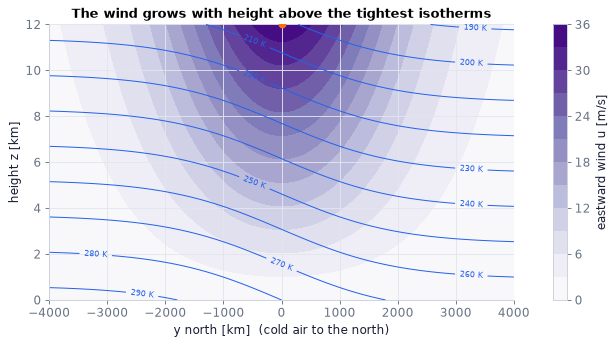

wind at 9 km above the front: 26.4 m/s;  dT/dy there: -7.0e-06 K/m


In [45]:
y_j = np.linspace(-4.0e6, 4.0e6, 121)                          # north-south distance from the front [m]
z_j = np.linspace(0.0, 1.2e4, 61)                              # height [m]
sec = ch13.jet_section(y_j, z_j, dT=28.0, width=2.0e6, lat_rad=lat, alpha=1/280.0)   # temperature and thermal-wind-balanced zonal wind (ours)
fig, ax = plt.subplots(figsize=(7.6, 4.2))   # a new figure and its panel(s); figsize in inches
cf = ax.contourf(y_j/1e3, z_j/1e3, sec["U"], 12, cmap="Purples")   # zonal wind [m/s], filled
cs = ax.contour(y_j/1e3, z_j/1e3, sec["T"], 12, colors=COLORS["blue"], linewidths=0.9)   # isotherms (blue = temperature)
ax.clabel(cs, fmt="%.0f K", fontsize=7)                        # label the isotherms
jz, jy = np.unravel_index(np.argmax(sec["U"]), sec["U"].shape) # where the wind is strongest
ax.plot(y_j[jy]/1e3, z_j[jz]/1e3, "o", color=COLORS["orange"]) # mark the jet core
fig.colorbar(cf, label="eastward wind u [m/s]")   # the colour scale and what it measures
ax.set(xlabel="y north [km]  (cold air to the north)", ylabel="height z [km]", title="The wind grows with height above the tightest isotherms")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure
i9 = np.argmin(abs(z_j - 9000.0)); i0 = np.argmin(abs(y_j))    # indices of z = 9 km and y = 0
print(f"wind at 9 km above the front: {sec['U'][i9, i0]:.1f} m/s;  dT/dy there: {sec['dTdy'][i0]:.1e} K/m")   # compare with the code cell above

**What you see.** A north–south section through a front at 35° N: isotherms (blue) dipping toward the cold side, and the eastward wind (purple shading) that is in thermal-wind balance with them. The orange dot is the strongest wind.

**How to read it.** Follow one isotherm: where it slopes most steeply, the wind contours are closest in the vertical. The wind maximum sits above the tightest isotherms, at the top of the section.

**What would change if…** …the surface air were already blowing at 5 m/s? Every contour would shift by 5 m/s — the thermal wind fixes the shear, not the wind.

In [46]:
z_f3 = np.linspace(0.0, 1.2e4, 13)                             # height [m]

def f3(dT):                                                    # wind profiles above the front for one temperature contrast dT [K]
    out = {}
    for sgn, nm in ((+1, "35° N: cold air to the north, f > 0"), (-1, "35° S: cold air to the south, f < 0")):   # both hemispheres
        dTdy = -sgn*dT/(2*2.0e6)                               # temperature gradient at the centre of a front 2000 km wide [K/m]
        drho = -1.2*(1/280.0)*dTdy*np.ones_like(z_f3)          # density gradient from rho' = -rho0 alpha T' [kg/m^4]
        out[nm] = (GFD.thermal_wind_integrate(z_f3, drho, sgn*f35, 1.2), z_f3/1e3)   # Eq. (13.15) integrated up from calm ground
    return out   # hand the result back to the caller

figF3 = slider_figure(f3, "temperature contrast across the front", np.arange(0.0, 40.1, 2.0), unit="K", xlabel="eastward wind u [m/s]",
                      ylabel="height z [km]", title="More contrast, more shear — and westerly in both hemispheres",
                      modes={"35° S: cold air to the south, f < 0": "markers"})   # 21 slider positions
figF3.show()   # display the interactive figure (the slider works on the web page too)

**What does the code above do?**

1. `f3` builds the wind profile above the centre of a front for one temperature contrast, in both hemispheres.
2. The southern profile is drawn with markers so that you can see it lies exactly on the northern line.

**What you see.** The eastward wind against height above the centre of the front, for the northern (line) and southern (markers) hemisphere.

**How to read it.** The profile is a straight line whose slope is the shear; it steepens in proportion to the temperature contrast. Markers and line coincide: the jet is westerly in both hemispheres.

**What would change if…** …the contrast is zero? The profile is vertical: no change of wind with height at all (the Taylor–Proudman limit below).

📝 **Note.** **N21 [B]** **A rapidly rotating tank of uniform density.** Geostrophy with $f=2\Omega$ in a homogeneous fluid:
$-2\Omega v=-\dfrac1\rho\dfrac{\partial p}{\partial x}$ (13.16) and $2\Omega u=-\dfrac1\rho\dfrac{\partial p}{\partial y}$ (13.17).

> ⚠️ **slip #3 — the book prints** $-2\Omega u=-\frac1\rho\frac{\partial p}{\partial y}$ **; the correct form is** $2\Omega u=-\frac1\rho\frac{\partial p}{\partial y}$ (it is the second geostrophic equation with $f=2\Omega$; with the printed sign the next step of the book cannot be reached).

In [47]:
print("corrected pair leads to dw/dz = 0 ->", ch13.taylor_proudman_sympy()["ok"])                # True
print("printed pair leads to dw/dz = 0   ->", ch13.taylor_proudman_sympy(printed=True)["ok"])    # False: the printed sign fails

corrected pair leads to dw/dz = 0 -> True
printed pair leads to dw/dz = 0   -> False


**What does this show?** With the corrected sign, cross-differentiation and continuity give "no vertical stretching"; with the
printed sign they do not — the engine reaches a different (wrong) statement.

#### 🧮 Derivation — The Taylor–Proudman theorem `D05` ★★ (Eq. 13.21: $\partial\mathbf u/\partial z=0$)

**What we want to show.** Show that slow, steady, frictionless motion of a *homogeneous* rotating fluid cannot vary along the rotation axis. The book prints one of its starting equations with the wrong sign and does not write the cross-differentiation out.

**Assumptions.** Steady, Ro ≪ 1, E ≪ 1 (the Start); uniform density (step 5).

**The plan.**

1. Cross-differentiate the two horizontal equations to kill p.
2. Use continuity.
3. Differentiate in z and use uniform density.

**Tools we use** (each explained before this point): cross-differentiation (P177, reminder) · continuity · the hypotheses of a theorem (P255, reminder)

**We start from**

$$ \begin{array}{l}-2\Omega v=-\dfrac1\rho\dfrac{\partial p}{\partial x}\ \text{(13.16) and}\ 2\Omega u=-\dfrac1\rho\dfrac{\partial p}{\partial y}\ \text{(13.17, sign corrected — slip} \\ \text{\#3), with}\ 0=-\dfrac{\partial p}{\partial z}-g\rho\ \text{(13.14) and}\ \dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}=0\end{array} $$

*In words:* Geostrophy with f = 2Ω, hydrostatics, continuity

---

**Step 1 of 7 — Differentiate the first equation in y.**

$$ -2\Omega\dfrac{\partial v}{\partial y}=-\dfrac1\rho\dfrac{\partial^2p}{\partial y\,\partial x} $$

- *Why we can do this:* Both Ω and ρ are constants here; we aim at the mixed derivative of p so that it can be eliminated.
- *In words:* One equation now contains ∂²p/∂x∂y.

---

**Step 2 of 7 — Differentiate the second in x.**

$$ 2\Omega\dfrac{\partial u}{\partial x}=-\dfrac1\rho\dfrac{\partial^2p}{\partial x\,\partial y} $$

- *Why we can do this:* The same move on the other equation produces the same mixed derivative (Schwarz).
- *In words:* So does the other.

---

**Step 3 of 7 — Subtract step 1 from step 2.**

$$ 2\Omega\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)=0 $$

- *Why we can do this:* The right-hand sides are equal and cancel. With the book's printed sign of the second equation this step would give $\partial u/\partial x-\partial v/\partial y=0$ instead.
- *In words:* The horizontal flow has no divergence.

---

**Step 4 of 7 — Use continuity.**

$$ \dfrac{\partial w}{\partial z}=0\ \text{(13.19)} $$

- *Why we can do this:* Continuity says the three terms sum to zero; the first two already do, so the third vanishes by itself.
- *In words:* Columns are neither stretched nor squashed.

---

**Step 5 of 7 — Differentiate the first equation in z.**

$$ -2\Omega\dfrac{\partial v}{\partial z}=-\dfrac1\rho\dfrac{\partial}{\partial x}\Big(\dfrac{\partial p}{\partial z}\Big)=\dfrac g\rho\dfrac{\partial\rho}{\partial x}=0 $$

- *Why we can do this:* Swap the order of the derivatives, insert the hydrostatic balance, and use the uniform density: its horizontal gradient is zero.
- *In words:* No density gradient, no thermal wind.

---

**Step 6 of 7 — Do the same for the second.**

$$ \dfrac{\partial v}{\partial z}=\dfrac{\partial u}{\partial z}=0\ \text{(13.20)} $$

- *Why we can do this:* The identical move on the second equation gives ∂u/∂z = 0.
- *In words:* The horizontal velocity is the same at every height.

---

**Step 7 of 7 — Combine.**

$$ \dfrac{\partial\mathbf u}{\partial z}=0\ \text{(13.21)} $$

- *Why we can do this:* Steps 4 and 6 together cover all three velocity components.
- *In words:* The whole velocity field is independent of the coordinate along the rotation axis.

---

**Result**

$$ \partial\mathbf u/\partial z=0 $$

*In words:* The flow is two-dimensional: fluid moves in columns parallel to the rotation axis

**What it means.** a short obstacle on the floor of a rapidly rotating tank carries a whole column of fluid with it (a Taylor column). In the stratified atmosphere and ocean the density gradient prevents this — which is why D04, not D05, describes them. **Fails when:** any of the four hypotheses fails: unsteady, Ro or E not small, density not uniform.

**Check it.** Limit — it is the thermal wind (D04) with the density gradient set to zero. Code — `ch13.taylor_proudman_sympy()["ok"]` True and `(printed=True)["ok"]` False. Number — `GFD.taylor_proudman_residual` on rigid rotation returns zeros.

> ⚠️ **Common confusion (traps in `D05`):** The printed sign (slip #3); "does not vary along the axis" is not "no motion along the axis" (w may be a non-zero constant in z); uniform density enters only at step 5 (trap T15).

📝 **Note.** **N23 [B]** **No stretching** (step 4 of `D05`): $\dfrac{\partial w}{\partial z}=0$ (13.19).

📝 **Note.** **N24 [B]** **No shear** (step 6 of `D05`): $\dfrac{\partial v}{\partial z}=\dfrac{\partial u}{\partial z}=0$ (13.20).

📝 **Note.** **N25 [B]** **The Taylor–Proudman theorem:** $\partial\mathbf u/\partial z=0$ (13.21), under four hypotheses — steady, $\mathrm{Ro}\ll1$,
$E\ll1$, uniform density. It is the thermal wind with nothing to drive a shear.

📝 **Note.** **N26 [B]** **Taylor's experiment, as our sketch.** A short obstacle on the floor of a rapidly rotating tank acts as if it reached the
surface: dye divides ahead of the column above it and goes round. (The tank's dimensions are not reproduced.)

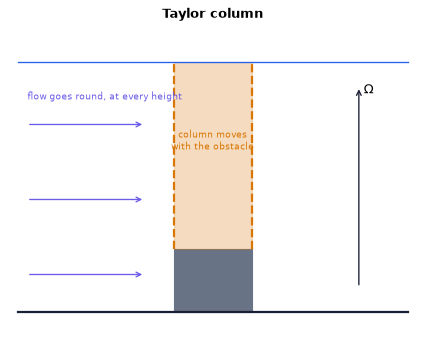

d(u, v, w)/dz of a columnar flow: {'du_dz': 0.0, 'dv_dz': 0.0, 'dw_dz': 0.0}


In [48]:
figT = draw_taylor_column()                                    # our sketch: the same two-dimensional flow at every height, column shaded
plt.show()   # display the figure
res = GFD.taylor_proudman_residual(lambda xx, yy, zz: (-yy, xx, 0.0), (0.3, 0.2, 0.5))   # a rigid rotation about the vertical axis
print("d(u, v, w)/dz of a columnar flow:", {k: round(float(v_), 12) for k, v_ in res.items()})   # all three are zero

**What you see.** A side view of a rapidly rotating tank (rotation axis $\Omega$ vertical): a short obstacle on the floor (grey), the column of fluid above it (shaded, 'moves with the obstacle'), and the oncoming flow drawn as equal arrows at three heights.

**How to read it.** The arrows are the same at every height — nothing varies along the rotation axis — so the flow must go round the whole shaded column, not just round the obstacle: its 'shadow' extends to the surface. The printed line checks a columnar flow numerically — all three vertical derivatives vanish.

**What would change if…** …the fluid were stratified? Density gradients would allow a vertical shear (the thermal wind) and the column would fade with height.

#### 🎮 Interactive: Why is there a jet stream, and why is it westerly in both hemispheres?

**Why interactive rather than a static figure:** dragging the temperature contrast tilts the isotherms and grows the shear at once; flipping the hemisphere flips both $f$ and the gradient and the jet stays westerly — three coupled changes a single section cannot show.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Drag the contrast to zero: every wind profile collapses to a vertical line (the Taylor–Proudman limit).
- Switch N ↔ S and watch which two signs change.
- Click a point in the section to see its local gradient and shear worked out.
- Switch to the ocean mode: the same relation in density, with a front instead of a jet.

In [49]:
show_viz("ch13", "thermal_wind")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/thermal_wind]

**What would change if…** …friction is not negligible? Near the sea surface and near the ground it is not; the balance gains a third force and the flow
turns — the Ekman layers (`C04`–`C06`). (The sheared flow of this block is also the starting state of the Eady problem, `C16`.)

---

## 13.6 Ekman Layer at a Free Surface

**What is this section about?** What a steady wind does to the top of the ocean. The answer is a thin layer in which the
current turns and weakens with depth — and whose total transport is at right angles to the wind. ⚠️ In this section $z=0$ is
the sea surface and the ocean is $z<0$.

### 🧩 The surface Ekman spiral: $\dfrac{d^2V}{dz^2}=\dfrac{if}{\nu_v}V$, $V\equiv u+iv$ (13.27), with $V=A\,e^{(1+i)z/\delta}+B\,e^{-(1+i)z/\delta}$, $\delta=\sqrt{2\nu_v/f}$ (13.28)–(13.29) `C04`

*The question:* A steady wind blows over the sea. Which way does the water go, and how deep does the motion reach?

#### The problem in plain words

Nansen noticed that Arctic ice drifts not downwind but well to the right of the wind; Ekman explained it in 1905.
The wind drags the top layer of water; that layer is turned by the Coriolis force and drags the layer below, which is turned
a little more, and so on downward. The result is a staircase of currents that rotates and fades with depth: a spiral.

#### The idea

```
 wind stress τ  ─────────▶
═══════════════════════════  z = 0 (sea surface)
 slab 1   pushed by the wind above, held back by slab 2, turned by Coriolis
 slab 2   pushed by slab 1,         held back by slab 3, turned by Coriolis
 slab 3   …                          each one slower and turned further
```

In the steady state the net drag on each slab (push from above minus hold from below) balances its Coriolis force. Friction
needs *something* to balance it — and there are three candidates (next recap).

> 🔁 **Recap — Three ways to balance friction `R16`** (Ch. 8 §8.4 (impulsively started plate), Ch. 9 §9.3 (Blasius layer)). Friction can be balanced by unsteadiness (the layer thickens as $\delta\sim\sqrt{\nu t}$), by advection (it thickens
downstream, $\delta\sim\sqrt{\nu x/U}$), or — new here — by the Coriolis force, and then the thickness
$\delta=\sqrt{2\nu_v/f}$ does **not** grow at all.

In [50]:
th = ch13.viscous_layer_thicknesses(0.03, t=86400.0, x=1.0e5, U=0.1, f=f60)   # nu = 0.03 m^2/s; after one day; after 100 km at 0.1 m/s; at 60 N
display(pd.DataFrame({"balanced by": ["unsteadiness (one day)", "advection (100 km at 0.1 m/s)", "Coriolis (Ekman, 60° N)"],
                      "thickness [m]": [round(th["diffusive"], 1), round(th["boundary_layer"], 1), round(th["ekman"], 1)],
                      "keeps growing?": ["yes, like √t", "yes, like √x", "no"]}))   # the three-row comparison

,balanced by,thickness [m],keeps growing?
0,unsteadiness (one day),50.9,"yes, like √t"
1,advection (100 km at 0.1 m/s),173.2,"yes, like √x"
2,"Coriolis (Ekman, 60° N)",21.8,no


**What does this show?** The same eddy viscosity gives a layer that would thicken for ever if only time or distance balanced
friction — and a layer about 22 m thick that stays put when the Coriolis force does the balancing.

📝 **Note.** **N27 [B]** **The balance.** Steady, horizontally uniform, no pressure gradient: only Coriolis (teal) and vertical friction (rose) remain,
$-fv=\nu_v\dfrac{d^2u}{dz^2}$ and $fu=\nu_v\dfrac{d^2v}{dz^2}$ (13.22)–(13.23).

📝 **Note.** **N28 [B]** **The conditions.** The wind stress $\tau$ acts along $x$ at the surface, $\rho\nu_v\dfrac{du}{dz}=\tau$ at $z=0$ (13.24) and
$\dfrac{dv}{dz}=0$ at $z=0$ (13.25); and the current dies out at depth, $u,v\to0$ as $z\to-\infty$ (13.26, in its corrected
form).

> ⚠️ **slip #4 — the book prints** the condition (13.26) as $u,v\to0$ for $z\to\infty$ **; the correct form is** $u,v\to0$ for $z\to-\infty$: the ocean lies below the surface $z=0$.

> 📎 **Primer — hodograph: the tip of the velocity vector traced as depth (or time) changes.** `P310` · Plot $v$ against $u$ for every depth and join the points. The curve is the hodograph: each point is the tip of the velocity
arrow at one depth. A straight hodograph means the current keeps its direction; a spiral means it turns.

In [51]:
s = np.linspace(0, 3, 4)                         # four depths, in units of delta
V = np.exp(-s) * np.exp(-1j*s)                   # speed decays, direction turns clockwise
print(np.round(V.real, 2), np.round(V.imag, 2))  # the points of a spiral

[ 1.    0.2  -0.06 -0.05] [ 0.   -0.31 -0.12 -0.01]


> 📎 **Primer — complex velocity V = u + iv: multiplying by i turns a vector 90° to the left; $e^{(1+i)s}$ decays and turns at the same rate.** `P311` · Pack the two velocity components into one complex number $V=u+iv$. Then $iV$ is the same arrow turned 90° counter-clockwise —
exactly what the Coriolis *acceleration* term $ifV$ on the left-hand side does (the Coriolis *force* is $-ifV$: to the right of
the motion for $f>0$) — so two coupled real equations become one complex one. A factor $e^{(1+i)s}=e^{s}e^{is}$
changes the length by $e^s$ and the direction by $s$ radians together.

In [52]:
V = 3 + 4j                                       # u = 3, v = 4
print(1j*V)                                      # (-4+3j): turned 90 degrees to the left
print(abs(np.exp((1+1j)*(-1.0))), np.angle(np.exp((1+1j)*(-1.0))))   # 0.368 and -1.0 rad: shorter and turned
print(np.sqrt(1j))                               # (0.707+0.707j) = (1+i)/sqrt(2)

(-4+3j)
0.3678794411714424 -0.9999999999999999
(0.7071067811865476+0.7071067811865475j)


> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **trying e^(rz) in a linear ODE with constant coefficients** — a linear equation with constant coefficients is solved by trying $e^{rz}$: the derivatives become powers of $r$, and an algebraic equation for $r$ is left. *(Ch. 1, P44)*
- **square root of i; conjugates; polar form; Euler's formula** — $i=e^{i\pi/2}$, so $\sqrt i=e^{i\pi/4}=(1+i)/\sqrt2$; and $e^{is}=\cos s+i\sin s$ turns a complex exponential into a cosine and a sine. *(Ch. 6, P159)*

#### 🧮 Derivation — The surface Ekman layer: the constant A and u(z), v(z) `D06` ★★★ (Eq. 13.27: $\frac{d^2V}{dz^2}=\frac{if}{\nu_v}V,\ \ V\equiv u+iv$)

**What we want to show.** Find the current under a steady wind when the only thing that can balance friction is the Coriolis force — and with it the thickness of the layer and the angle of the surface current.

**Assumptions.** Steady, horizontally uniform, no pressure gradient (the Start); constant ν_v (step 3); infinitely deep ocean (step 7); f > 0 until step 14.

**The plan.**

1. Pack u and v into one complex velocity.
2. Solve the resulting equation with exponentials.
3. Keep the one that dies away downward.
4. Fix its size with the wind stress.
5. Unpack real and imaginary parts.

**Tools we use** (each explained before this point): complex velocity (P311) · trying $e^{rz}$ in a linear ODE (P44, reminder) · √i (P159, reminder) · polar form and Euler's formula $e^{i\phi}=\cos\phi+i\sin\phi$ (P153, reminder)

**We start from**

$$ \begin{array}{l}-fv=\nu_v\dfrac{d^2u}{dz^2}\ \text{and}\ fu=\nu_v\dfrac{d^2v}{dz^2}\ \text{(13.22)–(13.23), with}\ \rho\nu_v\dfrac{du}{dz}=\tau\ \text{and}\ \dfrac{dv}{dz}=0\ \text{at z = 0, and} \\ u,v\to0\ \text{as}\ z\to-\infty\ \text{(slip \#4 corrected)}\end{array} $$

*In words:* Coriolis against vertical friction; a stress τ along x on top; nothing moving at depth

---

**Step 1 of 14 — Multiply the second equation by i.**

$$ ifu=\nu_v\dfrac{d^2(iv)}{dz^2} $$

- *Why we can do this:* Multiplying an equation by a constant is always allowed; i is chosen so that adding the first equation will produce u + iv on both sides.
- *In words:* A preparation step: it lines the two equations up.

---

**Step 2 of 14 — Add the first equation.**

$$ \dfrac{d^2V}{dz^2}=\dfrac{if}{\nu_v}V\ \text{,}\ V\equiv u+iv\ \text{(13.27)} $$

- *Why we can do this:* The left sides add to $-fv+ifu=if(u+iv)$, the right sides to $\nu_v(u+iv)''$; one complex equation now carries both real ones.
- *In words:* Friction on the velocity arrow equals f times the arrow turned by 90°.

---

**Step 3 of 14 — Try an exponential.**

$$ V=e^{rz}\ \Rightarrow\ r^2=\dfrac{if}{\nu_v} $$

- *Why we can do this:* The equation is linear with constant coefficients, so exponentials solve it; the exponential cancels because it is never zero.
- *In words:* The problem becomes: find the square root of an imaginary number.

---

**Step 4 of 14 — Take the square root.**

$$ r=\pm\sqrt{i}\,\sqrt{\dfrac f{\nu_v}}=\pm\dfrac{1+i}{\sqrt2}\sqrt{\dfrac f{\nu_v}} $$

- *Why we can do this:* Because $(1+i)^2=2i$, the square root of i is $(1+i)/\sqrt2$; this needs f > 0.
- *In words:* The exponent has equal real and imaginary parts.

---

**Step 5 of 14 — Name the length scale.**

$$ \delta=\sqrt{\dfrac{2\nu_v}{f}}\ \Rightarrow\ r=\pm\dfrac{1+i}{\delta}\ \text{(13.29)} $$

- *Why we can do this:* A definition that absorbs the factor $\sqrt{f/2\nu_v}$; δ will turn out to be the thickness of the layer.
- *In words:* One length sets both the decay and the turning.

---

**Step 6 of 14 — Write the general solution.**

$$ V=A\,e^{(1+i)z/\delta}+B\,e^{-(1+i)z/\delta}\ \text{(13.28)} $$

- *Why we can do this:* A second-order linear equation has two independent solutions; any solution is a combination with complex constants A and B.
- *In words:* One part shrinks going down, the other grows.

---

**Step 7 of 14 — Discard the part that grows downward.**

$$ B=0\ \Rightarrow\ V=A\,e^{(1+i)z/\delta} $$

- *Why we can do this:* As $z\to-\infty$ the factor $e^{-z/\delta}$ grows without bound, but the current must vanish at depth; so B must be zero.
- *In words:* The wind's influence dies away with depth.

---

**Step 8 of 14 — Combine the two surface conditions.**

$$ \rho\nu_v\dfrac{dV}{dz}=\tau\ \text{at}\ z=0 $$

- *Why we can do this:* Add the first condition to i times the second, $\rho\nu_v(u'+iv')=\tau+i\cdot0$; the stress, like the velocity, becomes one complex number.
- *In words:* The wind pushes along x only.

---

**Step 9 of 14 — Apply it to the solution.**

$$ \rho\nu_vA\,\dfrac{1+i}{\delta}=\tau $$

- *Why we can do this:* Differentiate step 7, $V'=A\frac{1+i}\delta e^{(1+i)z/\delta}$, and set z = 0, where the exponential is 1.
- *In words:* One equation for the one remaining constant.

---

**Step 10 of 14 — Solve for A.**

$$ A=\dfrac{\tau\delta}{\rho\nu_v(1+i)}=\dfrac{\tau\delta(1-i)}{2\rho\nu_v} $$

- *Why we can do this:* Multiply numerator and denominator by the conjugate 1 − i, since $(1+i)(1-i)=2$; this is the constant the book quotes.
- *In words:* The surface velocity has equal parts along the wind and to its right.

---

**Step 11 of 14 — Write A in polar form.**

$$ A=\dfrac{\tau/\rho}{\sqrt{f\nu_v}}\,e^{-i\pi/4} $$

- *Why we can do this:* Use $1-i=\sqrt2e^{-i\pi/4}$ and $\dfrac{\delta\sqrt2}{2\nu_v}=\dfrac1{\sqrt{f\nu_v}}$ (from the definition of δ); a length and an angle are easier to read than two components.
- *In words:* The surface current has speed (τ/ρ)/√(fν_v) and points 45° to the right of the wind.

---

**Step 12 of 14 — Insert A into the solution.**

$$ V=\dfrac{\tau/\rho}{\sqrt{f\nu_v}}\,e^{z/\delta}\,e^{i(z/\delta-\pi/4)} $$

- *Why we can do this:* Split $e^{(1+i)z/\delta}=e^{z/\delta}e^{iz/\delta}$ and add the two phase angles.
- *In words:* Going down, the speed falls by e and the direction turns by one radian every δ.

---

**Step 13 of 14 — Take real and imaginary parts.**

$$ u=\dfrac{\tau/\rho}{\sqrt{f\nu_v}}e^{z/\delta}\cos\Big(-\dfrac z\delta+\dfrac\pi4\Big),\quad v=-\dfrac{\tau/\rho}{\sqrt{f\nu_v}}e^{z/\delta}\sin\Big(-\dfrac z\delta+\dfrac\pi4\Big) $$

- *Why we can do this:* Euler's formula with $\cos(-x)=\cos x$ and $\sin(-x)=-\sin x$ gives the book's printed form.
- *In words:* At the surface u = −v > 0: 45° to the right of the wind; deeper, the arrow turns clockwise.

---

**Step 14 of 14 — Repeat for f < 0.**

$$ V=\dfrac{\tau/\rho}{\sqrt{\lvert f\rvert\nu_v}}\,e^{z/\delta}\,e^{-i(z/\delta-\pi/4)},\quad\delta=\sqrt{\dfrac{2\nu_v}{\lvert f\rvert}} $$

- *Why we can do this:* With f negative, $r^2=-i\lvert f\rvert/\nu_v$ and $\sqrt{-i}=(1-i)/\sqrt2$: every i in steps 4–12 changes sign, i.e. v changes sign.
- *In words:* In the southern hemisphere the spiral is the mirror image: surface current 45° to the left, turning counter-clockwise downward.

---

**Result**

$$ V=u+iv=\dfrac{\tau\delta(1-i)}{2\rho\nu_v}e^{(1+i)z/\delta}\ \text{with}\ \delta=\sqrt{2\nu_v/f} $$

*In words:* a spiral of currents that fades and turns with depth, 45° to the right of the wind at the surface (f > 0)

**What it means.** Rotation, not time or distance, sets the thickness of this boundary layer; the eddy viscosity sets how deep and how fast, the wind stress how strong. **Fails when:** ν_v varies with depth (real mixed layers: C05, N37), the water is shallower than a few δ (N34), or the wind changes within an inertial period.

**Check it.** Units — (τ/ρ)/√(fν_v) = (m²/s²)/(m/s) = m/s ✓. Limits — ν_v → 0: δ → 0 and the surface speed → ∞ (a thinner layer must move faster to carry the same transport, D07); f → 0: δ → ∞, no steady layer. Number — 60° N, τ = 0.07 N/m², ν_v = 0.03 m²/s, ρ = 1027 kg/m³: δ = 21.80 m, surface current (0.02476, −0.02476) m/s.

In [53]:
import sympy as sp                                            # symbolic algebra
z = sp.symbols("z", real=True)                                # depth coordinate, z <= 0 in the ocean
f, nu, tau, rho = sp.symbols("f nu_v tau rho", positive=True) # northern hemisphere: f > 0
delta = sp.sqrt(2 * nu / f)                                   # step 5: the Ekman thickness
lam = (1 + sp.I) / delta                                      # steps 4-5: the root that decays downward
assert sp.simplify(lam**2 - sp.I * f / nu) == 0               # step 3: r^2 = i f / nu_v
A = tau * delta * (1 - sp.I) / (2 * rho * nu)                 # step 10: the constant from the stress condition
V = A * sp.exp(lam * z)                                       # step 7: the bounded solution V = u + i v
assert sp.simplify(sp.diff(V, z, 2) - sp.I * f / nu * V) == 0 # it solves the complex equation of step 2
assert sp.simplify(rho * nu * sp.diff(V, z).subs(z, 0) - tau) == 0   # step 8: stress tau along x, none along y
amp = (tau / rho) / sp.sqrt(f * nu) * sp.exp(z / delta)       # step 11: the amplitude of the printed form
u_book = amp * sp.cos(-z / delta + sp.pi / 4)                 # the book's u(z)
v_book = -amp * sp.sin(-z / delta + sp.pi / 4)                # the book's v(z)
gap = sp.simplify(sp.expand_complex(V - (u_book + sp.I * v_book)))   # step 13: real and imaginary parts agree?
assert gap == 0
print("D06 checks passed: V'' = (i f/nu) V, surface stress, and the printed cos/sin form")
# step 14: the southern hemisphere, f = -|f| (the same symbol f now stands for the magnitude |f|)
lam_S = (1 - sp.I) / delta                                    # the root that decays downward when f < 0
A_S = tau * delta * (1 + sp.I) / (2 * rho * nu)               # the constant from the same stress condition
V_S = A_S * sp.exp(lam_S * z)                                 # the southern solution
assert sp.simplify(sp.diff(V_S, z, 2) + sp.I * f / nu * V_S) == 0     # it solves V'' = (i f/nu) V with f -> -|f|
assert sp.simplify(rho * nu * sp.diff(V_S, z).subs(z, 0) - tau) == 0  # the same surface stress, along x
assert sp.simplify(sp.im(V_S.subs(z, 0))) > 0                 # surface current to the LEFT of the wind (v > 0 for an eastward wind)
print("D06 step 14 passed: for f < 0 the spiral is the mirror image (surface current 45 degrees to the left)")

D06 checks passed: V'' = (i f/nu) V, surface stress, and the printed cos/sin form
D06 step 14 passed: for f < 0 the spiral is the mirror image (surface current 45 degrees to the left)


> ⚠️ **Common confusion (traps in `D06`):** i × (second) + (first), not the other way round; keeping the root that grows downward (the book's printed $z\to\infty$, slip #4, invites it); $1/(1+i)=(1-i)/2$; the printed cos and sin hold for f > 0 only (trap T5); δ is not the "Ekman depth" πδ (trap T6).

📝 **Note.** **N29 [B]** **One complex equation** (step 2 of `D06`): $\dfrac{d^2V}{dz^2}=\dfrac{if}{\nu_v}V$, $V\equiv u+iv$ (13.27).

📝 **Note.** **N30 [B]** **The general solution and the thickness** (steps 3–6 of `D06`): $V=A\,e^{(1+i)z/\delta}+B\,e^{-(1+i)z/\delta}$ with
$\delta=\sqrt{2\nu_v/f}$ (13.28)–(13.29).

> ⚠️ **Common confusion (trap T6):** The thickness $\delta$ is the depth over which the current falls by a factor $e$ (and turns by one radian). Oceanographers'
"Ekman depth" is $\pi\delta$, where the current first points opposite to the surface current
(`GFD.ekman_depth(nu_v, f, convention='efold' or 'pi')`). The laminar cousin is Chapter 8's Stokes layer,
$u=Ue^{-y\sqrt{\omega/2\nu}}\cos(\omega t-y\sqrt{\omega/2\nu})$ (8.38), with thickness $\sqrt{2\nu/\omega}$: replace the
oscillation frequency by $f$.

#### ✏️ Tiny example: thickness and surface speed

Take $\nu_v=0.05$ m²/s, $f=10^{-4}$ s⁻¹, $\tau=0.1$ N/m², $\rho=1000$ kg/m³.

1. $\delta=\sqrt{2\nu_v/f}=\sqrt{0.1/10^{-4}}=\sqrt{1000}\approx31.6$ m.
2. Ekman depth $\pi\delta\approx99$ m.
3. Surface speed $V_0=\dfrac{\tau/\rho}{\sqrt{f\nu_v}}=10^{-4}/\sqrt{5\times10^{-6}}=10^{-4}/2.24\times10^{-3}\approx0.045$ m/s.
4. Direction: 45° to the right of the wind (northern hemisphere, $f>0$; to the left for $f<0$), so each component has the
   magnitude $0.045/\sqrt2\approx0.032$ m/s.
5. At $z=-\delta$: speed × $e^{-1}$ = 0.016 m/s, turned a further 57°.

In [54]:
tau, nu_o, rho_o = inp["tau"], inp["nu_v_ocean"], inp["rho_ocean"]   # wind stress 0.07 N/m^2 (eastward), nu_v = 0.03 m^2/s, rho = 1027 kg/m^3
delta = GFD.ekman_depth(nu_o, f60)                             # Eq. (13.29): e-folding thickness sqrt(2 nu_v/f) at 60 N [m]
z_e = np.linspace(-5*delta, 0.0, 201)                          # depths from 5 delta below the surface up to the surface [m]
u_e, v_e = GFD.ekman_surface(z_e, tau, 0.0, rho_o, nu_o, f60)  # the spiral at 60 N [m/s]
u_s, v_s = GFD.ekman_surface(z_e, tau, 0.0, rho_o, nu_o, -f60) # the spiral at 60 S
u_p, v_p = ch13.ekman_surface_printed(z_e, tau, rho_o, nu_o, f60)   # the book's cos / sin form (valid for f > 0 only)
i_pi = np.argmin(abs(z_e + np.pi*delta))                       # index of the depth z = -pi delta
print(f"delta = {delta:.2f} m;  Ekman depth pi*delta = {GFD.ekman_depth(nu_o, f60, convention='pi'):.2f} m")   # the two thicknesses (trap T6)
print(f"60 N surface current (u, v) = ({u_e[-1]:+.5f}, {v_e[-1]:+.5f}) m/s, speed {np.hypot(u_e[-1], v_e[-1]):.5f} m/s: 45 deg to the RIGHT of the wind")   # f > 0
print(f"60 S surface current (u, v) = ({u_s[-1]:+.5f}, {v_s[-1]:+.5f}) m/s: 45 deg to the LEFT of the wind")   # f < 0
print(f"speed at z = -pi*delta = {100*np.hypot(u_e[i_pi], v_e[i_pi])/np.hypot(u_e[-1], v_e[-1]):.1f} % of the surface speed, pointing the opposite way")   # e^-pi
print(f"printed cos/sin form vs ours (f > 0): max difference {max(abs(u_p - u_e).max(), abs(v_p - v_e).max()):.1e} m/s")   # a trap, not a slip

delta = 21.80 m;  Ekman depth pi*delta = 68.47 m
60 N surface current (u, v) = (+0.02476, -0.02476) m/s, speed 0.03502 m/s: 45 deg to the RIGHT of the wind
60 S surface current (u, v) = (+0.02476, +0.02476) m/s: 45 deg to the LEFT of the wind
speed at z = -pi*delta = 4.3 % of the surface speed, pointing the opposite way
printed cos/sin form vs ours (f > 0): max difference 6.9e-18 m/s


**What does the code above do?**

1. `GFD.ekman_depth` is $\delta=\sqrt{2\nu_v/f}$ *(13.29)*; with `convention="pi"` it returns the oceanographic depth $\pi\delta$.
2. `GFD.ekman_surface(z, tau_x, tau_y, rho, nu_v, f)` returns the two velocity components; it works for either sign of $f$.
3. At 60° N the surface water moves at about 3.5 cm/s, 45° to the right of the wind; at 60° S, 45° to the left.
4. At the Ekman depth the current is 4 % of its surface value and points backwards.
5. `ch13.ekman_surface_printed` is the book's cosine–sine form; for $f>0$ it is identical to ours (it is a *trap*, not a slip:
   true as printed, but only for the northern hemisphere).

In [55]:
# From scratch: the constant A of D06 and the complex exponential, typed out
A = tau*delta*(1 - 1j)/(2*rho_o*nu_o)                          # D06 step 10: A = tau delta (1 - i)/(2 rho nu_v) [m/s]
V_mine = A*np.exp((1 + 1j)*z_e/delta)                          # D06 step 7: V = A exp((1+i) z/delta)
assert np.allclose(V_mine.real, u_e) and np.allclose(V_mine.imag, v_e)   # same numbers as GFD.ekman_surface
r_x, r_y = GFD.ekman_residual(z_e, u_e, v_e, nu_o, f60)        # what is left of -f v - nu u'' and f u - nu v'' on the grid [m/s^2]
print(f"✓ A e^((1+i)z/δ) equals GFD.ekman_surface; residual of (13.22)–(13.23): {max(abs(r_x).max(), abs(r_y).max())/(f60*abs(A)):.1e} of f|V| (finite-difference error)")   # visible confirmation

✓ A e^((1+i)z/δ) equals GFD.ekman_surface; residual of (13.22)–(13.23): 7.4e-05 of f|V| (finite-difference error)


**What does the code above do?**

Two lines reproduce the library: the constant from the stress condition and one complex exponential. `GFD.ekman_residual`
then puts the profile back into $-fv=\nu_v\frac{d^2u}{dz^2}$ and $fu=\nu_v\frac{d^2v}{dz^2}$ *(13.22)–(13.23)*; what is left is
the truncation error of the second differences.

📝 **Note.** **N31 [B]** **The spiral** (our version of the book's figure, `ch13.fig_ekman_surface`): the hodograph with depth marks, and the two
components against depth.

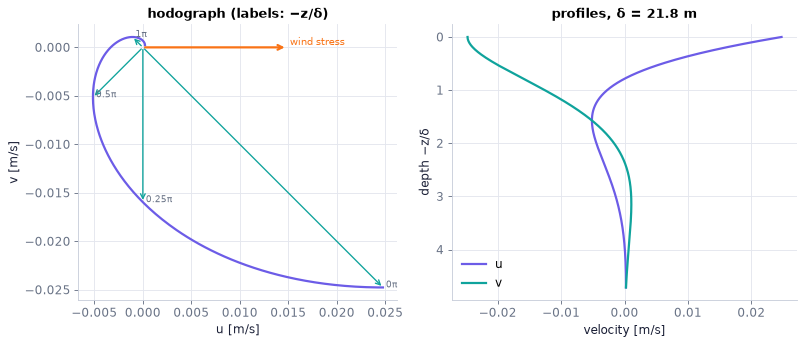

In [56]:
figE = ch13.fig_ekman_surface()                                # hodograph with depth marks + u(z), v(z), for our inputs at 60 N
plt.show()   # display the figure

**What you see.** Left: the tip of the current vector at each depth (the hodograph), starting 45° to the right of the eastward wind and winding clockwise into the origin. Right: the two velocity components against depth in units of $\delta$.

**How to read it.** The surface arrow is 45° to the right of the wind (northern hemisphere, $f>0$; mirror for $f<0$); one $\delta$ down it has turned one more radian and shrunk by $e$.

**What would change if…** …$\nu_v$ were four times larger? The spiral would reach twice as deep and the surface current would halve (the slider figure below).

In [57]:
figSp = go.Figure()                                            # the spiral in three dimensions
z16 = np.linspace(0.0, -4*delta, 17)                           # 17 depths from the surface down to 4 delta [m]
for j, (f_, nm) in enumerate(((f60, "60° N"), (-f60, "60° S"))):   # two hemispheres
    uu_, vv_ = GFD.ekman_surface(z16, tau, 0.0, rho_o, nu_o, f_)   # current at the 17 depths [m/s]
    xs, ys, zs = [], [], []                                    # coordinates of the arrows (as line segments)
    for a_, b_, c_ in zip(uu_, vv_, z16):                      # one arrow per depth, from the axis to the tip
        xs += [0.0, a_*100, None]; ys += [0.0, b_*100, None]; zs += [c_, c_, None]   # in cm/s; None breaks the line
    figSp.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode="lines", line=dict(color=COLORS["teal"], width=5), name=f"current vectors, {nm}", visible=(j == 0)))   # the arrows
    figSp.add_trace(go.Scatter3d(x=uu_*100, y=vv_*100, z=z16, mode="lines", line=dict(color=COLORS["accent"], width=3), name="spiral through the tips", visible=(j == 0)))   # the curve
figSp.add_trace(go.Scatter3d(x=[0, 3.5], y=[0, 0], z=[0, 0], mode="lines+text", text=["", "wind"], line=dict(color=COLORS["orange"], width=8), name="wind stress (eastward)"))   # the wind
figSp.update_layout(height=520, title="The current turns and fades with depth",
                    updatemenus=[dict(x=0.0, y=1.08, xanchor="left", buttons=[
                        dict(label="60° N (f > 0)", method="update", args=[{"visible": [True, True, False, False, True]}]),
                        dict(label="60° S (f < 0)", method="update", args=[{"visible": [False, False, True, True, True]}])])],
                    scene=dict(xaxis_title="u east [cm/s]", yaxis_title="v north [cm/s]", zaxis_title="z [m]"), margin=dict(l=0, r=0, t=60, b=0))   # axes and the hemisphere dropdown
figSp.show()   # display the interactive figure (the slider works on the web page too)

**What does the code above do?**

1. For each hemisphere the current is computed at 17 depths and drawn as horizontal arrows from the vertical axis.
2. The purple curve joins the arrow tips: the Ekman spiral. The dropdown switches hemisphere.

**What you see.** Horizontal current arrows at 17 depths under an eastward wind (orange), and the spiral through their tips.

**How to read it.** Going down, the arrow shortens and swings clockwise in the northern hemisphere ($f>0$); choose 60° S to see it swing counter-clockwise.

**What would change if…** …you rotate the picture to look straight down? You see the hodograph of the figure above.

In [58]:
z_f4 = np.linspace(-150.0, 0.0, 76)                            # depths [m]
M_fixed = GFD.ekman_transport(tau, 0.0, rho_o, f60)            # Eq. (13.30): the transport (M_x, M_y) [m^2/s] — no nu_v in it

def f4(log_nu):                                                # hodograph for one eddy viscosity, nu_v = 10**log_nu [m^2/s]
    uu_, vv_ = GFD.ekman_surface(z_f4, tau, 0.0, rho_o, 10**log_nu, f60)   # the spiral for this nu_v
    return {"hodograph (tip of the current at each depth)": (uu_*100, vv_*100),   # hand the result back to the caller
            "surface current": ([0.0, uu_[-1]*100], [0.0, vv_[-1]*100]),
            f"direction of the transport, τ/(ρf) = {abs(M_fixed[1]):.3f} m²/s — does not change": ([0.0, 0.0], [0.0, -6.0])}

figF4 = slider_figure(f4, "log10 of ν_v [m²/s]", np.round(np.linspace(np.log10(0.005), np.log10(0.3), 25), 3), xlabel="u east [cm/s]",
                      ylabel="v north [cm/s]", title="More mixing: a deeper, slower spiral — the same transport",
                      xrange=(-2, 9), yrange=(-9, 2))          # 25 slider positions, logarithmically spaced
figF4.show()   # display the interactive figure (the slider works on the web page too)
for nu_ in (0.0075, 0.03, 0.12):                               # three eddy viscosities, each four times the last [m^2/s]
    us_, vs_ = GFD.ekman_surface(0.0, tau, 0.0, rho_o, nu_, f60)   # surface current
    print(f"nu_v = {nu_:6.4f} m^2/s: delta = {GFD.ekman_depth(nu_, f60):5.2f} m, surface speed = {np.hypot(us_, vs_):.5f} m/s, transport = {M_fixed[1]:+.4f} m^2/s")   # delta doubles, speed halves

nu_v = 0.0075 m^2/s: delta = 10.90 m, surface speed = 0.07003 m/s, transport = -0.5397 m^2/s
nu_v = 0.0300 m^2/s: delta = 21.80 m, surface speed = 0.03502 m/s, transport = -0.5397 m^2/s
nu_v = 0.1200 m^2/s: delta = 43.59 m, surface speed = 0.01751 m/s, transport = -0.5397 m^2/s


**What does the code above do?**

1. `f4` returns the hodograph for one value of $\nu_v$ (the slider is logarithmic), the surface current as a line from the
   origin, and a fixed arrow in the direction of the total transport.
2. The printed lines quadruple $\nu_v$ twice: $\delta$ doubles each time, the surface speed halves, the transport does not move.

**What you see.** The hodograph for the chosen eddy viscosity. As $\nu_v$ grows the spiral shrinks toward the origin (slower currents); the transport arrow, pointing 90° to the right of the wind, stays where it is.

**How to read it.** The eddy viscosity sets how deep the spiral reaches ($\delta\propto\sqrt{\nu_v}$) and how fast the surface moves ($\propto1/\sqrt{\nu_v}$) — their product, the transport, is independent of it.

**What would change if…** …the latitude were lower? Smaller $f$: a thicker layer and a larger transport, $\tau/(\rho f)$.

📝 **Note.** **N33 [B]** **A pressure gradient only shifts the spiral.** The problem is linear, so a horizontal pressure gradient merely adds a
depth-independent geostrophic velocity to the solution.

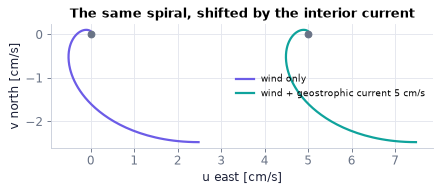

In [59]:
u_g0, v_g0 = GFD.ekman_surface(z_e, tau, 0.0, rho_o, nu_o, f60)                # no interior flow
u_g1, v_g1 = GFD.ekman_surface(z_e, tau, 0.0, rho_o, nu_o, f60, U_g=0.05)      # with a geostrophic interior current of 0.05 m/s eastward
fig, ax = plt.subplots(figsize=(5.4, 3.8))   # a new figure and its panel(s); figsize in inches
ax.plot(u_g0*100, v_g0*100, color=COLORS["accent"], label="wind only")         # hodograph without interior flow
ax.plot(u_g1*100, v_g1*100, color=COLORS["teal"], label="wind + geostrophic current 5 cm/s")   # the same curve, shifted
ax.plot([0, 5], [0, 0], "o", color=COLORS["muted"])                            # the two deep-water end points
ax.set(xlabel="u east [cm/s]", ylabel="v north [cm/s]", title="The same spiral, shifted by the interior current", aspect="equal")   # axis labels (with units), title and fixed ranges of this panel
ax.legend(fontsize=8)   # the legend names every curve
plt.show()   # display the figure

**What you see.** Two hodographs: the wind-driven spiral, and the same spiral with a uniform geostrophic current added.

**How to read it.** The second curve is the first one moved 5 cm/s to the east; it ends at the interior velocity instead of at zero.

**What would change if…** …the interior current were northward? The spiral would shift north instead.

📝 **Note.** **N35 [B]** **Why the layer does not grow.** With the horizontal vorticity components $\omega_x=-\dfrac{dv}{dz}$, $\omega_y=\dfrac{du}{dz}$,
the balance reads $-f\dfrac{dv}{dz}=\nu_v\dfrac{d^2\omega_y}{dz^2}$ and $-f\dfrac{du}{dz}=\nu_v\dfrac{d^2\omega_x}{dz^2}$ (13.31):
tilting of the planetary vorticity — the $(\boldsymbol\omega+2\boldsymbol\Omega)\cdot\nabla\mathbf u$ term of Chapter 5's
$\frac{D\boldsymbol\omega}{Dt}=(\boldsymbol\omega+2\boldsymbol\Omega)\cdot\nabla\mathbf u+\frac1{\rho^2}\nabla\rho\times\nabla p+\nu\nabla^2\boldsymbol\omega$ (5.30)
— balances the downward diffusion of horizontal vorticity. The result is stated; the cell draws the two sides.

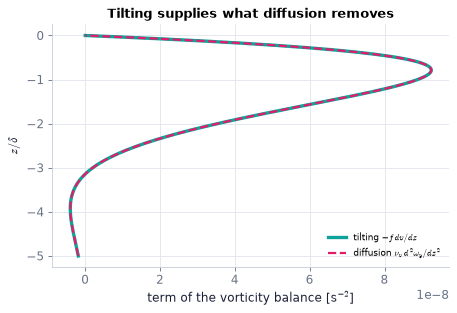

largest difference between the two curves: 2.6e-23 1/s^2


In [60]:
vb = GFD.ekman_vorticity_balance(z_e, tau, rho_o, nu_o, f60)   # the two sides of Eq. (13.31) from the closed-form spiral
fig, ax = plt.subplots(figsize=(5.6, 3.8))   # a new figure and its panel(s); figsize in inches
ax.plot(vb["tilt_x"], z_e/delta, color=COLORS["teal"], lw=3, label=r"tilting $-f\,dv/dz$")   # tilting of planetary vorticity (Coriolis colour)
ax.plot(vb["diff_x"], z_e/delta, "--", color=COLORS["rose"], label=r"diffusion $\nu_v\,d^2\omega_y/dz^2$")   # diffusion of vorticity (friction colour)
ax.set(xlabel="term of the vorticity balance [s$^{-2}$]", ylabel=r"$z/\delta$", title="Tilting supplies what diffusion removes")   # axis labels (with units), title and fixed ranges of this panel
ax.legend(fontsize=8)   # the legend names every curve
plt.show()   # display the figure
print(f"largest difference between the two curves: {abs(vb['tilt_x'] - vb['diff_x']).max():.1e} 1/s^2")   # round-off

**What you see.** The two sides of the first vorticity balance against depth: tilting of planetary vorticity (teal) and diffusion of horizontal vorticity (rose, dashed).

**How to read it.** The curves coincide at every depth. Without rotation there is no tilting term, nothing can balance the diffusion, and the layer keeps thickening as in Chapter 8.

**What would change if…** …$f\to0$? The tilting term vanishes and the steady solution disappears with it ($\delta\to\infty$).

**What would change if…** …we do not care about the shape of the spiral, only about how much water moves? Then we should add the arrows up — and the
eddy viscosity drops out (`C05`).

### 🧩 Ekman transport: $\displaystyle\int_{-\infty}^{0}u\,dz=0$ and $\displaystyle\int_{-\infty}^{0}v\,dz=-\dfrac{\tau}{\rho f}$ (13.30) `C05`

*The question:* Summed over the whole layer, where does the wind-driven water go — and what happens at a coast?

#### The problem in plain words

Off Peru and California the wind blows toward the equator along the coast, and the water at the shore is cold and full of
fish. The wind is not pulling the cold water up; it is moving the surface water *offshore*, at right angles to itself, and
deeper water has to rise to replace it. The same sideways transport, driven by the trade winds and the westerlies, piles water
up in the middle of each ocean basin and sets the great gyres turning.

#### The idea

Add up all the arrows of the spiral. The along-wind parts cancel; what is left points 90° to the right of the wind (northern
hemisphere, $f>0$; to the left for $f<0$). Reason in one line: over the whole layer the only horizontal forces are the wind
stress on top and the Coriolis force on the total transport — they must cancel, and the Coriolis force is at right angles to
the transport.

> 📎 **Primer — depth-integrated quantities: transport per unit width [m²/s] and its divergence as a vertical velocity.** `P313` · Integrating a velocity over depth gives a transport per unit width, in m²/s: the volume crossing a one-metre-wide gate each
second. If more leaves a column sideways than enters, the difference must come through its top or bottom: the divergence of the
transport [m/s] is a vertical velocity.

In [61]:
z = np.linspace(-100, 0, 1001)            # depth [m]
u = 0.1*np.exp(z/20)                      # a current that decays with depth [m/s]
print("transport =", round(np.trapezoid(u, z), 3), "m^2/s")   # 1.987 (exactly 0.1*20*(1 - e^-5))

transport = 1.987 m^2/s


> 📎 **Primer — first integral: integrating an ODE once across a layer to get a transport without solving it.** `P312` · If an equation says "something = d(flux)/dz", integrating across the layer gives "total something = flux at the top − flux at
the bottom". You need the flux only at the two ends, not the solution in between.

In [62]:
tau_top, tau_bottom, rho, f = 0.07, 0.0, 1027.0, 1.0e-4   # stress at the surface and at depth [N/m^2], density, Coriolis parameter
print("y-transport =", round(-(tau_top - tau_bottom)/(rho*f), 3), "m^2/s")   # with no profile in sight

y-transport = -0.682 m^2/s


> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **integral of an exponential over a half-line** — $\int_{-\infty}^0e^{az}\,dz=1/a$ whenever the real part of $a$ is positive, because the integrand dies away at the far end. *(Ch. 5, P144)*
- **`np.trapezoid`** — `np.trapezoid(y, x)` integrates sampled data by joining the samples with straight lines. *(Ch. 1, P37)*
- **Ekman layer with K_v(z); finite-volume tridiagonal solve; `GFD.ekman_solve`** — a second-order boundary-value problem on a grid couples each node to its two neighbours only, so it is one tridiagonal (banded) linear solve. *(Ch. 8, P193)*

#### 🧮 Derivation — Ekman transport, two ways `D07` ★★ (Eq. 13.30: $\int_{-\infty}^{0}u\,dz=0,\ \ \int_{-\infty}^{0}v\,dz=-\frac{\tau}{\rho f}$)

**What we want to show.** Add up the currents of the whole layer — and discover that the answer does not depend on the eddy viscosity.

**Assumptions.** The stress vanishes at depth (step 7) — nothing else in the second route.

**The plan.**

1. Integrate the complex velocity over depth.
2. Simplify the constants.
3. Read off the two components.
4. Do it again without the solution, by integrating the momentum balance once.

**Tools we use** (each explained before this point): the integral of an exponential over a half-line (P144, reminder) · transport per unit width (P313) · first integral of an ODE (P312)

**We start from**

$$ V=A\,e^{(1+i)z/\delta}\ \text{with}\ A=\dfrac{\tau\delta(1-i)}{2\rho\nu_v}\ \text{(the Result of D06)} $$

*In words:* The spiral

---

**Step 1 of 8 — Define the transport as an integral.**

$$ M\equiv\displaystyle\int_{-\infty}^0V\,dz=A\displaystyle\int_{-\infty}^0e^{(1+i)z/\delta}\,dz $$

- *Why we can do this:* Transport per unit width is velocity summed over depth; A is constant and leaves the integral.
- *In words:* Add all the arrows of the spiral.

---

**Step 2 of 8 — Integrate the exponential.**

$$ M=\dfrac{A\delta}{1+i} $$

- *Why we can do this:* An antiderivative of $e^{az}$ is $e^{az}/a$ with $a=(1+i)/\delta$; it is 1/a at z = 0 and tends to zero as z → −∞ because the real part of a is positive.
- *In words:* The sum is finite: the arrows shrink fast enough.

---

**Step 3 of 8 — Insert A.**

$$ M=\dfrac{\tau\delta^2(1-i)}{2\rho\nu_v(1+i)} $$

- *Why we can do this:* Substitution of the constant found in D06.
- *In words:* Everything is now in terms of the wind stress and the layer's properties.

---

**Step 4 of 8 — Simplify.**

$$ M=-\dfrac{i\,\tau}{\rho f} $$

- *Why we can do this:* Two facts: $(1-i)/(1+i)=-i$ and $\delta^2=2\nu_v/f$; the eddy viscosity cancels exactly.
- *In words:* The transport is purely imaginary: all of it is in the y-direction.

---

**Step 5 of 8 — Separate the components.**

$$ \displaystyle\int_{-\infty}^0u\,dz=0,\qquad\displaystyle\int_{-\infty}^0v\,dz=-\dfrac{\tau}{\rho f}\ \text{(13.30)} $$

- *Why we can do this:* Real part and imaginary part of M = ∫u dz + i∫v dz.
- *In words:* No net transport along the wind; τ/(ρf) at right angles to it, to the right for f > 0.

---

**Step 6 of 8 — Start again from the momentum balance in stress form.**

$$ -\rho fv=\dfrac{d\tau_x}{dz},\qquad\rho fu=\dfrac{d\tau_y}{dz} $$

- *Why we can do this:* This is the Start of D06 with the stress components $\tau_x=\rho\nu_v\,du/dz$, $\tau_y=\rho\nu_v\,dv/dz$ left unexpanded — true for *any* relation between stress and shear.
- *In words:* The Coriolis force on a slab equals the difference of the stresses on its top and bottom.

---

**Step 7 of 8 — Integrate the first over the layer.**

$$ -\rho f\displaystyle\int_{-\infty}^0v\,dz=\tau_x(0)-\tau_x(-\infty)=\tau $$

- *Why we can do this:* The integral of a derivative is the difference of its end values (a first integral); the stress is the wind stress on top and zero at depth.
- *In words:* The whole layer's Coriolis force balances the wind stress.

---

**Step 8 of 8 — Integrate the second.**

$$ \rho f\displaystyle\int_{-\infty}^0u\,dz=\tau_y(0)-\tau_y(-\infty)=0 $$

- *Why we can do this:* There is no stress in the y-direction at either end. No eddy-viscosity model was used in steps 6–8.
- *In words:* The same answer without ever solving for the spiral.

---

**Result**

$$ \displaystyle\int_{-\infty}^0u\,dz=0\ \text{,}\ \displaystyle\int_{-\infty}^0v\,dz=-\dfrac{\tau}{\rho f} $$

*In words:* The wind-driven transport is τ/(ρf), 90° to the right of the wind in the northern hemisphere, 90° to the left in the southern (f < 0 changes its sign), whatever the eddy viscosity

**What it means.** a wind along a coast moves water offshore or onshore (upwelling, downwelling); a wind with curl makes the transport converge or diverge (D09). **Fails when:** the layer feels the bottom (stress not zero at depth), or f → 0.

**Check it.** Units — (N/m²)/(kg/m³ · s⁻¹) = m²/s ✓. Number — τ = 0.07 N/m², ρ = 1027 kg/m³, 60° N: 0.540 m²/s; with ν_v four times larger: the same. Partial sums — above z = −δ the transport has 86 % of its final size. Code — `np.trapezoid` over `GFD.ekman_surface` for two ν_v.

> ⚠️ **Common confusion (traps in `D07`):** Direction flips with the sign of f; this is a volume transport per unit width [m²/s] — the mass transport is ρ times it; the transport relative to an interior geostrophic flow is unchanged by that flow.

📝 **Note.** **N32 [B]** **The transport does not depend on the turbulence model.** The second route of `D07` (steps 6–8) integrates
$-\rho fv=\dfrac{d\tau}{dz}$ once; only "the stress vanishes at depth" is used, so the result holds for any eddy viscosity,
constant or not.

#### ✏️ Tiny example: how much water, and which way

A stress $\tau=0.1$ N/m² toward the east, $\rho=1000$ kg/m³, $f=10^{-4}$ s⁻¹.

1. Transport $\int v\,dz=-\tau/(\rho f)=-0.1/(1000\times10^{-4})=-1$ m²/s: one cubic metre per second through every metre of
   an east–west line, toward the **south** (to the right of the wind).
2. Along a 1000 km line: $10^{6}$ m³/s = 1 Sverdrup.
3. Southern hemisphere ($f=-10^{-4}$ s⁻¹): +1 m²/s, toward the north — to the left of the wind.
4. Double the eddy viscosity: same answer.

In [63]:
Mx, My = GFD.ekman_transport(tau, 0.0, rho_o, f60)             # Eq. (13.30): total transport under an eastward stress at 60 N [m^2/s]
Md = complex(*GFD.ekman_transport_partial(-delta, tau, 0.0, rho_o, nu_o, f60))        # transport carried between z = -delta and the surface
Mp = complex(*GFD.ekman_transport_partial(-np.pi*delta, tau, 0.0, rho_o, nu_o, f60))  # the same down to the Ekman depth pi*delta
print(f"total transport (M_x, M_y) = ({Mx:+.4f}, {My:+.4f}) m^2/s: at right angles to the wind, to its right (60 N)")   # nothing along the wind
print(f"above z = -delta:    {100*abs(Md)/abs(My):.0f} % of the magnitude, direction {np.degrees(np.angle(Md)):.0f} deg (final: -90 deg)")   # not yet in the final direction
print(f"above z = -pi delta: {100*abs(Mp)/abs(My):.0f} % of the magnitude (a small overshoot, removed by the opposed currents below)")   # 104 %

total transport (M_x, M_y) = (+0.0000, -0.5397) m^2/s: at right angles to the wind, to its right (60 N)
above z = -delta:    86 % of the magnitude, direction -69 deg (final: -90 deg)
above z = -pi delta: 104 % of the magnitude (a small overshoot, removed by the opposed currents below)


**What does the code above do?**

1. `GFD.ekman_transport(tau_x, tau_y, rho, f)` is $\int u\,dz=0$, $\int v\,dz=-\tau/(\rho f)$ *(13.30)* for any wind direction.
2. `GFD.ekman_transport_partial` is the running integral from a depth up to the surface (ours, a closed form): the top
   $\delta$ carries most of the magnitude but not yet in the final direction.
3. Down to $\pi\delta$ the running transport slightly exceeds the total; the weak, backward currents below bring it back.

In [64]:
# From scratch: add the arrows up numerically, for two very different eddy viscosities
for nu_ in (0.03, 0.12):                                       # nu_v and four times nu_v [m^2/s]
    d_ = GFD.ekman_depth(nu_, f60)                             # the layer thickness for this nu_v [m]
    zz = np.linspace(-40*d_, 0.0, 40001)                       # a grid that reaches far below the layer
    uu_, vv_ = GFD.ekman_surface(zz, tau, 0.0, rho_o, nu_, f60)   # the spiral
    Mx_num, My_num = np.trapezoid(uu_, zz), np.trapezoid(vv_, zz) # the two transports by the trapezoid rule [m^2/s]
    assert np.isclose(My_num, My, rtol=1e-4) and abs(Mx_num) < 1e-6   # same as Eq. (13.30), whatever nu_v is
    print(f"✓ nu_v = {nu_:.2f}: delta = {d_:.2f} m, surface speed = {np.hypot(uu_[-1], vv_[-1]):.5f} m/s, integrated transport = ({Mx_num:+.1e}, {My_num:+.4f}) m^2/s")   # visible confirmation

✓ nu_v = 0.03: delta = 21.80 m, surface speed = 0.03502 m/s, integrated transport = (+9.0e-08, -0.5397) m^2/s
✓ nu_v = 0.12: delta = 43.59 m, surface speed = 0.01751 m/s, integrated transport = (+9.0e-08, -0.5397) m^2/s


**What does the code above do?**

Numerical integration of the spiral gives the closed-form transport for both eddy viscosities: $\delta$ doubles, the surface
speed halves, the transport stays at $-\tau/(\rho f)$.

📝 **Note.** **N37 [B]** **Not in the book — ours** (the book remarks that the constant-viscosity spiral is rarely observed): the layer with a
depth-dependent eddy viscosity, $\dfrac{d}{dz}\Big(K_v\dfrac{dV}{dz}\Big)=if\,(V-V_g)$, solved numerically by `GFD.ekman_solve`.

> 🔧 **Our choice** — a second-order finite-volume scheme on a stretched grid with $K_v$ at the cell faces, one complex tridiagonal solve (the
pattern of Chapter 12's eddy-viscosity solver).

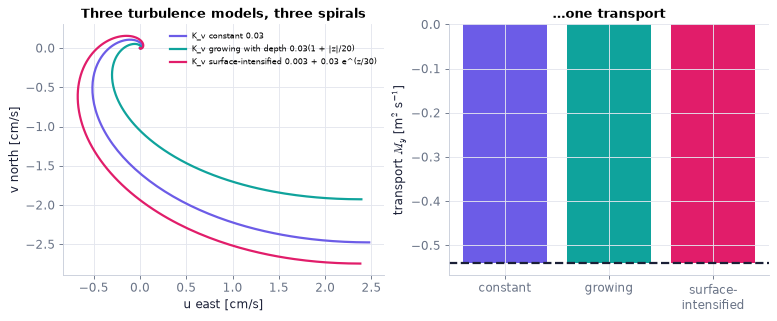

K_v constant 0.03: M_y = -0.5397 m^2/s (+0.00 % from -tau/(rho f)), M_x = +0.0000
K_v growing with depth 0.03(1 + |z|/20): M_y = -0.5399 m^2/s (+0.04 % from -tau/(rho f)), M_x = +0.0005
K_v surface-intensified 0.003 + 0.03 e^(z/30): M_y = -0.5397 m^2/s (+0.00 % from -tau/(rho f)), M_x = -0.0000
constant K_v: numerical vs closed-form spiral, max difference = 6.1e-05 of the surface speed


In [65]:
z_k = -600.0*np.linspace(1.0, 0.0, 401)**2                     # 401 nodes from -600 m to the surface, crowded near the surface [m]
profiles = {"constant 0.03": lambda zf: 0.03 + 0*zf,           # three eddy-viscosity profiles K_v(z) [m^2/s], given at the cell faces
            "growing with depth 0.03(1 + |z|/20)": lambda zf: 0.03*(1 + abs(zf)/20.0),
            "surface-intensified 0.003 + 0.03 e^(z/30)": lambda zf: 0.003 + 0.03*np.exp(zf/30.0)}
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.9))   # a new figure and its panel(s); figsize in inches
M_num = {}                                                     # the three numerical transports
for (nm, Kf), col in zip(profiles.items(), (COLORS["accent"], COLORS["teal"], COLORS["rose"])):   # one curve per profile
    Vk = GFD.ekman_solve(z_k, Kf, f60, tau=tau + 0j, rho=rho_o)   # complex velocity u + iv at the nodes [m/s]
    M_num[nm] = np.trapezoid(Vk, z_k)                          # its depth integral: the transport M_x + i M_y [m^2/s]
    a.plot(Vk.real*100, Vk.imag*100, color=col, label=f"K_v {nm}")   # hodograph
a.set(xlabel="u east [cm/s]", ylabel="v north [cm/s]", title="Three turbulence models, three spirals")   # axis labels (with units), title and fixed ranges of this panel
a.legend(fontsize=7)   # the legend names every curve
b.bar(range(3), [m_.imag for m_ in M_num.values()], color=[COLORS["accent"], COLORS["teal"], COLORS["rose"]])   # the three transports
b.axhline(My, color=COLORS["ink"], ls="--")                    # the closed-form value -tau/(rho f)
b.set_xticks(range(3), ["constant", "growing", "surface-\nintensified"])   # the names of the profiles
b.set(ylabel="transport $M_y$ [m$^2$ s$^{-1}$]", title="…one transport")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure
for nm, m_ in M_num.items():                                   # compare each numerical transport with -tau/(rho f)
    print(f"K_v {nm}: M_y = {m_.imag:+.4f} m^2/s ({100*(m_.imag/My - 1):+.2f} % from -tau/(rho f)), M_x = {m_.real:+.4f}")   # the measured agreement
V_const = GFD.ekman_solve(z_k, profiles["constant 0.03"], f60, tau=tau + 0j, rho=rho_o)   # the constant case once more
u_ex, v_ex = GFD.ekman_surface(z_k, tau, 0.0, rho_o, 0.03, f60)   # its closed form
print(f"constant K_v: numerical vs closed-form spiral, max difference = {abs(V_const - (u_ex + 1j*v_ex)).max()/np.hypot(u_ex[-1], v_ex[-1]):.1e} of the surface speed")   # scheme accuracy

**What you see.** Left: hodographs for three eddy-viscosity profiles — very different shapes and surface angles. Right: their depth-integrated transports, with the dashed line at $-\tau/(\rho f)$.

**How to read it.** The shape of the spiral belongs to the turbulence model; the transport belongs to Newton's law. The printed lines give the measured agreement of each numerical transport with the closed form.

**What would change if…** …the water were only a few $\delta$ deep? Then the stress would not vanish at the bottom and the transport would change (note N34 in `C06`).

#### 🧮 Derivation — Ekman pumping: $w_E=\frac1\rho\,\mathbf e_z\cdot\nabla\times(\boldsymbol\tau/f)$ and $w=\frac\delta2\zeta_g$ `D09` ★★

**What we want to show.** Find the vertical velocity that a non-uniform Ekman transport forces at the edge of the layer. **Not in the book — ours** (the book gives only the consequence: rising air in a low).

**Assumptions.** The layer is thin, so the transport formula holds locally (step 1); f varies slowly across the wind pattern (step 5); the mean sea surface is level, w(0) = 0 (step 3).

**The plan.**

1. Integrate continuity over the layer.
2. Recognise the divergence of the transport.
3. Insert the transport.
4. Repeat for the bottom layer.

**Tools we use** (each explained before this point): depth integration (P313) · divergence and curl of a horizontal vector (Ch. 2, reminder)

**We start from**

$$ \begin{array}{l}\text{the transport of D07 for a stress in any direction,}\ \mathbf M=\dfrac1{\rho f}(\tau_y,\ -\tau_x)\ \text{(the vector} \\ \text{form of}\ \int_{-\infty}^0u\,dz=0\ \text{,}\ \int_{-\infty}^0v\,dz=-\dfrac\tau{\rho f}\ \text{(13.30)), and continuity} \\ \dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}=0\end{array} $$

*In words:* Transport at right angles to the stress; mass is conserved

---

**Step 1 of 7 — Write the transport as a vector.**

$$ \mathbf M=\dfrac1{\rho f}\big(\tau_y,\ -\tau_x\big) $$

- *Why we can do this:* D07 for a stress along x gave (0, −τ/ρf); a stress along y gives (τ/ρf, 0) by rotating the axes; the problem is linear, so the two add.
- *In words:* The transport is the stress turned 90° to the right (f > 0), divided by ρf.

---

**Step 2 of 7 — Integrate continuity over the layer.**

$$ \displaystyle\int_{-D}^0\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)dz+w(0)-w(-D)=0 $$

- *Why we can do this:* The integral of ∂w/∂z is the difference of w between top and bottom of the layer, taken at a depth D of several δ.
- *In words:* What leaves sideways must be replaced from below.

---

**Step 3 of 7 — Take the derivatives outside.**

$$ \dfrac{\partial M_x}{\partial x}+\dfrac{\partial M_y}{\partial y}=w(-D) $$

- *Why we can do this:* The limits do not depend on x or y, so differentiation and integration swap; and w(0) = 0 at the level sea surface.
- *In words:* The divergence of the transport is the upward velocity at the base of the layer.

---

**Step 4 of 7 — Name it.**

$$ w_E\equiv w(-D)=\nabla\cdot\mathbf M $$

- *Why we can do this:* A definition: the Ekman pumping velocity (positive = upward, "suction").
- *In words:* A diverging surface layer sucks water up.

---

**Step 5 of 7 — Insert the transport.**

$$ w_E=\dfrac1\rho\Big[\dfrac{\partial}{\partial x}\Big(\dfrac{\tau_y}{f}\Big)-\dfrac{\partial}{\partial y}\Big(\dfrac{\tau_x}{f}\Big)\Big]=\dfrac1\rho\,\mathbf e_z\cdot\nabla\times\Big(\dfrac{\boldsymbol\tau}{f}\Big) $$

- *Why we can do this:* Step 1 into step 4; the combination is the vertical component of a curl.
- *In words:* Pumping is set by the curl of the wind stress.

---

**Step 6 of 7 — Write the bottom layer's transport.**

$$ \mathbf M'=\displaystyle\int_0^\infty(\mathbf u-\mathbf u_g)\,dz=\dfrac\delta2\big(-U_g-V_g,\ U_g-V_g\big) $$

- *Why we can do this:* From D08, with the complex geostrophic velocity written $W_g\equiv U_g+iV_g$, $\int(V-W_g)\,dz=-W_g\delta/(1+i)=\tfrac\delta2(-1+i)W_g$; only this frictional part can diverge (the geostrophic part does not, D03 step 6).
- *In words:* Half a layer thickness of flow is diverted toward low pressure and against the wind.

---

**Step 7 of 7 — Take its divergence.**

$$ w(\text{top})=-\nabla\cdot\mathbf M'=\dfrac\delta2\Big(\dfrac{\partial V_g}{\partial x}-\dfrac{\partial U_g}{\partial y}\Big)=\dfrac\delta2\,\zeta_g $$

- *Why we can do this:* Continuity over the bottom layer with w = 0 at the ground; the terms $\partial U_g/\partial x+\partial V_g/\partial y$ vanish because the geostrophic flow is non-divergent.
- *In words:* A cyclone pumps air up out of the friction layer at half a layer thickness times its vorticity.

---

**Result**

$$ \begin{array}{l}w_E=\dfrac1\rho\,\mathbf e_z\cdot\nabla\times\Big(\dfrac{\boldsymbol\tau}{f}\Big)\ \text{(surface layer) and}\ w=\dfrac\delta2\zeta_g\ \text{(bottom layer, f > 0;} \\ \text{in general}\ w=\mathrm{sgn}(f)\dfrac\delta2\zeta_g\ \text{with}\ \delta=\sqrt{2\nu_v/\lvert f\rvert}\ \text{)}\end{array} $$

*In words:* Cyclonic forcing pumps upward, in both hemispheres

**What it means.** The winds of a subtropical gyre (easterlies equatorward, westerlies poleward) push surface water toward its middle and pump it down; the interior responds by moving equatorward (Sverdrup balance, one line in C05). **Fails when:** f → 0 (the equator: upwelling there needs its own argument), or the wind varies on the scale of δ.

**Check it.** Units — (N/m²)/(kg/m³ · s⁻¹ · m) = m/s ✓; δζ = m/s ✓. Number — a stress changing by 0.07 N/m² over 1000 km at 35° N: 8.1 × 10⁻⁷ m/s ≈ 26 m per year; bottom layer with δ = 333 m, ζ_g = 10⁻⁵ s⁻¹: 1.66 mm/s. Hemisphere — a southern low has ζ_g < 0 and f < 0: w > 0 again.

> ⚠️ **Common confusion (traps in `D09`):** The sign — cyclonic stress curl gives upwelling for f > 0; keeping df/dy inside the curl is the first step toward Sverdrup balance and is not pursued; surface and bottom layers pump with opposite roles (one drives the interior, the other is driven by it).

📝 **Note.** **N36 [B]** **Not in the book — ours** (the book gives only the consequence, rising air in a low): Ekman pumping
$w_E=\dfrac1\rho\,\mathbf e_z\cdot\nabla\times\Big(\dfrac{\boldsymbol\tau}{f}\Big)$ under a surface layer, and
$w=\dfrac\delta2\zeta_g$ above a bottom layer (`D09`). One line, labelled beyond the book: **Sverdrup balance** — in the
interior below the surface layer, stretching by this pumping is balanced by moving columns north or south,
$\beta V=f\,w_E$ per unit width (depth-integrated, with no vertical velocity at depth): the wind's curl sets the north–south
transport of a whole gyre.

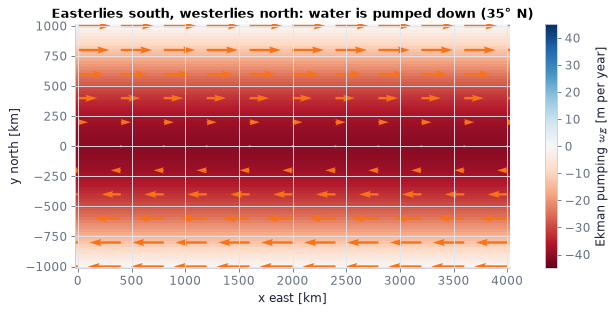

open ocean: strongest pumping = -1.28e-06 m/s = -40 m per year (downward)
coast: offshore transport = 0.815 m^2/s, upwelling: True; fed over a 40 km strip -> w = 2.0e-05 m/s = 1.8 m per day


In [66]:
xg2 = np.linspace(0.0, 4.0e6, 81); yg2 = np.linspace(-1.0e6, 1.0e6, 81)   # a band 4000 km long and 2000 km wide [m]
X2, Y2 = np.meshgrid(xg2, yg2)                                 # grids indexed [j, i] = (y, x)
tau_x = -0.07*np.cos(np.pi*(Y2 + 1.0e6)/2.0e6)                 # easterlies in the south, westerlies in the north [N/m^2]
tau_y = np.zeros_like(tau_x)                                   # no north-south stress
wE = GFD.ekman_pumping(tau_x, tau_y, xg2[1] - xg2[0], yg2[1] - yg2[0], rho_o, f35)   # w_E = (1/rho) curl(tau/f) at 35 N [m/s]
fig, ax = plt.subplots(figsize=(7.6, 3.8))   # a new figure and its panel(s); figsize in inches
pm = ax.pcolormesh(xg2/1e3, yg2/1e3, wE*86400*365, cmap="RdBu", shading="auto", vmin=-45, vmax=45)   # pumping in metres per year
ax.quiver(xg2[::8]/1e3, yg2[::8]/1e3, tau_x[::8, ::8], tau_y[::8, ::8], color=COLORS["orange"])   # the wind stress
fig.colorbar(pm, label="Ekman pumping $w_E$ [m per year]")   # the colour scale and what it measures
ax.set(xlabel="x east [km]", ylabel="y north [km]", title="Easterlies south, westerlies north: water is pumped down (35° N)")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure
cu = ch13.coastal_upwelling(-0.07, "east", lat)                # an equatorward wind along an eastern boundary at 35 N
print(f"open ocean: strongest pumping = {wE[1:-1, 1:-1].min():.2e} m/s = {wE[1:-1, 1:-1].min()*86400*365:.0f} m per year (downward)")   # compare pi tau0/(Ly rho f)
print(f"coast: offshore transport = {cu['transport_offshore']:.3f} m^2/s, upwelling: {cu['upwelling']}; fed over a 40 km strip -> w = {cu['transport_offshore']/4.0e4:.1e} m/s = {cu['transport_offshore']/4.0e4*86400:.1f} m per day")   # coastal upwelling

**What you see.** A band of wind stress (orange arrows) that blows westward in the south and eastward in the north — the pattern over a subtropical gyre — and the vertical velocity it forces at the base of the Ekman layer (colour).

**How to read it.** The Ekman transports under the two wind belts point toward each other (each to the right of its wind), the water converges and is pumped **down** everywhere in the band — tens of metres per year. At a coast the same mechanism is far stronger: metres per day (second printed line).

**What would change if…** …the same wind band lay in the southern hemisphere? The transports would point apart and the water would be pumped **up**.

📝 **Note.** **N50 [C]** **Named, not presented.** The wind-driven circulation of the gyres and Stommel's explanation of strong western boundary
currents are mentioned by the book only in passing. Pointer: the Sverdrup line above; any dynamical-oceanography text for the
gyre.

> ▶️ **Live cell.** The widget below needs a running Python kernel. On the web page it is frozen — open this notebook in Colab (button at the top) or run it locally to drag the sliders.

In [67]:
def ekman_live(tau=0.07, nu_v=0.03, lat_deg=60.0):             # free wind stress [N/m^2], eddy viscosity [m^2/s], latitude [degrees, either sign]
    if lat_deg == 0:                                           # on the equator f = 0 and there is no steady Ekman layer
        print("f = 0 on the equator: no steady Ekman layer"); return
    f_ = GFD.coriolis_parameter(np.deg2rad(lat_deg))           # Coriolis parameter at this latitude [1/s]
    d_ = GFD.ekman_depth(nu_v, f_)                             # layer thickness [m]
    zz = np.linspace(-5*d_, 0.0, 200)                          # depths [m]
    uu_, vv_ = GFD.ekman_surface(zz, tau, 0.0, 1027.0, nu_v, f_)   # the spiral
    Mx_, My_ = GFD.ekman_transport(tau, 0.0, 1027.0, f_)       # Eq. (13.30)
    fig, ax = plt.subplots(figsize=(5.2, 4.2))   # a new figure and its panel(s); figsize in inches
    ax.plot(uu_*100, vv_*100, color=COLORS["accent"])          # hodograph
    ax.annotate("", xy=(0, np.sign(My_)*abs(uu_[-1])*100), xytext=(0, 0), arrowprops=dict(color=COLORS["teal"], width=2))   # direction of the transport
    ax.set(xlabel="u east [cm/s]", ylabel="v north [cm/s]", aspect="equal", title=f"δ = {d_:.1f} m, transport = {My_:+.3f} m²/s")   # axis labels (with units), title and fixed ranges of this panel
    plt.show()   # display the figure

_ = live(ekman_live, tau=(0.01, 0.3, 0.01), nu_v=(0.005, 0.3, 0.005), lat_deg=(-80, 80, 5))   # three sliders

interactive(children=(FloatSlider(value=0.155, continuous_update=False, description='tau', layout=Layout(width…

**What does the code above do?**

`live(fn, name=(min, max, step), …)` makes one slider per argument and redraws when you release it. Here: the hodograph and the
direction of the transport (teal arrow) for a free wind stress, eddy viscosity and latitude of either sign. On the web page the
slider figure of `C04` carries the same idea.

#### 🎮 Interactive: The wind blows east — why does the water go south?

**Why interactive rather than a static figure:** orbiting the spiral in 3-D, sliding a depth cursor down the hodograph and watching the running transport swing round to 90° connects three pictures of one solution; changing $\nu_v$ changes $\delta$ and the surface speed and leaves the transport untouched.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Press play: the depth cursor descends and the running transport arrow swings to 90° from the wind.
- Use the preset 'four times ν_v': twice as deep, half as fast at the surface, same transport.
- Switch to S: surface current and transport flip to the left of the wind.
- Choose 'wind along a coast' and read the status: upwelling or downwelling?

In [68]:
show_viz("ch13", "ekman_spiral")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/ekman_spiral]

**What would change if…** …the boundary is solid and the fluid above it is already moving? The same equation with a different boundary condition: the
bottom Ekman layer (`C06`).

---

## 13.7 Ekman Layer on a Rigid Surface

**What is this section about?** The friction layer under a geostrophic flow — the lowest kilometre of the atmosphere, or the
bottom of the ocean. ⚠️ Here $z=0$ is the solid surface and the fluid is $z>0$.

### 🧩 The bottom Ekman layer: $u=U\big[1-e^{-z/\delta}\cos(z/\delta)\big]$, $v=Ue^{-z/\delta}\sin(z/\delta)$ (13.41) `C06`

*The question:* If the wind follows the isobars, why does air spiral into a low?

#### The problem in plain words

Satellite pictures show clouds spiralling *into* a depression, not circling it. Aloft the wind does follow the isobars. But
near the ground friction slows the air; slower air feels a weaker Coriolis force; the pressure force, which does not care about
speed, is no longer cancelled, and the air drifts toward low pressure. Air converging on a low has nowhere to go but up —
clouds and rain. Stir a cup of tea and the leaves collect in the middle for the same reason (Ch. 9).

#### The idea

```
aloft (no friction)                 near the ground (friction)
     LOW                                  LOW
      ↑ pressure force                     ↑ pressure force (unchanged)
      ●━━━▶ wind along the isobar           ●━━▶ slower wind, turned toward LOW
      ↓ Coriolis (equal and opposite)      ↘ Coriolis (shorter, turned with the wind)
                                           ← friction (roughly against the wind) closes the triangle
```

Three forces must add to zero. Aloft two suffice; near the ground the weakened Coriolis force cannot cancel the pressure force
alone, and friction supplies the rest — which is only possible if the wind has a component toward low pressure.

📝 **Note.** **N38 [C]** **The interior is geostrophic:** $fU=-\dfrac1\rho\dfrac{dp}{dy}$ (13.32). It enters the layer problem as the constant $U$.

📝 **Note.** **N39 [B]** **Three forces in the layer:** $-fv=\nu_v\dfrac{d^2u}{dz^2}$ and $fu=\nu_v\dfrac{d^2v}{dz^2}+fU$ (13.33)–(13.34) — the pressure
gradient is hidden in the term $fU$.

📝 **Note.** **N40 [C]** **Far-field condition:** $u=U,\ v=0$ as $z\to\infty$ (13.35).

📝 **Note.** **N41 [C]** **No slip:** $u=0,\ v=0$ at $z=0$ (13.36).

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **particular solution of a forced linear ODE** — the general solution of a forced linear equation is any one solution of the full equation plus the general solution of the unforced one. *(Ch. 1, P44)*

#### 🧮 Derivation — The bottom Ekman layer: the 45° surface angle and the transport ½Uδ `D08` ★★ (Eq. 13.41: $u=U\big[1-e^{-z/\delta}\cos(z/\delta)\big],\ \ v=Ue^{-z/\delta}\sin(z/\delta)$)

**What we want to show.** Find the wind inside the friction layer under a geostrophic flow, and how much air it carries toward low pressure.

**Assumptions.** Constant ν_v; steady; uniform geostrophic interior; flat surface; f > 0 until the Check.

**The plan.**

1. Form the complex equation.
2. Add a particular solution to the homogeneous one of D06.
3. Apply the two conditions.
4. Separate components.
5. Integrate v.

**Tools we use** (each explained before this point): as D06 (P311, P44) · particular solution of a forced linear ODE (P44, reminder) · $\int_0^\infty e^{-s}\sin s\,ds=\tfrac12$ (P144, reminder)

**We start from**

$$ \begin{array}{l}-fv=\nu_v\dfrac{d^2u}{dz^2}\ \text{and}\ fu=\nu_v\dfrac{d^2v}{dz^2}+fU\ \text{(13.33)–(13.34), with}\ u=U\ \text{,}\ v=0\ \text{as}\ z\to\infty\ \text{and}\ u=v=0\ \text{at} \\ \text{z = 0}\end{array} $$

*In words:* Coriolis, friction and a pressure gradient written as fU; geostrophic far above, no slip at the ground

---

**Step 1 of 9 — Combine the two equations.**

$$ \dfrac{d^2V}{dz^2}=\dfrac{if}{\nu_v}(V-U)\ \text{(13.37)} $$

- *Why we can do this:* As in D06: i times the second plus the first; the extra term ifU comes from the pressure gradient.
- *In words:* The same equation as for the ocean layer, now forced by the constant U.

---

**Step 2 of 9 — Find a particular solution.**

$$ V_p=U $$

- *Why we can do this:* A constant has zero second derivative and makes the right side zero: it is the geostrophic flow itself, which needs no friction.
- *In words:* Far from the ground the wind is simply U.

---

**Step 3 of 9 — Add the homogeneous solution.**

$$ V=A\,e^{-(1+i)z/\delta}+B\,e^{(1+i)z/\delta}+U\ \text{(13.40)} $$

- *Why we can do this:* A linear forced equation is solved by a particular solution plus the general solution of the unforced one (D06 step 6), with $\delta=\sqrt{2\nu_v/f}$.
- *In words:* Geostrophic wind plus a correction that can decay or grow upward.

---

**Step 4 of 9 — Apply the far-field condition.**

$$ B=0 $$

- *Why we can do this:* As $z\to+\infty$ the term $e^{z/\delta}$ grows; V must tend to U, so its coefficient vanishes. Note it is the *other* exponential than in D06, because the fluid is now above z = 0.
- *In words:* The correction is confined near the ground.

---

**Step 5 of 9 — Apply no slip.**

$$ A=-U\ \Rightarrow\ V=U\big[1-e^{-(1+i)z/\delta}\big] $$

- *Why we can do this:* At z = 0 the velocity is zero: A + U = 0.
- *In words:* The correction exactly cancels the geostrophic wind at the ground.

---

**Step 6 of 9 — Take real and imaginary parts.**

$$ u=U\big[1-e^{-z/\delta}\cos(z/\delta)\big],\qquad v=Ue^{-z/\delta}\sin(z/\delta)\ \text{(13.41)} $$

- *Why we can do this:* Write $e^{-(1+i)s}=e^{-s}(\cos s-i\sin s)$ with $s=z/\delta$ (Euler's formula).
- *In words:* A component v across the isobars appears — toward low pressure, to the left of U for f > 0.

---

**Step 7 of 9 — Look very near the ground.**

$$ V\approx U(1+i)\dfrac z\delta\quad(z\ll\delta) $$

- *Why we can do this:* First-order Taylor expansion $e^{-(1+i)s}\approx1-(1+i)s$ (P26, reminder).
- *In words:* Close to the surface u = v: the wind blows 45° to the left of the geostrophic wind.

---

**Step 8 of 9 — Integrate the cross-isobar component.**

$$ \displaystyle\int_0^\infty v\,dz=U\delta\displaystyle\int_0^\infty e^{-s}\sin s\,ds $$

- *Why we can do this:* Change the variable to $s=z/\delta$, so $dz=\delta\,ds$; U and δ are constants.
- *In words:* The inflow toward low pressure, summed over the layer.

---

**Step 9 of 9 — Evaluate the integral.**

$$ \displaystyle\int_0^\infty v\,dz=\dfrac12U\delta=U\Big[\dfrac{\nu_v}{2f}\Big]^{1/2} $$

- *Why we can do this:* The integral of $e^{-s}\sin s$ over the half-line is ½ (integrate by parts twice, or take the imaginary part of $\int e^{-(1-i)s}ds=1/(1-i)$).
- *In words:* Half the geostrophic speed times the layer thickness flows toward low pressure.

---

**Result**

$$ \begin{array}{l}u=U\big[1-e^{-z/\delta}\cos(z/\delta)\big]\ \text{,}\ v=Ue^{-z/\delta}\sin(z/\delta)\ \text{— the two members of (13.41); transport}\ \tfrac12U\delta \\ \text{toward low pressure}\end{array} $$

*In words:* Friction lets the wind cross the isobars

**What it means.** Air converges into lows and rises (weather), diverges from highs and sinks; the same inflow, squashing the columns above, spins down every geostrophic vortex. **Fails when:** ν_v varies strongly with height (the real surface layer is logarithmic near the ground, Ch. 12) or the surface is sloping.

**Check it.** Units — Uδ [m²/s] ✓. Limits — z → ∞: (U, 0); z = 0: (0, 0). **The overshoot (stated correctly):** du/dz = 0 where cos s + sin s = 0, first at s = 3π/4, so the largest u is at z = 3πδ/4 with $u/U=1+e^{-3\pi/4}/\sqrt2=1.0670$; at z = πδ, where v first returns to zero, $u/U=1+e^{-\pi}=1.0432$. Number — 60° N, U = 12 m/s, ν_v = 7 m²/s: δ = 332.9 m, transport 1998 m²/s. Hemisphere — f < 0: v changes sign (to the right of U), still toward low pressure.

> ⚠️ **Common confusion (traps in `D08`):** A = −U and B = 0 — the dropped exponential is the one that grows *upward* here; "to the left of the geostrophic wind" is f > 0 only; the pressure gradient is hidden in the term fU; the maximum of u is at 3πδ/4, not at πδ.

📝 **Note.** **N42 [B]** **Complex form** (step 2 of `D08`): $\dfrac{d^2V}{dz^2}=\dfrac{if}{\nu_v}(V-U)$ (13.37).

📝 **Note.** **N43 [C]** **Its far-field condition:** $V=U$ as $z\to\infty$ (13.38).

📝 **Note.** **N44 [C]** **Its no-slip condition:** $V=0$ at $z=0$ (13.39).

📝 **Note.** **N45 [B]** **General solution** (step 3 of `D08`): $V=A\,e^{-(1+i)z/\delta}+B\,e^{(1+i)z/\delta}+U$ (13.40) — the homogeneous part plus the
particular solution $V=U$.

📝 **Note.** **N47 [B]** **Transport toward low pressure** (steps 8–9 of `D08`):
$\displaystyle\int_0^\infty v\,dz=U\Big[\dfrac{\nu_v}{2f}\Big]^{1/2}=\dfrac12U\delta$.

#### ✏️ Tiny example: the layer under a 10 m/s wind

Take $U=10$ m/s, $\nu_v=5$ m²/s, $f=10^{-4}$ s⁻¹.

1. $\delta=\sqrt{2\nu_v/f}=\sqrt{10/10^{-4}}=\sqrt{10^{5}}\approx316$ m.
2. At $z=\delta$: $e^{-1}=0.368$, $\cos1=0.540$, $\sin1=0.841$ → $u=10(1-0.368\times0.540)=8.0$ m/s,
   $v=10\times0.368\times0.841=3.1$ m/s: the wind points 21° to the left of the isobars' direction (toward low pressure;
   northern hemisphere).
3. Very near the ground $u\approx v$: 45°.
4. Transport toward low pressure: $\tfrac12U\delta=0.5\times10\times316\approx1580$ m²/s.

In [69]:
U_g, nu_a = inp["U_g"], inp["nu_v_atm"]                        # geostrophic wind 12 m/s aloft and nu_v = 7 m^2/s (our inputs), at 60 N
delta_b = GFD.ekman_depth(nu_a, f60)                           # Eq. (13.29) again: layer thickness [m]
for s_, nm in ((0.5, "0.5 δ"), (1.0, "δ"), (np.pi/2, "πδ/2"), (np.pi, "πδ")):   # four heights in units of delta
    ub, vb_ = GFD.ekman_bottom(s_*delta_b, U_g, 0.0, nu_a, f60)   # Eq. (13.41): (u, v) at this height [m/s]
    print(f"z = {nm:>5}: (u, v) = ({ub:5.2f}, {vb_:4.2f}) m/s, {np.degrees(np.arctan2(vb_, ub)):4.1f} deg from the isobars")   # the wind turns toward the isobars with height
Mbx, Mby = GFD.ekman_bottom_transport(U_g, 0.0, nu_a, f60)     # transport of the departure from U, integrated over the layer [m^2/s]
fb = GFD.ekman_force_balance(0.5*delta_b, U_g, nu_a, f60)      # the three forces per unit mass at z = 0.5 delta [m/s^2]
print(f"delta = {delta_b:.1f} m (pi*delta = {np.pi*delta_b:.0f} m); transport (M_x, M_y) = ({Mbx:+.0f}, {Mby:+.0f}) m^2/s; (1/2) U delta = {0.5*U_g*delta_b:.0f}")   # thickness and transport
print(f"sum of the three forces at 0.5 delta: ({fb['sum'][0]:.1e}, {fb['sum'][1]:.1e}) m/s^2 (round-off)")   # the triangle closes

z = 0.5 δ: (u, v) = ( 5.61, 3.49) m/s, 31.9 deg from the isobars
z =     δ: (u, v) = ( 9.61, 3.71) m/s, 21.1 deg from the isobars
z =  πδ/2: (u, v) = (12.00, 2.49) m/s, 11.7 deg from the isobars
z =    πδ: (u, v) = (12.52, 0.00) m/s,  0.0 deg from the isobars
delta = 332.9 m (pi*delta = 1046 m); transport (M_x, M_y) = (-1998, +1998) m^2/s; (1/2) U delta = 1998
sum of the three forces at 0.5 delta: (0.0e+00, -1.1e-19) m/s^2 (round-off)


**What does the code above do?**

1. `GFD.ekman_bottom(z, U_g, V_g, nu_v, f)` is $u=U[1-e^{-z/\delta}\cos(z/\delta)]$, $v=Ue^{-z/\delta}\sin(z/\delta)$ *(13.41)*.
2. Low down the wind blows about 30° across the isobars toward low pressure; the angle shrinks with height and is zero at
   $z=\pi\delta$.
3. `GFD.ekman_bottom_transport` integrates the departure from $U$: $+\tfrac12U\delta$ toward low pressure (north here, for
   $f>0$) and $-\tfrac12U\delta$ along the isobars (the layer carries less than the interior flow would).
4. `GFD.ekman_force_balance` returns Coriolis, pressure and friction as vectors; their sum is zero to round-off.

In [70]:
# From scratch: the three forces at z = 0.5 delta, with the friction from second differences
h_ = 1.0e-3*delta_b                                            # a small height step [m]
zz3 = 0.5*delta_b + np.array([-h_, 0.0, h_])                   # three neighbouring heights
u3, v3 = GFD.ekman_bottom(zz3, U_g, 0.0, nu_a, f60)            # the profile there
d2u = (u3[0] - 2*u3[1] + u3[2])/h_**2                          # second derivative of u by differences [1/(m s)]
d2v = (v3[0] - 2*v3[1] + v3[2])/h_**2                          # second derivative of v
cor = f60*np.array([v3[1], -u3[1]])                            # Coriolis force per unit mass: f (v, -u)
pgf = f60*np.array([0.0, U_g])                                 # pressure force per unit mass: (0, f U), toward low pressure
fric = nu_a*np.array([d2u, d2v])                               # friction per unit mass: nu_v (u'', v'')
assert np.allclose(cor + pgf + fric, 0, atol=1e-7)             # Eqs. (13.33)-(13.34): the three add to zero
assert np.allclose(cor, fb["coriolis"]) and np.allclose(pgf, fb["pressure"])   # the same vectors as the library returns
print(f"✓ Coriolis {np.round(cor*1e4, 2)}, pressure {np.round(pgf*1e4, 2)}, friction {np.round(fric*1e4, 2)} [1e-4 m/s^2] add to zero")   # visible confirmation

✓ Coriolis [ 4.41 -7.09], pressure [ 0.   15.16], friction [-4.41 -8.07] [1e-4 m/s^2] add to zero


**What does the code above do?**

The balance $-fv=\nu_v\frac{d^2u}{dz^2}$, $fu=\nu_v\frac{d^2v}{dz^2}+fU$ *(13.33)–(13.34)* rewritten as "Coriolis + pressure +
friction = 0", with the friction taken from second differences of the profile. The three vectors close to within the
finite-difference error.

📝 **Note.** **N46 [B]** **The profile** (our version of the book's figure, `ch13.fig_ekman_bottom`). **Stated precisely:** the component $u$ overshoots
$U$. Its largest value is at $z=3\pi\delta/4$, where $u/U=1+e^{-3\pi/4}/\sqrt2=1.067$ (6.7 % above $U$); at $z=\pi\delta$, where
$v$ first returns to zero, $u/U=1+e^{-\pi}=1.043$.

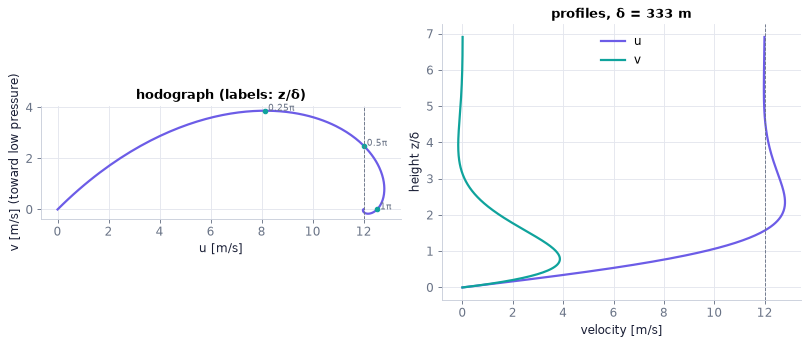

largest u = 12.80 m/s = 1.067 U at z/delta = 2.356 (3 pi/4 = 2.356)
at z = pi*delta: u = 12.52 m/s = 1.043 U


In [71]:
figB = ch13.fig_ekman_bottom()                                 # hodograph with height marks + u(z), v(z) for our inputs at 60 N
plt.show()   # display the figure
zz_b = np.linspace(0.0, 6*delta_b, 6001)                       # a fine grid of heights [m]
ub_all, _ = GFD.ekman_bottom(zz_b, U_g, 0.0, nu_a, f60)        # the along-isobar component
k_max = np.argmax(ub_all)                                      # where u is largest
print(f"largest u = {ub_all[k_max]:.2f} m/s = {ub_all[k_max]/U_g:.3f} U at z/delta = {zz_b[k_max]/delta_b:.3f} (3 pi/4 = {3*np.pi/4:.3f})")   # the overshoot
print(f"at z = pi*delta: u = {GFD.ekman_bottom(np.pi*delta_b, U_g, 0.0, nu_a, f60)[0]:.2f} m/s = {1 + np.exp(-np.pi):.3f} U")   # where v returns to zero

**What you see.** Left: the hodograph from the origin (no slip at the ground) to the point $(U, 0)$ (the geostrophic wind aloft), with marks at $z/\delta=\pi/4$, $\pi/2$, $\pi$. Right: $u$ and $v$ against height.

**How to read it.** The hodograph leaves the origin at 45° to the left of $U$ (northern hemisphere, $f>0$; mirror for $f<0$) and winds into the point $(U,0)$, passing slightly beyond it: $u$ peaks at 1.067 $U$ at $z=3\pi\delta/4$ (printed line).

**What would change if…** …the surface were rougher (a larger eddy viscosity)? The thickness $\delta$ grows; in units of $\delta$ the picture is unchanged.

📝 **Note.** **N48 [B]** **Eddies, not molecules, carry the stress.** With the molecular viscosity of air the layer would be half a metre thick; the
observed layer is of the order of a kilometre. Turning the formula round gives the eddy viscosity that such a depth implies.

In [72]:
print(f"laminar air (nu = 1.5e-5 m^2/s) at 60 N: delta = {GFD.ekman_depth(1.5e-5, f60):.2f} m")       # absurdly thin
print(f"eddy viscosity implied by delta = 1000 m at 60 N: {GFD.eddy_viscosity_from_depth(1000.0, f60):.0f} m^2/s")   # nu_v = |f| delta^2 / 2

laminar air (nu = 1.5e-5 m^2/s) at 60 N: delta = 0.49 m
eddy viscosity implied by delta = 1000 m at 60 N: 63 m^2/s


**What does this show?** A kilometre-deep friction layer needs an eddy viscosity some four million times the molecular one.

> ⚠️ **slip table, row #10 (a loose order-of-magnitude statement, not an error) — the book quotes** a laminar thickness for air about a quarter below what the formula gives for the inputs stated beside it **; what the formula gives is** the value of $\delta=\sqrt{2\nu_v/f}$ (13.29) — our numbers above are computed, not quoted.

📝 **Note.** **N49 [B]** **The force triangle at three heights:**
$-f\,\mathbf e_z\times\mathbf u-\dfrac1\rho\nabla p+\nu_v\dfrac{d^2\mathbf u}{dz^2}=0$. Inflow and rising air in a low, outflow and
sinking in a high — in both hemispheres. The cell also prints a *spin-down time* (ours, one line, not in the book): the pumping
$w=\tfrac\delta2\zeta_g$ out of the layer squashes the column of height $H$ above it, and by the stretching term of `C13` that
changes its vorticity at the rate $d\zeta_g/dt=-f\,w/H=-\big(f\delta/2H\big)\zeta_g$: the vortex decays by a factor $e$ in the time
$2H/(f\delta)$.

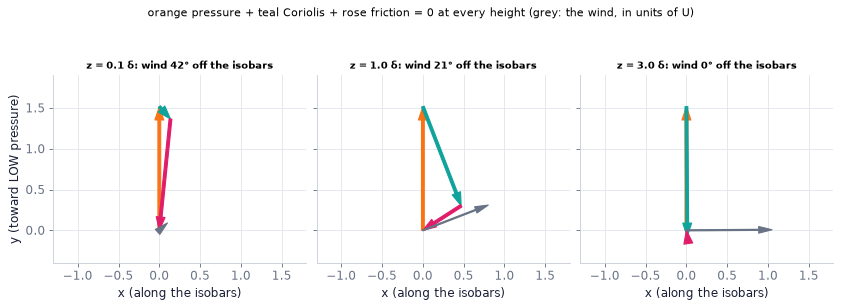

pumping out of the layer under a low: north +1.66 mm/s, south +1.66 mm/s (upward in both)
spin-down time of a 9 km deep vortex, 2H/(f delta) = 4.95 days


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.9), sharex=True, sharey=True)   # a new figure and its panel(s); figsize in inches
for ax, s_ in zip(axes, (0.1, 1.0, 3.0)):                      # three heights in units of delta
    fb3 = GFD.ekman_force_balance(s_*delta_b, U_g, nu_a, f60)  # the three force vectors there [m/s^2]
    start = np.zeros(2)                                        # draw the vectors head to tail, starting at the origin
    for key, col in (("pressure", COLORS["orange"]), ("coriolis", COLORS["teal"]), ("friction", COLORS["rose"])):   # house colours
        vec = np.array(fb3[key])*1e3                           # this force in units of 1e-3 m/s^2
        ax.annotate("", xy=start + vec, xytext=start, arrowprops=dict(color=col, width=2.5, headwidth=8))   # one arrow
        start = start + vec                                    # the next arrow starts where this one ends
    ax.annotate("", xy=(fb3["u"]/U_g, fb3["v"]/U_g), xytext=(0, 0), arrowprops=dict(color=COLORS["muted"], width=1, headwidth=6))   # the wind, as a fraction of U (grey)
    ax.set(title=f"z = {s_} δ: wind {np.degrees(fb3['angle_to_isobars']):.0f}° off the isobars", xlim=(-1.3, 1.8), ylim=(-0.4, 1.9), aspect="equal", xlabel="x (along the isobars)")   # axis labels (with units), title and fixed ranges of this panel
axes[0].set_ylabel("y (toward LOW pressure)")   # label / range / scale of this axis
for ax in axes:
    ax.title.set_fontsize(9)                                   # small titles, so that the three do not collide
fig.suptitle("orange pressure + teal Coriolis + rose friction = 0 at every height (grey: the wind, in units of U)", fontsize=10)   # the message of the whole figure
plt.show()   # display the figure
w_n = GFD.ekman_pumping_bottom(1.0e-5, nu_a, f60)              # w = (delta/2) zeta_g above a northern low with zeta_g = 1e-5 1/s
w_s = GFD.ekman_pumping_bottom(-1.0e-5, nu_a, -f60)            # a southern low: f < 0 and zeta_g < 0
print(f"pumping out of the layer under a low: north {w_n*1e3:+.2f} mm/s, south {w_s*1e3:+.2f} mm/s (upward in both)")   # rising air in lows
print(f"spin-down time of a 9 km deep vortex, 2H/(f delta) = {2*9000.0/(f60*delta_b)/86400:.2f} days")   # how fast friction kills a low

**What you see.** At three heights the pressure force (orange), the Coriolis force (teal) and friction (rose) drawn head to tail: each triangle closes. The grey arrow is the wind.

**How to read it.** Near the ground the pressure force is balanced mostly by friction and the wind blows 40° across the isobars; at $3\delta$ friction has almost vanished and the triangle has collapsed to the geostrophic pair. The inflow toward the low must rise: the printed pumping is upward for a low in *either* hemisphere.

**What would change if…** …the centre were a high? All horizontal vectors reverse; the outflow near the ground is fed by sinking air — clear skies.

📝 **Note.** **N34 [B]** **Shallow water: two layers in one.** Observed current profiles in shallow seas look like a surface Ekman layer on top of a
bottom one. The observation is not reproduced; **our** exact finite-depth solution (`GFD.ekman_finite_depth`: wind stress at
the surface, no slip at the bottom, a geostrophic interior current) shows the same structure.

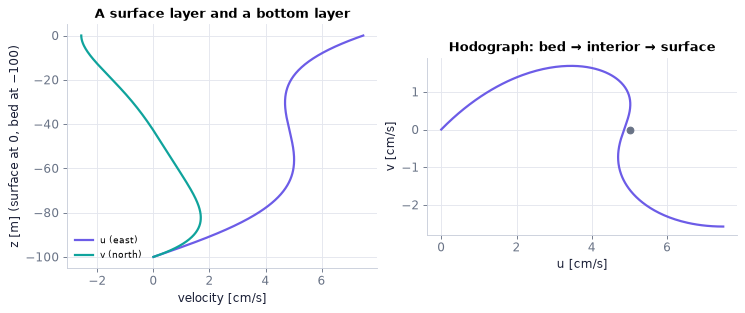

In [74]:
H_sh = 100.0                                                   # water depth [m], about 4.6 delta for the ocean inputs
z_sh = np.linspace(-H_sh, 0.0, 301)                            # from the sea bed to the surface
V_sh = GFD.ekman_finite_depth(z_sh, tau, 0.0, 0.05, 0.0, H_sh, nu_o, rho_o, f60)   # stress 0.07 N/m^2 on top, interior current 0.05 m/s, no slip below
fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.8))   # a new figure and its panel(s); figsize in inches
a.plot(V_sh.real*100, z_sh, color=COLORS["accent"], label="u (east)")     # eastward component against depth
a.plot(V_sh.imag*100, z_sh, color=COLORS["teal"], label="v (north)")      # northward component
a.set(xlabel="velocity [cm/s]", ylabel="z [m] (surface at 0, bed at −100)", title="A surface layer and a bottom layer")   # axis labels (with units), title and fixed ranges of this panel
a.legend(fontsize=8)   # the legend names every curve
b.plot(V_sh.real*100, V_sh.imag*100, color=COLORS["accent"])   # the hodograph
b.plot([5], [0], "o", color=COLORS["muted"])                   # the interior (geostrophic) velocity
b.set(xlabel="u [cm/s]", ylabel="v [cm/s]", title="Hodograph: bed → interior → surface", aspect="equal")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure

**What you see.** Left: the two velocity components through 100 m of water. Right: the hodograph, from zero at the bed, through the interior velocity (grey dot), to the wind-driven surface current.

**How to read it.** Near the bed the profile is the bottom spiral of this block; near the surface it is the wind-driven spiral of `C04`; in between the current is the geostrophic interior value.

**What would change if…** …the depth were less than about $2\delta$? The two layers would merge and the current would run nearly downwind.

In [75]:
s_f5 = np.linspace(0.0, 6.0, 61)                               # height in units of delta

def f5(U_):                                                    # hodograph for one geostrophic wind speed U [m/s] (nu_v = 7 m^2/s, 60 N)
    uu_, vv_ = GFD.ekman_bottom(s_f5*delta_b, U_, 0.0, nu_a, f60)   # Eq. (13.41)
    u1, v1 = GFD.ekman_bottom(delta_b, U_, 0.0, nu_a, f60)     # the wind at z = delta
    return {"hodograph: ground (origin) → aloft (U, 0)": (uu_, vv_),   # hand the result back to the caller
            "wind at z = δ (always 21° from the isobars)": ([0.0, u1], [0.0, v1]),
            "geostrophic wind aloft": ([0.0, U_], [0.0, 0.0])}

figF5 = slider_figure(f5, "geostrophic wind U", np.arange(2.0, 30.1, 2.0), unit="m/s", xlabel="u along the isobars [m/s]",
                      ylabel="v toward low pressure [m/s]", title="A stronger wind stretches the spiral; no angle changes",
                      xrange=(0, 33), yrange=(-2, 11))         # 15 slider positions
figF5.show()   # display the interactive figure (the slider works on the web page too)
for nu_ in (2.0, 7.0, 20.0):                                   # three eddy viscosities [m^2/s]
    d_ = GFD.ekman_depth(nu_, f60)                             # thickness for each
    print(f"nu_v = {nu_:4.1f} m^2/s: delta = {d_:5.1f} m, cross-isobar transport (1/2) U delta = {0.5*U_g*d_:6.0f} m^2/s for U = {U_g:.0f} m/s")   # thickness and transport grow with nu_v

nu_v =  2.0 m^2/s: delta = 178.0 m, cross-isobar transport (1/2) U delta =   1068 m^2/s for U = 12 m/s
nu_v =  7.0 m^2/s: delta = 332.9 m, cross-isobar transport (1/2) U delta =   1998 m^2/s for U = 12 m/s
nu_v = 20.0 m^2/s: delta = 562.8 m, cross-isobar transport (1/2) U delta =   3377 m^2/s for U = 12 m/s


**What does the code above do?**

1. `f5` returns the hodograph for one wind speed, the wind vector at $z=\delta$ and the geostrophic wind.
2. The printed lines show what the eddy viscosity changes: the thickness and the transport toward low pressure — not the shape.

**What you see.** The hodograph of the bottom layer for the chosen geostrophic wind, with the wind at $z=\delta$ and the wind aloft.

**How to read it.** The whole figure scales with $U$: the cross-isobar angle at a given $z/\delta$ does not depend on the wind speed at all (nor on $\nu_v$).

**What would change if…** …$\nu_v$ doubled? In this picture nothing — only the height at which each point of the spiral sits, and the transport (printed lines).

#### 🎮 Interactive: If the wind follows the isobars, why does air spiral into a low?

**Why interactive rather than a static figure:** sliding the height cursor from the ground to the top of the layer turns the force triangle continuously from 'pressure against friction' to 'pressure against Coriolis'; the triangle always closes.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Slide the height to 0: the wind is 45° from the isobars.
- Jump to the preset z = πδ: v is zero and u is 4 % above U.
- Switch the centre from low to high and read the pumping sign.
- Switch to S and check that air still flows *into* the low.

In [76]:
show_viz("ch13", "ekman_force_balance")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/ekman_force_balance]

**What would change if…** …we forget friction again and ask how such a layer of fluid *moves in time* — its waves? For that we need equations for a
thin layer with a free surface (`C07`).

---

## 13.8 Shallow-Water Equations

**What is this section about?** The simplest model that still has gravity waves and rotation: one thin layer of uniform
density with a free surface. Three equations for the surface height and the two horizontal velocities. Sections 13.10–13.15
are all about its solutions. ⚠️ Here $z=0$ is the flat bottom and the surface is at $z=H+\eta$.

### 🧩 The linear shallow-water equations: $\dfrac{\partial\eta}{\partial t}+H\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)=0$, $\dfrac{\partial u}{\partial t}-fv=-g\dfrac{\partial\eta}{\partial x}$, $\dfrac{\partial v}{\partial t}+fu=-g\dfrac{\partial\eta}{\partial y}$ (13.45) `C07`

*The question:* What is the least we must keep to describe a tide or a tsunami crossing an ocean on a turning earth?

#### The problem in plain words

A tsunami in mid-ocean is a few hundred kilometres long in water four kilometres deep. To such a wave the ocean is a puddle:
the water moves almost horizontally, the same at every depth, and the pressure at any point is just the weight of water above
it. Then the whole three-dimensional problem collapses to a map: how high is the surface, and which way is the column moving.
Tides, storm surges, the adjustment of the ocean to a change of wind — and, with one substitution, each internal mode of a
stratified ocean — all obey these three equations.

#### The idea

```
columns converge → the surface rises → the slope pushes the columns apart again → …
     →  ←                 ▲                        ←  →
```

A column of water is the unit. Its height changes when its neighbours crowd in; the resulting slope accelerates the columns.

📝 **Note.** **N54 [C]** **The geometry** (our sketch): mean depth $H$, surface displacement $\eta$, height $z$ measured from the flat bottom. Which
$z=0$ each section uses is in the table of the conventions block (trap T4).

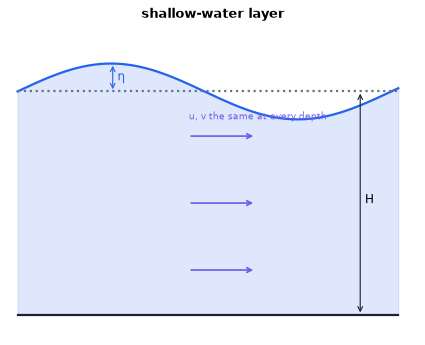

In [77]:
figL = draw_shallow_layer()                                    # our sketch of the layer: H, eta, and z measured from the bottom
plt.show()   # display the figure

**What you see.** A layer of mean depth $H$ whose surface is displaced by $\eta$; the horizontal velocity is the same at every height of a column.

**How to read it.** Everything in this section is a function of $(x, y, t)$ only: the vertical coordinate has been integrated away.

**What would change if…** …the bottom were uneven? The depth $H$ becomes $H(x,y)$ and the total depth $h=H+\eta$ takes its place (`C13`).

> 🔁 **Recap — Hydrostatic pressure under a displaced surface `R17`** (Ch. 7, long waves are hydrostatic: $p'=\rho g\eta$ (7.52)). With zero pressure at the surface $z=H+\eta$, the pressure at height $z$ is the weight of the water above:
$p=\rho g(H+\eta-z)$.

> 🔁 **Recap — The pressure gradient is the surface slope `R18`** (Ch. 7 §7.2). Differentiating, $\dfrac{\partial p}{\partial x}=\rho g\dfrac{\partial\eta}{\partial x}$ and $\dfrac{\partial p}{\partial y}=\rho g\dfrac{\partial\eta}{\partial y}$ (13.42):
neither depends on $z$, so every level of a column is pushed alike and a flow that starts depth-independent stays so.

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **product rule** — $(ab)'=a'b+ab'$. *(Ch. 1, P38)*
- **staggered arrays (η at centres, u at faces)** — with `n` cells there are `n` centre values and `n + 1` face values; `np.diff(u)/dx` of the face array lands exactly on the centres. *(Ch. 10, P242)*

Two more reminders: the transport per unit width and its divergence were primed in `C05` (P313); and Chapter 7's kinematic
surface condition, $\big(\frac{\partial\phi}{\partial z}\big)_{z=\eta}\cong\frac{\partial\eta}{\partial t}$ (7.17), is used here in
its exact form $w(\eta)=D\eta/Dt$: a parcel on the surface stays on the surface.

#### 🧮 Derivation — Shallow-water continuity and the linear set `D10` ★★ (Eq. 13.45: $\frac{\partial\eta}{\partial t}+H\Big(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}\Big)=0,\ \dots$)

**What we want to show.** Collapse the three-dimensional equations of a thin homogeneous layer to three equations in x, y, t.

**Assumptions.** Wavelength ≫ depth, so hydrostatic (the Start); homogeneous, inviscid; flat bottom at z = 0 (step 4); small amplitude (steps 7–9).

**The plan.**

1. Get the pressure gradient from the surface slope.
2. Integrate continuity over the column.
3. Use what the surface and the bottom do.
4. Write it as a flux.
5. Linearise.

**Tools we use** (each explained before this point): depth integration (P313) · the kinematic surface condition (Ch. 7, reminder) · product rule (P38, reminder) · linearisation

**We start from**

$$ \begin{array}{l}p=\rho g(H+\eta-z)\ \text{(hydrostatic, zero pressure at the surface),} \\ \dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}=0\ \text{, and the inviscid horizontal momentum} \\ \text{equations}\ \dfrac{Du}{Dt}-fv=-\dfrac1\rho\dfrac{\partial p}{\partial x}\ \text{,}\ \dfrac{Dv}{Dt}+fu=-\dfrac1\rho\dfrac{\partial p}{\partial y}\ \text{(the horizontal members} \\ \text{of (13.9) without friction)}\end{array} $$

*In words:* Weight sets the pressure; mass is conserved; Coriolis and pressure accelerate the columns

---

**Step 1 of 9 — Differentiate the pressure horizontally.**

$$ \dfrac{\partial p}{\partial x}=\rho g\dfrac{\partial\eta}{\partial x},\qquad\dfrac{\partial p}{\partial y}=\rho g\dfrac{\partial\eta}{\partial y}\ \text{(13.42)} $$

- *Why we can do this:* In $p=\rho g(H+\eta-z)$ only η depends on x and y; H is constant and z is the independent coordinate.
- *In words:* The horizontal push is the slope of the surface, the same at every depth.

---

**Step 2 of 9 — Conclude that the columns stay upright.**

$$ \dfrac{\partial u}{\partial z}=\dfrac{\partial v}{\partial z}=0 $$

- *Why we can do this:* The force of step 1 and the Coriolis force act alike at all depths; a flow that starts independent of z has no reason to become dependent.
- *In words:* Each column moves as a whole.

---

**Step 3 of 9 — Integrate continuity over the column.**

$$ (H+\eta)\dfrac{\partial u}{\partial x}+(H+\eta)\dfrac{\partial v}{\partial y}+w(\eta)-w(0)=0\ \text{(13.43)} $$

- *Why we can do this:* By step 2 the horizontal divergence is constant over the depth H + η and leaves the integral; the integral of ∂w/∂z is w at the top minus w at the bottom.
- *In words:* Horizontal convergence must be taken up by the surface rising.

---

**Step 4 of 9 — State what the two ends do.**

$$ w(0)=0,\qquad w(\eta)=\dfrac{D\eta}{Dt}=\dfrac{\partial\eta}{\partial t}+u\dfrac{\partial\eta}{\partial x}+v\dfrac{\partial\eta}{\partial y} $$

- *Why we can do this:* No flow through the flat bottom; a parcel on the surface stays on it — the exact kinematic condition, of which Chapter 7 used the linearised form.
- *In words:* The surface moves with the fluid.

---

**Step 5 of 9 — Substitute.**

$$ (H+\eta)\dfrac{\partial u}{\partial x}+(H+\eta)\dfrac{\partial v}{\partial y}+\dfrac{\partial\eta}{\partial t}+u\dfrac{\partial\eta}{\partial x}+v\dfrac{\partial\eta}{\partial y}=0 $$

- *Why we can do this:* Insert step 4 into step 3.
- *In words:* One equation linking the surface height and the horizontal flow.

---

**Step 6 of 9 — Recognise two product rules.**

$$ \dfrac{\partial\eta}{\partial t}+\dfrac{\partial}{\partial x}\big[u(H+\eta)\big]+\dfrac{\partial}{\partial y}\big[v(H+\eta)\big]=0\ \text{(13.44)} $$

- *Why we can do this:* Since H is constant, $\partial[u(H+\eta)]/\partial x=(H+\eta)\,\partial u/\partial x+u\,\partial\eta/\partial x$, and likewise in y.
- *In words:* The surface falls where the transport diverges.

---

**Step 7 of 9 — Linearise continuity.**

$$ \dfrac{\partial\eta}{\partial t}+H\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)=0 $$

- *Why we can do this:* For small waves η ≪ H, so H + η ≈ H, and products of two small quantities (uη, vη) are neglected.
- *In words:* For small waves the depth in the transport is just H.

---

**Step 8 of 9 — Insert the pressure gradient in the x-momentum equation and linearise.**

$$ \dfrac{\partial u}{\partial t}-fv=-g\dfrac{\partial\eta}{\partial x} $$

- *Why we can do this:* Step 1 turns the pressure term into −g ∂η/∂x; the advective part of Du/Dt is a product of small quantities (U ≪ c) and is dropped.
- *In words:* A surface slope accelerates the column; Coriolis turns it.

---

**Step 9 of 9 — Do the same in y.**

$$ \dfrac{\partial v}{\partial t}+fu=-g\dfrac{\partial\eta}{\partial y} $$

- *Why we can do this:* The identical two moves on the y-equation; steps 7–9 together are the three members of (13.45), $\frac{\partial\eta}{\partial t}+H(\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y})=0$, $\frac{\partial u}{\partial t}-fv=-g\frac{\partial\eta}{\partial x}$, $\frac{\partial v}{\partial t}+fu=-g\frac{\partial\eta}{\partial y}$.
- *In words:* Three linear equations for η, u, v.

---

**Result**

$$ \begin{array}{l}\dfrac{\partial\eta}{\partial t}+H\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)=0\ \text{,}\ \dfrac{\partial u}{\partial t}-fv=-g\dfrac{\partial\eta}{\partial x}\ \text{,} \\ \dfrac{\partial v}{\partial t}+fu=-g\dfrac{\partial\eta}{\partial y}\ \text{(13.45)}\end{array} $$

*In words:* The linear shallow-water equations

**What it means.** All of §13.10–§13.15 are solutions of this set; with H replaced by an equivalent depth it also governs each vertical mode of a stratified fluid (D11). **Fails when:** the wavelength is not long against the depth (non-hydrostatic), or the amplitude is not small (then keep the flux form and the advection: C13).

**Check it.** Units — H × (1/s) = m/s = ∂η/∂t ✓; g × slope = m/s² ✓. Limit — f = 0, one dimension: $\eta_{tt}=gH\,\eta_{xx}$ (subscripts = derivatives), waves at $c=\sqrt{gH}$, Chapter 7's long-wave speed. Conservation — the flux form of step 6 keeps the total volume exactly. Number — H = 4200 m: c = 203 m/s.

> ⚠️ **Common confusion (traps in `D10`):** Why u, v are independent of z (the pressure gradient is); the flux form needs the product rule; what "linear" drops (η/H ≪ 1 and U/c ≪ 1); z = 0 is the bottom in this section (trap T4).

📝 **Note.** **N51 [B]** **Continuity integrated over a column** (step 3 of `D10`):
$(H+\eta)\dfrac{\partial u}{\partial x}+(H+\eta)\dfrac{\partial v}{\partial y}+w(\eta)-w(0)=0$ (13.43).

📝 **Note.** **N52 [B]** **The nonlinear continuity equation** (steps 4–6 of `D10`):
$\dfrac{\partial\eta}{\partial t}+\dfrac{\partial}{\partial x}\big[u(H+\eta)\big]+\dfrac{\partial}{\partial y}\big[v(H+\eta)\big]=0$ (13.44)
— the divergence of the transport lowers the surface.

#### ✏️ Tiny example: how fast, and how strong a current

Take $H=4000$ m, $g\approx10$ m/s², no rotation.

1. Try $\eta=F(x-ct)$: the two one-dimensional equations give $c^2=gH$, so $c=\sqrt{40\,000}=200$ m/s (720 km/h — a jet
   aircraft).
2. An ocean 6000 km wide is crossed in 30 000 s ≈ 8 h.
3. A crest 1 m high carries a current $u=c\eta/H=200\times1/4000=0.05$ m/s: the water barely moves; the *shape* travels.
4. With $H=1.3$ m instead (the equivalent depth of an internal mode, `C08`): $c=\sqrt{13}\approx3.6$ m/s.

> 📎 **Primer — a C-grid shallow-water step and its CFL limit with c = √(gH) (our choice of scheme).** `P335` · To step the equations in time we store $\eta$ at the centres of grid cells and the velocities on the cell faces (a "C-grid"),
so every difference is taken across exactly one cell. Forward–backward stepping: update $\eta$ with the old velocities, then
the velocities with the new $\eta$. It is stable only if a wave cannot cross more than one cell per step:
$c\,\Delta t/\Delta x\le1$ with $c=\sqrt{gH}$ (the CFL limit of Ch. 10). The ratio $c\,\Delta t/\Delta x$ is called the *Courant number*. This scheme is OUR choice — the book has no numerical
model.

In [78]:
dx, H = 1.0e4, 1.33                    # 10 km cells; a layer 1.33 m deep
c = np.sqrt(G0*H)                      # long-wave speed: 3.61 m/s
print(f"c = {c:.2f} m/s; time step at Courant number 0.5: {0.5*dx/c:.0f} s")   # 3.61 m/s and 1385 s

c = 3.61 m/s; time step at Courant number 0.5: 1384 s


> 🔧 **Our choice** — forward–backward time stepping on a staggered grid in one dimension here (`SW.linear_1d_run`); an energy-conserving C-grid
scheme with third-order Runge–Kutta steps for the two-dimensional model `SW.ShallowWater`, used only to make the cached runs of
`C11` and `C13`.

In [79]:
He1 = 1.3286                                                   # layer depth [m]: the equivalent depth of our first internal mode (C08)
dx1, dt1, n1 = 1.0e4, 1385.0, 400                              # 10 km cells, 1385 s steps (Courant number 0.5), 400 cells
x1 = (np.arange(n1) + 0.5)*dx1 - 2.0e6                         # cell centres from -2000 km to +2000 km [m]
eta_bump = np.exp(-(x1/1.0e5)**2)                              # a bump 1 m high and 100 km wide
out0 = SW.linear_1d_run(eta_bump, dx=dx1, dt=dt1, n_steps=144, H=He1, f=0.0)   # march 144 steps (2e5 s) without rotation
eta_end = out0["eta"][-1]                                      # the surface at the last step
right = x1 > 0                                                 # the right half of the line
x_peak = x1[right][np.argmax(eta_end[right])]                  # where the right-going pulse is
print(f"c = sqrt(gH) = {GFD.long_wave_speed(He1):.3f} m/s for H = {He1} m;  {GFD.long_wave_speed(4200.0):.2f} m/s for H = 4200 m")   # Eq. (13.86)
print(f"after {out0['t'][-1]:.0f} s: two pulses of height {eta_end[right].max():.3f} m at x = ±{x_peak/1e3:.0f} km -> speed {x_peak/out0['t'][-1]:.2f} m/s")   # the bump has split

c = sqrt(gH) = 3.610 m/s for H = 1.3286 m;  202.95 m/s for H = 4200 m
after 199440 s: two pulses of height 0.500 m at x = ±715 km -> speed 3.59 m/s


**What does the code above do?**

1. `SW.linear_1d_run` marches the linear equations with no variation in $y$ from an initial surface shape at rest.
2. Without rotation the bump splits into two pulses of half the height, running apart at the long-wave speed — Chapter 7's
   result, recovered by our scheme (the small speed deficit is the dispersion of a 10 km grid).
3. `GFD.long_wave_speed(H)` is $c=\sqrt{gH}$ *(13.86)*: 3.6 m/s for a layer 1.33 m deep, about 200 m/s for the real ocean depth.
4. The time step obeys the CFL limit of the primer above.

In [80]:
# From scratch: the forward-backward march, every line of the scheme written out
def march(eta0, f_, n_steps):                                  # returns the surface after n_steps
    eta = eta0.copy()                                          # surface height at the cell centres [m]
    u = np.zeros(len(eta0) + 1)                                # x-velocity at the cell faces [m/s]; the two end faces are walls
    v = np.zeros(len(eta0))                                    # y-velocity at the cell centres [m/s]
    for _ in range(n_steps):                                   # one time step per pass
        u_c = 0.5*(u[1:] + u[:-1])                             # old u averaged to the centres
        eta = eta - dt1*He1*np.diff(u)/dx1                     # Eq. (13.45), first member: d(eta)/dt = -H du/dx (old u)
        v = v - dt1*f_*u_c                                     # third member with d/dy = 0: dv/dt = -f u (old u)
        v_f = 0.5*(v[1:] + v[:-1])                             # new v averaged to the interior faces
        u[1:-1] = u[1:-1] + dt1*(f_*v_f - G0*np.diff(eta)/dx1) # second member: du/dt = f v - g d(eta)/dx (new eta, new v)
    return eta   # hand the result back to the caller

assert np.allclose(march(eta_bump, 0.0, 144), out0["eta"][-1], atol=1e-12)   # same scheme -> same numbers, without rotation
out_f = SW.linear_1d_run(eta_bump, dx=dx1, dt=dt1, n_steps=144, H=He1, f=f35)   # the library run with rotation (35 N)
assert np.allclose(march(eta_bump, f35, 144), out_f["eta"][-1], atol=1e-12)     # and with rotation
print("✓ the hand-written march reproduces SW.linear_1d_run with and without rotation (to round-off)")   # visible confirmation

✓ the hand-written march reproduces SW.linear_1d_run with and without rotation (to round-off)


**What does the code above do?**

Six lines inside the loop are the whole model: continuity with the old velocity, the Coriolis turn of $v$, then the momentum
equation with the new surface. Being the same scheme, it gives the same numbers as the library to round-off.

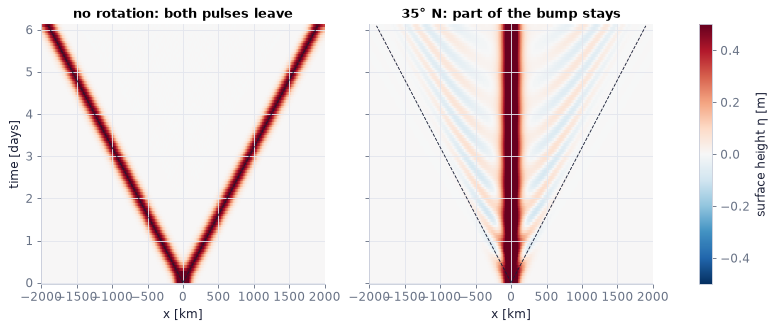

what is left at x = 0 after 6.1 days: +0.000 m without rotation, +0.791 m with rotation


In [81]:
n_long = 380                                                   # steps for the picture (5.3e5 s, about 6 days: just before the pulses reach the end walls)
runs = [SW.linear_1d_run(eta_bump, dx=dx1, dt=dt1, n_steps=n_long, H=He1, f=f_, save_every=4) for f_ in (0.0, f35)]   # without and with rotation
c1 = GFD.long_wave_speed(He1)                                  # long-wave speed [m/s]
fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0), sharey=True)   # a new figure and its panel(s); figsize in inches
for ax, r_, ttl in zip(axes, runs, ("no rotation: both pulses leave", "35° N: part of the bump stays")):   # one panel each
    pm = ax.pcolormesh(x1/1e3, r_["t"]/86400, r_["eta"], cmap="RdBu_r", vmin=-0.5, vmax=0.5, shading="auto")   # x-t diagram of the surface height
    ax.plot(c1*r_["t"]/1e3, r_["t"]/86400, "--", color=COLORS["ink"], lw=0.8)    # the ray x = +ct
    ax.plot(-c1*r_["t"]/1e3, r_["t"]/86400, "--", color=COLORS["ink"], lw=0.8)   # the ray x = -ct
    ax.set(xlabel="x [km]", title=ttl, xlim=(-2000, 2000))   # axis labels (with units), title and fixed ranges of this panel
axes[0].set_ylabel("time [days]")   # label / range / scale of this axis
fig.colorbar(pm, ax=axes, label="surface height η [m]")   # the colour scale and what it measures
plt.show()   # display the figure
print(f"what is left at x = 0 after {runs[1]['t'][-1]/86400:.1f} days: {runs[0]['eta'][-1][n1//2]:+.3f} m without rotation, {runs[1]['eta'][-1][n1//2]:+.3f} m with rotation")   # the part that stays

**What you see.** Two *x–t* (Hovmöller) diagrams of the surface height: distance across, time upward. Left, without rotation: two straight rays leave the origin. Right, with rotation: the rays spread into wave trains, and a part of the bump stays at $x=0$.

**How to read it.** In an x–t diagram the slope of a ray is a speed: the dashed lines are $x=\pm ct$. Whatever still sits on the line $x=0$ at late time never left — the printed line gives its height.

**What would change if…** …$H$ were quadrupled? The speed doubles, so — with time on the vertical axis — the rays would be half as steep: the pulses would reach the edge in half the time. (The line has walls at its ends; the picture stops just before the pulses get there.) Why something stays at all is the subject of `C12`.

📝 **Note.** **N53 [B]** **Equivalent depth.** A stratified mode with long-wave speed $c$ behaves like a homogeneous layer of depth $H_e$ defined by
$c^2=gH_e$ (13.46). Made precise in `C08`.

In [82]:
print(f"a mode with c = 3.6096 m/s has the equivalent depth H_e = c^2/g = {GFD.equivalent_depth(3.6096):.3f} m")   # Eq. (13.46)

a mode with c = 3.6096 m/s has the equivalent depth H_e = c^2/g = 1.329 m


**What does this show?** An internal wave that travels at 3.6 m/s behaves, horizontally, exactly like a surface wave on a
layer of water only 1.3 m deep — the depth used in the runs above.

In [83]:
if not FAST:                                                   # a slow cell: skipped in FAST runs
    m2d = SW.ShallowWater(64, 64, 2.0e6, 2.0e6, He1, f35, bc="closed")       # a closed 2000 km square basin on a 64 x 64 C-grid
    st0 = SW.geostrophic_state(m2d, np.zeros((64, 64)))                      # a state dictionary {"eta", "u", "v"} at rest
    st0["eta"] = SW.gaussian_bump(m2d, 0.05, 1.0e6, 1.0e6, 1.5e5)            # put a 5 cm bump in the middle
    hist = SW.run(m2d, st0, t_end=20*SW.dt_limit(m2d))                       # twenty time steps of the two-dimensional model
    vol = hist["eta"].sum(axis=(1, 2))                                       # total volume anomaly at each saved step
    print(f"2-D model: {len(hist['t'])} saved steps; volume changes by {abs(vol - vol[0]).max()/abs(vol[0]):.1e} of itself (flux form conserves it)")   # conservation check
else:
    print("FAST run: the two-dimensional model demo is skipped (its cached output is used in C11 and C13)")   # say what was skipped

2-D model: 21 saved steps; volume changes by 8.6e-16 of itself (flux form conserves it)


**What does the code above do?** It shows the interface of our two-dimensional model in six lines: make a grid, put a bump on
it, run twenty steps and check that the volume is conserved to round-off (the continuity equation is in flux form). Everything
else two-dimensional in this notebook comes from cached runs.

**What would change if…** …the fluid is not one layer but continuously stratified? Surprisingly little: it splits into a stack of such layers, each with
its own depth (`C08`).

---

## 13.9 Normal Modes in a Continuously Stratified Layer

**What is this section about?** How a continuously stratified ocean or atmosphere can be replaced by a handful of
shallow-water systems: the vertical structure separates out as an eigenvalue problem set by $N(z)$. ⚠️ Here $z=0$ is the
surface and the flat bottom is at $z=-H$.

### 🧩 Vertical normal modes: $\dfrac{d}{dz}\Big(\dfrac{1}{N^2}\dfrac{d\psi_n}{dz}\Big)+\dfrac{1}{c_n^2}\psi_n=0$ (13.56), each a shallow-water system with $c_n^2\equiv gH_e$ (13.62) `C08`

*The question:* How can a one-layer model say anything about an ocean whose density changes all the way down?

#### The problem in plain words

When El Niño begins, a bulge in the thermocline crosses the Pacific in about two months — far slower than a tsunami (hours),
yet it is the same kind of wave. The ocean has many ways to wobble: all together, top to bottom (fast), or with the upper ocean
moving against the deep ocean (slow), or in three alternating layers (slower still). Each of these *modes* has a fixed vertical
shape and moves horizontally exactly like a single shallow layer — of a different, much smaller, depth. For the first internal
mode that depth is about a metre.

#### The idea

```
mode 0 (barotropic)     mode 1 (first baroclinic)     mode 2
   →  →  →  →               →  →  →                     →  →
   →  →  →  →               →  →                        ←  ←
   →  →  →  →               ←  ←                        ←  ←
   →  →  →  →               ←  ←  ←                     →  →
no sign change           one sign change            two sign changes
```

Mode $n$ has $n$ levels where the horizontal velocity changes sign. Each mode has its own speed $c_n$ and its own equivalent
depth $H_e=c_n^2/g$ — the table is filled in by the code below.

> 🔁 **Recap — Continuity `R19`** (Ch. 4). Mass conservation: $\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}=0$ (13.47).

📝 **Note.** **N55 [B]** **Horizontal momentum, linear, with rotation:**
$\dfrac{\partial u}{\partial t}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}$ and $\dfrac{\partial v}{\partial t}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}$ (13.48)–(13.49).

> 🔁 **Recap — Hydrostatic balance and the density equation `R20`** (Ch. 7, $\frac{d\bar\rho}{dz}=-\frac{\rho_0N^2}{g}\Rightarrow\frac{\partial\rho'}{\partial t}-\frac{N^2\rho_0}gw=0$ (7.131), there without rotation). The two are $0=-\dfrac{\partial p}{\partial z}-g\rho$ (13.50) and $\dfrac{\partial\rho}{\partial t}-\dfrac{\rho_0N^2}{g}w=0$ (13.51): density at
a point changes only because the background gradient is carried up or down, $w\,d\bar\rho/dz=-\rho_0N^2w/g$.

In [84]:
print("the five linear hydrostatic equations are consistent (sympy engine) ->", ch13.hydrostatic_linear_set_sympy()["ok"])   # True

the five linear hydrostatic equations are consistent (sympy engine) ->

 True


**What does this show?** The five equations above — continuity, two momentum equations, hydrostatic balance, density — are
the Start of derivation `D11`; the engine confirms the set as coded.

> 📎 **Primer — Sturm–Liouville problem: a ladder of eigenvalues, eigenfunctions with n zero crossings, orthogonality.** `P314` · A string fixed at both ends can only vibrate in certain shapes — one hump, two, three… — each with its own frequency. Any
equation of the form $(p\,\psi')'+\lambda w\,\psi=0$ with conditions at two ends behaves the same way: only special values
$\lambda_0<\lambda_1<\dots$ allow a solution, the $n$-th solution crosses zero $n$ times, and two different solutions are
orthogonal (their weighted product integrates to zero). Here $\lambda=1/c^2$ and $p=1/N^2$.

In [85]:
z = np.linspace(-1, 0, 2001)                                    # a layer of unit depth
p1, p2 = np.cos(np.pi*z), np.cos(2*np.pi*z)                     # the first two shapes for uniform N and a rigid lid
print("integral of p1*p2 =", abs(round(np.trapezoid(p1*p2, z), 12)), "; integral of p1*p1 =", round(np.trapezoid(p1*p1, z), 3))   # 0.0 and 0.5: orthogonal, not normalised

integral of p1*p2 = 0.0 ; integral of p1*p1 = 0.5


> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **separation of variables** — try a product such as $F(x,y,t)\,\psi(z)$; if the equation splits into a part depending only on $z$ and a part that does not, each must equal the same constant. *(Ch. 7, P167)*
- **eigenvalue problem for a differential operator** — a differential equation with a free parameter and conditions at both ends has non-zero solutions only for special values of the parameter — the eigenvalues. *(Ch. 11, P257)*
- **integration by parts** — $\int_a^bF\,G'\,dz=[FG]_a^b-\int_a^bF'G\,dz$: move a derivative from one factor to the other at the price of a boundary term. *(Ch. 9, P218a)*
- **Dirichlet and Neumann conditions** — a Dirichlet condition fixes the value at a boundary, a Neumann condition fixes the slope. *(Ch. 1, P20)*
- **`scipy.optimize.brentq`** — `brentq(F, a, b)` finds the root of `F` between `a` and `b` when `F(a)` and `F(b)` have opposite signs. *(Ch. 3, P108)*
- **eigenvalues and eigenvectors; generalised symmetric eigenproblem** — $A\mathbf x=\lambda\mathbf x$: a vector the matrix only stretches; a symmetric matrix has real eigenvalues and orthogonal eigenvectors. *(Ch. 2, P80)*

**Two boundary conditions first** — derivation `D11` uses them in its last step, so here is where they come from.

📝 **Note.** **N65 [B]** **The link the boundary conditions need:**
$w=\dfrac{g(\partial\rho/\partial t)}{\rho_0N^2}=-\dfrac1{\rho_0N^2}\dfrac{\partial^2p}{\partial z\,\partial t}=-\dfrac1{N^2}\sum_{n=0}^\infty\dfrac{\partial p_n}{\partial t}\dfrac{d\psi_n}{dz}$ (13.63).

📝 **Note.** **N66 [B]** **Flat bottom**, $w=0$: $\dfrac{d\psi_n}{dz}=0$ at $z=-H$ (13.64).

> 🔁 **Recap — The linearised free surface `R21`** (Ch. 7: the kinematic condition $\big(\frac{\partial\phi}{\partial z}\big)_{z=0}\cong\frac{\partial\eta}{\partial t}$ (7.18) and the dynamic condition $\big(\frac{\partial\phi}{\partial t}\big)_{z=0}\cong-g\eta$ (7.21)). At the surface $w=\partial\eta/\partial t$ and $p=\rho_0g\eta$ at $z=0$ (the book labels this pair (13.65′)), which combine to
$\partial p/\partial t=\rho_0gw$ at $z=0$.

📝 **Note.** **N67 [B]** **Hence the surface condition on the modes:** $\dfrac{d\psi_n}{dz}+\dfrac{N^2}{g}\psi_n=0$ at $z=0$ (13.65).

> 📎 **Primer — Robin (mixed) boundary condition, between Dirichlet and Neumann.** `P315` · A Dirichlet condition fixes the value ($\psi=0$), a Neumann condition fixes the slope ($\psi'=0$), a Robin condition ties them
together ($\psi'+a\psi=0$). With $a=0$ it is Neumann. Here $a=N^2/g$ is tiny — about 10⁻⁶ per metre in the ocean — so for
internal modes the free surface is almost a rigid lid.

In [86]:
N, g = 2.7e-3, 9.80665                 # our ocean's buoyancy frequency [1/s] and gravity [m/s^2]
print(f"a = N^2/g = {N**2/g:.1e} per metre; times the depth 4200 m: {N**2/g*4200:.4f}")   # 7.4e-07 and 0.0031

a = N^2/g = 7.4e-07 per metre; times the depth 4200 m: 0.0031


#### 🧮 Derivation — Vertical normal modes: the modal equations; orthogonality `D11` ★★★ (Eq. 13.56: $\frac{d}{dz}\Big(\frac{1}{N^2}\frac{d\psi_n}{dz}\Big)+\frac{1}{c_n^2}\psi_n=0$)

**What we want to show.** Show that a continuously stratified, hydrostatic layer splits into independent "modes", each with a fixed vertical shape and each obeying the shallow-water equations with its own speed.

**Assumptions.** Linear; hydrostatic, so ω ≪ N; flat bottom at z = −H; no mean shear; N = N(z) only.

**The plan.**

1. Give u, v and p one common vertical shape.
2. Let continuity and hydrostatics fix the shapes of w and ρ.
3. Separate the density equation into a z-part and an (x, y, t)-part.
4. Read off the vertical eigenproblem and the horizontal equations.
5. Prove orthogonality (weight 1, for a rigid lid and for a free surface).

**Tools we use** (each explained before this point): separation of variables (P167, reminder) · Sturm–Liouville problems (P314) · integration by parts (P218a, reminder) · the bottom and free-surface conditions on the modes (notes N66 and N67 above) and the Robin condition (P315)

**We start from**

$$ \begin{array}{l}\text{the five linear equations}\ \dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}=0\ \text{(13.47),} \\ \dfrac{\partial u}{\partial t}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}\ \text{and}\ \dfrac{\partial v}{\partial t}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}\ \text{(13.48)–(13.49),} \\ 0=-\dfrac{\partial p}{\partial z}-g\rho\ \text{(13.50),}\ \dfrac{\partial\rho}{\partial t}-\dfrac{\rho_0N^2}{g}w=0\ \text{(13.51)}\end{array} $$

*In words:* Mass, two momentum balances, hydrostatics, and density carried up and down

---

**Step 1 of 13 — Give u, v and p one vertical shape.**

$$ [u,v,p/\rho_0]=\displaystyle\sum_{n=0}^\infty[u_n,v_n,p_n]\,\psi_n(z)\ \text{(13.52)} $$

- *Why we can do this:* The two momentum equations contain no z-derivative, so if p has the shape ψ_n(z), so must u and v; the amplitudes depend on x, y, t only.
- *In words:* In each mode the horizontal flow and the pressure rise and fall together with depth.

---

**Step 2 of 13 — Find the shape of w from continuity.**

$$ w=\displaystyle\sum_{n=0}^\infty w_n\displaystyle\int_{-H}^z\psi_n\,dz,\qquad w_n=-\Big(\dfrac{\partial u_n}{\partial x}+\dfrac{\partial v_n}{\partial y}\Big)\ \text{(13.53)} $$

- *Why we can do this:* Continuity gives $\partial w/\partial z=-(\partial u/\partial x+\partial v/\partial y)$; integrate upward from the flat bottom, where w = 0.
- *In words:* The vertical velocity's shape is the running integral of the horizontal one's.

---

**Step 3 of 13 — Find the shape of ρ from hydrostatics.**

$$ \rho=\displaystyle\sum_{n=0}^\infty\rho_n\dfrac{d\psi_n}{dz},\qquad\rho_n=-\dfrac{\rho_0}{g}p_n\ \text{(13.54)} $$

- *Why we can do this:* Hydrostatic balance gives $\rho=-\frac1g\,\partial p/\partial z$; differentiate step 1 in z.
- *In words:* The density's shape is the slope of the pressure's shape.

---

**Step 4 of 13 — Substitute into the density equation.**

$$ \displaystyle\sum_{n=0}^\infty\Big[\dfrac{\partial\rho_n}{\partial t}\dfrac{d\psi_n}{dz}-\dfrac{\rho_0N^2}{g}w_n\displaystyle\int_{-H}^z\psi_n\,dz\Big]=0 $$

- *Why we can do this:* Insert steps 2 and 3 into the fifth Start equation; it is the only one not yet used.
- *In words:* One condition is left to tie everything together.

---

**Step 5 of 13 — Separate the variables.**

$$ \dfrac{d\psi_n/dz}{N^2\int_{-H}^z\psi_n\,dz}=\dfrac{\rho_0}{g}\dfrac{w_n}{\partial\rho_n/\partial t}\equiv-\dfrac1{c_n^2}\ \text{(13.55)} $$

- *Why we can do this:* For independent modes each bracket vanishes; dividing puts everything that depends on z on the left and on (x, y, t) on the right, so both equal a constant.
- *In words:* The constant, named −1/c_n², will turn out to be a speed.

---

**Step 6 of 13 — Differentiate the z-part.**

$$ \dfrac{d}{dz}\Big(\dfrac1{N^2}\dfrac{d\psi_n}{dz}\Big)+\dfrac1{c_n^2}\psi_n=0\ \text{(13.56)} $$

- *Why we can do this:* The z-side of step 5 reads $\frac1{N^2}\psi_n'=-\frac1{c_n^2}\int_{-H}^z\psi_n\,dz$; one z-derivative removes the integral.
- *In words:* An eigenvalue problem: only special values of c_n allow a shape that fits top and bottom.

---

**Step 7 of 13 — Read the (x, y, t)-part.**

$$ w_n=-\dfrac{g}{\rho_0c_n^2}\dfrac{\partial\rho_n}{\partial t}=\dfrac1{c_n^2}\dfrac{\partial p_n}{\partial t}\ \text{(13.61)} $$

- *Why we can do this:* The other side of step 5, then $\rho_n=-\rho_0p_n/g$ from step 3.
- *In words:* The mode's vertical velocity follows the rate of change of its pressure.

---

**Step 8 of 13 — Combine with step 2.**

$$ \dfrac{\partial u_n}{\partial x}+\dfrac{\partial v_n}{\partial y}+\dfrac1{c_n^2}\dfrac{\partial p_n}{\partial t}=0\ \text{(13.57)} $$

- *Why we can do this:* Step 2 says $w_n=-(\partial u_n/\partial x+\partial v_n/\partial y)$; equate with step 7.
- *In words:* A continuity equation for the mode, with p_n in the role of surface height.

---

**Step 9 of 13 — Substitute the shapes into the momentum equations.**

$$ \dfrac{\partial u_n}{\partial t}-fv_n=-\dfrac{\partial p_n}{\partial x},\qquad\dfrac{\partial v_n}{\partial t}+fu_n=-\dfrac{\partial p_n}{\partial y}\ \text{(13.58)–(13.59)} $$

- *Why we can do this:* Every term carries the same ψ_n(z); for independent modes the coefficient of each ψ_n must vanish.
- *In words:* Each mode has its own pair of momentum equations.

---

**Step 10 of 13 — Compare with shallow water.**

$$ p_n\leftrightarrow g\eta,\qquad c_n^2\leftrightarrow gH,\qquad c_n^2\equiv gH_e\ \text{(13.62)} $$

- *Why we can do this:* With these two replacements steps 8 and 9 are exactly the three members of the shallow-water set of D10's Result.
- *In words:* Each mode is a shallow-water layer of "equivalent depth" H_e.

---

**Step 11 of 13 — Write the structure equation for two modes and cross-multiply.**

$$ \psi_n\Big(\dfrac{\psi_m'}{N^2}\Big)'-\psi_m\Big(\dfrac{\psi_n'}{N^2}\Big)'+\Big(\dfrac1{c_m^2}-\dfrac1{c_n^2}\Big)\psi_m\psi_n=0 $$

- *Why we can do this:* Multiply the equation of mode m by ψ_n and that of mode n by ψ_m, then subtract (a prime is d/dz); the aim is to isolate the product ψ_mψ_n.
- *In words:* A relation between any two modes.

---

**Step 12 of 13 — Integrate over the depth by parts.**

$$ \Big[\dfrac{\psi_n\psi_m'-\psi_m\psi_n'}{N^2}\Big]_{-H}^0+\Big(\dfrac1{c_m^2}-\dfrac1{c_n^2}\Big)\displaystyle\int_{-H}^0\psi_m\psi_n\,dz=0 $$

- *Why we can do this:* The first two terms are the derivative of the bracket (the cross terms $\psi_n'\psi_m'/N^2$ cancel), so their integral is its end values.
- *In words:* Everything reduces to values at the top and the bottom.

---

**Step 13 of 13 — Use the boundary conditions.**

$$ \displaystyle\int_{-H}^0\psi_m\psi_n\,dz=0\qquad(m\neq n,\ \text{either lid}) $$

- *Why we can do this:* At the flat bottom w = 0 gives ψ′ = 0 (note N66 above). At the top either ψ′ = 0 (lid) or ψ′ = −(N²/g)ψ for both modes (the free-surface condition of note N67 above), so the numerator cancels; with c_m ≠ c_n the integral vanishes.
- *In words:* Different modes are orthogonal.

---

**Result**

$$ \begin{array}{l}\dfrac{d}{dz}\Big(\dfrac1{N^2}\dfrac{d\psi_n}{dz}\Big)+\dfrac1{c_n^2}\psi_n=0\ \text{with}\ c_n^2\equiv gH_e\ \text{, and for each n the three shallow-water} \\ \text{equations}\ \dfrac{\partial u_n}{\partial x}+\dfrac{\partial v_n}{\partial y}+\dfrac1{c_n^2}\dfrac{\partial p_n}{\partial t}=0\ \text{,}\ \dfrac{\partial u_n}{\partial t}-fv_n=-\dfrac{\partial p_n}{\partial x}\ \text{,} \\ \dfrac{\partial v_n}{\partial t}+fu_n=-\dfrac{\partial p_n}{\partial y}\end{array} $$

*In words:* a stratified layer is a stack of shallow-water systems

**What it means.** Every wave result for one shallow layer (C09–C15) holds for each mode with its own c_n — the first baroclinic mode's c₁ sets the internal Rossby radius and the speed of thermocline signals. **Fails when:** the bottom is not flat or there is a sheared mean current (the modes couple); the motion is not hydrostatic (ω comparable to N).

**Check it.** Units — ψ_n dimensionless, so $(1/N^2)\psi''$ is s²/m² and $\psi/c_n^2$ is s²/m² ✓. Uniform N with a rigid lid — $\psi_n=\cos(n\pi z/H)$, $c_n=NH/(n\pi)$: 3.61 m/s for H = 4200 m, N = 2.7 × 10⁻³ s⁻¹. Free surface — the bracket of step 12 vanishes at z = 0 too: $\psi_n\psi_m'-\psi_m\psi_n'=-\frac{N^2}g(\psi_n\psi_m-\psi_m\psi_n)=0$ by $\dfrac{d\psi_n}{dz}+\dfrac{N^2}{g}\psi_n=0$ at $z=0$ (13.65), so the weight is 1 for both lids (`VM.orthogonality_matrix(modes)`, default `kind="psi"`; the code cell further down measures it for free-surface modes). The surface term appears only in the second relation, obtained by multiplying the structure equation by ψ_m and integrating once by parts: $\dfrac1{c_n^2}\displaystyle\int_{-H}^0\psi_n\psi_m\,dz=\displaystyle\int_{-H}^0\dfrac{\psi_n'\psi_m'}{N^2}\,dz+\dfrac{\psi_n(0)\psi_m(0)}{g}$ (`kind="energy"`).

In [87]:
import sympy as sp                                            # symbolic algebra
z, t = sp.symbols("z t", real=True)                           # height (z = -H bottom, 0 top) and time
N, H, g, rho0 = sp.symbols("N H g rho_0", positive=True)      # uniform N for the check
n, m = sp.symbols("n m", integer=True, positive=True)         # two mode numbers
c = N * H / (n * sp.pi)                                       # the rigid-lid speed we expect for mode n
psi = sp.cos(n * sp.pi * z / H)                               # its vertical structure
ode = sp.diff(sp.diff(psi, z) / N**2, z) + psi / c**2         # step 6: the structure equation
assert sp.simplify(ode) == 0                                  # ... is satisfied
assert sp.diff(psi, z).subs(z, -H) == 0 and sp.diff(psi, z).subs(z, 0) == 0   # w = 0 at bottom and lid
W = sp.integrate(psi, (z, -H, z))                             # step 2: the shape of w is the integral of psi
ratio = sp.simplify(sp.diff(psi, z) / (N**2 * W))             # step 5: the z-side of the separation
assert sp.simplify(ratio + 1 / c**2) == 0                     # ... equals the constant -1/c_n^2
pn = sp.Function("p_n")(t)                                    # modal pressure amplitude p_n(t) (x, y left out)
rho_n = -rho0 / g * pn                                        # step 3: hydrostatics, rho_n = -(rho0/g) p_n
w_n = sp.diff(pn, t) / c**2                                   # step 7: w_n = (1/c_n^2) dp_n/dt
dens = sp.diff(rho_n, t) * sp.diff(psi, z) - rho0 * N**2 / g * w_n * W   # step 4: the density equation
assert sp.simplify(dens) == 0                                 # every mode satisfies it on its own
psi_m = sp.cos(m * sp.pi * z / H)                             # a second mode
overlap = sp.integrate(psi * psi_m, (z, -H, 0))               # step 13: the overlap integral
assert sp.simplify(overlap.subs({n: 1, m: 2})) == 0 and sp.simplify(overlap.subs({n: 2, m: 3})) == 0
print("D11 checks passed: structure equation, separation constant, density equation, orthogonality")
# steps 11-12 for ANY two modes and ANY N(z): the identity behind orthogonality
pm, pn, N2f = sp.Function("psi_m")(z), sp.Function("psi_n")(z), sp.Function("N2")(z)   # two modes and N^2(z), left general
flux = (pm * sp.diff(pn, z) - pn * sp.diff(pm, z)) / N2f      # the bracket that is evaluated at the two boundaries
lhs = sp.diff(flux, z)                                        # its derivative …
rhs = pm * sp.diff(sp.diff(pn, z) / N2f, z) - pn * sp.diff(sp.diff(pm, z) / N2f, z)    # … equals psi_m (psi_n'/N^2)' - psi_n (psi_m'/N^2)'
assert sp.simplify(lhs - rhs) == 0                            # the cross terms psi_m' psi_n'/N^2 cancel
print("D11 steps 11-12 passed for general modes; the free-surface case is measured numerically in the orthogonality cell below")

D11 checks passed: structure equation, separation constant, density equation, orthogonality
D11 steps 11-12 passed for general modes; the free-surface case is measured numerically in the orthogonality cell below


> ⚠️ **Common confusion (traps in `D11`):** w's shape is the integral of ψ_n and ρ's is its derivative, not the reverse; the separation constant is negative; the modal amplitudes have different units (trap T12); the surface term $\psi_m(0)\psi_n(0)/g$ belongs to the energy relation, not to the weight-1 orthogonality, which holds for both lids.

📝 **Note.** **N56 [B]** **Separation of variables** (step 1 of `D11`): $[u,v,p/\rho_0]=\sum_{n=0}^\infty[u_n,v_n,p_n]\,\psi_n(z)$ (13.52).

📝 **Note.** **N57 [B]** **The vertical velocity** (step 2): $w=\sum_{n=0}^\infty w_n\int_{-H}^z\psi_n\,dz$ (13.53).

📝 **Note.** **N58 [B]** **The density** (step 3): $\rho=\sum_{n=0}^\infty\rho_n\dfrac{d\psi_n}{dz}$ (13.54).

📝 **Note.** **N59 [B]** **The separation constant** (step 5):
$\dfrac{d\psi_n/dz}{N^2\int_{-H}^z\psi_n\,dz}=\dfrac{\rho_0}{g}\dfrac{w_n}{\partial\rho_n/\partial t}\equiv-\dfrac1{c_n^2}$ (13.55).

📝 **Note.** **N61 [B]** **Modal continuity** (step 8): $\dfrac{\partial u_n}{\partial x}+\dfrac{\partial v_n}{\partial y}+\dfrac1{c_n^2}\dfrac{\partial p_n}{\partial t}=0$ (13.57).

📝 **Note.** **N62 [B]** **Modal momentum** (step 9): $\dfrac{\partial u_n}{\partial t}-fv_n=-\dfrac{\partial p_n}{\partial x}$ and
$\dfrac{\partial v_n}{\partial t}+fu_n=-\dfrac{\partial p_n}{\partial y}$ (13.58)–(13.59).

📝 **Note.** **N63 [B]** **The remaining amplitudes** (steps 3 and 7): $p_n=-\dfrac g{\rho_0}\rho_n$ and $w_n=\dfrac1{c_n^2}\dfrac{\partial p_n}{\partial t}$ (13.60)–(13.61).

📝 **Note.** **N64 [B]** **Each mode is a shallow-water system** (step 10): identify $p_n\leftrightarrow g\eta$ and $c_n^2\leftrightarrow gH$; the
definition $c_n^2\equiv gH_e$ (13.62) names the equivalent depth.

📝 **Note.** **N60 [B]** **Orthogonality** (steps 11–13): $\int_{-H}^0\psi_m\psi_n\,dz=0$ for $m\neq n$, with weight 1, **for the rigid lid and for the
free surface alike** (the book only states it). The surface term $\psi_m(0)\psi_n(0)/g$ belongs to a second, "energy"
relation — $\int\psi_m'\psi_n'/N^2\,dz+\psi_m(0)\psi_n(0)/g=0$ — not to this one.

> ⚠️ **Common confusion (trap T12):** The modal amplitudes do not share units: $\psi_n$ is a pure number, so $u_n$ and $v_n$ are velocities [m/s] and $p_n$ is
$p/\rho_0$ [m²/s²]; but $w_n$ multiplies an integral of $\psi_n$ over $z$ [m], so $w_n$ is in s⁻¹, and $\rho_n$ multiplies
$d\psi_n/dz$ [1/m], so $\rho_n$ is in kg/m².

In [88]:
amp = VM.modal_amplitudes(3.61, 1.0e-5, p_n=0.1, rho0=1027.0)  # mode speed 3.61 m/s; dp_n/dt = 1e-5 m^2/s^3; p_n = 0.1 m^2/s^2
print(f"w_n = (1/c_n^2) dp_n/dt = {amp['w_n']:.2e} 1/s;   rho_n = -(rho0/g) p_n = {amp['rho_n']:.2f} kg/m^2")   # Eqs. (13.61), (13.60)
print("without p_n the density amplitude is not computed:", VM.modal_amplitudes(3.61, 1.0e-5)["rho_n"])    # None

w_n = (1/c_n^2) dp_n/dt = 7.67e-07 1/s;   rho_n = -(rho0/g) p_n = -10.47 kg/m^2
without p_n the density amplitude is not computed: None


**What does this show?** The units of the trap, in numbers: $w_n$ comes out in s⁻¹ and $\rho_n$ in kg/m². If `p_n` is not
passed, the entry `"rho_n"` is `None` (not zero).

📝 **Note.** **N68 [C]** **Uniform $N$, worked case** (stated, as the book writes it out): the equation becomes
$\dfrac{d^2\psi_n}{dz^2}+\dfrac{N^2}{c_n^2}\psi_n=0$ (13.66).

📝 **Note.** **N69 [C]** **Its solution:** $\psi_n=A_n\cos\dfrac{Nz}{c_n}+B_n\sin\dfrac{Nz}{c_n}$ (13.67).

📝 **Note.** **N70 [C]** **The surface condition** fixes one constant: $B_n=-\dfrac{c_nN}{g}A_n$ (13.68).

📝 **Note.** **N71 [B]** **The bottom condition** then gives the eigenvalue condition $\tan\dfrac{NH}{c_n}=\dfrac{c_nN}{g}$ (13.69).

> 📎 **Primer — graphical roots of a transcendental equation such as tan x = εx.** `P316` · Some equations have the unknown both inside and outside a function and cannot be solved by algebra. Plot both sides against
$x$: the roots are where the curves cross. Reading the picture also tells you roughly where they are — here, just above 0,
$\pi$, $2\pi$, … — which is all a root-finder such as `brentq` needs.

In [89]:
eps = 0.0031                                   # N^2 H / g for our ocean
F = lambda X: np.tan(X) - eps/X                # zero where tan X = eps/X
print(f"first root X = {brentq(F, 1e-6, 1.0):.4f}; second root = pi + {brentq(F, np.pi + 1e-9, np.pi + 1.0) - np.pi:.5f}")   # 0.0558 and just above pi

first root X = 0.0556; second root = pi + 0.00099


📝 **Note.** **N72 [B]** **The roots, graphically** (our version of the book's figure, `ch13.fig_mode_roots`): with $X=NH/c_n$ the condition
$\tan\frac{NH}{c_n}=\frac{c_nN}{g}$ *(13.69)* reads $\tan X=(N^2H/g)/X$.

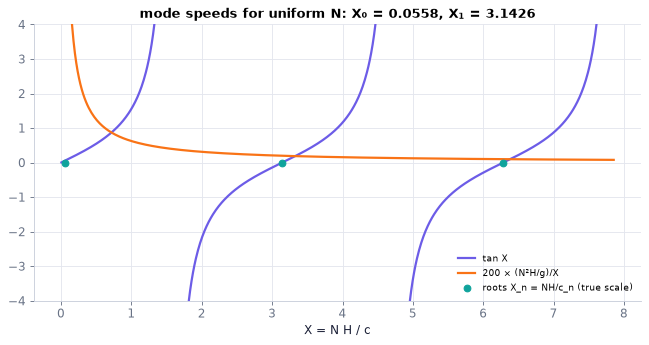

In [90]:
figR = ch13.fig_mode_roots()                                   # tan X and (N^2 H/g)/X against X = N H / c_n, roots marked (our ocean)
plt.show()   # display the figure

**What you see.** The branches of $\tan X$ and the hyperbola $(N^2H/g)/X$ (drawn exaggerated, as the figure says, so that it can be seen), with the crossings marked.

**How to read it.** The hyperbola is so low that it meets each tangent branch almost at its foot: the roots sit just above $X=0,\pi,2\pi,\dots$ — one tiny root (the barotropic mode) and then $X\approx n\pi$.

**What would change if…** …$g$ were a thousand times smaller? The roots would climb the branches and the lid approximation below would fail.

> 🔁 **Recap — The barotropic mode `R22`** (Ch. 7, long waves). The first root has $NH/c_0\ll1$; there $\tan X\approx X$ gives $c_0=\sqrt{gH}$ (13.70), the long-wave speed of a homogeneous
ocean, with a nearly uniform structure $\psi_0\simeq1-N^2z/g\simeq1$.

> ⚠️ **slip #6 — the book prints** that the first root of $\tan\frac{NH}{c_n}=\frac{c_nN}{g}$ (13.69) occurs "for $NH/c_n=1$" **; the correct form is** $NH/c_0\ll1$ (ours, computed in the cell below: 0.0558 for our ocean).

📝 **Note.** **N73 [B]** **The baroclinic roots.** Since $c_nN/g\ll1$, the condition is $\tan\dfrac{NH}{c_n}=0$ to a very good approximation, so
$c_n=\dfrac{NH}{n\pi}$, $n=1,2,3,\dots$ (13.71) (`GFD.baroclinic_mode_speed`).

📝 **Note.** **N74 [B]** **Numbers with our inputs** ($H=4200$ m, $N=2.7\times10^{-3}$ s⁻¹): computed in the code cell below — a factor of about 56 in
speed, and 3200 in equivalent depth, between the barotropic and the first baroclinic mode.

#### ✏️ Tiny example: the first baroclinic mode by hand

Take $N=\pi\times10^{-3}\approx3.14\times10^{-3}$ s⁻¹ and $H=4000$ m.

1. $c_1=NH/\pi=(\pi\times10^{-3}\times4000)/\pi=4$ m/s.
2. Equivalent depth $H_e=c_1^2/g\approx16/10=1.6$ m.
3. Mode 2 travels at half that speed, $c_2=c_1/2$; mode 3 at a third, $c_1/3\approx1.33$ m/s.
4. Barotropic: $\sqrt{gH}=\sqrt{40\,000}=200$ m/s.
5. Size of the surface term: $N^2H/g=10^{-5}\times4000/10=0.004\ll1$ — the surface is almost a lid for these modes.

> 📎 **Primer — scipy.linalg.eigh_tridiagonal for a discretised eigenproblem.** `P317` · Replace $\psi$ by its values on a grid and the second derivative by differences: the differential eigenproblem becomes a
matrix one, with only the diagonal and its two neighbours filled. `eigh_tridiagonal(d, e)` returns all eigenvalues (sorted)
and eigenvectors of a symmetric tridiagonal matrix from its diagonal `d` and off-diagonal `e`.

In [91]:
n = 200; h = 1.0/n                                                     # interior points of a string of unit length
lam, vec = eigh_tridiagonal(2*np.ones(n-1)/h**2, -np.ones(n-2)/h**2)   # the matrix of minus the second derivative
print("sqrt(eigenvalue)/pi of the first three modes:", np.round(np.sqrt(lam[:3])/np.pi, 4))   # 1, 2, 3: the modes of a string

sqrt(eigenvalue)/pi of the first three modes: [1.     1.9999 2.9997]


In [92]:
N_o, H_o = inp["ocean_N"], inp["ocean_H"]                      # our ocean: N = 2.7e-3 1/s, H = 4200 m
z_m = np.linspace(-H_o, 0.0, 401)                              # 401 nodes from the bottom to the surface [m]
N2_u = np.full_like(z_m, N_o**2)                               # uniform N^2 at the nodes [1/s^2]
m_free = VM.vertical_modes(z_m, N2_u, n_modes=4, lid="free")   # numerical modes of Eq. (13.56) with a free surface: index 0 = barotropic
m_exact = VM.modes_uniform_N(N_o, H_o, n_modes=4)              # exact speeds for uniform N (roots of Eq. (13.69) by brentq)
print("numerical c_n [m/s]:", np.round(m_free.c, 4), "  exact:", np.round(m_exact.c, 4))   # the ladder of speeds
print("equivalent depths H_e = c_n^2/g [m]:", np.round(m_free.He, 3))                      # Eq. (13.62)
print(f"barotropic: exact c_0 is {100*(m_exact.c[0]/GFD.long_wave_speed(H_o) - 1):.3f} % above sqrt(gH); first root X_0 = N H/c_0 = {N_o*H_o/m_exact.c[0]:.5f}")   # slip #6 in numbers
print(f"baroclinic: N H/(n pi) = {[round(GFD.baroclinic_mode_speed(N_o, H_o, n_), 4) for n_ in (1, 2, 3)]} m/s; ratio c_0/c_1 = {m_exact.c[0]/m_exact.c[1]:.0f}, H_e ratio = {m_exact.He[0]/m_exact.He[1]:.0f}")   # Eq. (13.71)
print("rigid-lid error (c_free - c_rigid)/c_rigid for n = 1, 2, 3:", [f"{VM.rigid_lid_error(N_o, H_o, n=n_):.1e}" for n_ in (1, 2, 3)])   # how good the lid is
print(f"Rossby radius of mode 1 at 35 N: c_1/f = {GFD.rossby_radius(m_free.c[1], f35)/1e3:.1f} km")   # used in C12

numerical c_n [m/s]: [203.0537   3.6085   1.8047   1.2032]   exact: [203.0537   3.6085   1.8047   1.2032]
equivalent depths H_e = c_n^2/g [m]: [4204.372    1.328    0.332    0.148]
barotropic: exact c_0 is 0.052 % above sqrt(gH); first root X_0 = N H/c_0 = 0.05585
baroclinic: N H/(n pi) = [3.6096, 1.8048, 1.2032] m/s; ratio c_0/c_1 = 56, H_e ratio = 3166
rigid-lid error (c_free - c_rigid)/c_rigid for n = 1, 2, 3: ['-3.2e-04', '-7.9e-05', '-3.5e-05']
Rossby radius of mode 1 at 35 N: c_1/f = 43.1 km


**What does the code above do?**

1. `VM.vertical_modes(z, N2, lid=…)` solves the eigenproblem on a grid and returns a `Modes` named tuple with fields `c`
   (speeds, fastest first), `psi` (shapes, normalised to $\psi(0)=1$), `He`, `z`, `weights`.
2. `VM.modes_uniform_N` gives the exact speeds for uniform $N$ from the roots of $\tan\frac{NH}{c_n}=\frac{c_nN}{g}$ *(13.69)*; the two agree to
   four or five digits.
3. The barotropic speed is within a twentieth of a per cent of $\sqrt{gH}$, and its root is $X_0\approx0.056$ — far below 1 (slip #6).
4. The baroclinic speeds are $NH/(n\pi)$ to a few parts in 10⁴; the first is some 56 times slower than the barotropic mode.
5. `VM.rigid_lid_error` measures what replacing the free surface by a lid costs: 3 parts in 10⁴ for $n=1$, less for higher modes.

In [93]:
# From scratch: the rigid-lid modes for uniform N as a small symmetric matrix eigenproblem
n_c = 400                                                      # number of grid intervals
h_c = H_o/n_c                                                  # grid spacing [m]
K_st = (np.diag(2*np.ones(n_c + 1)) - np.diag(np.ones(n_c), 1) - np.diag(np.ones(n_c), -1))/h_c   # stiffness matrix of -d2/dz2 …
K_st[0, 0] = K_st[-1, -1] = 1.0/h_c                            # … with zero slope at both ends (half cells there)
w_c = np.full(n_c + 1, h_c); w_c[[0, -1]] = h_c/2              # the weights of the trapezoid rule
A_sym = K_st/np.sqrt(np.outer(w_c, w_c))                       # symmetric form W^(-1/2) K W^(-1/2)
lam_c = np.linalg.eigh(A_sym)[0]                               # eigenvalues N^2/c^2 in increasing order; the first is 0 (a constant)
c_mine = N_o/np.sqrt(lam_c[1])                                 # speed of the first baroclinic mode [m/s]
m_rigid = VM.vertical_modes(z_m, N2_u, lid="rigid")            # the library's rigid-lid modes: index 0 is the FIRST BAROCLINIC mode
assert np.isclose(c_mine, GFD.baroclinic_mode_speed(N_o, H_o), rtol=1e-4)   # same as N H / pi
assert np.isclose(c_mine, m_rigid.c[0], rtol=1e-4)             # same as the library (note the index 0)
print(f"✓ c_1 by hand = {c_mine:.4f} m/s;  N H/pi = {GFD.baroclinic_mode_speed(N_o, H_o):.4f};  VM rigid-lid c[0] = {m_rigid.c[0]:.4f} m/s")   # visible confirmation

✓ c_1 by hand = 3.6096 m/s;  N H/pi = 3.6096;  VM rigid-lid c[0] = 3.6096 m/s


**What does the code above do?**

The mode equation for uniform $N$ with a rigid lid is "minus the second derivative of $\psi$ = $(N^2/c^2)\,\psi$ with zero
slope at both ends" — a small symmetric matrix problem. **Mind the index:** a rigid-lid `Modes` has no barotropic entry, so
its first element (`c[0]`) is the first baroclinic mode; free-surface modes keep the barotropic mode at index 0 and the first
baroclinic one at index 1.

📝 **Note.** **N75 [B]** **The rigid-lid approximation.** Replace the surface condition by $w=0$ at $z=0$, that is, the slope of $\psi_n$ vanishes
there. Then $\psi_n=\cos\dfrac{n\pi z}{H}$, $n=0,1,2,\dots$: the baroclinic speeds change by 3 parts in 10⁴ or less (cell above)
and the barotropic mode disappears ($c_0\to\infty$). What the lid does **not** mean: the surface pressure still varies under
it — the lid pushes back.

> 📎 **Primer — projecting a profile on modes: the inner product of two functions.** `P318` · Two vectors are orthogonal when their dot product is zero; two functions when the integral of their product is zero. Because
the modes are orthogonal, the amount of mode $n$ in any profile $F(z)$ is found by one integral,
$a_n=\int F\psi_n\,dz\big/\int\psi_n^2\,dz$ — like reading off a component along an axis.

In [94]:
z = np.linspace(-1, 0, 2001); F = 1 + z                        # a linear profile on a layer of unit depth
p1 = np.cos(np.pi*z)                                           # the first rigid-lid mode
print("mode-1 coefficient a_1 =", round(np.trapezoid(F*p1, z)/np.trapezoid(p1*p1, z), 4))   # 0.4053 = 4/pi^2

mode-1 coefficient a_1 = 0.4053


In [95]:
O_psi = VM.orthogonality_matrix(m_free)                        # normalised integrals of psi_m psi_n, weight 1, no surface term
O_en = VM.orthogonality_matrix(m_free, kind="energy", N2=N2_u) # the second ("energy") relation, which carries the surface term
off = lambda M: abs(M - np.diag(np.diag(M))).max()             # largest off-diagonal entry of a matrix
print(f"free-surface modes: weight-1 orthogonality off-diagonal max = {off(O_psi):.1e}; energy relation = {off(O_en):.1e}")   # both vanish
profile = np.exp(z_m/500.0)                                    # a surface-trapped current profile, e-folding depth 500 m
a_n = VM.project(m_free, profile)                              # its modal coefficients a_n
print("coefficients a_0 … a_3:", np.round(a_n, 3), f"; rms misfit of the 4-mode sum = {np.sqrt(np.mean((VM.reconstruct(m_free, a_n) - profile)**2)):.3f}")   # how much four modes capture
print(f"w-structure of mode 1 (integral of psi_1) peaks at z = {z_m[np.argmax(abs(VM.w_structure(m_free, 1)))]:.0f} m; rho-structure dpsi_1/dz peaks at z = {z_m[np.argmax(abs(VM.rho_structure(m_free, 1)))]:.0f} m")   # mid-depth
print(f"rigid-lid modes projected on a constant profile: {abs(VM.project(m_rigid, np.ones_like(z_m))).max():.1e} (they cannot hold a depth mean)")   # add profile.mean() back

free-surface modes: weight-1 orthogonality off-diagonal max = 1.5e-16; energy relation = 3.6e-11
coefficients a_0 … a_3: [0.119 0.209 0.153 0.105] ; rms misfit of the 4-mode sum = 0.081
w-structure of mode 1 (integral of psi_1) peaks at z = -2100 m; rho-structure dpsi_1/dz peaks at z = -2100 m
rigid-lid modes projected on a constant profile: 2.4e-13 (they cannot hold a depth mean)


**What does the code above do?**

1. `VM.orthogonality_matrix(m)` is the weight-1 integral $\int\psi_m\psi_n\,dz$, normalised; it is the identity matrix for the
   free-surface modes too — no surface term is needed. With `kind="energy"` it is the second relation, which does carry the
   term $\psi_m(0)\psi_n(0)/g$.
2. `VM.project` gives the coefficients of a profile on the modes; `VM.reconstruct` sums them back.
3. `VM.w_structure(m, 1)` and `VM.rho_structure(m, 1)` are the integral and the derivative of $\psi_1$: where mode 1 moves
   the water up and down the most, and where it changes the density the most — at mid-depth, where its horizontal velocity
   changes sign.
4. Rigid-lid modes have no barotropic member, so a constant projects to zero: add the depth mean of the profile back by hand.

📝 **Note.** **N76 [B]** **The shapes** (our version of the book's figure): the first three modes for uniform $N$ (cosines) and for a thermocline
profile, `ch13.thermocline_N2(z)` — ours, the kind of $N(z)$ shown in §13.2. The cell also prints a *WKB estimate* of the
first speed. WKB is the approximation for a slowly varying medium (its primer is in `C14`): if $N(z)$ changed little over one
vertical wavelength, the uniform-$N$ result $c_n=NH/(n\pi)$ would hold with $NH$ replaced by its integral,
$c_n\approx\frac1{n\pi}\int_{-H}^0N\,dz$ (`VM.wkb_mode_speed`).

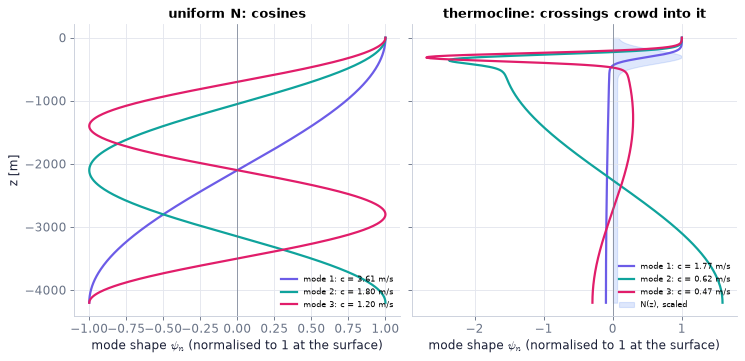

thermocline modes: c = [1.769 0.618 0.465] m/s; H_e of mode 1 = 0.319 m; Rossby radius at 35 N = 21.1 km
mode 1 changes sign at z = -441 m; WKB estimate of c_1 = 1.30 m/s (-26 %)


In [96]:
N2_th = ch13.thermocline_N2(z_m)                               # N^2(z) with a thermocline at -300 m (defaults; ours)
m_th = VM.vertical_modes(z_m, N2_th, n_modes=4, lid="free")    # its modes
fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 4.4), sharey=True)   # a new figure and its panel(s); figsize in inches
for n_, col in zip((1, 2, 3), (COLORS["accent"], COLORS["teal"], COLORS["rose"])):   # the first three baroclinic modes
    a.plot(m_free.psi[n_], z_m, color=col, label=f"mode {n_}: c = {m_free.c[n_]:.2f} m/s")   # uniform N: cosines
    b.plot(m_th.psi[n_], z_m, color=col, label=f"mode {n_}: c = {m_th.c[n_]:.2f} m/s")       # thermocline profile
b.fill_betweenx(z_m, 0, np.sqrt(N2_th)/np.sqrt(N2_th).max(), color=COLORS["blue"], alpha=0.15, label="N(z), scaled")   # the stratification behind
for ax, ttl in ((a, "uniform N: cosines"), (b, "thermocline: crossings crowd into it")):
    ax.axvline(0, color=COLORS["muted"], lw=0.6)   # a thin reference line
    ax.set(xlabel=r"mode shape $\psi_n$ (normalised to 1 at the surface)", title=ttl)   # axis labels (with units), title and fixed ranges of this panel
    ax.legend(fontsize=7, loc="lower right")   # the legend names every curve
a.set_ylabel("z [m]")   # label / range / scale of this axis
plt.show()   # display the figure
zero_x = z_m[np.where(np.diff(np.sign(m_th.psi[1])) != 0)[0][0]]   # the depth where mode 1 changes sign
print(f"thermocline modes: c = {np.round(m_th.c[1:4], 3)} m/s; H_e of mode 1 = {m_th.He[1]:.3f} m; Rossby radius at 35 N = {GFD.rossby_radius(m_th.c[1], f35)/1e3:.1f} km")   # speeds and scales
print(f"mode 1 changes sign at z = {zero_x:.0f} m; WKB estimate of c_1 = {VM.wkb_mode_speed(z_m, np.sqrt(N2_th), n=1):.2f} m/s ({100*(VM.wkb_mode_speed(z_m, np.sqrt(N2_th), n=1)/m_th.c[1] - 1):+.0f} %)")   # how good the slowly-varying estimate is

**What you see.** The first three internal modes for uniform stratification (left) and for a profile with a sharp thermocline (right, with $N(z)$ shaded in blue).

**How to read it.** Mode $n$ crosses zero $n$ times. With a thermocline the crossings crowd into it, the deep ocean moves as one slab, and the modes are slower. The printed WKB estimate $\int N\,dz/(n\pi)$ misses the first speed by a quarter — a sharp thermocline is not a slowly varying medium.

**What would change if…** …the thermocline were deeper? Next figure.

In [97]:
z_f6 = np.linspace(-H_o, 0.0, 141)                             # a coarser grid (141 nodes) for fifteen eigen-solves

def f6(depth):                                                 # curves for one thermocline depth [m]
    N2_ = ch13.thermocline_N2(z_f6, z_t=-depth)                # N^2(z) with the thermocline centred at -depth
    md = VM.vertical_modes(z_f6, N2_, n_modes=4, lid="free")   # its modes
    top = z_f6 >= -2000.0                                      # only the top 2000 m are drawn
    return {"N(z), scaled to 1": ((np.sqrt(N2_)/np.sqrt(N2_).max())[top], z_f6[top]),   # hand the result back to the caller
            "mode 1": (md.psi[1][top], z_f6[top]), "mode 2": (md.psi[2][top], z_f6[top]), "mode 3": (md.psi[3][top], z_f6[top])}

figF6 = slider_figure(f6, "thermocline depth", np.arange(100.0, 801.0, 50.0), unit="m", xlabel="ψ_n (and N scaled)",
                      ylabel="z [m]", title="A deeper thermocline is a faster first mode", xrange=(-4, 4), yrange=(-2000, 0))   # 15 slider positions
figF6.show()   # display the interactive figure (the slider works on the web page too)
for d_ in (150.0, 300.0, 600.0):                               # three thermocline depths [m]
    md_ = VM.vertical_modes(z_f6, ch13.thermocline_N2(z_f6, z_t=-d_), n_modes=4, lid="free")   # modes for each
    print(f"thermocline at {d_:.0f} m: c_1 = {md_.c[1]:.3f} m/s, H_e = {md_.He[1]:.3f} m, c_2 = {md_.c[2]:.3f}, c_3 = {md_.c[3]:.3f} m/s")   # the speeds the slider cannot show in its legend

thermocline at 150 m: c_1 = 1.228 m/s, H_e = 0.154 m, c_2 = 0.626, c_3 = 0.402 m/s
thermocline at 300 m: c_1 = 1.746 m/s, H_e = 0.311 m, c_2 = 0.617, c_3 = 0.460 m/s
thermocline at 600 m: c_1 = 2.437 m/s, H_e = 0.605 m, c_2 = 0.588, c_3 = 0.480 m/s


**What does the code above do?**

1. `f6` rebuilds $N^2(z)$ with the thermocline at the chosen depth, solves the eigenproblem and returns the first three
   baroclinic modes (only the top 2000 m are shown).
2. The printed lines give the speeds and the equivalent depth for three positions of the slider.

**What you see.** The stratification (scaled) and the first three internal modes in the top 2000 m, for the chosen thermocline depth.

**How to read it.** The zero crossing of mode 1 follows the thermocline down, and its speed grows (printed lines). A deeper thermocline is a faster first mode — the El Niño thermocline signal in one slider.

**What would change if…** …the thermocline were sharper? The modes would bend more abruptly there; the WKB estimate would be worse still.

📝 **Note.** **N77 [B]** **The fine print.** The decomposition needs a flat bottom and no sheared mean current; it is hydrostatic, so it holds for
$\omega\ll N$ and the shapes do not depend on frequency; it is valid with or without $f$ and $\beta$.

#### 🎮 Interactive: How can one layer stand for a stratified ocean?

**Why interactive rather than a static figure:** reshaping $N(z)$ and watching the shapes, speeds and equivalent depths respond shows what the eigenproblem does; stepping $n$ shows the zero crossings appear one by one; the lid toggle removes the barotropic mode and barely moves the others.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Step n from 0 to 3 and count the zero crossings.
- Deepen the thermocline and watch c₁ and the Rossby radius grow.
- Toggle the rigid lid: the top rung of the ladder disappears, the others do not move.
- Click a depth to see the two terms of the mode equation cancel there.

In [98]:
show_viz("ch13", "vertical_modes")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/vertical_modes]

**What would change if…** …we now ask what waves one of these shallow-water systems supports when the earth turns? One cubic equation answers for all
of them (`C09`).

---

## 13.10 High- and Low-Frequency Regimes in Shallow-Water Equations

**What is this section about?** One equation that contains every wave of a rotating shallow layer, and how to tell, from the
frequency alone, which terms matter.

### 🧩 The complete dispersion relation of rotating shallow water: $\omega^3-c^2\omega K^2-f_0^2\omega-c^2\beta k=0$, with $K^2=k^2+l^2$, $c=\sqrt{gH}$ (13.76) `C09`

*The question:* Poincaré, Kelvin, Rossby — how many different kinds of wave does one layer of water really have?

#### The problem in plain words

A weather forecast must not let fast gravity waves swamp the slow weather; a tide model wants exactly those fast waves. Both
run the same equations. The waves separate by frequency: two fast ones (period hours) that are gravity waves bent by rotation,
and one slow one (period days to years) that exists only because the Coriolis parameter changes with latitude. Knowing which
is which tells a modeller which terms may be dropped.

#### The idea

The cubic has four terms, each with its own physics:

| Term | What it stands for | Fast waves ($\omega>f_0$) | Slow wave ($\omega\ll f_0$) |
|---|---|---|---|
| $\omega^3$ | pure change in time | large — balances the next two | negligible |
| $-c^2K^2\omega$ | gravity (the surface slope) | large | large |
| $-f_0^2\omega$ | rotation | large | large |
| $-c^2\beta k$ | the change of $f$ with latitude | negligible | balances the two above |

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **plane wave e^(i(kx+ly−ωt)); wavenumbers k, l; K** — a field $\hat v\,e^{i(kx+ly-\omega t)}$ (real part understood) is a wave with crests $2\pi/K$ apart, $K=\sqrt{k^2+l^2}$; $\partial/\partial t\to-i\omega$, $\partial/\partial x\to ik$, $\partial/\partial y\to il$. *(Ch. 7, P176)*
- **`np.roots`** — `np.roots([a, b, c, d])` returns the (possibly complex) roots of $a\omega^3+b\omega^2+c\omega+d$. *(Ch. 11, P256)*
- **dominant balance; three frequency regimes** — when the terms of an equation differ greatly in size, the largest two must balance each other and the smallest may be dropped — then check the dropped one really was small. *(Ch. 8, P198)*
- **phase speed ω/k** — a crest of $\cos(kx-\omega t)$ moves at $c=\omega/k$. *(Ch. 7, P165)*

#### 🧮 Derivation — One equation for v, from the linear shallow-water set on a β-plane `D12` ★★★ (Eq. 13.75: $\frac{\partial^3v}{\partial t^3}-gH\frac{\partial}{\partial t}\nabla_H^2v+f_0^2\frac{\partial v}{\partial t}-gH\beta\frac{\partial v}{\partial x}=0$)

**What we want to show.** Eliminate u and η from the three shallow-water equations so that a single equation for v remains, valid at all frequencies.

**Assumptions.** Linear; β-plane: f is treated as the constant f₀ except where it is differentiated (steps 6, 8; trap T10).

**The plan.**

1. Remove η by one time-derivative of each momentum equation.
2. Remove ∂²u/∂t² between the two.
3. Build a vorticity equation to remove what is left of u.
4. Add.

**Tools we use** (each explained before this point): operator elimination for linear PDEs (P177, reminder) · cross-differentiation · Schwarz's theorem (P121)

**We start from**

$$ \begin{array}{l}\dfrac{\partial\eta}{\partial t}+H\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)=0\ \text{,}\ \dfrac{\partial u}{\partial t}-fv=-g\dfrac{\partial\eta}{\partial x}\ \text{,} \\ \dfrac{\partial v}{\partial t}+fu=-g\dfrac{\partial\eta}{\partial y}\ \text{(13.45) with}\ f=f_0+\beta y\ \text{(13.10)}\end{array} $$

*In words:* The linear shallow-water set, now with f varying northward

---

**Step 1 of 10 — Differentiate the x-momentum equation in time.**

$$ \dfrac{\partial^2u}{\partial t^2}-f\dfrac{\partial v}{\partial t}=-g\dfrac{\partial^2\eta}{\partial x\,\partial t} $$

- *Why we can do this:* The parameter f does not depend on t; the aim is to make ∂η/∂t appear, because continuity can replace it.
- *In words:* How the acceleration of u changes.

---

**Step 2 of 10 — Replace ∂η/∂t by continuity.**

$$ \dfrac{\partial^2u}{\partial t^2}-f\dfrac{\partial v}{\partial t}=gH\dfrac{\partial}{\partial x}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)\ \text{(13.72)} $$

- *Why we can do this:* Continuity gives $\partial\eta/\partial t=-H(\partial u/\partial x+\partial v/\partial y)$; the two minus signs cancel.
- *In words:* The surface height η is gone from the x-equation.

---

**Step 3 of 10 — Do the same to the y-momentum equation.**

$$ \dfrac{\partial^2v}{\partial t^2}+f\dfrac{\partial u}{\partial t}=gH\dfrac{\partial}{\partial y}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)\ \text{(13.73)} $$

- *Why we can do this:* The identical two moves; H is constant and passes through ∂/∂y.
- *In words:* Now η is gone from both.

---

**Step 4 of 10 — Differentiate step 3 in time and remove ∂²u/∂t².**

$$ \begin{array}{l}\dfrac{\partial^3v}{\partial t^3}+f\Big[f\dfrac{\partial v}{\partial t}+gH\dfrac{\partial}{\partial x}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)\Big]=gH\dfrac{\partial^2}{\partial y\,\partial t}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big) \\ \text{(13.74)}\end{array} $$

- *Why we can do this:* The time derivative of step 3 contains $f\,\partial^2u/\partial t^2$; step 2 gives that quantity as the square bracket.
- *In words:* Now u appears only inside the divergence.

---

**Step 5 of 10 — Cross-differentiate the original momentum equations.**

$$ \dfrac{\partial}{\partial t}\Big(\dfrac{\partial u}{\partial y}-\dfrac{\partial v}{\partial x}\Big)-\dfrac{\partial(fv)}{\partial y}-\dfrac{\partial(fu)}{\partial x}=0 $$

- *Why we can do this:* ∂/∂y of the x-equation minus ∂/∂x of the y-equation; the pressure terms $g\,\partial^2\eta/\partial x\partial y$ cancel (Schwarz).
- *In words:* A vorticity equation with no η in it.

---

**Step 6 of 10 — Differentiate the products.**

$$ \dfrac{\partial}{\partial t}\Big(\dfrac{\partial u}{\partial y}-\dfrac{\partial v}{\partial x}\Big)-f_0\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)-\beta v=0 $$

- *Why we can do this:* Product rule: $\partial(fv)/\partial y=f\,\partial v/\partial y+\beta v$ because df/dy = β, while f does not depend on x; then f → f₀ in the undifferentiated factor.
- *In words:* Vorticity changes through divergence and through northward motion.

---

**Step 7 of 10 — Take ∂/∂x and multiply by gH.**

$$ gH\dfrac{\partial^2}{\partial t\,\partial x}\Big(\dfrac{\partial u}{\partial y}-\dfrac{\partial v}{\partial x}\Big)-f_0\,gH\dfrac{\partial}{\partial x}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)-gH\beta\dfrac{\partial v}{\partial x}=0 $$

- *Why we can do this:* Chosen so that its middle term is minus the term $f\,gH\,\partial(\ldots)/\partial x$ of step 4.
- *In words:* The vorticity equation, dressed to match step 4.

---

**Step 8 of 10 — Add step 7 to step 4 (with f → f₀).**

$$ \dfrac{\partial^3v}{\partial t^3}+f_0^2\dfrac{\partial v}{\partial t}+gH\dfrac{\partial}{\partial t}\Big[\dfrac{\partial^2u}{\partial x\,\partial y}-\dfrac{\partial^2v}{\partial x^2}-\dfrac{\partial^2u}{\partial y\,\partial x}-\dfrac{\partial^2v}{\partial y^2}\Big]-gH\beta\dfrac{\partial v}{\partial x}=0 $$

- *Why we can do this:* The two $f_0\,gH\,\partial(\ldots)/\partial x$ terms cancel; the remaining divergence terms are collected under one ∂/∂t.
- *In words:* Only time and space derivatives of u and v remain.

---

**Step 9 of 10 — Cancel the mixed derivatives of u.**

$$ \dfrac{\partial^2u}{\partial x\,\partial y}-\dfrac{\partial^2u}{\partial y\,\partial x}=0\ \Rightarrow\ [\ \cdot\ ]=-\Big(\dfrac{\partial^2v}{\partial x^2}+\dfrac{\partial^2v}{\partial y^2}\Big)=-\nabla_H^2v $$

- *Why we can do this:* Schwarz's theorem again; this is the step that finally removes u.
- *In words:* The velocity u has dropped out completely.

---

**Step 10 of 10 — Write the result.**

$$ \dfrac{\partial^3v}{\partial t^3}-gH\dfrac{\partial}{\partial t}\nabla_H^2v+f_0^2\dfrac{\partial v}{\partial t}-gH\beta\dfrac{\partial v}{\partial x}=0\ \text{(13.75)} $$

- *Why we can do this:* Insert step 9 into step 8 and order the terms as the book does.
- *In words:* One equation for the northward velocity: gravity, rotation and β each contribute one term.

---

**Result**

$$ \dfrac{\partial^3v}{\partial t^3}-gH\dfrac{\partial}{\partial t}\nabla_H^2v+f_0^2\dfrac{\partial v}{\partial t}-gH\beta\dfrac{\partial v}{\partial x}=0\ \text{, with}\ \nabla_H^2=\partial^2/\partial x^2+\partial^2/\partial y^2 $$

*In words:* Every wave of the rotating shallow-water layer satisfies this

**What it means.** The three time derivatives are why there are three waves per wavenumber (D13). **Fails when:** βy is not small against f₀ (large north–south extent, or near the equator), or the waves are not small.

**Check it.** Units — every term is (m/s)/s³ ✓ (gHβ ∂v/∂x: m²/s² · 1/(m s) · 1/s). Limits — f₀ = β = 0: $v_{tt}=gH\nabla_H^2v$ after one time integration, the wave equation of Chapter 7; β = 0 and no time dependence: any steady v is allowed (geostrophic flow).

In [99]:
import sympy as sp                                            # symbolic algebra
s, a, b = sp.symbols("s a b")                                 # stand-ins for d/dt, d/dx, d/dy (they commute)
u, v = sp.symbols("u v")                                      # the two velocity components (any plane wave)
f0, beta, gH = sp.symbols("f_0 beta gH", positive=True)       # f0, beta and the product g*H
div = a * u + b * v                                           # horizontal divergence du/dx + dv/dy
e72 = s**2 * u - f0 * s * v - gH * a * div                    # step 2: (13.72) with everything on the left
e73 = s**2 * v + f0 * s * u - gH * b * div                    # step 3: (13.73)
e74 = sp.expand(s * e73 - f0 * e72)                           # step 4: d/dt of (13.73), then remove d2u/dt2
book74 = s**3 * v + f0 * (f0 * s * v + gH * a * div) - gH * b * s * div   # (13.74) as printed
assert sp.expand(e74 - book74) == 0                           # our step 4 is the book's (13.74)
vort = s * (b * u - a * v) - f0 * div - beta * v              # step 6: the linear vorticity equation
single = sp.expand(e74 + gH * a * vort)                       # steps 7-8: add gH d/dx of the vorticity equation
target = s**3 * v - gH * s * (a**2 + b**2) * v + f0**2 * s * v - gH * beta * a * v   # step 10: (13.75)
assert sp.expand(single - target) == 0                        # step 9: u has dropped out, one equation for v
k, l, w = sp.symbols("k l omega", real=True)                  # plane wave exp(i(kx + ly - wt))
disp = sp.expand((target / v).subs({s: -sp.I * w, a: sp.I * k, b: sp.I * l}) / sp.I)   # D13 steps 1-2
assert sp.expand(disp - (w**3 - gH * w * (k**2 + l**2) - f0**2 * w - gH * beta * k)) == 0   # (13.76)
print("D12 checks passed: (13.74), the elimination of u, (13.75) and the cubic (13.76)")

D12 checks passed: (13.74), the elimination of u, (13.75) and the cubic (13.76)


> ⚠️ **Common confusion (traps in `D12`):** f is replaced by f₀ everywhere except where it is differentiated; the two $f_0\,gH\,\partial(\ldots)/\partial x$ terms cancel only because the vorticity equation is brought in; keep track of the order of the time derivatives.

📝 **Note.** **N78 [C]** **Steps 2–3 of `D12`:** $\dfrac{\partial^2u}{\partial t^2}-f\dfrac{\partial v}{\partial t}=gH\dfrac{\partial}{\partial x}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)$ and
$\dfrac{\partial^2v}{\partial t^2}+f\dfrac{\partial u}{\partial t}=gH\dfrac{\partial}{\partial y}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)$ (13.72)–(13.73).

📝 **Note.** **N79 [C]** **Step 4:** $\dfrac{\partial^3v}{\partial t^3}+f\Big[f\dfrac{\partial v}{\partial t}+gH\dfrac{\partial}{\partial x}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)\Big]=gH\dfrac{\partial^2}{\partial y\,\partial t}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)$ (13.74).

📝 **Note.** **N80 [B]** **The linear vorticity equation on the β-plane** (step 6):
$\dfrac{\partial}{\partial t}\Big(\dfrac{\partial u}{\partial y}-\dfrac{\partial v}{\partial x}\Big)-f_0\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)-\beta v=0$
— the first appearance of the idea that `C13` turns into potential vorticity.

📝 **Note.** **N81 [B]** **One equation for $v$** (the result of `D12`):
$\dfrac{\partial^3v}{\partial t^3}-gH\dfrac{\partial}{\partial t}\nabla_H^2v+f_0^2\dfrac{\partial v}{\partial t}-gH\beta\dfrac{\partial v}{\partial x}=0$ (13.75).

> ⚠️ **Common confusion (trap T10):** The parameter $f$ is replaced by the constant $f_0$ everywhere except where it is differentiated (that derivative is $\beta$).

In [100]:
print("the single equation for v (13.75) follows from the linear set on a beta-plane ->", ch13.v_equation_sympy()["ok"])   # True

the single equation for v (13.75) follows from the linear set on a beta-plane -> True


**What does this show?** The engine carries out the eliminations of `D12` on symbolic fields and is left with nothing.

> 📎 **Primer — three real roots of a cubic: the discriminant and the trigonometric form.** `P319` · A cubic $\omega^3+p\omega+q=0$ with real $p$, $q$ has three real roots exactly when its discriminant $-4p^3-27q^2$ is positive
(this needs $p<0$). They are then given without complex arithmetic by
$\omega_j=2\sqrt{-p/3}\,\cos\big[\tfrac13\arccos\big(\tfrac{3q}{2p}\sqrt{-3/p}\big)-\tfrac{2\pi j}3\big]$, $j=0,1,2$. When one root is
thousands of times smaller than the others this form keeps its digits; a general polynomial solver may not.

In [101]:
p, q = -7.0, 6.0                                               # w^3 - 7w + 6 = (w - 1)(w - 2)(w + 3)
print("discriminant =", -4*p**3 - 27*q**2)                     # 400 > 0: three real roots
m = 2*np.sqrt(-p/3); th = np.arccos(3*q/(p*m))/3               # the amplitude and the angle of the trigonometric form
print("roots:", np.sort(m*np.cos(th - 2*np.pi*np.arange(3)/3)))   # [-3.  1.  2.]

discriminant = 400.0
roots: [-3.  1.  2.]


#### 🧮 Derivation — The cubic: three real roots, which is which, three regimes `D13` ★★ (Eq. 13.76: $\omega^3-c^2\omega K^2-f_0^2\omega-c^2\beta k=0$)

**What we want to show.** Turn the single equation for v into a relation between frequency and wavenumber, show that it has three real solutions, and learn which terms matter for each.

**Assumptions.** β-plane scaling for step 5 ($\beta c<f_0^2$).

**The plan.**

1. Substitute the wave.
2. Recognise a cubic with no ω² term.
3. Test its discriminant.
4. Find the fast pair and the slow root by dominant balance.

**Tools we use** (each explained before this point): plane-wave substitution (P176, reminder) · the discriminant and trigonometric form of a cubic (P319) · dominant balance (P198, reminder)

**We start from**

$$ \begin{array}{l}\dfrac{\partial^3v}{\partial t^3}-gH\dfrac{\partial}{\partial t}\nabla_H^2v+f_0^2\dfrac{\partial v}{\partial t}-gH\beta\dfrac{\partial v}{\partial x}=0\ \text{(13.75) and the trial wave} \\ v=\hat v\,e^{i(kx+ly-\omega t)}\end{array} $$

*In words:* The Result of D12 and a plane wave

---

**Step 1 of 7 — Substitute the plane wave.**

$$ (-i\omega)^3\hat v-gH(-i\omega)\big(-k^2-l^2\big)\hat v+f_0^2(-i\omega)\hat v-gH\beta(ik)\hat v=0 $$

- *Why we can do this:* For this wave each ∂/∂t is a factor −iω, each ∂/∂x a factor ik, each ∂/∂y a factor il; the exponential cancels.
- *In words:* A differential equation has become algebra.

---

**Step 2 of 7 — Divide by $i\hat v$.**

$$ \omega^3-c^2\omega K^2-f_0^2\omega-c^2\beta k=0\ \text{(13.76), with}\ K^2=k^2+l^2\ \text{,}\ c=\sqrt{gH} $$

- *Why we can do this:* Because $(-i)^3=i$, every term carries one factor i; divide it out, with $\hat v\neq0$.
- *In words:* A cubic in ω: three waves for every wavenumber.

---

**Step 3 of 7 — Identify the coefficients.**

$$ \omega^3+p\,\omega+q=0,\qquad p=-(c^2K^2+f_0^2),\qquad q=-c^2\beta k $$

- *Why we can do this:* There is no ω² term, so the cubic is already in "depressed" form and the three roots sum to zero.
- *In words:* The coefficient p collects gravity and rotation, and q is the β term.

---

**Step 4 of 7 — Form the discriminant.**

$$ \Delta=-4p^3-27q^2=4\big(c^2K^2+f_0^2\big)^3-27\big(c^2\beta k\big)^2 $$

- *Why we can do this:* A real cubic has three distinct real roots exactly when Δ > 0 (P319). The book asserts this without proof.
- *In words:* The sign of one number decides whether all three waves are real.

---

**Step 5 of 7 — Bound it from below.**

$$ \big(c^2k^2+\tfrac12f_0^2+\tfrac12f_0^2\big)^3\ge\tfrac{27}{4}c^2k^2f_0^4\ \Rightarrow\ \Delta\ge27\,c^2k^2\big(f_0^4-c^2\beta^2\big) $$

- *Why we can do this:* The mean of three positive numbers is at least their geometric mean, and $K^2\ge k^2$. So Δ > 0 whenever $\beta c<f_0^2$: the Rossby radius c/f₀ is smaller than f₀/β = R tan θ₀.
- *In words:* All three roots are real for every wavenumber as long as the β-plane itself makes sense.

---

**Step 6 of 7 — Find the fast roots by dropping the β term.**

$$ \omega\big(\omega^2-c^2K^2-f_0^2\big)=0\ \Rightarrow\ \omega=\pm\sqrt{f_0^2+c^2K^2} $$

- *Why we can do this:* For $\lvert\omega\rvert\ge\lvert f_0\rvert$ the ratio of the β term to the second term is of order β/(ωK) — about 0.02 for our 3100 km wave at 35° N (the code cell below prints the terms), smaller for shorter waves; neglect it.
- *In words:* Two gravity waves bent by rotation, one in each direction, never slower than f₀.

---

**Step 7 of 7 — Find the slow root by dropping ω³.**

$$ \omega\simeq-\dfrac{c^2\beta k}{c^2K^2+f_0^2}=-\dfrac{\beta k}{K^2+f_0^2/c^2} $$

- *Why we can do this:* For $\lvert\omega\rvert\ll\lvert f_0\rvert$, ω³ is smaller than $f_0^2\omega$ by $(\omega/f_0)^2$; the remaining three terms balance.
- *In words:* One slow wave that exists only because of β and moves its crests westward.

---

**Result**

$$ \begin{array}{l}\omega^3-c^2\omega K^2-f_0^2\omega-c^2\beta k=0\ \text{has three real roots when}\ \beta c<f_0^2\ \text{:}\ \omega\simeq\pm\sqrt{f_0^2+c^2K^2}\ \text{(fast) and} \\ \omega\simeq-\beta k/(K^2+f_0^2/c^2)\ \text{(slow)}\end{array} $$

*In words:* Two Poincaré waves and one Rossby wave

**What it means.** a model that wants only weather may drop ω³ (filtering the fast waves); a tide model may drop β. **Fails when:** βc is not small against f₀² (external mode at low latitude), where the fixed-f₀ replacement is itself invalid.

**Check it.** Units — every term s⁻³ ✓. Number — 35° N, c = 202.95 m/s, wavelength 3100 km: (−4.1525 × 10⁻⁴, −8.888 × 10⁻⁶, +4.2414 × 10⁻⁴) s⁻¹; sum zero; the approximations of steps 6 and 7 are off by 1 % and 0.04 %. The bound of step 5 is sharp: Δ first reaches zero at $c^2k^2=f_0^2/2$ when βc = f₀² (ours, computed: for c = 203 m/s that is at latitude 26.3°; closer to the equator Δ < 0 for a band of very long waves — the β-plane stretched too far). Code — `GFD.shallow_water_discriminant` is the flag; where it is negative `GFD.shallow_water_omega` returns (nan, nan, nan), e.g. at 12° N with the external speed for a 20 000 km wave.

> ⚠️ **Common confusion (traps in `D13`):** The sign of the β term (with the wrong sign the slow wave would go east); the fast roots have opposite signs and satisfy only abs(ω) > abs(f₀) (trap T9); slip #7 — the book prints ω ≫ f for the range where ω³ is negligible, the correct form is ω ≪ f; the slow root is a thousandth of the fast ones — compare roots with relative tolerances.

📝 **Note.** **N82 [B]** **All three roots are real** (steps 4–5 of `D13`): the discriminant $4(c^2K^2+f_0^2)^3-27(c^2\beta k)^2$ is positive under
β-plane scaling (the book says only that this "can be shown").

> ⚠️ **Common confusion (trap T9):** "Two superinertial, one subinertial" is true under β-plane scaling; the two fast roots have opposite signs and only satisfy
$\lvert\omega\rvert>\lvert f_0\rvert$, not $\omega\gg f$.

📝 **Note.** **N83 [B]** **Three regimes** (steps 6–7 of `D13`), from the two scale ratios $\dfrac{c^2\beta k}{c^2\omega K^2}\sim\dfrac\beta{\omega K}$ and
$\dfrac{\omega^3}{c^2\beta k}\ll1$: high frequency (drop $\beta$ and, further up, $f_0$), near-inertial (drop $\beta$), low frequency
(drop $\omega^3$).

> ⚠️ **slip #7 — the book prints** $\omega\gg f$ as the range in which the first term of $\omega^3-c^2\omega K^2-f_0^2\omega-c^2\beta k=0$ (13.76) is negligible **; the correct form is** $\omega\ll f$.

> 📎 **Primer — reading a dispersion diagram with several branches: signed ω for signed k, a logarithmic frequency axis.** `P320` · A dispersion diagram plots frequency against wavenumber; each curve ("branch") is one kind of wave. The slope of the line from
the origin to a point is the phase speed, the slope of the curve itself the group velocity. We let $k$ carry the direction
($k>0$ eastward) and keep $\omega\ge0$ for the plot; when branches differ by factors of a thousand, the frequency axis must be
logarithmic or the slow branch hides on the axis.

In [102]:
k = np.array([1e-7, 1e-6, 1e-5])                               # three wavenumbers [rad/m]
print("fast branch [1e-4 1/s]:", np.round(1e4*np.sqrt(1e-8 + 4e4*k**2), 3))   # flattens to f = 1e-4 as k -> 0
print("slow branch [1e-6 1/s]:", np.round(1e6*2e-11*k/(k**2 + 2.5e-13), 2))   # rises, peaks, falls

fast branch [1e-4 1/s]: [ 1.02   2.236 20.025]
slow branch [1e-6 1/s]: [ 7.69 16.    2.  ]


#### ✏️ Tiny example: fast and slow root by hand

Our 35° N inputs, rounded: $f_0=8.4\times10^{-5}$ s⁻¹, $\beta=1.9\times10^{-11}$ m⁻¹ s⁻¹, external speed $c=203$ m/s
($c^2=4.12\times10^{4}$ m² s⁻²), $k=2\times10^{-6}$ m⁻¹ (wavelength 3140 km), $l=0$.

1. **Fast:** drop the β term → $\omega^2=f_0^2+c^2k^2=0.07\times10^{-7}+1.65\times10^{-7}=1.72\times10^{-7}$ → $\omega=\pm4.15\times10^{-4}$ s⁻¹ (period 4.2 h).
2. **Slow:** drop $\omega^3$ → $\omega=-c^2\beta k/(c^2k^2+f_0^2)=-(4.12\times10^{4}\times1.9\times10^{-11}\times2\times10^{-6})/(1.72\times10^{-7})=-9.1\times10^{-6}$ s⁻¹
   (period 8 days; minus = westward for $k>0$).
3. Was dropping $\omega^3$ fair? Compare $(9.1\times10^{-6})^3=7.5\times10^{-16}$ against $c^2\beta k=1.57\times10^{-12}$: one part in two thousand.
4. The sum of the three roots must be 0 (there is no $\omega^2$ term): so the fast pair is not exactly symmetric; the slow root
   is the difference.

In [103]:
c_ext = GFD.long_wave_speed(H_o)                               # external (barotropic) long-wave speed of a 4200 m ocean [m/s]
k31 = 2*np.pi/3.1e6                                            # eastward wavenumber of a 3100 km wave [rad/m]
w3 = GFD.shallow_water_omega(k31, 0.0, c_ext, f35, beta35)     # Eq. (13.76): the three real roots, in ascending order [rad/s]
print("external mode, three roots [1/s]:", [f"{w_:+.4e}" for w_ in w3])                      # fast westward, slow westward, fast eastward
print(f"periods: fast {2*np.pi/w3[2]/3600:.2f} h, slow {2*np.pi/abs(w3[1])/86400:.2f} days; slow/fast = {abs(w3[1])/w3[2]:.3f}")   # decades apart
print("discriminant > 0:", GFD.shallow_water_discriminant(k31, 0.0, c_ext, f35, beta35) > 0, "| regime of the slow root:", GFD.shallow_water_regime(w3[1], f35))   # three real roots; which term to drop
sz = GFD.dispersion_term_sizes(k31, 0.0, c_ext, f35, beta35, w3[1])   # the four terms of the cubic at the slow root
print("terms at the slow root:", {k_: f"{v_:+.2e}" for k_, v_ in sz.items()})                # omega^3 is by far the smallest
w3b = GFD.shallow_water_omega(k31, 0.0, 3.6096, f35, beta35)   # the same wave on the first baroclinic mode (c = 3.61 m/s)
print("first baroclinic mode [1/s]:", [f"{w_:+.4e}" for w_ in w3b], f"-> {2*np.pi/w3b[2]/3600:.1f} h and {2*np.pi/abs(w3b[1])/86400/365.25:.1f} years")   # even further apart
br = GFD.shallow_water_branches(k31, 0.0, c_ext, f35, beta35)  # the same roots by name, plus the Kelvin line c k
print("branches:", {k_: f"{v_:+.3e}" for k_, v_ in br.items()})                              # Poincare (two), Rossby, Kelvin
k20 = 2*np.pi/2.0e7                                            # a 20 000 km wave at 12 N: outside the range where the cubic has three real roots
disc20 = GFD.shallow_water_discriminant(k20, 0.0, c_ext, f12, beta12)   # the flag to test first
w20 = GFD.shallow_water_omega(k20, 0.0, c_ext, f12, beta12)    # there the function returns "not a number" for all three roots
print(f"12 N, 20 000 km, external mode: discriminant = {disc20:.2e} (negative) -> three real roots exist: {not np.isnan(w20).any()}")   # test the discriminant first

external mode, three roots [1/s]: ['-4.1525e-04', '-8.8883e-06', '+4.2414e-04']
periods: fast 4.12 h, slow 8.18 days; slow/fast = 0.021
discriminant > 0: True | regime of the slow root: {'ratio': 0.10625338887773475, 'regime': 'low', 'neglect': 'omega^3'}
terms at the slow root: {'omega3': '-7.02e-16', 'gravity': '+1.50e-12', 'rotation': '+6.22e-14', 'beta': '-1.57e-12', 'sum': '-2.02e-28'}
first baroclinic mode [1/s]: ['-8.3936e-05', '-7.0229e-08', '+8.4006e-05'] -> 20.8 h and 2.8 years
branches: {'poincare_plus': '+4.241e-04', 'poincare_minus': '-4.152e-04', 'rossby': '-8.888e-06', 'kelvin': '+4.113e-04'}
12 N, 20 000 km, external mode: discriminant = -1.77e-24 (negative) -> three real roots exist: False


**What does the code above do?**

1. `GFD.shallow_water_omega(k, l, c, f0, beta)` returns the three real roots of $\omega^3-c^2\omega K^2-f_0^2\omega-c^2\beta k=0$ *(13.76)* by the trigonometric form
   of the primer.
2. For a 3100 km wave on the external mode the fast roots have periods of about 4 hours and the slow one about 8 days.
3. `GFD.dispersion_term_sizes` evaluates the four terms at a root: at the slow root $\omega^3$ is the smallest by orders of
   magnitude; `GFD.shallow_water_regime` names the term that may be dropped.
4. On the first baroclinic mode ($c=3.6$ m/s) the same wave has periods of about 21 hours and nearly 3 years.
5. **The caveat:** where `GFD.shallow_water_discriminant` is negative the cubic has only one real root, and
   `GFD.shallow_water_omega` returns NaN ("not a number") for all three. Test the discriminant first; NaN is the function's
   way of saying "no three real roots here". The figure after next explains where that happens.

In [104]:
# From scratch: the same cubic handed to a general polynomial solver
roots_mine = np.sort(np.roots([1.0, 0.0, -(c_ext**2*k31**2 + f35**2), -c_ext**2*beta35*k31]).real)   # coefficients of w^3, w^2, w, 1
assert np.allclose(roots_mine, w3, rtol=1e-9)                  # same three roots as the trigonometric form
assert abs(sum(w3))/max(abs(np.array(w3))) < 1e-12             # no w^2 term -> the roots sum to zero
print("✓ np.roots gives", [f"{r_:+.4e}" for r_ in roots_mine], f"1/s; the three roots sum to {sum(w3):.1e}")   # visible confirmation

✓ np.roots gives ['-4.1525e-04', '-8.8883e-06', '+4.2414e-04'] 1/s; the three roots sum to 0.0e+00


**What does the code above do?**

`np.roots` finds the same three roots, and their sum vanishes as it must for a cubic with no $\omega^2$ term — which is why
the two fast roots are not exactly equal and opposite.

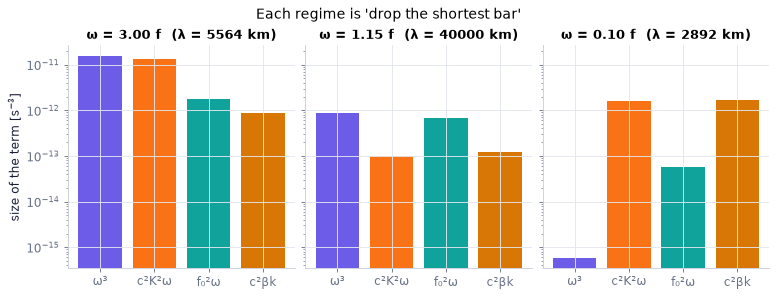

35 N, external: beta c / f0^2 = 0.5438  ->  three real roots for every wavelength: True
35 N, first baroclinic: beta c / f0^2 = 0.0097  ->  three real roots for every wavelength: True
12 N, external: beta c / f0^2 = 4.9424  ->  three real roots for every wavelength: False


In [105]:
ks = np.geomspace(2*np.pi/4.0e7, 2*np.pi/2.0e5, 600)           # wavenumbers from a 40 000 km to a 200 km wave [rad/m]
roots_all = np.array([GFD.shallow_water_omega(k_, 0.0, c_ext, f35, beta35) for k_ in ks])   # the three roots for each (35 N, external mode)
cases = []                                                     # (label, wavenumber, root) for three frequencies
for target, col_ in ((3.0, 2), (1.02, 2), (0.1, 1)):           # 3f and about f on the fast branch; 0.1 f on the slow branch
    j_ = np.argmin(abs(abs(roots_all[:, col_])/f35 - target))  # the wavenumber whose root is closest to the target
    cases.append((f"ω = {abs(roots_all[j_, col_])/f35:.2f} f", ks[j_], roots_all[j_, col_]))
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.6), sharey=True)   # a new figure and its panel(s); figsize in inches
for ax, (lab, k_, w_) in zip(axes, cases):                     # one panel per frequency
    t4 = GFD.dispersion_term_sizes(k_, 0.0, c_ext, f35, beta35, w_)   # the four terms of Eq. (13.76) at this root
    vals = [abs(t4["omega3"]), abs(t4["gravity"]), abs(t4["rotation"]), abs(t4["beta"])]   # their magnitudes
    ax.bar(range(4), vals, color=[COLORS["accent"], COLORS["orange"], COLORS["teal"], COLORS["amber"]])   # purple, orange, teal, amber
    ax.set_xticks(range(4), ["ω³", "c²K²ω", "f₀²ω", "c²βk"])   # the names of the four terms
    ax.set(yscale="log", title=f"{lab}  (λ = {2*np.pi/k_/1e3:.0f} km)")   # axis labels (with units), title and fixed ranges of this panel
axes[0].set_ylabel("size of the term [s$^{-3}$]")   # label / range / scale of this axis
fig.suptitle("Each regime is 'drop the shortest bar'")   # the message of the whole figure
plt.show()   # display the figure
for nm, c_, f_, b_ in (("35 N, external", c_ext, f35, beta35), ("35 N, first baroclinic", 3.6096, f35, beta35), ("12 N, external", c_ext, f12, beta12)):   # three settings
    print(f"{nm}: beta c / f0^2 = {b_*c_/f_**2:.4f}  ->  three real roots for every wavelength: {b_*c_/f_**2 < 1}")   # the condition of the caveat

**What you see.** The magnitudes of the four terms of the cubic at three frequencies: three times $f$ and just above $f$ on the fast branch, and a tenth of $f$ on the slow branch.

**How to read it.** At $3f$ the $\omega^3$ bar is among the tallest and the β bar is the shortest; at $0.1f$ the $\omega^3$ bar is the smallest. Each regime of the book is "drop the shortest bar" — and slip #7 is settled by the right-hand panel.

**What would change if…** …$\beta=0$? The amber bar vanishes and the slow root becomes $\omega=0$ — a steady geostrophic flow, the state that the adjustment of `C12` ends in.

> ⚠️ **An honest caveat (ours, computed).** All three roots are real for every wavelength exactly when $\beta c<f_0^2$, i.e.
> when the Rossby radius $c/f_0$ is smaller than $R\tan\theta_0$. The lines printed above give $\beta c/f_0^2$ for three
> settings: it is below 1 at 35° N for both modes, but far above 1 for the external mode at 12° N. There the discriminant is
> negative for a band of very long waves and the cubic has no three real roots — an artefact of freezing $f$ at $f_0$, not a
> real instability. `GFD.shallow_water_discriminant` is the flag; `GFD.shallow_water_omega` returns NaN there, and the slider
> figure below simply leaves that band blank.

In [106]:
k_f7 = np.geomspace(2*np.pi/4.0e7, 2*np.pi/1.0e5, 50)          # wavenumbers from a 40 000 km to a 100 km wave [rad/m]

def f7(lat_deg):                                               # branches for one latitude [degrees]
    f_ = GFD.coriolis_parameter(np.deg2rad(lat_deg)); b_ = GFD.beta_parameter(np.deg2rad(lat_deg))   # f0 and beta there
    out = {}
    for c_, nm in ((c_ext, "external mode"), (3.6096, "first baroclinic mode")):   # two long-wave speeds
        w_ = np.array([GFD.shallow_water_omega(k_, 0.0, c_, f_, b_) for k_ in k_f7])   # three roots per wavenumber (NaN where there are not three)
        out[f"Poincaré (fast), {nm}"] = (k_f7, w_[:, 2])       # the eastward fast root
        out[f"Rossby (slow), {nm}"] = (k_f7, abs(w_[:, 1]))    # magnitude of the slow root
        out[f"Kelvin line ω = ck, {nm}"] = (k_f7, GFD.kelvin_omega(k_f7, c_))   # explained in C11
    out["ω = f₀"] = (k_f7, f_ + 0*k_f7)                        # the inertial frequency
    return out   # hand the result back to the caller

figF7 = slider_figure(f7, "latitude", np.arange(5.0, 75.1, 5.0), unit="°", xlabel="wavenumber k [rad/m]", ylabel="|ω| [rad/s]",
                      title="Fast and slow branches are decades apart", active=6)   # 15 slider positions, starting at 35 degrees
figF7.update_xaxes(type="log", range=[np.log10(k_f7[0]), np.log10(k_f7[-1])])       # logarithmic wavenumber axis
figF7.update_yaxes(type="log", range=[-9.5, -1.5])                                  # logarithmic frequency axis
figF7.show()   # display the interactive figure (the slider works on the web page too)

**What does the code above do?**

1. `f7` computes, for one latitude and for two long-wave speeds, the fast root, the magnitude of the slow root and the
   straight Kelvin line $\omega=ck$ (its meaning is the subject of `C11`).
2. Both axes are logarithmic. Where the cubic has no three real roots the curves are left blank (the caveat above).

**What you see.** For each mode: a fast branch that flattens onto $\omega=f_0$ for long waves, a slow branch three or more decades below it that rises, peaks and falls, and the straight Kelvin line. At low latitudes the external-mode curves have a gap at the longest waves.

**How to read it.** The empty band of frequencies between the fast and slow branches is the reason filtered ("quasi-geostrophic") models work: one can drop the fast waves without touching the slow one.

**What would change if…** …you slide toward the pole? The parameter $f_0$ rises (the floor of the fast branch moves up) and β falls (the slow branch sinks).

**What would change if…** …we look at the fast roots alone, on an f-plane? They are the gravity waves of Chapter 7 with a floor under their frequency
(`C10`).

---

## 13.11 Gravity Waves with Rotation

**What is this section about?** What rotation does to a long gravity wave: it cannot oscillate more slowly than $f$, it becomes
dispersive, and the water under it moves in ellipses.

### 🧩 Poincaré waves: $\omega^2=f^2+gHK^2$, $K=\sqrt{k^2+l^2}$ (13.82) `C10`

*The question:* What does the earth's rotation do to a long gravity wave?

#### The problem in plain words

After a storm passes, current meters in the open ocean show the water going round in circles a few kilometres across, once
every 17 to 20 hours at mid-latitudes, for days. Nothing is pushing it; it is coasting, and the Coriolis force keeps bending
its path. That circle is the longest possible gravity wave. Shorter waves — the tides among them — are mixtures: partly a
gravity wave sloshing back and forth, partly this turning.

#### The idea

Two restoring forces, two frequencies. Gravity alone gives $\omega=cK$; rotation alone gives $\omega=f$; together
$\omega^2=f^2+c^2K^2$ — add the squares, like the sides of a right triangle.

📝 **Note.** **N84 [B]** **Plane-wave amplitudes on the f-plane:** $-i\omega\hat u-f\hat v=-ikg\hat\eta$, $-i\omega\hat v+f\hat u=-ilg\hat\eta$,
$-i\omega\hat\eta+iH(k\hat u+l\hat v)=0$ (13.77)–(13.79). These are the Start of `D14`.

> 📎 **Primer — polarisation relations: solving a 2 × 2 complex system for the velocity amplitudes.** `P321` · For a plane wave every field is a complex amplitude times the same $e^{i(kx+ly-\omega t)}$. The momentum equations become two
linear equations for the two velocity amplitudes in terms of the height amplitude. Solving them tells how the
current is oriented and timed relative to the surface — the wave's "polarisation". A factor $i$ means a quarter-period shift. *Cramer's rule* for two equations
$a\,x+b\,y=e$, $c\,x+d\,y=g$: $x=(ed-bg)/(ad-bc)$ and $y=(ag-ec)/(ad-bc)$ — each unknown is a ratio of two determinants.

In [107]:
w, f, k, g = 2.0, 1.0, 1.0, 1.0                 # easy numbers, l = 0
M = np.array([[-1j*w, -f], [f, -1j*w]])         # the unknowns are (u_hat, v_hat)
print("(u_hat, v_hat) =", np.round(np.linalg.solve(M, [-1j*k*g, 0.0]), 3))   # [0.667, -0.333j]: v lags u by a quarter period

(u_hat, v_hat) = [ 0.667+0.j    -0.   -0.333j]


> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **`np.linalg.solve`** — `np.linalg.solve(M, b)` solves the linear system `M x = b` (complex entries allowed). *(Ch. 1, P57)*
- **chain rule (implicit differentiation of ω²)** — differentiating $\omega^2=F(k)$ with respect to $k$ gives $2\omega\,\partial\omega/\partial k=F'(k)$ — no square root needed. *(Ch. 1, P49)*
- **a linear map of a circle is an ellipse** — $(a\cos s,\ b\sin s)$ is a circle stretched by $a$ along one axis and $b$ along the other: an ellipse with those semi-axes. *(Ch. 3, P104)*
- **`animate` and `show_animation`** — `animate(update, frames, fig)` calls `update(i)` once per frame; `show_animation(anim, player=…)` shows it as a video or as a frame player with step buttons. *(Ch. 1, P16)*

#### 🧮 Derivation — Poincaré waves: the group velocity `D14` ★★ (Eq. 13.82: $\omega^2=f^2+gHK^2,\ \ \ K=\sqrt{k^2+l^2}$)

**What we want to show.** Find the frequency of a long gravity wave on a rotating plane and how the current is oriented under it.

**Assumptions.** f-plane; ω ≠ ±f in step 2.

**The plan.**

1. Substitute.
2. Solve the two momentum equations for the velocity amplitudes.
3. Put them into continuity.
4. Differentiate the result for the group velocity.

**Tools we use** (each explained before this point): complex amplitudes (P176, reminder) · polarisation relations (P321) · chain rule (P49, reminder)

**We start from**

$$ \begin{array}{l}\dfrac{\partial\eta}{\partial t}+H\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)=0\ \text{,}\ \dfrac{\partial u}{\partial t}-fv=-g\dfrac{\partial\eta}{\partial x}\ \text{,} \\ \dfrac{\partial v}{\partial t}+fu=-g\dfrac{\partial\eta}{\partial y}\ \text{(13.45) with constant f, and}\ (u,v,\eta)=(\hat u,\hat v,\hat\eta)\,e^{i(kx+ly-\omega t)}\end{array} $$

*In words:* The shallow-water set on an f-plane and a plane wave

---

**Step 1 of 8 — Substitute the plane wave.**

$$ -i\omega\hat u-f\hat v=-ikg\hat\eta,\quad-i\omega\hat v+f\hat u=-ilg\hat\eta,\quad-i\omega\hat\eta+iH(k\hat u+l\hat v)=0\ \text{(13.77)–(13.79)} $$

- *Why we can do this:* Each derivative becomes a factor (−iω, ik or il) and the common exponential cancels.
- *In words:* Three algebraic equations for three amplitudes.

---

**Step 2 of 8 — Solve the first two for the velocities.**

$$ \hat u=\dfrac{(-ikg\hat\eta)(-i\omega)-(-f)(-ilg\hat\eta)}{(-i\omega)^2+f^2},\qquad\hat v=\dfrac{(-i\omega)(-ilg\hat\eta)-f(-ikg\hat\eta)}{(-i\omega)^2+f^2} $$

- *Why we can do this:* Cramer's rule for a 2 × 2 system; the determinant is $(-i\omega)(-i\omega)-(-f)(f)=f^2-\omega^2$, non-zero unless ω = ±f.
- *In words:* The current is fixed by the surface slope.

---

**Step 3 of 8 — Tidy up.**

$$ \hat u=\dfrac{g\hat\eta}{\omega^2-f^2}(\omega k+ifl),\qquad\hat v=\dfrac{g\hat\eta}{\omega^2-f^2}(-ifk+\omega l)\ \text{(13.80)} $$

- *Why we can do this:* Multiply out with $i^2=-1$ and change the sign of numerator and denominator.
- *In words:* Part of the current is in step with the surface (the ω terms), part a quarter period out of step (the terms with if).

---

**Step 4 of 8 — Form the divergence amplitude.**

$$ k\hat u+l\hat v=\dfrac{g\hat\eta\,\omega\,(k^2+l^2)}{\omega^2-f^2} $$

- *Why we can do this:* The terms $ifkl$ and $-ifkl$ cancel; only the in-phase parts of the current converge.
- *In words:* The out-of-phase, rotating part of the current does not pile water up.

---

**Step 5 of 8 — Insert into continuity.**

$$ \omega^2-f^2=gH(k^2+l^2)\ \text{(13.81)} $$

- *Why we can do this:* The third equation says $\omega\hat\eta=H(k\hat u+l\hat v)$; substitute step 4 and cancel $\omega\hat\eta\neq0$.
- *In words:* The wave can exist only at this frequency.

---

**Step 6 of 8 — Use the magnitude of the wavenumber.**

$$ \omega^2=f^2+gHK^2,\qquad K=\sqrt{k^2+l^2}\ \text{(13.82)} $$

- *Why we can do this:* A rearrangement; only K appears, so the wave behaves the same in every horizontal direction (isotropy).
- *In words:* Gravity and rotation add their squared frequencies.

---

**Step 7 of 8 — Differentiate for the group velocity (ours).**

$$ 2\omega\dfrac{\partial\omega}{\partial k}=2c^2k\ \Rightarrow\ \mathbf c_g=\dfrac{c^2\mathbf K}{\omega},\qquad c^2=gH $$

- *Why we can do this:* Implicit differentiation of step 6 with respect to k (and likewise l), by the chain rule; the group velocity is the gradient of ω in wavenumber space.
- *In words:* Energy travels along the wavevector, more slowly for longer waves.

---

**Step 8 of 8 — Compare with the phase speed (ours).**

$$ c_p=\dfrac\omega K,\qquad c_p\,c_g=c^2,\qquad c_g<c<c_p $$

- *Why we can do this:* Multiply $c_p=\omega/K$ by $c_g=c^2K/\omega$; since ω > cK the phase speed exceeds c and the group speed falls short of it.
- *In words:* Crests outrun the non-rotating speed; energy lags behind it.

---

**Result**

$$ \omega^2=f^2+gHK^2\ \text{with}\ \hat u=\dfrac{g\hat\eta}{\omega^2-f^2}(\omega k+ifl)\ \text{,}\ \hat v=\dfrac{g\hat\eta}{\omega^2-f^2}(-ifk+\omega l) $$

*In words:* Rotational gravity waves: dispersive, isotropic, never slower than f

**What it means.** Rotation matters for waves longer than about 2π times the Rossby radius; the current vector turns clockwise for f > 0 (counter-clockwise for f < 0) with axis ratio ω/abs(f). **Fails when:** f varies across the wave (then use D13's cubic) or a boundary is near (D15).

**Check it.** Units — gHK² = (m²/s²)(1/m²) = s⁻² ✓. Limits — f = 0: ω = cK (Chapter 7); K → 0: ω → abs(f), group velocity → 0 (inertial oscillation: energy does not travel). Number — 35° N, c = 202.95 m/s, 3100 km: ω = 5.018 f, c_p = 207.1 m/s, c_g = 198.9 m/s.

> ⚠️ **Common confusion (traps in `D14`):** Dividing by ω² − f² needs ω ≠ ±f; as K → 0 the frequency tends to f, not to zero; the "orbit" figure of the book is a velocity hodograph (trap T7).

📝 **Note.** **N85 [B]** **The velocity amplitudes** (step 3 of `D14`): $\hat u=\dfrac{g\hat\eta}{\omega^2-f^2}(\omega k+ifl)$ and
$\hat v=\dfrac{g\hat\eta}{\omega^2-f^2}(-ifk+\omega l)$ (13.80).

📝 **Note.** **N86 [C]** **The same relation before $K$ is introduced** (step 5): $\omega^2-f^2=gH(k^2+l^2)$ (13.81). Steps 7–8 (ours) add the group
velocity $\mathbf c_g=c^2\mathbf K/\omega$ and the product $c_pc_g=c^2$.

#### ✏️ Tiny example: a long wave at mid-latitude

Our 35° N inputs, rounded: $f=8.4\times10^{-5}$ s⁻¹, $c=203$ m/s, wavelength 3140 km ($K=2\times10^{-6}$ m⁻¹).

1. Frequency: $\omega^2=(8.4\times10^{-5})^2+(203\times2\times10^{-6})^2=0.07\times10^{-7}+1.65\times10^{-7}$ → $\omega=4.15\times10^{-4}$ s⁻¹ = 4.9 $f$ (the code below, with unrounded inputs and a 3100 km wave, gives 5.02 $f$).
2. Phase speed $\omega/K=207$ m/s — faster than $c$.
3. Group velocity $c^2K/\omega=4.12\times10^{4}\times2\times10^{-6}/4.15\times10^{-4}=199$ m/s — slower than $c$; product
   $207\times199=4.12\times10^{4}=c^2$.
4. Current ellipse: axis ratio $\omega/f=4.9$, turning clockwise (northern hemisphere, $f>0$; counter-clockwise for $f<0$).
5. A wave ten times longer ($K=2\times10^{-7}$ m⁻¹): $\omega^2=0.71\times10^{-8}+0.16\times10^{-8}$ → $\omega=1.1\,f$ — almost a pure
   inertial circle.

In [108]:
w_p = GFD.poincare_omega(K=k31, f=f35, c=c_ext)                     # Eq. (13.82): frequency of a 3100 km wave at 35 N [rad/s]
cgx, cgy = GFD.poincare_group_velocity(k31, 0.0, f35, c_ext)   # group velocity c^2 K / omega [m/s] (ours, D14 step 7)
uh, vh = GFD.poincare_amplitudes(k31, 0.0, w_p, f35, G0, 0.5)  # Eq. (13.80): complex velocity amplitudes for a 0.5 m wave
t_orb = np.linspace(0.0, 2*np.pi/w_p, 181)                     # one wave period [s]
orb = GFD.poincare_orbit(t_orb, k31, 0.5, H_o, f35)            # velocity and particle path at a fixed place
print(f"omega = {w_p:.4e} 1/s = {w_p/f35:.3f} f;  c_p = {w_p/k31:.2f} m/s, c_g = {cgx:.2f} m/s, c_p*c_g/c^2 = {w_p/k31*cgx/c_ext**2:.6f}")   # faster and slower than c
print(f"velocity amplitudes: |u| = {abs(uh):.4f} m/s, |v| = {abs(vh):.4f} m/s, ratio = {abs(uh)/abs(vh):.3f} = omega/f")   # the ellipse
print("sense of rotation at 35 N:", orb["sense"], "| at 35 S:", GFD.poincare_orbit(t_orb, k31, 0.5, H_o, -f35)["sense"])   # mirror in the south

omega = 4.1976e-04 1/s = 5.018 f;  c_p = 207.10 m/s, c_g = 198.88 m/s, c_p*c_g/c^2 = 1.000000
velocity amplitudes: |u| = 0.0247 m/s, |v| = 0.0049 m/s, ratio = 5.018 = omega/f
sense of rotation at 35 N: clockwise | at 35 S: counter-clockwise


**What does the code above do?**

1. `GFD.poincare_omega(K, f, c)` is $\omega^2=f^2+gHK^2$ *(13.82)*: a 3100 km wave on a 4200 m ocean at 35° N oscillates at five times $f$.
2. The phase speed is above $c$ and the group velocity below it; their product is exactly $c^2$.
3. `GFD.poincare_amplitudes` gives the polarisation: the along-wave current is $\omega/f$ times the cross-wave one.
4. `GFD.poincare_orbit` returns the velocity and the particle path over time; the current vector turns clockwise in the
   northern hemisphere and counter-clockwise in the southern.

In [109]:
# From scratch: the frequency and the real velocity components at x = 0, typed out
w_mine = np.sqrt(f35**2 + G0*H_o*k31**2)                       # Eq. (13.82)
u_mine = w_mine*0.5/(k31*H_o)*np.cos(-w_mine*t_orb)            # Eq. (13.83), first member at x = 0: (omega eta/(kH)) cos(kx - omega t)
v_mine = f35*0.5/(k31*H_o)*np.sin(-w_mine*t_orb)               # second member: (f eta/(kH)) sin(kx - omega t)
assert np.isclose(w_mine, w_p) and np.allclose(u_mine, orb["u"]) and np.allclose(v_mine, orb["v"])   # same as the library
print(f"✓ omega = {w_mine:.4e} 1/s and the velocity ellipse agree with GFD.poincare_orbit (axis ratio {orb['axis_ratio']:.3f})")   # visible confirmation

✓ omega = 4.1976e-04 1/s and the velocity ellipse agree with GFD.poincare_orbit (axis ratio 5.018)


**What does the code above do?**

The dispersion relation and the two real velocity components $u=\frac{\omega\hat\eta}{kH}\cos(kx-\omega t)$, $v=\frac{f\hat\eta}{kH}\sin(kx-\omega t)$ *(13.83)*,
written out, reproduce the library.

📝 **Note.** **N87 [B]** **The dispersion diagram** (our version of the book's figure, `ch13.fig_poincare_kelvin_dispersion`), drawn on logarithmic
axes in natural units — frequency in units of $\lvert f\rvert$, wavenumber in units of $1/\Lambda$ with $\Lambda=c/\lvert f\rvert$:
the Poincaré curve $\omega^2=f^2+gHK^2$ *(13.82)*, the Kelvin line $\omega=cK$ (dashed; `C11`), and — **ours**, added for
comparison — the slow Rossby branch.

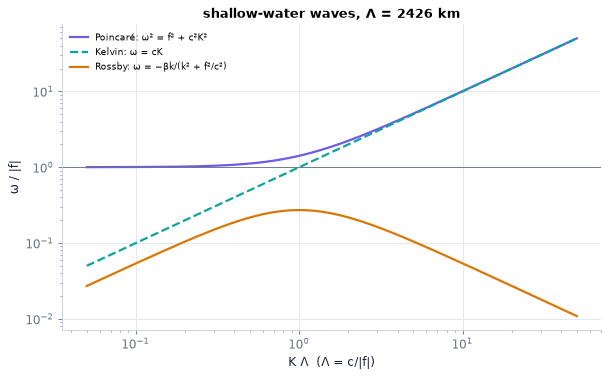

In [110]:
figP = ch13.fig_poincare_kelvin_dispersion()                   # one log-log panel: Poincare curve, dashed Kelvin line, Rossby branch (35 N, external mode)
plt.show()   # display the figure

**What you see.** Three curves on logarithmic axes: the Poincaré curve (purple), which is flat at $\omega=\lvert f\rvert$ on the left and rises on the right; the straight dashed Kelvin line $\omega=cK$; and the Rossby branch (orange), a low arch that peaks at $K\Lambda=1$. The thin horizontal line is $\omega=\lvert f\rvert$.

**How to read it.** For long waves ($K\Lambda\ll1$) the Poincaré curve flattens onto $\omega=\lvert f\rvert$: no such wave is slower than $f$. For short waves ($K\Lambda\gg1$) it joins the Kelvin line, which is its asymptote $\omega=cK$ — rotation no longer matters. The Rossby branch lies below $\lvert f\rvert$ everywhere. On logarithmic axes a straight line of slope 1 means *non-dispersive* (frequency proportional to wavenumber): the Kelvin line everywhere, the Poincaré curve only on the right.

**What would change if…** …$f\to0$? Then $\Lambda\to\infty$: every wave is 'short' in these units and the Poincaré curve lies on the Kelvin line — Chapter 7's non-dispersive long waves.

📝 **Note.** **N88 [B]** **The real fields** for a wave along $x$ ($l=0$), with $\eta=\hat\eta\cos(kx-\omega t)$:
$u=\dfrac{\omega\hat\eta}{kH}\cos(kx-\omega t)$ and $v=\dfrac{f\hat\eta}{kH}\sin(kx-\omega t)$ (13.83) — stated (they are the real parts
of the amplitudes of `D14`, using $\omega^2-f^2=gHk^2$).

In [111]:
eta_f, u_f, v_f = GFD.poincare_fields(np.array([0.0, 7.75e5]), 0.0, 0.0, k31, 0.0, 0.5, H_o, f35)   # fields at x = 0 and a quarter wavelength on, at t = 0
print(f"at the crest:        eta = {eta_f[0]:+.3f} m, u = {u_f[0]:+.4f} m/s, v = {v_f[0]:+.4f} m/s")   # u in phase with eta
print(f"a quarter wave on:   eta = {eta_f[1]:+.3f} m, u = {u_f[1]:+.4f} m/s, v = {v_f[1]:+.4f} m/s")   # v a quarter period out of phase

at the crest:        eta = +0.500 m, u = +0.0247 m/s, v = +0.0000 m/s
a quarter wave on:   eta = +0.000 m, u = +0.0000 m/s, v = +0.0049 m/s


**What does this show?** Under the crest the water moves with the wave ($u$ in phase with $\eta$); a quarter wavelength away
$u$ and $\eta$ vanish and the cross-wave current $v$ is at its largest — the quarter-period shift that the factor $i$ meant.

> 📎 **Primer — sense of rotation of (a cos ωt, b sin ωt) from the sign of the swept area.** `P322` · The point $(a\cos\omega t,\ b\sin\omega t)$ runs round an ellipse. Which way? Its "angular momentum" $x\,dy/dt-y\,dx/dt=ab\omega$ is
positive for counter-clockwise motion. So $(a\cos\omega t, b\sin\omega t)$ with $a,b,\omega>0$ is counter-clockwise — and
$(a\cos(-\omega t), b\sin(-\omega t))$, which is what a wave gives at a fixed place, is clockwise.

In [112]:
t = np.linspace(0, 1, 5); a, b, w = 2.0, 1.0, -2*np.pi          # the wave's phase at a fixed place is -wt
x, y = a*np.cos(w*t), b*np.sin(w*t)                             # the point at five times
print("sign of the swept area:", np.sign((x[:-1]*np.diff(y) - y[:-1]*np.diff(x)).sum()))   # -1.0: clockwise

sign of the swept area: -1.0


📝 **Note.** **N89 [B]** **The velocity ellipse** (our version of the book's figure): the tip of the current vector at a fixed place, with axes
$2\omega\hat\eta/(kH)$ and $2f\hat\eta/(kH)$.

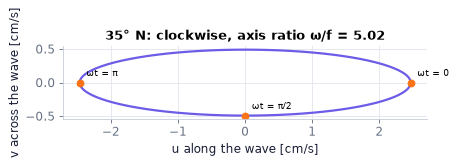

In [113]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))   # a new figure and its panel(s); figsize in inches
ax.plot(orb["u"]*100, orb["v"]*100, color=COLORS["accent"])    # the velocity hodograph over one period [cm/s]
for ph, lab in ((0.0, "ωt = 0"), (np.pi/2, "ωt = π/2"), (np.pi, "ωt = π")):   # three marked phases
    j_ = np.argmin(abs(w_p*t_orb - ph))                        # the time index of this phase
    ax.plot(orb["u"][j_]*100, orb["v"][j_]*100, "o", color=COLORS["orange"])   # the mark
    ax.annotate(lab, (orb["u"][j_]*100, orb["v"][j_]*100), textcoords="offset points", xytext=(6, 6), fontsize=8)   # its label
ax.set(xlabel="u along the wave [cm/s]", ylabel="v across the wave [cm/s]", aspect="equal", title=f"35° N: {orb['sense']}, axis ratio ω/f = {orb['axis_ratio']:.2f}")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure

**What you see.** The tip of the current vector over one wave period, with the phases $\omega t=0$, $\pi/2$, $\pi$ marked.

**How to read it.** From $\omega t=0$ to $\pi/2$ the vector moves from the positive $u$ axis toward negative $v$: clockwise in the northern hemisphere ($f>0$; mirror for $f<0$). The long axis lies along the direction of propagation.

**What would change if…** …the wave were longer? Then $\omega\to f$ and the ellipse fattens into a circle (animation below).

> ⚠️ **Common confusion (trap T7):** The book's "orbit" figure is a velocity hodograph. The particle's path has the same shape and sense, with both axes divided by
$\omega$. And §13.11 quotes the axis ratio as $\omega/f$ (long over short), §13.14 as $f/\omega$ (short over long) — the same
ellipse.

In [114]:
nfr = 30 if FAST else 40                                       # number of frames
lams = np.geomspace(3.0e5, 3.0e7, nfr)                         # wavelengths from 300 km to 30 000 km [m]
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.9))   # a new figure and its panel(s); figsize in inches
lines, dots = [], []                                           # the drawn objects of the two panels
for ax, ttl in zip(axes, ("35° N (f > 0)", "35° S (f < 0)")):  # one panel per hemisphere
    (ln,) = ax.plot([], [], color=COLORS["accent"])            # the particle path
    (dt_,) = ax.plot([], [], "o", color=COLORS["orange"])      # the particle now
    ax.set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), aspect="equal", xlabel="x / (long semi-axis)", ylabel="y / (long semi-axis)")   # axis labels (with units), title and fixed ranges of this panel
    ax.set_title(ttl, fontsize=9)   # label / range / scale of this axis
    lines.append(ln); dots.append(dt_)

fig.canvas.draw(); fig.set_layout_engine("none")              # lay the figure out once, then freeze it: frames render much faster

def update(i):                                                 # frame i: the path for wavelength lams[i]
    k_ = 2*np.pi/lams[i]                                       # wavenumber [rad/m]
    for ax, ln, dt_, f_, hemi in zip(axes, lines, dots, (f35, -f35), ("35° N", "35° S")):   # both hemispheres
        w_ = GFD.poincare_omega(K=k_, f=f_, c=c_ext)                # Eq. (13.82)
        tt = np.linspace(0.0, 2*np.pi/w_, 121)                 # one period
        o_ = GFD.poincare_orbit(tt, k_, 0.5, H_o, f_)          # particle displacement about its mean position
        scale = abs(o_["x"]).max()                             # the long semi-axis, used to normalise the picture
        ln.set_data(o_["x"]/scale, o_["y"]/scale)              # the ellipse
        j_ = (3*i) % 121                                       # the particle advances a little each frame
        dt_.set_data([o_["x"][j_]/scale], [o_["y"][j_]/scale]) # its position now
        ax.set_title(f"{hemi}: λ = {lams[i]/1e3:.0f} km, ω/f = {w_/abs(f_):.2f}, {o_['sense']}", fontsize=8)   # the numbers of this frame
    return lines + dots   # hand the result back to the caller

show_animation(animate(update, frames=nfr, fig=fig, interval=120), player="video", dpi=50)   # a smooth video
plt.close(fig)                                                 # do not show the last frame a second time
plt.show()   # display the figure

**What does the code above do?**

1. The wavelength grows from 300 km to 30 000 km over the frames; for each, `GFD.poincare_orbit` gives the path of a water
   parcel, drawn normalised by its long semi-axis so that only the *shape* changes.
2. The left panel is 35° N, the right panel 35° S; the orange dot moves along the path.

**What you see.** The path of one water parcel under a Poincaré wave as the wavelength grows, in both hemispheres. The title gives the wavelength, the frequency ratio $\omega/f$ and the sense of rotation.

**How to read it.** For short waves $\omega/f$ is large and the path is a thin ellipse — almost the back-and-forth sloshing of a non-rotating wave. As the wave lengthens, $\omega/f$ falls toward 1 and the ellipse fattens into the inertial circle. The dot goes clockwise in the north, counter-clockwise in the south.

**What would change if…** …the layer were the first baroclinic mode ($c=3.6$ m/s)? The same sequence would happen at wavelengths 56 times shorter.

📝 **Note.** **N90 [B]** **Inertial motion, the $K\to0$ limit:** $\partial u/\partial t-fv=0$, $\partial v/\partial t+fu=0$, solved by $u=q\cos ft$,
$v=-q\sin ft$: a circle of radius $r=q/f$ traced in one inertial period. Seen from space this is Chapter 4's particle moving in
a straight line while the earth turns under it.

In [115]:
q_in = inp["q_inertial"]                                       # speed of the inertial current: 0.23 m/s (our input)
t_in = np.linspace(0.0, GFD.inertial_period(f35), 5)           # five times through one inertial period [s]
u_in, v_in, x_in, y_in = GFD.inertial_oscillation(t_in, q_in, 0.0, f35)   # velocity and position on the inertial circle
print(f"radius = q/f = {GFD.inertial_radius(q_in, f35)/1e3:.2f} km; period = {GFD.inertial_period(f35)/3600:.2f} h at 35 N")   # size and time of the circle
print("speed stays", np.round(np.hypot(u_in, v_in), 3), "m/s; back at the start after one period:", bool(np.hypot(x_in[-1] - x_in[0], y_in[-1] - y_in[0]) < 1.0))   # a closed circle

radius = q/f = 2.75 km; period = 20.86 h at 35 N
speed stays [0.23 0.23 0.23 0.23 0.23] m/s; back at the start after one period: True


**What does this show?** A current of 0.23 m/s left to itself at 35° N goes round a circle of radius about 2.8 km once every
21 hours, at constant speed.

#### 🎮 Interactive: Are Poincaré, Kelvin and Rossby waves separate theories?

**Why interactive rather than a static figure:** moving a wavenumber cursor along the diagram while the four term bars of the cubic rebalance shows which terms each wave is made of; sliding $f$ to zero or $\beta$ to zero removes a whole branch.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Select the slow root and read the status: which term is negligible?
- Use the preset 'f → 0': the hyperbola collapses onto ω = cK.
- Switch β off: the slow root drops to ω = 0.
- Toggle 'printed vs corrected' to see slip #7 in the regime text.

In [116]:
show_viz("ch13", "shallow_water_dispersion")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/shallow_water_dispersion]

**What would change if…** …a coast stands in the way, so that the water cannot move across it? A wave with no cross-shore velocity at all becomes
possible — and it can have any frequency, even below $f$ (`C11`).

---

## 13.12 Kelvin Wave

**What is this section about?** The wave that leans on a coast: it travels at the ordinary long-wave speed, only in one
direction, and dies away offshore over a distance that turns out to be the most important length scale of rotating fluids.

### 🧩 The Kelvin wave: $\eta=\eta_0e^{-fy/c}\cos k(x-ct)$, $u=\eta_0\sqrt{g/H}\,e^{-fy/c}\cos k(x-ct)$ (13.87) `C11`

*The question:* How can a wave exist below the frequency f, and why does it run only one way along a coast?

#### The problem in plain words

The tide in the North Sea does not slosh in and out; it travels round the basin, counter-clockwise, as a wave whose range is
largest at the shore. In the Pacific, a relaxation of the trade winds sends a signal along the equator and then up and down
the coast of the Americas. Both are Kelvin waves: gravity waves that use a boundary to dodge the Coriolis force.

📝 **Note.** **N91 [B]** **The idea.** At a wall the water cannot move across the shore, so $v=0$ there — try $v=0$ everywhere. Then the Coriolis force
on the along-shore current has nothing to turn; it must be *held* by a pressure force: the surface tilts across the shore,
$fu=-g\dfrac{\partial\eta}{\partial y}$. Under a crest the current flows with the wave, so the surface must be high at the wall
and fall offshore — and that fixes the direction of travel: coast on the right (northern hemisphere, $f>0$; on the left for
$f<0$).

```
   cross-shore section through a crest, looking ALONG the direction of travel, f > 0 (coast on the RIGHT)

                              .~~~~~~|▓ coast     the surface is highest at the wall
   ______.....~~~~~~~                |▓           and falls offshore (to the left) over the distance c/f
        ⊗ current under the crest    |▓           (into the page: with the wave)
        Coriolis force →             |▓           pushes the water toward the coast (to the right of the current);
        ← pressure force of the slope             the surface slope pushes it back

   for f < 0 mirror the picture: coast on the LEFT, Coriolis force to the left of the current
```

📝 **Note.** **N94 [B]** **The equations with $v\equiv0$:** $\dfrac{\partial\eta}{\partial t}+H\dfrac{\partial u}{\partial x}=0$, $\dfrac{\partial u}{\partial t}=-g\dfrac{\partial\eta}{\partial x}$,
$fu=-g\dfrac{\partial\eta}{\partial y}$ (13.84).

📝 **Note.** **N93 [C]** **Compare the two waves** through the cross-shore equation $\dfrac{\partial v}{\partial t}+fu=-g\dfrac{\partial\eta}{\partial y}$:
for a Poincaré wave the Coriolis term is partly balanced by the acceleration $\partial v/\partial t$; for a Kelvin wave $v=0$ and
it is balanced entirely by the slope — geostrophically.

> 📎 **Primer — trapped solutions: keeping the exponential that decays away from a boundary.** `P323` · A first- or second-order equation in the offshore coordinate often has two exponential solutions, one growing and one decaying
away from the wall. In a half-space only the decaying one is physical (finite energy). Which one decays depends on signs in
the problem — here on the sign of $f$ and on the direction of travel.

In [117]:
y = np.array([0.0, 1.0, 2.0])                  # distance from the wall in units of c/|f|
for s in (+1, -1):                             # s = sign(f) * direction of travel
    print("s =", s, "-> profile offshore:", np.round(np.exp(-s*y), 3))   # +1 decays offshore (kept), -1 grows (rejected)

s = 1 -> profile offshore: [1.    0.368 0.135]
s = -1 -> profile offshore: [1.    2.718 7.389]


> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **first-order linear ODE** — $d\hat\eta/dy=a\,\hat\eta$ has the solution $\hat\eta=\hat\eta(0)\,e^{ay}$. *(Ch. 9, P210)*
- **cached model runs; `ch13.load_reference_run`** — an expensive run is made once, saved as a compressed `.npz` file with its parameters, and loaded where it is shown. *(Ch. 10, P252)*

#### 🧮 Derivation — The Kelvin wave: the trapping width `D15` ★★ (Eq. 13.87: $\eta=\eta_0e^{-fy/c}\cos k(x-ct),\ \ u=\eta_0\sqrt{\frac{g}{H}}\,e^{-fy/c}\cos k(x-ct)$)

**What we want to show.** Find the wave that can run along a straight coast with no flow across the shore, its speed, and how it decays offshore.

**Assumptions.** f-plane; straight vertical wall; v ≡ 0 (step 1, justified at the end).

**The plan.**

1. Set v = 0 everywhere.
2. Look for a wave along the coast with an unknown offshore shape.
3. Get the speed from two equations and the shape from the third.
4. Keep the shape that decays.

**Tools we use** (each explained before this point): plane wave with an unknown structure function · first-order linear ODE (P210, reminder) · trapped solutions (P323)

**We start from**

$$ \begin{array}{l}\dfrac{\partial\eta}{\partial t}+H\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)=0\ \text{,}\ \dfrac{\partial u}{\partial t}-fv=-g\dfrac{\partial\eta}{\partial x}\ \text{,} \\ \dfrac{\partial v}{\partial t}+fu=-g\dfrac{\partial\eta}{\partial y}\ \text{(13.45), a wall along y = 0 with the sea in y > 0}\end{array} $$

*In words:* Shallow water next to a coast

---

**Step 1 of 8 — Set v = 0 everywhere.**

$$ \dfrac{\partial\eta}{\partial t}+H\dfrac{\partial u}{\partial x}=0,\qquad\dfrac{\partial u}{\partial t}=-g\dfrac{\partial\eta}{\partial x},\qquad fu=-g\dfrac{\partial\eta}{\partial y}\ \text{(13.84)} $$

- *Why we can do this:* The wall forces v = 0 at y = 0; we try the simplest possibility, v = 0 for all y, and must check at the end that all three equations can still be met.
- *In words:* Along the shore a plain gravity wave; across it, geostrophic balance.

---

**Step 2 of 8 — Try a wave along the coast.**

$$ [u,\eta]=[\hat u(y),\hat\eta(y)]\,e^{i(kx-\omega t)} $$

- *Why we can do this:* The coefficients do not depend on x or t, so exponentials in x and t work; the dependence on y is left open.
- *In words:* A travelling wave whose strength may vary offshore.

---

**Step 3 of 8 — Substitute.**

$$ -i\omega\hat\eta+iHk\hat u=0,\qquad-i\omega\hat u=-igk\hat\eta,\qquad f\hat u=-g\dfrac{d\hat\eta}{dy}\ \text{(13.85)} $$

- *Why we can do this:* ∂/∂t → −iω, ∂/∂x → ik; the y-derivative stays.
- *In words:* Two algebraic relations and one differential equation.

---

**Step 4 of 8 — Eliminate û between the first two.**

$$ \hat\eta\,\big[\omega^2-gHk^2\big]=0\ \Rightarrow\ \omega=\pm ck,\qquad c=\sqrt{gH}\ \text{(13.86)} $$

- *Why we can do this:* The second gives $\hat u=(gk/\omega)\hat\eta$; insert into the first and multiply by ω. For a wave to exist the bracket must vanish.
- *In words:* The wave moves at the ordinary long-wave speed — rotation does not appear.

---

**Step 5 of 8 — Use the cross-shore equation.**

$$ \dfrac{d\hat\eta}{dy}=-\dfrac{fk}{\omega}\hat\eta=\mp\dfrac fc\hat\eta $$

- *Why we can do this:* Insert $\hat u=(gk/\omega)\hat\eta$ into $f\hat u=-g\,d\hat\eta/dy$; the upper sign goes with ω = +ck (travel toward +x).
- *In words:* The offshore shape obeys the simplest possible ODE.

---

**Step 6 of 8 — Solve and keep the decaying solution.**

$$ \hat\eta=\eta_0\,e^{\mp fy/c};\qquad f>0\ \Rightarrow\ \text{upper sign} $$

- *Why we can do this:* A first-order linear ODE has an exponential solution; in the half-plane y > 0 only the decaying one has finite energy. For f > 0 that is the wave travelling toward +x.
- *In words:* The wave must travel with the coast on its right (f > 0).

---

**Step 7 of 8 — Take real parts.**

$$ \eta=\eta_0e^{-fy/c}\cos k(x-ct),\qquad u=\eta_0\sqrt{\dfrac gH}\,e^{-fy/c}\cos k(x-ct)\ \text{(13.87)} $$

- *Why we can do this:* Real part of the complex wave; and $\hat u=(gk/\omega)\hat\eta=(g/c)\hat\eta=\sqrt{g/H}\,\hat\eta$.
- *In words:* Under a crest the current flows in the direction of travel; both fade offshore.

---

**Step 8 of 8 — Read off the width and the general rule.**

$$ \Lambda\equiv\dfrac{c}{\lvert f\rvert};\qquad\text{trapped}\iff\mathrm{sgn}(f)\times(\text{direction of travel})>0 $$

- *Why we can do this:* The exponent is −y/Λ; for f < 0, or a coast on the other side, the decaying root of step 6 is the other one, and the direction reverses.
- *In words:* The wave hugs the coast within one Rossby radius, keeping it on the right in the northern hemisphere and on the left in the southern.

---

**Result**

$$ \eta=\eta_0e^{-fy/c}\cos k(x-ct)\ \text{,}\ u=\eta_0\sqrt{g/H}\,e^{-fy/c}\cos k(x-ct)\ \text{,}\ c=\sqrt{gH} $$

*In words:* a non-dispersive wave trapped within Λ = c/f of the coast

**What it means.** The only shallow-water wave that exists below the frequency f; it carries tides round basins and thermocline signals along coasts and (in an equatorial version beyond the book) along the equator. **Fails when:** the coast curves on a scale shorter than Λ, or the wavelength is so long that β matters.

**Check it.** Units — η₀√(g/H) = m · s⁻¹ ✓. Consistency of v ≡ 0 — the y-equation becomes exact geostrophy, satisfied by step 5; no contradiction. Limits — f → 0: Λ → ∞, a plane wave along the wall. Number — H = 4200 m, 35° N: c = 203 m/s, Λ = 2426 km; internal two-layer mode: c = 1.88 m/s, Λ = 22.5 km.

> ⚠️ **Common confusion (traps in `D15`):** Which sign of the exponent goes with which direction; for f < 0 everything mirrors (trap T5); v ≡ 0 is an assumption that must be checked against the cross-shore equation, where it leaves exact geostrophy.

📝 **Note.** **N95 [B]** **Steps 2–4 of `D15`:** with $[u,\eta]=[\hat u(y),\hat\eta(y)]e^{i(kx-\omega t)}$, the three equations become
$-i\omega\hat\eta+iHk\hat u=0$, $-i\omega\hat u=-igk\hat\eta$, $f\hat u=-g\dfrac{d\hat\eta}{dy}$ (13.85), hence
$\hat\eta\,[\omega^2-gHk^2]=0$.

> 🔁 **Recap — The Kelvin wave is not dispersive `R23`** (Ch. 7, long-wave speed). Its speed is $c=\sqrt{gH}$ (13.86), i.e. $\omega=\pm k\sqrt{gH}$: the non-rotating long-wave speed, for every frequency — including below
$f$, where no Poincaré wave exists.

#### ✏️ Tiny example: a Kelvin wave on a deep ocean

Our inputs, rounded: $H=4200$ m, $g\approx9.8$ m/s², $f=8.4\times10^{-5}$ s⁻¹ (35° N), crest height $\eta_0=1$ m at the coast.

1. Speed: $c=\sqrt{gH}=\sqrt{41\,160}\approx203$ m/s.
2. Trapping width $\Lambda=c/f=203/8.4\times10^{-5}=2.42\times10^{6}$ m ≈ 2400 km.
3. Current under the crest at the coast: $u=\eta_0\sqrt{g/H}=1\times\sqrt{9.8/4200}=0.048$ m/s.
4. At $y=\Lambda$ offshore both are $e^{-1}$ = 37 % of that.
5. Check the cross-shore balance at the coast: $fu=8.4\times10^{-5}\times0.048=4.1\times10^{-6}$ m/s²;
   $-g\,\partial\eta/\partial y=g\eta_0/\Lambda=9.8/2.42\times10^{6}=4.1\times10^{-6}$ m/s² ✓.

In [118]:
eta_k, u_k = GFD.kelvin_wave(0.0, 0.0, 0.0, 0.5, k31, H_o, f35)   # Eq. (13.87) at the coast under the crest: 0.5 m wave, 3100 km long, 35 N
Lam_ext = GFD.rossby_radius(c_ext, f35)                        # the trapping width c/|f| [m]
print(f"trapping width c/f = {Lam_ext/1e3:.0f} km; current under the crest at the coast u = {u_k:.4f} m/s; period = {2*np.pi/GFD.kelvin_omega(k31, c_ext)/3600:.2f} h")   # scales of the wave
print("35 N, wave toward +x (fluid in y > 0):", GFD.kelvin_decay_side(f35, +1))    # trapped, coast on the right
print("35 S, wave toward +x (fluid in y > 0):", GFD.kelvin_decay_side(-f35, +1))   # not trapped: it would have to run the other way
try:                                                           # ask for the wave that runs the wrong way at 35 N
    GFD.kelvin_wave(0.0, 0.0, 0.0, 0.5, k31, H_o, f35, direction=-1)
except ValueError as err:                                      # the function refuses: that solution grows offshore
    print("wrong direction ->", err)

trapping width c/f = 2426 km; current under the crest at the coast u = 0.0242 m/s; period = 4.24 h
35 N, wave toward +x (fluid in y > 0): {'trapped': True, 'coast_on': 'right'}
35 S, wave toward +x (fluid in y > 0): {'trapped': False, 'coast_on': 'left'}
wrong direction -> kelvin_wave: a wave travelling this way would grow away from the coast (direction*sign(f) < 0) — in this hemisphere the trapped wave travels the other way


**What does the code above do?**

1. `GFD.kelvin_wave(x, y, t, eta0, k, H, f)` returns the surface height and the along-shore current, with the fluid in $y\ge0$
   and the coast at $y=0$; by default it travels in the trapped direction.
2. For the external mode at 35° N the trapping width is about 2400 km and a 0.5 m wave carries a current of 2.4 cm/s.
3. `GFD.kelvin_decay_side(f, direction)` says whether a wave in that direction is trapped and on which side the coast must be.
4. `try: … except ValueError:` runs a call that may fail and catches the failure: asking for the wave that runs with the coast
   on its left at 35° N raises an error, because that solution grows offshore without bound.

In [119]:
# From scratch: put the formula into the three equations (13.84) by finite differences
x0, y0, t0, hx, ht = 2.0e5, 5.0e5, 3.0e3, 10.0, 1.0            # a point offshore, a time, and small steps [m, m, s, m, s]
Kw = lambda xx, yy, tt: GFD.kelvin_wave(xx, yy, tt, 0.5, k31, H_o, f35)   # (eta, u) at any point and time
deta_dt = (Kw(x0, y0, t0 + ht)[0] - Kw(x0, y0, t0 - ht)[0])/(2*ht)       # d(eta)/dt by a centred difference
deta_dx = (Kw(x0 + hx, y0, t0)[0] - Kw(x0 - hx, y0, t0)[0])/(2*hx)       # d(eta)/dx
deta_dy = (Kw(x0, y0 + hx, t0)[0] - Kw(x0, y0 - hx, t0)[0])/(2*hx)       # d(eta)/dy
du_dt = (Kw(x0, y0, t0 + ht)[1] - Kw(x0, y0, t0 - ht)[1])/(2*ht)         # du/dt
du_dx = (Kw(x0 + hx, y0, t0)[1] - Kw(x0 - hx, y0, t0)[1])/(2*hx)         # du/dx
u0 = Kw(x0, y0, t0)[1]                                                    # u itself
res = [abs(deta_dt + H_o*du_dx)/abs(deta_dt), abs(du_dt + G0*deta_dx)/abs(du_dt), abs(f35*u0 + G0*deta_dy)/abs(f35*u0)]   # each divided by its largest term
assert max(res) < 1e-5                                         # all three equations are satisfied
lib = GFD.kelvin_residuals(x0, y0, t0, 0.5, k31, H_o, f35)     # the library's own check
print(f"✓ residuals by hand: {[f'{r_:.0e}' for r_ in res]}; library: {[f'{abs(v_):.0e}' for v_ in lib.values()]} (continuity, x-momentum, cross-shore geostrophy)")   # visible confirmation

✓ residuals by hand: ['3e-08', '3e-08', '3e-12']; library: ['2e-08', '2e-08', '6e-11'] (continuity, x-momentum, cross-shore geostrophy)


**What does the code above do?**

Differentiating the closed form numerically and putting the result into the three equations with $v\equiv0$ leaves relative
residuals at the level of the finite-difference error; `GFD.kelvin_residuals` does the same check inside the library.

📝 **Note.** **N92 [B]** **Cross-shore sections and a plan view** (our version of the book's figures, `ch13.fig_kelvin_sections`): the surface across the
shore through a crest and through a trough, and a map of one coast with the surface height in colour and the current as
arrows.

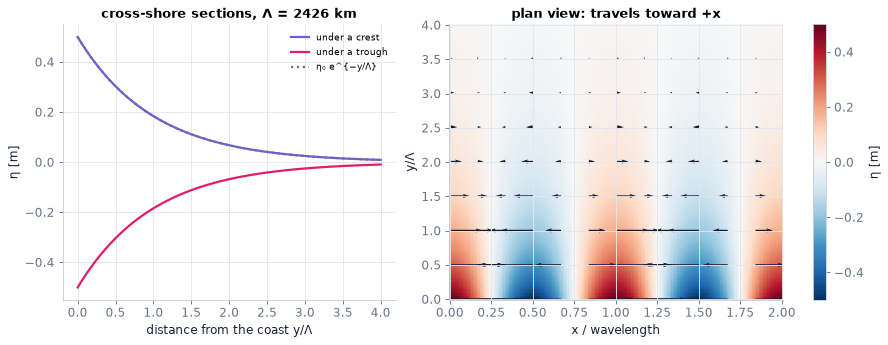

In [120]:
figK = ch13.fig_kelvin_sections()                              # cross-shore sections of eta under a crest and a trough, and a plan view of one coast (our inputs, 35 N)
plt.show()   # display the figure

**What you see.** One panel: the sea surface across the shore under a crest and under a trough — highest (or lowest) at the wall, relaxing exponentially offshore. Other panel: a map of the coast, colours for the surface height and arrows for the current, both fading within the distance $\Lambda=c/f$ of the wall.

**How to read it.** The slope across the shore reverses between crest and trough — and so does the along-shore current, so the Coriolis force is always held by the slope. In the map the current runs with the wave under crests and against it under troughs; the wave travels with the coast on its right (northern hemisphere, $f>0$; mirror for $f<0$).

**What would change if…** …there were a second coast less than a few $\Lambda$ away (a channel)? That wall would carry its own Kelvin wave, travelling the opposite way; in a channel much narrower than $c/f$ the two overlap and rotation hardly matters.

In [121]:
xs_k = np.linspace(0.0, 6.2e6, 60); ys_k = np.linspace(0.0, 3*Lam_ext, 40)   # two wavelengths alongshore, three trapping widths offshore [m]
Xk, Yk = np.meshgrid(xs_k, ys_k)                               # grids indexed [j, i] = (y, x)
figKs = go.Figure()
for j, (f_, nm) in enumerate(((f35, "35° N"), (-f35, "35° S"))):   # the trapped wave of each hemisphere
    eta_s, _ = GFD.kelvin_wave(Xk, Yk, 0.0, 0.5, k31, H_o, f_) # Eq. (13.87); the default direction is the trapped one
    figKs.add_trace(go.Surface(x=xs_k/1e3, y=ys_k/1e3, z=eta_s, colorscale="RdBu_r", cmin=-0.5, cmax=0.5, visible=(j == 0),
                               colorbar=dict(title="η [m]"), name=nm))   # the sea surface
figKs.update_layout(height=520, title="The Kelvin wave hugs the coast (the wall is the edge y = 0)",
                    updatemenus=[dict(x=0.0, y=1.08, xanchor="left", buttons=[
                        dict(label="35° N: travels toward +x (coast on its right)", method="update", args=[{"visible": [True, False]}]),
                        dict(label="35° S: travels toward −x (coast on its left)", method="update", args=[{"visible": [False, True]}])])],
                    scene=dict(xaxis_title="x alongshore [km]", yaxis_title="y offshore [km]", zaxis_title="η [m]",
                               aspectratio=dict(x=1.6, y=1.0, z=0.4)), margin=dict(l=0, r=0, t=60, b=0))   # axes and the hemisphere dropdown
figKs.show()   # display the interactive figure (the slider works on the web page too)

**What does the code above do?**

The surface $\eta(x,y)$ of the trapped wave at one instant, for either hemisphere. In both the fluid is on the side $y>0$ of
the wall; what changes is the direction of travel.

**What you see.** A wave whose crests and troughs are tallest along the edge $y=0$ (the coast) and fade offshore.

**How to read it.** The shape is the same in both hemispheres; the direction of travel is not. With the fluid on the same side of the wall, the northern wave runs toward $+x$ (coast on its right) and the southern one toward $-x$ (coast on its left).

**What would change if…** …the wave were on the first baroclinic mode? The offshore scale would shrink from 2400 km to 43 km.

> 🔧 **Our choice** — the animation below is **our numerical model, cached**: a linear C-grid run (`SW.ShallowWater`, 64 × 64, closed basin) whose
equivalent depth was chosen so that the trapping width is a fifth of the basin. It is loaded with
`ch13.load_reference_run("kelvin_basin")`; if the file were missing, the straight-coast closed form would be animated instead.

In [122]:
kb = ch13.load_reference_run("kelvin_basin")                   # our cached run: eta(t, y, x) in a closed square basin, or None
fig, ax = plt.subplots(figsize=(4.8, 4.5))   # a new figure and its panel(s); figsize in inches
if kb is not None:                                             # the cached model output
    eta_fr = np.asarray(kb["eta"], dtype=float)                # 24 frames of the surface height [m]
    ext = [kb["x"][0]/1e3, kb["x"][-1]/1e3, kb["y"][0]/1e3, kb["y"][-1]/1e3]   # basin extent [km]
    src = f"cached C-grid run, Λ = {float(kb['Lambda'])/1e3:.0f} km"            # caption
    t_fr = np.asarray(kb["t"], dtype=float)                    # times of the frames [s]
else:                                                          # fallback: the closed form along a straight coast
    t_fr = np.linspace(0.0, 2*np.pi/GFD.kelvin_omega(k31, c_ext), 24)           # one period
    eta_fr = np.array([GFD.kelvin_wave(Xk, Yk, t_, 0.5, k31, H_o, f35)[0] for t_ in t_fr])   # 24 frames
    ext = [0, xs_k[-1]/1e3, 0, ys_k[-1]/1e3]                   # extent [km]
    src = "closed form, straight coast (cache absent)"         # caption
vmax = abs(eta_fr).max()                                       # symmetric colour limits
im = ax.imshow(eta_fr[0], origin="lower", extent=ext, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")   # the first frame
fig.colorbar(im, label="surface height η [m]")   # the colour scale and what it measures
ax.set(xlabel="x [km]", ylabel="y [km]")   # axis labels (with units), title and fixed ranges of this panel

fig.canvas.draw(); fig.set_layout_engine("none")              # lay the figure out once, then freeze it: frames render much faster

def update(i):                                                 # frame i: the surface at time t_fr[i]
    im.set_data(eta_fr[i])                                     # new field
    ax.set_title(f"{src}\nt = {t_fr[i]/86400:.2f} days", fontsize=9)   # the time of this frame
    return (im,)   # hand the result back to the caller

show_animation(animate(update, frames=len(eta_fr), fig=fig, interval=250), player="video", dpi=50)   # a smooth video
plt.close(fig)                                                 # do not show the last frame a second time
plt.show()   # display the figure

**What does the code above do?**

1. `ch13.load_reference_run("kelvin_basin")` returns the saved arrays of our model run (or `None` if the file is absent, in
   which case the closed form along a straight coast is used and the caption says so).
2. `imshow` draws the first frame; `update(i)` swaps in frame `i`.

**What you see.** A bulge of the sea surface travelling round a closed square basin, pressed against the wall.

**How to read it.** The bulge goes round counter-clockwise ($f>0$) and turns the corners: at every wall the coast is on the right of the direction of travel. Away from the walls the surface hardly moves.

**What would change if…** …$f<0$? The bulge would go round clockwise, with the coast on its left.

📝 **Note.** **N96 [B]** **Upwelling sends a Kelvin wave** (joining `C05` and `C11`). An equatorward wind along an eastern ocean boundary drives Ekman
transport offshore; deeper water rises; the lifted thermocline is a disturbance that leaves **poleward** along the coast as an
internal Kelvin wave (coast on its right in the northern hemisphere). Its speed and width, with our two-layer inputs, are
computed in `C12`.

In [123]:
cu2 = ch13.coastal_upwelling(-0.07, "east", lat)               # equatorward wind stress of 0.07 N/m^2 along an eastern boundary at 35 N
print(f"offshore Ekman transport {cu2['transport_offshore']:.3f} m^2/s -> upwelling: {cu2['upwelling']}; the thermocline signal leaves {cu2['kelvin_direction']} as an internal Kelvin wave")   # the chain of events

offshore Ekman transport 0.815 m^2/s -> upwelling: True; the thermocline signal leaves poleward as an internal Kelvin wave


**What does this show?** One function strings the two blocks together: the wind moves the surface water offshore, the coast
upwells, and the disturbance propagates poleward.

#### 🎮 Interactive: Why does this wave run only one way along a coast?

**Why interactive rather than a static figure:** reversing the direction of travel (or the hemisphere) makes the offshore profile grow instead of decay and the status badge reject it; widening the channel separates the two coastal waves; switching to the internal mode shrinks the trapping width from thousands of kilometres to tens.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Reverse the direction: the status says 'would grow offshore — not a solution'.
- Switch to S and see which way the trapped wave now runs.
- Choose the channel 2Λ wide and watch the two walls carry opposite waves (a case the static figure above does not show).
- Switch to the internal mode and read the new Λ.

In [124]:
show_viz("ch13", "kelvin_wave")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/kelvin_wave]

**What would change if…** …there is no coast? The width $c/f$ still means something: it is how far a gravity wave gets before rotation takes over
(`C12`).

### 🧩 The Rossby radius of deformation $\Lambda\equiv c/f$ `C12`

*The question:* If I pile water up and let go, why doesn't it flatten out as it would without rotation — and how wide is what stays?

#### The problem in plain words

Pour a bucket of water into a bath and the bump spreads until the surface is flat. Do the same on a planet-sized turntable and
it does not: the water starts to spread, the Coriolis force turns the outflow into a current running *along* the edge of the
bump, and that current's own Coriolis force holds the rest of the bump up. The ocean is full of such fronts and eddies standing
in slopes that gravity cannot flatten. Their width is the Rossby radius — tens of kilometres in the ocean, about a thousand in
the atmosphere — and it is why an ocean model needs a grid of a few kilometres to "resolve eddies".

#### The idea

In a time $1/f$ a gravity wave travels a distance $c/f$. Disturbances narrower than that spread before rotation notices them;
wider ones are caught by rotation before gravity can flatten them.

| Size of the disturbance | What happens |
|---|---|
| much smaller than $\Lambda$ | behaves as if there were no rotation: it radiates away as gravity waves |
| much larger than $\Lambda$ | stays, in geostrophic balance |

> 🔁 **Recap — Internal Kelvin waves and the internal radius `R24`** (Ch. 7, $g'=g(\rho_2-\rho_1)/\rho_2$ (7.117)). On the interface between a thin upper layer and a deep lower one the long-wave speed is $c=\sqrt{g'H}$ with the reduced
gravity $g'=g(\rho_2-\rho_1)/\rho_2$; in a continuously stratified layer the speeds are $c=NH/n\pi$ (`C08`). The corresponding
radius $\Lambda=NH/(\pi f)$ for $n=1$ is far smaller than the external one; the interface moves far more than the surface, in
the opposite sense.

> ⚠️ **Common confusion (trap T11):** Three Rossby radii share one name: external $\sqrt{gH}/f$; internal $\sqrt{g'H}/f$ or $NH/(n\pi f)$; and in `C16` the Eady
radius $NH/f$ **without** the $\pi$.

> ⚠️ **slip table, row #11 (a loose order-of-magnitude statement, not an error) — the book quotes** a typical internal radius about three times what its own typical $N$, $H$ and $f$ give **; what the formula gives is** $\Lambda=NH/(\pi f)$ evaluated with the inputs one states — the mismatch is between the quoted inputs and the quoted radius, not in the formula.

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **reduced gravity; internal Kelvin waves; internal Rossby radius; three radii** — across an interface between two layers gravity acts only through the density difference, $g'=g\,\Delta\rho/\rho$ — a hundred to a thousand times weaker than $g$. *(Ch. 4, P131)*
- **frames player for stop-and-look animations** — `show_animation(anim, player="frames")` gives ◀ ▮▮ ▶ and single-step buttons, for processes worth stopping at. *(Ch. 1, P16)*

#### ✏️ Tiny example: three radii by hand

Our 35° N value, rounded: $f=8.4\times10^{-5}$ s⁻¹.

1. **External**, $H=4200$ m: $c=\sqrt{9.8\times4200}\approx203$ m/s → $\Lambda\approx2400$ km.
2. **Two-layer**, upper layer 120 m, $\Delta\rho/\rho=0.003$: $g'=0.029$ m/s², $c=\sqrt{0.029\times120}\approx1.9$ m/s → $\Lambda\approx22$ km.
3. **Uniform** $N=2.7\times10^{-3}$ s⁻¹ over 4200 m: $c_1=NH/\pi=11.3/\pi\approx3.6$ m/s → $\Lambda\approx43$ km.
4. Ratio external / internal: 56 to 110 — one ocean, two utterly different scales.

In [125]:
rho2 = inp["rho_ocean"]; rho1 = rho2 - inp["drho"]             # lower-layer and upper-layer density [kg/m^3] (difference 3.1)
L_ext = GFD.rossby_radius(GFD.long_wave_speed(H_o), f35)                       # external: sqrt(gH)/f
L_int = GFD.rossby_radius_internal(N_o, H_o, f35)                              # internal, n = 1: N H/(pi f)
L_eady = GFD.rossby_radius_internal(N_o, H_o, f35, with_pi=False)              # N H/f, no pi (the Eady radius of this ocean)
L_two = GFD.rossby_radius_two_layer(inp["H1"], rho1, rho2, f35)                # two-layer: sqrt(g' H1)/f for a 120 m upper layer
c_two = L_two*f35                                                               # the internal long-wave speed sqrt(g' H1) [m/s]
print(f"35 N: external {L_ext/1e3:.0f} km | internal N H/(pi f) {L_int/1e3:.2f} km | without pi {L_eady/1e3:.1f} km | two-layer {L_two/1e3:.1f} km")   # four numbers, one name
print(f"two-layer: g' = {G0*inp['drho']/rho2:.4f} m/s^2, c = {c_two:.3f} m/s = {c_two*86.4:.0f} km per day")   # the internal Kelvin wave of note N96
print(f"12 N: internal N H/(pi f) = {GFD.rossby_radius_internal(N_o, H_o, f12)/1e3:.1f} km")                     # larger toward the equator

35 N: external 2426 km | internal N H/(pi f) 43.15 km | without pi 135.6 km | two-layer 22.5 km
two-layer: g' = 0.0296 m/s^2, c = 1.885 m/s = 163 km per day
12 N: internal N H/(pi f) = 119.0 km


**What does the code above do?**

1. `GFD.rossby_radius(c, f)` is $\Lambda=c/\lvert f\rvert$ for any wave speed.
2. `GFD.rossby_radius_internal` is $NH/(n\pi f)$; with `with_pi=False` it returns $NH/f$, the radius used in the Eady problem.
3. `GFD.rossby_radius_two_layer` uses the reduced gravity of a two-layer ocean.
4. External and internal radii differ by a factor of about 56 at the same latitude; and every radius grows toward the equator,
   where $f$ is small.

> 📎 **Primer — an adjustment problem: what a steady end state can remember (a conserved quantity pins it).** `P324` · Release an unbalanced state and wait. Waves carry away whatever can travel. What is left must be steady — but there are
infinitely many steady states. The one nature picks is singled out by a quantity that cannot change at any point while the
waves pass. Find that quantity, demand it has its initial value, and the end state follows without solving for the transient
at all.

In [126]:
# a bank analogy: transfers move money between branches (the waves); the total cannot change
start = np.array([10.0, 0.0, 0.0]); end = np.full(3, start.sum()/3)   # all in one branch; then spread evenly
print(end, end.sum() == start.sum())                                  # the end state is fixed by what is conserved

[3.3333 3.3333 3.3333] True


#### 🧮 Derivation — Geostrophic adjustment of a step: the end state of width Λ = c/f `D16` ★★★

**What we want to show.** Find what is left when a step in surface height is released on a rotating plane and the waves have gone — without solving for the waves. **Not in the book — ours** (the book describes in words how geostrophy is set up); labelled "analytic (ours)", no citation.

**Assumptions.** Linear (η₀ ≪ H); inviscid; constant f > 0 (the sign of f enters only in step 10); unbounded in x.

**The plan.**

1. Find a quantity that cannot change at any point.
2. Write down what a steady state must satisfy.
3. Combine the two into one equation for the final surface.
4. Solve it on each side and match.

**Tools we use** (each explained before this point): adjustment problems (P324) · second-order linear ODE with constant coefficients (P44, reminder) · trapped solutions (P323)

**We start from**

$$ \begin{array}{l}\dfrac{\partial\eta}{\partial t}+H\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)=0\ \text{,}\ \dfrac{\partial u}{\partial t}-fv=-g\dfrac{\partial\eta}{\partial x}\ \text{,} \\ \dfrac{\partial v}{\partial t}+fu=-g\dfrac{\partial\eta}{\partial y}\ \text{(13.45) on an f-plane, nothing depending on y, with} \\ \eta=\eta_0\,\mathrm{sgn}(x)\ \text{and}\ u=v=0\ \text{at t = 0}\end{array} $$

*In words:* a step of height 2η₀ at rest

---

**Step 1 of 11 — Drop the y-derivatives.**

$$ \dfrac{\partial\eta}{\partial t}+H\dfrac{\partial u}{\partial x}=0,\qquad\dfrac{\partial u}{\partial t}-fv=-g\dfrac{\partial\eta}{\partial x},\qquad\dfrac{\partial v}{\partial t}+fu=0 $$

- *Why we can do this:* The step is uniform along y and nothing can make it otherwise, so ∂/∂y = 0 for all time; v itself need not vanish.
- *In words:* A one-dimensional problem with a velocity component along the step.

---

**Step 2 of 11 — Differentiate the third equation in x and use the first.**

$$ \dfrac{\partial}{\partial t}\dfrac{\partial v}{\partial x}-\dfrac fH\dfrac{\partial\eta}{\partial t}=0 $$

- *Why we can do this:* ∂/∂x of the third gives $\partial^2v/\partial x\partial t+f\,\partial u/\partial x=0$; the first equation replaces $\partial u/\partial x$ by $-\frac1H\partial\eta/\partial t$.
- *In words:* The vorticity of the jet grows exactly as the surface drops.

---

**Step 3 of 11 — Recognise a conserved quantity.**

$$ \dfrac{\partial}{\partial t}\Big(\dfrac{\partial v}{\partial x}-\dfrac{f\eta}{H}\Big)=0\ \Rightarrow\ \dfrac{\partial v}{\partial x}-\dfrac{f\eta}{H}=-\dfrac{f\eta_0}{H}\,\mathrm{sgn}(x) $$

- *Why we can do this:* A quantity whose time derivative is zero keeps its initial value at each x; initially v = 0 and η = η₀ sgn(x). This is the linear form of potential vorticity (C13).
- *In words:* Each column remembers the surface height it started with.

---

**Step 4 of 11 — Write what a steady end state requires.**

$$ u=0,\qquad fv=g\dfrac{\partial\eta}{\partial x} $$

- *Why we can do this:* With ∂/∂t = 0 the first equation gives ∂u/∂x = 0, so u = 0 (it vanishes far away); the second is then geostrophic balance.
- *In words:* In the end the flow runs along the step, in balance with the slope across it.

---

**Step 5 of 11 — Express the conserved quantity through η.**

$$ \dfrac gf\dfrac{\partial^2\eta}{\partial x^2}-\dfrac fH\eta=-\dfrac{f\eta_0}{H}\,\mathrm{sgn}(x) $$

- *Why we can do this:* Differentiate step 4, $\partial v/\partial x=(g/f)\,\partial^2\eta/\partial x^2$, and insert into step 3.
- *In words:* One equation for the final surface alone.

---

**Step 6 of 11 — Divide by g/f.**

$$ \dfrac{d^2\eta}{dx^2}-\dfrac{\eta}{\Lambda^2}=-\dfrac{\eta_0}{\Lambda^2}\,\mathrm{sgn}(x),\qquad\Lambda^2=\dfrac{gH}{f^2}=\dfrac{c^2}{f^2} $$

- *Why we can do this:* Multiplying by f/g turns the coefficient f²/(gH) into 1/Λ²; the Rossby radius appears by itself.
- *In words:* The only length in the problem is Λ = c/f.

---

**Step 7 of 11 — Solve on the right-hand side, x > 0.**

$$ \eta=\eta_0+a\,e^{-x/\Lambda} $$

- *Why we can do this:* A particular solution is the constant η₀; the homogeneous solutions are $e^{\pm x/\Lambda}$, and the growing one is excluded because η must stay finite.
- *In words:* Far from the step the surface keeps its original height.

---

**Step 8 of 11 — Use the symmetry at x = 0.**

$$ \eta(0)=0\ \Rightarrow\ a=-\eta_0 $$

- *Why we can do this:* The equation and the initial data are odd in x, so the solution is odd and vanishes at x = 0; η and its slope are then continuous there (a jump would mean infinite velocity).
- *In words:* The step is smoothed, not removed.

---

**Step 9 of 11 — Write the solution for both sides.**

$$ \eta=\eta_0\,\mathrm{sgn}(x)\big(1-e^{-\lvert x\rvert/\Lambda}\big) $$

- *Why we can do this:* Mirror the right-hand solution to x < 0 using oddness.
- *In words:* The surface changes from −η₀ to +η₀ over a width of a few Rossby radii.

---

**Step 10 of 11 — Get the jet from geostrophy.**

$$ v=\dfrac gf\dfrac{\partial\eta}{\partial x}=\dfrac{g\eta_0}{f\Lambda}e^{-\lvert x\rvert/\Lambda}=\dfrac{g\eta_0}{c}e^{-\lvert x\rvert/\Lambda} $$

- *Why we can do this:* Differentiate step 9 and use step 4 with fΛ = c for f > 0; for f < 0 the jet has the opposite sign, $v=\mathrm{sgn}(f)\,(g\eta_0/c)\,e^{-\lvert x\rvert/\Lambda}$.
- *In words:* A current along the step, fastest at the step, with the high side on its right (f > 0).

---

**Step 11 of 11 — Compare energies.**

$$ \dfrac{\mathrm{KE}}{\mathrm{PE\ released}}=\dfrac{\tfrac12\rho H\int v^2dx}{\tfrac12\rho g\int(\eta_0^2-\eta^2)\,dx}=\dfrac{\tfrac12\rho g\eta_0^2\Lambda}{\tfrac32\rho g\eta_0^2\Lambda}=\dfrac13 $$

- *Why we can do this:* Both integrals over the whole line are elementary: $\int_0^\infty e^{-2s}ds=\tfrac12$ and $\int_0^\infty(2e^{-s}-e^{-2s})ds=\tfrac32$, each doubled for the two sides.
- *In words:* A third of the released energy stays in the jet; two thirds leave with the waves.

---

**Result**

$$ \eta=\eta_0\,\mathrm{sgn}(x)\big(1-e^{-\lvert x\rvert/\Lambda}\big)\ \text{,}\ v=\mathrm{sgn}(f)\,\dfrac{g\eta_0}{c}e^{-\lvert x\rvert/\Lambda}\ \text{,}\ u=0\ \text{, with}\ \Lambda=c/\lvert f\rvert $$

*In words:* Rotation leaves a front one Rossby radius wide, held up by a jet along it

**What it means.** The Rossby radius is the scale beyond which rotation prevents gravity from flattening things; ocean fronts and eddies, and the atmosphere's highs and lows, are adjusted states of this kind. **Fails when:** the step is not small (nonlinear adjustment keeps the same idea with full potential vorticity); f varies (the end state then drifts as Rossby waves, C15); friction acts (it slowly spins the jet down, C06).

**Check it.** Units — gη₀/c = (m/s²)(m)/(m/s) = m/s ✓. Limits — f → 0: Λ → ∞, the surface flattens everywhere and no jet remains (the non-rotating dam break); x ≫ Λ: η → ±η₀, untouched. Number — equivalent depth 1.3286 m, η₀ = 0.05 m, 35° N: Λ = 43.15 km, jet 0.136 m/s. Model — our forward–backward march, averaged over one inertial period, matches the closed form to a fraction of a per cent (the animation cell below prints the measured numbers).

In [127]:
import sympy as sp                                            # symbolic algebra
x = sp.symbols("x", positive=True)                            # distance from the step (right-hand side, x > 0)
eta0, g, H, f = sp.symbols("eta_0 g H f", positive=True)      # step height, gravity, depth, Coriolis (f > 0)
c = sp.sqrt(g * H)                                            # long-wave speed
Lam = c / f                                                   # Rossby radius of deformation
eta = eta0 * (1 - sp.exp(-x / Lam))                           # step 9: the end-state surface for x > 0
v = g / f * sp.diff(eta, x)                                   # step 4: geostrophic jet, f v = g d(eta)/dx
pv_end = sp.diff(v, x) - f * eta / H                          # step 3: linear potential vorticity at the end
pv_start = -f * eta0 / H                                      # ... and at the start (no flow, eta = eta0)
assert sp.simplify(pv_end - pv_start) == 0                    # step 5: every column kept its value
assert sp.simplify(sp.diff(eta, x, 2) - eta / Lam**2 + eta0 / Lam**2) == 0   # step 6: the ODE is satisfied
assert eta.subs(x, 0) == 0                                    # step 8: eta is continuous at x = 0 (odd in x)
assert sp.simplify(v - g * eta0 / c * sp.exp(-x / Lam)) == 0  # step 10: the jet, largest at the step
PE = sp.integrate(sp.Rational(1, 2) * g * (eta0**2 - eta**2), (x, 0, sp.oo))   # potential energy released
KE = sp.integrate(sp.Rational(1, 2) * H * v**2, (x, 0, sp.oo))                 # kinetic energy of the jet
assert sp.simplify(KE / PE - sp.Rational(1, 3)) == 0          # step 11: one third stays as kinetic energy
print("D16 checks passed: PV kept, ODE, matching, jet, KE/PE released =", sp.simplify(KE / PE))

D16 checks passed: PV kept, ODE, matching, jet, KE/PE released = 1/3


> ⚠️ **Common confusion (traps in `D16`):** The end state is not rest; the conserved quantity is fixed point by point by the initial state; η and its slope are continuous at x = 0; the transient waves are not part of this derivation; the jet's direction flips with the sign of f.

📝 **Note.** **N19 [B]** **Not in the book — ours** (the book gives only a verbal account of how geostrophy is set up, restated in `C02`): the
adjustment of a step $\eta_0\,\mathrm{sgn}(x)$ to the steady state $\eta=\eta_0\,\mathrm{sgn}(x)\,(1-e^{-\lvert x\rvert/\Lambda})$ with a
jet $v=(g\eta_0/c)\,e^{-\lvert x\rvert/\Lambda}$ along the step (`D16`). Label: analytic (ours); no source is cited for it.

In [128]:
x_a = (np.arange(800) + 0.5)*5.0e3 - 2.0e6                     # 800 cell centres, 5 km apart, from -2000 km to +2000 km [m]
eta_end_a, v_end_a = GFD.geostrophic_adjustment_1d(x_a, 0.05, He1, f35)   # closed-form end state of a +/-5 cm step (first baroclinic mode as a layer)
Lam1 = GFD.rossby_radius(GFD.long_wave_speed(He1), f35)        # its Rossby radius [m]
en = GFD.adjustment_energy(0.05, He1, f35)                     # energy budget per unit length of the step [J/m]
_, v_south = GFD.geostrophic_adjustment_1d(x_a, 0.05, He1, -f35)   # the same step at 35 S
print(f"Rossby radius = {Lam1/1e3:.2f} km; jet maximum g eta0/c = {G0*0.05/GFD.long_wave_speed(He1):.3f} m/s (along +y at 35 N, {'-y' if v_south[400] < 0 else '+y'} at 35 S)")   # width and strength of what stays
print(f"energy: released PE {en['pe_released']:.2e}, jet KE {en['ke_jet']:.2e}, radiated {en['radiated']:.2e} J/m; KE/PE = {en['ratio']:.4f}")   # one third stays

Rossby radius = 43.15 km; jet maximum g eta0/c = 0.136 m/s (along +y at 35 N, -y at 35 S)
energy: released PE 1.59e+06, jet KE 5.29e+05, radiated 1.06e+06 J/m; KE/PE = 0.3333


**What does the code above do?**

1. `GFD.geostrophic_adjustment_1d(x, eta0, H, f)` is the closed-form end state of `D16`: a front of width $\Lambda$ and a jet
   along it.
2. For the first baroclinic mode at 35° N the front is 43 km wide and the jet reaches about 14 cm/s; it flows the other way in
   the southern hemisphere.
3. `GFD.adjustment_energy` gives the budget: of the potential energy released, exactly one third stays as kinetic energy of
   the jet; two thirds leave with the waves.

In [129]:
# From scratch: the three radii, the adjusted step, and the energy ratio by numerical integration
assert np.isclose(np.sqrt(G0*H_o)/f35, L_ext)                  # external radius sqrt(gH)/f
assert np.isclose(np.sqrt(G0*(rho2 - rho1)/rho2*inp["H1"])/f35, L_two)   # two-layer radius sqrt(g' H1)/f
assert np.isclose(N_o*H_o/(np.pi*f35), L_int)                  # uniform-N radius N H/(pi f)
eta_mine = 0.05*np.sign(x_a)*(1 - np.exp(-abs(x_a)/Lam1))      # D16: the adjusted surface
v_mine = (G0*0.05/np.sqrt(G0*He1))*np.exp(-abs(x_a)/Lam1)      # D16: the jet (f > 0)
assert np.allclose(eta_mine, eta_end_a) and np.allclose(v_mine, v_end_a)   # same as the library
xx = np.linspace(-20*Lam1, 20*Lam1, 40001)                     # a fine grid over +/- 20 Rossby radii
e_x = 0.05*np.sign(xx)*(1 - np.exp(-abs(xx)/Lam1)); v_x = (G0*0.05/np.sqrt(G0*He1))*np.exp(-abs(xx)/Lam1)   # end state on it
KE = 0.5*1000.0*He1*np.trapezoid(v_x**2, xx)                   # kinetic energy of the jet per unit length [J/m]
PE = 0.5*1000.0*G0*np.trapezoid(0.05**2 - e_x**2, xx)          # potential energy released: initial minus final [J/m]
assert np.isclose(KE/PE, en["ratio"], rtol=1e-3)               # one third
print(f"✓ three radii, the end state and the energy ratio KE/PE = {KE/PE:.4f} agree with the library (1/3)")   # visible confirmation

✓ three radii, the end state and the energy ratio KE/PE = 0.3333 agree with the library (1/3)


**What does the code above do?**

The three radii are one-line formulas; the end state is two exponentials; and integrating $\tfrac12\rho Hv^2$ and
$\tfrac12\rho g(\eta_0^2-\eta^2)$ numerically gives the ratio one third.

In [130]:
dx_a, dt_a = 5.0e3, 600.0                                      # 5 km cells, 600 s steps (Courant number 0.43)
T_in = GFD.inertial_period(f35)                                # inertial period at 35 N [s]
n_per = int(round(T_in/dt_a))                                  # time steps per inertial period
step0 = 0.05*np.sign(x_a)                                      # the initial step: +5 cm on the right, -5 cm on the left
runs_a = [SW.linear_1d_run(step0, dx=dx_a, dt=dt_a, n_steps=6*n_per, H=He1, f=f_) for f_ in (0.0, f35)]   # six inertial periods, without and with rotation
mean_eta = runs_a[1]["eta"][5*n_per:6*n_per + 1].mean(axis=0)  # the MEAN surface over the sixth inertial period (rotating run)
mean_v = runs_a[1]["v"][5*n_per:6*n_per + 1].mean(axis=0)      # and the mean along-step velocity
stops = [0, 1, 3, 5]                                           # the snapshots: after 0, 1, 3, 5 inertial periods
fig, axes = plt.subplots(2, 1, figsize=(6.6, 5.2), sharex=True)   # a new figure and its panel(s); figsize in inches
ln0, = axes[0].plot(x_a/1e3, step0*100, color=COLORS["accent"])   # top row: no rotation
ln1, = axes[1].plot(x_a/1e3, step0*100, color=COLORS["accent"], label="our model")   # bottom row: with rotation
axes[1].plot(x_a/1e3, eta_end_a*100, "--", color=COLORS["ink"], lw=1, label="closed-form end state (D16)")   # the analytic ghost
for s_ in (-1, 1):
    axes[1].axvline(s_*Lam1/1e3, color=COLORS["muted"], lw=0.7)   # mark x = +/- Lambda
axes[0].set(ylim=(-8, 8), ylabel="η [cm]"); axes[1].set(ylim=(-8, 8), xlim=(-600, 600), xlabel="x [km]", ylabel="η [cm]")   # axis labels (with units), title and fixed ranges of this panel
axes[1].legend(fontsize=7, loc="upper left")   # the legend names every curve

fig.canvas.draw(); fig.set_layout_engine("none")              # lay the figure out once, then freeze it: frames render much faster

def update(i):                                                 # frames 0-3: snapshots; frame 4: the period mean
    if i < len(stops):
        ln0.set_ydata(runs_a[0]["eta"][stops[i]*n_per]*100)    # snapshot without rotation
        ln1.set_ydata(runs_a[1]["eta"][stops[i]*n_per]*100)    # snapshot with rotation
        axes[0].set_title(f"no rotation — snapshot after {stops[i]} inertial periods: the fronts run off, the middle goes flat", fontsize=8)   # label / range / scale of this axis
        axes[1].set_title("f at 35° N — snapshot (waves and grid-scale ripples still present)", fontsize=8)   # label / range / scale of this axis
    else:
        ln0.set_ydata(runs_a[0]["eta"][-1]*100)                # without rotation: the last snapshot
        ln1.set_ydata(mean_eta*100)                            # with rotation: the mean over the sixth inertial period
        axes[0].set_title("no rotation — after 6 inertial periods", fontsize=8)   # label / range / scale of this axis
        axes[1].set_title("f at 35° N — MEAN over the sixth inertial period: a front of width Λ stays", fontsize=8)   # label / range / scale of this axis
    return ln0, ln1   # hand the result back to the caller

show_animation(animate(update, frames=len(stops) + 1, fig=fig, interval=1200), player="frames", dpi=42)   # step with the buttons
plt.close(fig)                                                 # do not show the last frame a second time
near = abs(x_a) < 3*Lam1                                       # the region within three Rossby radii of the step
print(f"mean over the sixth inertial period vs closed form, within 3 Lambda: eta differs by {100*abs(mean_eta - eta_end_a)[near].max()/0.05:.1f} % of eta0, v by {100*abs(mean_v - v_end_a)[near].max()/abs(v_end_a).max():.1f} % of the jet maximum")   # measured agreement
for s_ in (1, 3, 5):                                           # how far single snapshots still are from the end state
    print(f"snapshot after {s_} periods: eta differs by up to {100*abs(runs_a[1]['eta'][s_*n_per] - eta_end_a)[near].max()/0.05:.0f} % of eta0")   # waves and ripples

mean over the sixth inertial period vs closed form, within 3 Lambda: eta differs by 0.2 % of eta0, v by 0.2 % of the jet maximum
snapshot after 1 periods: eta differs by up to 11 % of eta0
snapshot after 3 periods: eta differs by up to 6 % of eta0
snapshot after 5 periods: eta differs by up to 4 % of eta0


**What does the code above do?**

1. `SW.linear_1d_run` marches the step for six inertial periods, once with $f=0$ and once with $f$ at 35° N.
2. Frames 0–3 are **snapshots** after 0, 1, 3 and 5 inertial periods. A snapshot of the rotating run still carries
   near-inertial waves, which die away only slowly, and — because the step is sharp and our scheme has no damping — grid-scale
   ripples.
3. The last frame therefore shows the **mean over the sixth inertial period**, which is what should be compared with the
   steady end state (dashed). The printed lines give the measured agreement of the mean, and how far single snapshots are.
4. `player="frames"` gives step buttons, so that you can stop at each stage.

**What you see.** Top: without rotation the step splits into two fronts that run off at $\pm c$; between them the surface is flat. Bottom: with rotation, waves leave too, but a front of width $\Lambda$ (grey lines) remains.

**How to read it.** Step to the last frame: the period-mean of the model lies on the dashed closed form of `D16`. Rotation has held up everything beyond about one Rossby radius from the step.

**What would change if…** …the step were replaced by a bump much narrower than $\Lambda$? Almost all of it would radiate away (try it in the explainer below).

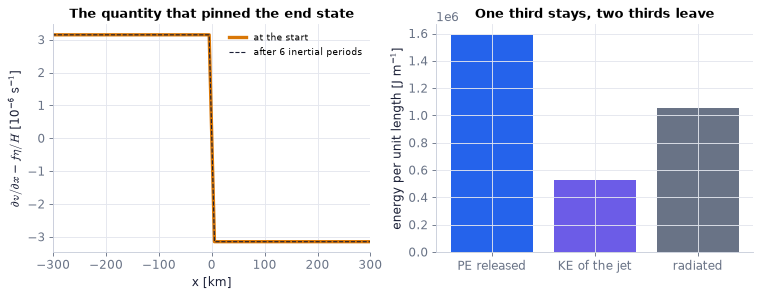

largest change of the linear potential vorticity during the run: 3.8e-20 1/s


In [131]:
x_face = 0.5*(x_a[1:] + x_a[:-1])                              # the interior cell faces, where the potential vorticity lives [m]
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 3.6))   # a new figure and its panel(s); figsize in inches
a.plot(x_face/1e3, runs_a[1]["pv"][0]*1e6, color=COLORS["amber"], lw=3, label="at the start")       # linear PV at the first step (amber = vorticity)
a.plot(x_face/1e3, runs_a[1]["pv"][1]*1e6, "--", color=COLORS["ink"], lw=1, label="after 6 inertial periods")   # and at the last
a.set(xlim=(-300, 300), xlabel="x [km]", ylabel=r"$\partial v/\partial x-f\eta/H$ [10$^{-6}$ s$^{-1}$]", title="The quantity that pinned the end state")   # axis labels (with units), title and fixed ranges of this panel
a.legend(fontsize=8)   # the legend names every curve
b.bar(["PE released", "KE of the jet", "radiated"], [en["pe_released"], en["ke_jet"], en["radiated"]], color=[COLORS["blue"], COLORS["accent"], COLORS["muted"]])   # the energy budget [J/m]
b.set(ylabel="energy per unit length [J m$^{-1}$]", title="One third stays, two thirds leave")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure
print(f"largest change of the linear potential vorticity during the run: {abs(runs_a[1]['pv'][1] - runs_a[1]['pv'][0]).max():.1e} 1/s")   # round-off

**What you see.** Left: the linear potential vorticity $\partial v/\partial x-f\eta/H$ against $x$ at the first and at the last time step of the rotating run. Right: the energy budget of the adjustment.

**How to read it.** The two curves on the left coincide: while the waves rearranged the surface and the velocity, this combination did not change anywhere. It is what the end state "remembers". `C13` makes it exact and nonlinear.

**What would change if…** …$f$ were halved? The radius $\Lambda$ doubles: twice as much potential energy is released and the jet is twice as wide; the ratio stays one third.

#### 🎮 Interactive: Why doesn't a pile of water flatten out on a rotating planet?

**Why interactive rather than a static figure:** pressing play with $f=0$ (everything radiates, nothing stays) and then with rotation (waves leave, a front of width $\Lambda$ stays) is the whole idea; the linked bars show how much potential energy was released and how much stayed.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Play the preset 'no rotation', then the mid-latitude preset, and compare the end cards.
- Halve f: the front is twice as wide.
- Switch from the step to the narrow bump: what fraction survives?
- Watch the potential-vorticity curve: it does not move.

In [132]:
show_viz("ch13", "geostrophic_adjustment")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/geostrophic_adjustment]

**What would change if…** …the motion is not small and $f$ varies with latitude? The quantity that pinned the end state here survives all of that:
potential vorticity (`C13`).

---

## 13.13 Potential Vorticity Conservation in Shallow-Water Theory

**What is this section about?** The one conservation law behind all slow, large-scale motion: every column of fluid carries
the ratio of its absolute vorticity to its depth unchanged. Stretch it, squash it or move it to another latitude, and its
spin must respond.

### 🧩 Potential vorticity: $\dfrac{D(\zeta+f)}{Dt}=\dfrac{\zeta+f_0}{h}\dfrac{Dh}{Dt}$ (13.93), hence $\dfrac{D}{Dt}\Big(\dfrac{\zeta+f}{h}\Big)=0$ with $f=f_0+\beta y$ (13.94) `C13`

*The question:* What does a column of fluid keep as it moves across an ocean of changing depth and latitude?

#### The problem in plain words

A skater who pulls her arms in spins faster. A column of ocean that is stretched taller gets thinner (its volume is fixed) and
spins faster too — except that the column already carries a spin it never chose: the earth's, $f$, which depends on latitude.
So there are two ways to change a column's own spin $\zeta$: change its height, or carry it north or south. Westerlies
crossing the Rockies are squashed, turn toward the equator, overshoot and meander downstream for thousands of kilometres.
Dynamicists treat potential vorticity as the dye that marks large-scale air and water masses.

#### The idea

| What happens to the column | Northern hemisphere ($f>0$) | Southern hemisphere ($f<0$) |
|---|---|---|
| stretched ($h$ grows) | $\zeta+f$ grows: more counter-clockwise spin | $\zeta+f$ becomes more negative: more clockwise spin |
| carried poleward ($\lvert f\rvert$ grows) at fixed $h$ | $\zeta$ falls (clockwise relative spin) | $\zeta$ rises (counter-clockwise relative spin) |

In both hemispheres stretching makes the absolute vorticity larger in magnitude, and a poleward trip gives anticyclonic
relative spin.

📝 **Note.** **N104 [C]** **The geometry** (our sketch): a column of total depth $h$ (over an uneven bottom, $h$ changes as the column moves) drawn
three times with the same volume — as it starts, stretched tall and thin, and squashed short and wide.

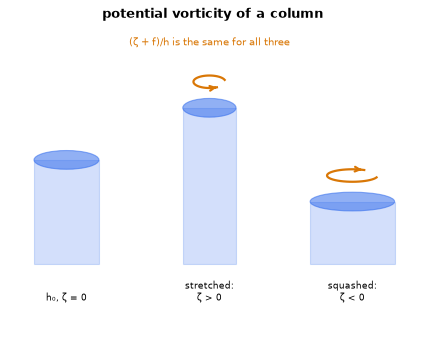

In [133]:
figC = draw_pv_column()                                        # our sketch: the same column, tall and thin or short and fat
plt.show()   # display the figure

**What you see.** Three columns of the same volume: the reference column ($h_0$, $\zeta=0$), the same column stretched (taller, thinner, with a counter-clockwise arrow: $\zeta>0$) and squashed (shorter, wider, with a clockwise arrow: $\zeta<0$). The caption says $(\zeta+f)/h$ is the same for all three.

**How to read it.** The sketch is drawn for the northern hemisphere ($f>0$). When a column moves into deeper water it becomes taller and thinner and, like the skater, gains spin; over shallower water it loses spin. For $f<0$ the two arrows reverse.

**What would change if…** …the bottom were flat and the surface nearly so? Then $h$ hardly changes and only a change of latitude can alter $\zeta$ — the Rossby wave of `C15`.

📝 **Note.** **N97 [B]** **Nonlinear $x$-momentum:** $\dfrac{\partial u}{\partial t}+u\dfrac{\partial u}{\partial x}+v\dfrac{\partial u}{\partial y}-fv=-g\dfrac{\partial\eta}{\partial x}$ (13.88).

📝 **Note.** **N98 [B]** **Nonlinear $y$-momentum:** $\dfrac{\partial v}{\partial t}+u\dfrac{\partial v}{\partial x}+v\dfrac{\partial v}{\partial y}+fu=-g\dfrac{\partial\eta}{\partial y}$ (13.89).

📝 **Note.** **N99 [B]** **Continuity for the total depth:** $\dfrac{\partial h}{\partial t}+\dfrac{\partial}{\partial x}(uh)+\dfrac{\partial}{\partial y}(vh)=0$ (13.90),
with $h$ the total depth over an uneven bottom and $f=f_0+\beta y$. These three are the Start of `D17`; unlike `C07` they are
nonlinear.

> 🔁 **Recap — Relative and absolute vorticity `R25`** (Ch. 3 and Ch. 5 §5.6). The quantity $\zeta\equiv\dfrac{\partial v}{\partial x}-\dfrac{\partial u}{\partial y}$ is the vertical vorticity measured by someone turning with
the earth (relative); adding the planet's own, $\zeta+f$, gives the absolute vorticity.

> 📎 **Primer — materially conserved: Dq/Dt = 0 labels a parcel; it does not mean q is steady at a point.** `P325` · The operator $D/Dt=\frac\partial{\partial t}+u\frac\partial{\partial x}+v\frac\partial{\partial y}$ (Chapter 3's material derivative)
follows one parcel. The statement $Dq/Dt=0$ says: each parcel keeps its own value of $q$ for ever, like a dye. At a fixed place $q$ can still
change, because parcels with different values pass by. Steady means $\partial q/\partial t=0$ — a different statement.

In [134]:
x = np.linspace(0, 10, 11); q0 = lambda x: x**2      # each parcel's label, set by where it started
U, t = 2.0, 1.5                                      # a uniform flow carries the parcels 3 units to the right
print(q0(x - U*t)[5], q0(x)[5])                      # at the fixed point x = 5: 4.0 now, 25.0 before — not steady, yet every parcel kept its q

4.0 25.0


> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **quotient rule** — $(a/b)'=(a'b-ab')/b^2$. *(Ch. 11, P265)*

#### 🧮 Derivation — Potential vorticity `D17` ★★★ (Eq. 13.93: $\frac{D(\zeta+f)}{Dt}=\frac{\zeta+f_0}{h}\frac{Dh}{Dt}$)

**What we want to show.** Show that each column of a shallow layer keeps its ratio of absolute vorticity to depth, starting from the full nonlinear equations with f varying northward.

**Assumptions.** Shallow water (hydrostatic, homogeneous, columnar motion); inviscid; the book's f → f₀ replacement in steps 3–9 (undone in step 10).

**The plan.**

1. Cross-differentiate the momentum equations to remove the pressure.
2. Regroup the nonlinear terms into advection of vorticity plus vorticity times divergence.
3. Replace the divergence by the rate of change of depth.
4. Combine with a quotient rule.

**Tools we use** (each explained before this point): cross-differentiation (P177) · product rule (P38) · material derivative (Ch. 3) · quotient rule (P265) — all reminders · "materially conserved" (P325)

**We start from**

$$ \begin{array}{l}\dfrac{\partial u}{\partial t}+u\dfrac{\partial u}{\partial x}+v\dfrac{\partial u}{\partial y}-fv=-g\dfrac{\partial\eta}{\partial x}\ \text{(13.88),} \\ \dfrac{\partial v}{\partial t}+u\dfrac{\partial v}{\partial x}+v\dfrac{\partial v}{\partial y}+fu=-g\dfrac{\partial\eta}{\partial y}\ \text{(13.89),} \\ \dfrac{\partial h}{\partial t}+\dfrac{\partial}{\partial x}(uh)+\dfrac{\partial}{\partial y}(vh)=0\ \text{(13.90), with}\ f=f_0+\beta y\end{array} $$

*In words:* Nonlinear shallow water over an uneven bottom

---

**Step 1 of 12 — Differentiate the y-momentum equation in x.**

$$ \dfrac{\partial}{\partial t}\dfrac{\partial v}{\partial x}+\dfrac{\partial}{\partial x}\Big[u\dfrac{\partial v}{\partial x}+v\dfrac{\partial v}{\partial y}\Big]+\dfrac{\partial(fu)}{\partial x}=-g\dfrac{\partial^2\eta}{\partial x\,\partial y} $$

- *Why we can do this:* Every term is differentiable; we aim at the mixed derivative of η so that it can be cancelled.
- *In words:* The first half of the vorticity equation.

---

**Step 2 of 12 — Differentiate the x-momentum equation in y.**

$$ \dfrac{\partial}{\partial t}\dfrac{\partial u}{\partial y}+\dfrac{\partial}{\partial y}\Big[u\dfrac{\partial u}{\partial x}+v\dfrac{\partial u}{\partial y}\Big]-\dfrac{\partial(fv)}{\partial y}=-g\dfrac{\partial^2\eta}{\partial y\,\partial x} $$

- *Why we can do this:* The same move on the other equation gives the same mixed derivative (Schwarz).
- *In words:* The second half.

---

**Step 3 of 12 — Subtract step 2 from step 1.**

$$ \begin{array}{l}\dfrac{\partial}{\partial t}\Big(\dfrac{\partial v}{\partial x}-\dfrac{\partial u}{\partial y}\Big)+\dfrac{\partial}{\partial x}\Big[u\dfrac{\partial v}{\partial x}+v\dfrac{\partial v}{\partial y}\Big]-\dfrac{\partial}{\partial y}\Big[u\dfrac{\partial u}{\partial x}+v\dfrac{\partial u}{\partial y}\Big]+f_0\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)+\beta v=0 \\ \text{(13.91)}\end{array} $$

- *Why we can do this:* The pressure terms cancel. The Coriolis terms give $\partial(fu)/\partial x+\partial(fv)/\partial y=f(\partial u/\partial x+\partial v/\partial y)+\beta v$, since f depends on y only; the book then writes f₀ for the undifferentiated f.
- *In words:* The term βv appears because the Coriolis parameter changes northward.

---

**Step 4 of 12 — Expand the two brackets.**

$$ u_xv_x+u\,v_{xx}+v_xv_y+v\,v_{xy}-u_yu_x-u\,u_{xy}-v_yu_y-v\,u_{yy}\ \text{(subscripts mean derivatives)} $$

- *Why we can do this:* Product rule on each of the four products; eight terms result. The book says they rearrange "easily".
- *In words:* The nonlinear terms, written out.

---

**Step 5 of 12 — Regroup them.**

$$ u\dfrac{\partial\zeta}{\partial x}+v\dfrac{\partial\zeta}{\partial y}+\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)\zeta,\qquad\zeta\equiv\dfrac{\partial v}{\partial x}-\dfrac{\partial u}{\partial y} $$

- *Why we can do this:* Terms 2 and 6 are $u\,\partial\zeta/\partial x$, terms 4 and 8 are $v\,\partial\zeta/\partial y$; the remaining four factor as $(u_x+v_y)(v_x-u_y)$.
- *In words:* Vorticity is carried by the flow and concentrated by convergence.

---

**Step 6 of 12 — Collect into a vorticity equation.**

$$ \dfrac{D\zeta}{Dt}+(\zeta+f_0)\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)+\beta v=0\ \text{(13.92)} $$

- *Why we can do this:* Steps 3 and 5 with $\frac D{Dt}\equiv\frac\partial{\partial t}+u\frac\partial{\partial x}+v\frac\partial{\partial y}$, the material derivative following the horizontal motion.
- *In words:* A column's relative vorticity changes when the flow converges and when the column moves north or south.

---

**Step 7 of 12 — Rewrite continuity with a product rule.**

$$ \dfrac{Dh}{Dt}+h\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)=0 $$

- *Why we can do this:* In the third Start equation, $\partial(uh)/\partial x=u\,\partial h/\partial x+h\,\partial u/\partial x$ and likewise in y; the advective parts join ∂h/∂t.
- *In words:* Convergence makes the column taller.

---

**Step 8 of 12 — Eliminate the divergence.**

$$ \dfrac{D\zeta}{Dt}=\dfrac{\zeta+f_0}{h}\dfrac{Dh}{Dt}-\beta v $$

- *Why we can do this:* Step 7 gives the divergence as $-\frac1h\frac{Dh}{Dt}$; insert it into step 6.
- *In words:* Stretching a column spins it up, in proportion to the vorticity it already has — including the planet's.

---

**Step 9 of 12 — Absorb the β term.**

$$ \dfrac{D(\zeta+f)}{Dt}=\dfrac{\zeta+f_0}{h}\dfrac{Dh}{Dt}\ \text{(13.93)} $$

- *Why we can do this:* Since f depends only on y, $\frac{Df}{Dt}=\frac{\partial f}{\partial t}+u\frac{\partial f}{\partial x}+v\frac{\partial f}{\partial y}=v\beta$; move βv to the left.
- *In words:* The absolute vorticity changes only by stretching.

---

**Step 10 of 12 — Restore f in the coefficient.**

$$ \dfrac{D(\zeta+f)}{Dt}=\dfrac{\zeta+f}{h}\dfrac{Dh}{Dt} $$

- *Why we can do this:* The book assumes βy ≪ f₀, so f₀ and f are interchangeable there. In fact the replacement in step 3 was never needed: keeping f gives this line exactly (checked below).
- *In words:* The equation is exact for shallow water.

---

**Step 11 of 12 — Apply the quotient rule to (ζ + f)/h.**

$$ \dfrac{D}{Dt}\Big(\dfrac{\zeta+f}{h}\Big)=\dfrac1{h^2}\Big[h\dfrac{D(\zeta+f)}{Dt}-(\zeta+f)\dfrac{Dh}{Dt}\Big] $$

- *Why we can do this:* D/Dt is a derivative, so the quotient rule holds for it; we form the ratio because step 10 suggests it.
- *In words:* The rate of change of the ratio, in terms of things we know.

---

**Step 12 of 12 — Insert step 10.**

$$ \dfrac{D}{Dt}\Big(\dfrac{\zeta+f}{h}\Big)=0\ \text{,}\ f=f_0+\beta y\ \text{(13.94)} $$

- *Why we can do this:* By step 10 the square bracket of step 11 is zero.
- *In words:* Following a column, (ζ + f)/h never changes.

---

**Result**

$$ \dfrac{D}{Dt}\Big(\dfrac{\zeta+f}{h}\Big)=0 $$

*In words:* Potential vorticity is conserved following the motion

**What it means.** Potential vorticity labels a column like a dye; Rossby waves, flow over topography, both instabilities and geostrophic turbulence are statements about it. **Fails when:** friction or forcing act (they change it slowly), or the layer is not shallow (stratified fluids have their own, Ertel's, version — beyond the book).

**Check it.** Units — (1/s)/m, the same on both sides of every line ✓. Limits — constant h: absolute vorticity ζ + f is conserved (the barotropic equation of §13.16); constant f: Chapter 5's column result. Number — a 5 % squash at 35° N: ζ = −0.05 f = −4.18 × 10⁻⁶ s⁻¹.

In [135]:
import sympy as sp                                            # symbolic algebra
x, y, t = sp.symbols("x y t", real=True)                      # east, north, time
g, f0, beta = sp.symbols("g f_0 beta", real=True)             # gravity, f0 and beta
u = sp.Function("u")(x, y, t)                                 # eastward velocity
v = sp.Function("v")(x, y, t)                                 # northward velocity
h = sp.Function("h")(x, y, t)                                 # total depth of the layer
b = sp.Function("b")(x, y)                                    # height of the uneven bottom
eta = h + b                                                   # surface height above the reference level
f = f0 + beta * y                                             # the EXACT f of the beta-plane (no f -> f0 step)
ut = -u * sp.diff(u, x) - v * sp.diff(u, y) + f * v - g * sp.diff(eta, x)   # (13.88) solved for du/dt
vt = -u * sp.diff(v, x) - v * sp.diff(v, y) - f * u - g * sp.diff(eta, y)   # (13.89) solved for dv/dt
ht = -sp.diff(u * h, x) - sp.diff(v * h, y)                   # (13.90) solved for dh/dt
zeta = sp.diff(v, x) - sp.diff(u, y)                          # relative vorticity
zeta_t = sp.diff(vt, x) - sp.diff(ut, y)                      # steps 1-3: cross-differentiate, pressure drops out
div = sp.diff(u, x) + sp.diff(v, y)                           # horizontal divergence
D = lambda F, Ft: Ft + u * sp.diff(F, x) + v * sp.diff(F, y)  # material derivative with a known dF/dt
step6 = D(zeta, zeta_t) + (zeta + f) * div + beta * v         # (13.92) with f kept exact
assert sp.simplify(sp.expand(step6)) == 0                     # steps 4-6: the vorticity equation holds
Dh = D(h, ht)                                                 # Dh/Dt from continuity
assert sp.simplify(sp.expand(Dh + h * div)) == 0              # step 7: Dh/Dt = -h (du/dx + dv/dy)
q = (zeta + f) / h                                            # potential vorticity
q_t = (zeta_t * h - (zeta + f) * ht) / h**2                   # step 11: quotient rule (f does not depend on t)
assert sp.simplify(sp.expand(sp.together(D(q, q_t)) * h**2)) == 0   # step 12: Dq/Dt = 0, exactly
print("D17 checks passed: vorticity equation, continuity in D/Dt form, D/Dt[(zeta + f)/h] = 0")

D17 checks passed: vorticity equation, continuity in D/Dt form, D/Dt[(zeta + f)/h] = 0


> ⚠️ **Common confusion (traps in `D17`):** Where βv comes from (differentiating fu and fv); the regrouping of the four products; the book's f → f₀ and back — the exact result needs neither (trap T10); h is the total depth over an uneven bottom, not the mean depth.

📝 **Note.** **N100 [B]** **Cross-differentiated momentum** (steps 1–3 of `D17`):
$\dfrac{\partial}{\partial t}\Big(\dfrac{\partial v}{\partial x}-\dfrac{\partial u}{\partial y}\Big)+\dfrac{\partial}{\partial x}\Big[u\dfrac{\partial v}{\partial x}+v\dfrac{\partial v}{\partial y}\Big]-\dfrac{\partial}{\partial y}\Big[u\dfrac{\partial u}{\partial x}+v\dfrac{\partial u}{\partial y}\Big]+f_0\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)+\beta v=0$ (13.91).

📝 **Note.** **N101 [B]** **The vorticity equation** (step 6): $\dfrac{D\zeta}{Dt}+(\zeta+f_0)\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)+\beta v=0$ (13.92).

> ⚠️ **Common confusion (trap T10):** The book replaces $f$ by $f_0$ in the coefficient and then restores it. The exact shallow-water result needs no such step — the
check cell above keeps $f=f_0+\beta y$ throughout.

> 🔁 **Recap — Potential vorticity is conserved following the motion `R26`** (Ch. 5 §5.6, derivation D20: $(\omega_z+2\Omega)/h$ constant for a column). $\dfrac{D}{Dt}\Big(\dfrac{\zeta+f}{h}\Big)=0$, $f=f_0+\beta y$ (13.94) — the boxed result of `D17`. Chapter 5 obtained the
f-plane version from Kelvin's theorem for a column; here it comes from the full nonlinear equations, with $f$ varying.

In [136]:
print("D/Dt[(zeta + f)/h] = 0 follows from the nonlinear shallow-water set ->", ch13.pv_conservation_sympy()["ok"])   # the engine agrees: True

D/Dt[(zeta + f)/h] = 0 follows from the nonlinear shallow-water set -> True


**What does this show?** The engine forms $(\zeta+f)/h$ from symbolic fields, takes its material derivative and substitutes
the three equations: nothing is left.

> 🔁 **Recap — How to read it `R27`** (Ch. 5 §5.6 (C11)). Stretching creates relative vorticity even from $\zeta=0$, because the column carries $f$. There is no tilting term: a shallow
layer moves in vertical columns. An increase of $h$ makes $\zeta+f$ more positive in the northern hemisphere ($f>0$) and more
negative in the southern ($f<0$) — larger in magnitude in both.

#### ✏️ Tiny example: a column crossing a ridge

Take $f=10^{-4}$ s⁻¹; a column with no relative vorticity ($\zeta=0$) and depth $h_0=4000$ m moves onto a plateau where
$h_1=3600$ m, without changing latitude.

1. Before: $q=(0+f)/h_0=10^{-4}/4000=2.5\times10^{-8}$ m⁻¹ s⁻¹.
2. After: $(\zeta+f)/h_1=q$ → $\zeta+f=2.5\times10^{-8}\times3600=0.9\times10^{-4}$ s⁻¹.
3. So $\zeta=-0.1\times10^{-4}$ s⁻¹ $=-0.1f$: clockwise (anticyclonic) spin in the northern hemisphere.
4. The same in one step: $\zeta=f(h_1-h_0)/h_0=10^{-4}\times(-400/4000)$.
5. Instead keep the depth and move the column 500 km north, where $f$ is larger by $\beta\Delta y=2\times10^{-11}\times5\times10^{5}=10^{-5}$ s⁻¹:
   $\zeta=-10^{-5}$ s⁻¹ again. A 10 % squash equals a 500 km trip north.

In [137]:
q_0 = GFD.potential_vorticity(0.0, f35, 9000.0)                # Eq. (13.94): (zeta + f)/h for a column at rest in a 9000 m layer at 35 N
z_1 = GFD.step_vorticity(f35, 9000.0, 8550.0)                  # its relative vorticity after being squashed by 5 % [1/s]
z_5 = ch05.column_relative_vorticity(8550.0, 9000.0, 0.0, f35) # Chapter 5's column function: the same number
z_s = GFD.step_vorticity(-f35, 9000.0, 8550.0)                 # the southern twin (f < 0)
print(f"q = {q_0:.3e} 1/(m s); after a 5 % squash at 35 N: zeta = {z_1:+.3e} 1/s = {z_1/f35:+.2f} f (clockwise); Ch. 5 function: {z_5:+.3e}")   # anticyclonic in the north
print(f"at 35 S: zeta = {z_s:+.3e} 1/s (counter-clockwise, which is anticyclonic there too)")   # anticyclonic in the south

q = 9.295e-09 1/(m s); after a 5 % squash at 35 N: zeta = -4.183e-06 1/s = -0.05 f (clockwise); Ch. 5 function: -4.183e-06
at 35 S: zeta = +4.183e-06 1/s (counter-clockwise, which is anticyclonic there too)


**What does the code above do?**

1. `GFD.potential_vorticity(zeta, f, h)` is $(\zeta+f)/h$; `GFD.step_vorticity(f, h0, h1)` solves "same $q$ before and after"
   for the new $\zeta$.
2. A 5 % squash produces a relative vorticity of 5 % of $f$, anticyclonic in both hemispheres.
3. Chapter 5's `column_relative_vorticity` — written from Kelvin's theorem — returns the same number.

In [138]:
# From scratch: keep (zeta + f)/h and solve for zeta
q_before = (0.0 + f35)/9000.0                                  # potential vorticity before the step
zeta_after = q_before*8550.0 - f35                             # the relative vorticity that keeps it over the shallower depth
assert np.isclose(zeta_after, GFD.step_vorticity(f35, 9000.0, 8550.0))               # same as the library
assert np.isclose(GFD.potential_vorticity(zeta_after, f35, 8550.0), q_before)        # and q is indeed unchanged
print(f"✓ zeta after the step = {zeta_after:+.3e} 1/s; q before = q after = {q_before:.3e} 1/(m s)")   # visible confirmation

✓ zeta after the step = -4.183e-06 1/s; q before = q after = 9.295e-09 1/(m s)


**What does the code above do?**

Two lines of arithmetic are the whole content of the conservation law for a column that changes depth at a fixed latitude.

#### 🧮 Derivation — Flow over a step: the vorticity just downstream and the streamline equation `D18` ★★

**What we want to show.** Turn the book's verbal argument about a current crossing a step into an equation for the streamline, for eastward and westward flow. **Ours** (the book argues in words).

**Assumptions.** Steady; small deflection, $\lvert dY/dx\rvert\ll1$ (step 3); β-plane.

**The plan.**

1. Apply conservation along a streamline.
2. Describe the streamline by its northward displacement Y(x).
3. Write ζ in terms of Y.
4. Solve the resulting ODE for U > 0 and U < 0.

**Tools we use** (each explained before this point): steady flow: streamlines are particle paths (Ch. 3, reminder) · second-order linear ODE (P44, reminder) · matching two solutions at a junction (the value and the slope must be continuous there)

**We start from**

$$ \begin{array}{l}\dfrac{D}{Dt}\Big(\dfrac{\zeta+f}{h}\Big)=0\ \text{,}\ f=f_0+\beta y\ \text{(13.94); a uniform current U along x with no relative} \\ \text{vorticity upstream; depth h₀ before the step at x = 0 and h₁ after it.}\end{array} $$

*In words:* Each column keeps its potential vorticity; upstream the flow is uniform

---

**Step 1 of 7 — Apply conservation along a streamline.**

$$ \dfrac{\zeta+f}{h}=\dfrac{f_0}{h_0} $$

- *Why we can do this:* In steady flow a column stays on one streamline, so its potential vorticity keeps the upstream value, where ζ = 0, f = f₀ and h = h₀.
- *In words:* Whatever happens downstream, this ratio is fixed.

---

**Step 2 of 7 — Describe the streamline by its displacement.**

$$ f=f_0+\beta Y(x) $$

- *Why we can do this:* A streamline that started at y = 0 and has moved north by Y sits where the Coriolis parameter is f₀ + βY.
- *In words:* Moving north raises f.

---

**Step 3 of 7 — Express the vorticity through Y.**

$$ v=U\dfrac{dY}{dx},\qquad\zeta=\dfrac{\partial v}{\partial x}=U\dfrac{d^2Y}{dx^2} $$

- *Why we can do this:* The flow is tangent to the streamline, so v/u = dY/dx with u ≈ U for a small deflection; and ∂u/∂y is negligible to the same order.
- *In words:* The curvature of the path is its relative vorticity (divided by U).

---

**Step 4 of 7 — Substitute into step 1.**

$$ \dfrac{d^2Y}{dx^2}+\dfrac{\beta}{U}Y=\dfrac{f_0}{U}\,\dfrac{h-h_0}{h_0} $$

- *Why we can do this:* Multiply step 1 by h, insert steps 2 and 3, and divide by U; the right-hand side is zero before the step and a constant after it.
- *In words:* An oscillator equation if U > 0, an exponential one if U < 0.

---

**Step 5 of 7 — Evaluate just after the step.**

$$ \zeta=U\dfrac{d^2Y}{dx^2}\Big|_{x=0^+}=\dfrac{f_0(h_1-h_0)}{h_0} $$

- *Why we can do this:* At the step the streamline has not yet moved (Y = 0), so step 4 gives the curvature directly. This is the book's $\zeta=f(h_1-h_0)/h_0<0$.
- *In words:* A column squashed by the step turns clockwise (northern hemisphere).

---

**Step 6 of 7 — Solve for eastward flow, U > 0.**

$$ Y=Y_p\big(1-\cos\kappa x\big)\ (x>0),\qquad\kappa=\sqrt{\dfrac\beta U},\qquad Y_p=\dfrac{f_0(h_1-h_0)}{\beta h_0} $$

- *Why we can do this:* Upstream Y = 0; downstream the particular solution is the constant Y_p and the homogeneous ones are cos κx and sin κx; Y and dY/dx are continuous at x = 0.
- *In words:* A standing meander of wavelength $2\pi\sqrt{U/\beta}$ about a new mean latitude.

---

**Step 7 of 7 — Solve for westward flow, U < 0.**

$$ Y=\tfrac12Y_pe^{-\mu x}\ (x>0),\qquad Y=Y_p\big(1-\tfrac12e^{\mu x}\big)\ (x<0),\qquad\mu=\sqrt{\dfrac{\beta}{\lvert U\rvert}} $$

- *Why we can do this:* The fluid now arrives from x > 0. The homogeneous solutions are exponentials; keep the ones that stay bounded on each side and match Y and dY/dx at the step.
- *In words:* No oscillation: the stream starts to turn before it reaches the step and settles at the new latitude after it.

---

**Result**

$$ \begin{array}{l}Y''+\dfrac\beta UY=\dfrac{f_0}{U}\dfrac{h-h_0}{h_0}\ \text{; eastward flow:}\ Y=Y_p(1-\cos\kappa x)\ \text{with wavelength}\ 2\pi\sqrt{U/\beta}\ \text{; westward} \\ \text{flow: exponential on both sides with e-folding length}\ \sqrt{\lvert U\rvert/\beta}\end{array} $$

*In words:* Eastward: a wake of stationary waves; westward: upstream influence and no wake

**What it means.** Westerlies crossing a mountain range leave a train of stationary waves downstream; easterlies do not. The asymmetry is the Rossby wave's: its phase can only go west, so it can stand still only in an eastward current. **Fails when:** the step is high (deflection not small), the flow is unsteady, or friction damps the wake. **Difference from the book's sketch:** for westward flow the book draws the stream back at its original latitude far downstream; our solution ends displaced by Y_p, as conservation of potential vorticity over a permanent change of depth requires.

**Check it.** Units — β/U = 1/m² ✓; Y_p = (1/s)/(1/(m s)) = m ✓. Vorticity jump — in both cases ζ changes by f₀(h₁ − h₀)/h₀ across the step ✓. Number (U = 17 m/s, a 5 % step, 35° N) — Y_p = −223 km, wavelength 5983 km, largest slope 0.23 (small, as assumed); westward: e-folding 952 km, Y = −112 km at the step. Link — $2\pi\sqrt{U/\beta}$ is the stationary Rossby wavelength of D23 step 9.

> ⚠️ **Common confusion (traps in `D18`):** Y is a displacement, not a velocity; for U < 0 "upstream" is x > 0; the bounded solution, not the one starting at the step, must be chosen on each side; f in the book's jump formula is the upstream value.

📝 **Note.** **N102 [B]** **Eastward flow over a step.** Just downstream of a step from depth $h_0$ to $h_1<h_0$, $\dfrac{f}{h_0}=\dfrac{\zeta+f}{h_1}$ gives
$\zeta=\dfrac{f(h_1-h_0)}{h_0}<0$; the column turns equatorward, where $f$ is smaller, overshoots, and a standing meander of
wavelength $\lambda=2\pi\sqrt{U/\beta}$ follows.

📝 **Note.** **N103 [B]** **Westward flow over the same step:** no oscillation — the displacement is exponential on both sides and begins *before* the
step. **Ours** (the book argues in words): the streamline equation $Y''+(\beta/U)Y=\text{const}$ and its solutions (`D18`).

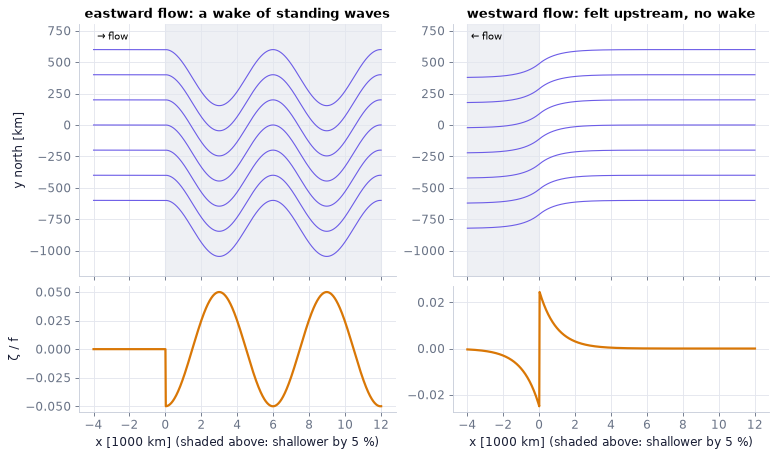

eastward: Y swings between 0 and -446 km, wavelength 5983 km
westward: Y = -112 km at the step, tends to -221 km far downstream; e-folding length 952 km; Y_p = -223 km


In [139]:
x_s = np.linspace(-4.0e6, 1.2e7, 801)                          # distance along the flow; the step is at x = 0 [m]
east = ch13.flow_over_step(x_s, 17.0, beta35, f35, 9000.0, 8550.0)    # eastward flow at 17 m/s over a 5 % step (ours, D18)
west = ch13.flow_over_step(x_s, -17.0, beta35, f35, 9000.0, 8550.0)   # westward flow over the same step
fig, axes = plt.subplots(2, 2, figsize=(9.6, 5.6), sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))   # a new figure and its panel(s); figsize in inches
for col, (r_, ttl, arrow) in enumerate(((east, "eastward flow: a wake of standing waves", "→ flow"), (west, "westward flow: felt upstream, no wake", "← flow"))):   # two columns
    for y0 in np.linspace(-600.0, 600.0, 7):                   # seven streamlines, starting at different latitudes [km]
        axes[0, col].plot(x_s/1e6, y0 + r_["Y"]/1e3, color=COLORS["accent"], lw=1)   # each displaced by Y(x)
    lo_hi = (0, x_s[-1]/1e6) if col == 0 else (x_s[0]/1e6, 0)  # the shallower side lies DOWNSTREAM of the step: x > 0 for eastward, x < 0 for westward flow
    axes[0, col].axvspan(*lo_hi, color=COLORS["grid"], alpha=0.6)   # shade it
    axes[0, col].set(title=ttl, ylim=(-1200, 800))   # axis labels (with units), title and fixed ranges of this panel
    axes[0, col].text(-3.8, 680, arrow, fontsize=9)            # the direction of the flow
    axes[1, col].plot(x_s/1e6, r_["zeta"]/f35, color=COLORS["amber"])   # relative vorticity in units of f (amber = vorticity)
    axes[1, col].set(xlabel="x [1000 km] (shaded above: shallower by 5 %)")   # axis labels (with units), title and fixed ranges of this panel
axes[0, 0].set_ylabel("y north [km]"); axes[1, 0].set_ylabel("ζ / f")   # label / range / scale of this axis
plt.show()   # display the figure
Y_p = f35*(8550.0 - 9000.0)/(beta35*9000.0)                    # the permanent shift f0 (h1 - h0)/(beta h0) [m]
print(f"eastward: Y swings between {east['Y'].max()/1e3:.0f} and {east['Y'].min()/1e3:.0f} km, wavelength {east['wavelength']/1e3:.0f} km")   # the standing meander
print(f"westward: Y = {west['Y'][np.argmin(abs(x_s))]/1e3:.0f} km at the step, tends to {west['Y'][0]/1e3:.0f} km far downstream; e-folding length {west['decay_length']/1e3:.0f} km; Y_p = {Y_p/1e3:.0f} km")   # the permanent shift

**What you see.** Top: streamlines of a uniform current meeting a step to shallower water (shaded: the shallower, downstream side), eastward flow on the left, westward flow (coming from the right) on the right. Bottom: the relative vorticity along a streamline.

**How to read it.** Eastward: nothing happens upstream; behind the step the stream swings equatorward and meanders about a line shifted toward the equator — a wake of stationary Rossby waves. Westward: the deflection begins *before* the step, there is no wake, and the stream settles at the shifted latitude.

**What would change if…** …$U$ were four times larger? The meander would be twice as long ($\lambda\propto\sqrt{U}$), and the upstream influence of the westward case would reach twice as far.

> ⚠️ **slip #14 — the book prints** (as a description and a sketch) that for westward flow over a step the stream returns to its original latitude far downstream **; the correct form is** a **permanent** shift. Conservation of potential vorticity, $\dfrac{D}{Dt}\Big(\dfrac{\zeta+f}{h}\Big)=0$ (13.94), with the
flow uniform again far downstream ($\zeta\to0$) requires $f_0+\beta Y_p=f_0h_1/h_0$ there, i.e.
$Y_p=f_0(h_1-h_0)/(\beta h_0)$ — about 220 km toward the equator for our 5 % step (printed above).

**The caveat to slip #14, stated honestly.** The printed description *is* right for a **finite ridge**: if the depth returns to
$h_0$ behind the obstacle, the column returns to its latitude. For a *step* — a permanent change of depth, which is what the
text describes — it cannot. No equation of the book is affected; only the description of this one case.

> 🔧 **Our choice** — the next figure uses **our numerical model, cached**: a nonlinear C-grid run on a 48 × 48 grid with 24 marked particles
(`ch13.load_reference_run("pv_particles")`).

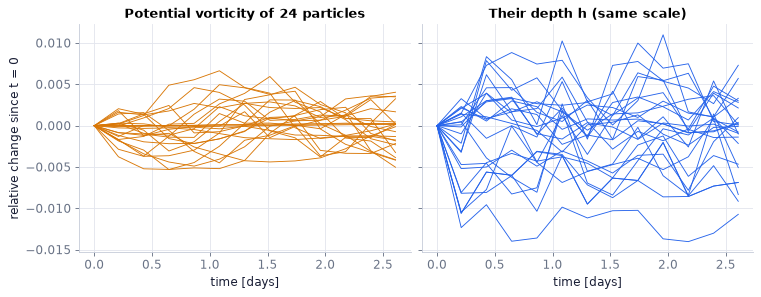

rms relative change: potential vorticity 0.22 %, depth 0.48 %; largest: 0.66 % and 1.40 %


In [140]:
pvr = ch13.load_reference_run("pv_particles")                  # our cached nonlinear run: particle tracks and their potential vorticity, or None
if pvr is None:                                                # no cache: say so and stop
    print("the cached run is absent — the closed-form figure above stands on its own")
else:
    q_p = np.asarray(pvr["q"], dtype=float)                    # potential vorticity of each particle at 13 times [1/(m s)]
    t_d = np.asarray(pvr["t"], dtype=float)/86400              # the 13 saved times [days]
    ix = np.abs(pvr["x"][None, None, :] - np.asarray(pvr["xp"], float)[:, :, None]).argmin(axis=2)   # nearest grid column of each particle
    iy = np.abs(pvr["y"][None, None, :] - np.asarray(pvr["yp"], float)[:, :, None]).argmin(axis=2)   # nearest grid row
    h_p = float(pvr["H"]) + np.asarray(pvr["eta"], float)[np.arange(len(t_d))[:, None], iy, ix]      # local depth h = H + eta at each particle [m]
    fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 3.6), sharey=True)   # a new figure and its panel(s); figsize in inches
    a.plot(t_d, q_p/q_p[0] - 1, color=COLORS["amber"], lw=0.8) # relative change of (zeta + f)/h along each track
    a.set(xlabel="time [days]", ylabel="relative change since t = 0", title="Potential vorticity of 24 particles")   # axis labels (with units), title and fixed ranges of this panel
    b.plot(t_d, h_p/h_p[0] - 1, color=COLORS["blue"], lw=0.8)  # relative change of the local depth along each track
    b.set(xlabel="time [days]", title="Their depth h (same scale)")   # axis labels (with units), title and fixed ranges of this panel
    plt.show()   # display the figure
    rms = lambda A_: np.sqrt(np.mean((A_/A_[0] - 1)**2))       # root-mean-square relative change over all particles and times
    print(f"rms relative change: potential vorticity {100*rms(q_p):.2f} %, depth {100*rms(h_p):.2f} %; largest: {100*abs(q_p/q_p[0] - 1).max():.2f} % and {100*abs(h_p/h_p[0] - 1).max():.2f} %")   # q is conserved, h is not

**What you see.** Left: the potential vorticity of each of 24 particles in a nonlinear model run, relative to its starting value. Right: the depth of the layer at the same particles.

**How to read it.** The depth at a particle changes as waves and eddies pass; its potential vorticity changes about half as much (the printed line gives both; what is left for the potential vorticity is the interpolation error of the diagnostic on a coarse 48 × 48 grid). The combination $(\zeta+f)/h$ is what each column keeps.

**What would change if…** …the run had friction? Then potential vorticity would slowly change along each track — it is conserved only for inviscid flow.

**What would change if…** …the stratification is continuous and we ask for waves of any slope, fast or slow? First the fast ones (`C14`); the slow
ones, which are this conservation law in motion, are Rossby waves (`C15`).

---

## 13.14 Internal Waves

**What is this section about?** Chapter 7's internal gravity waves with the earth's rotation added. The frequency is still set
by the direction of the wavevector alone, but now it is caught between $f$ and $N$. ⚠️ In this section the book's $\theta$ is
the angle of the wavevector with the horizontal, not latitude, and its $H$ is the scale over which $N$ changes, not a depth.

### 🧩 Inertia–gravity waves: $\omega^2-f^2=\dfrac{k^2}{m^2}(N^2-\omega^2)$ (13.112); equivalently, in a form the book prints without a number, $\omega^2=f^2\sin^2\theta+N^2\cos^2\theta$ `C14`

*The question:* What does rotation change about the internal waves of Chapter 7?

#### The problem in plain words

Lower a current meter into the thermocline and the record is full of oscillations with periods from about ten minutes to most
of a day. The short end is the buoyancy period $2\pi/N$; the long end is the inertial period $2\pi/f$. In between, every period
belongs to a wave whose crests have a definite slope: steep crests, fast wave; nearly flat crests, slow wave, almost an
inertial circle. These waves carry the energy of wind and tide into the deep ocean, where their breaking does much of the
mixing that ocean models have to parameterise.

#### The idea

Two springs again: buoyancy (stiffness $N^2$) resists vertical motion, rotation (stiffness $f^2$) resists horizontal motion.
Fluid moves along the crests. With $\theta_K$ the angle of the wavevector above the horizontal (the book's $\theta$ here):

| Wavevector | Crests | Motion | Frequency |
|---|---|---|---|
| horizontal, $\theta_K=0°$ | vertical | vertical: only buoyancy acts | $\omega=N$ |
| $\theta_K=45°$ | tilted 45° | both | $\omega^2=(f^2+N^2)/2$ |
| vertical, $\theta_K=90°$ | horizontal | horizontal: only rotation acts | $\omega=f$ |

> 🔁 **Recap — Internal waves without rotation `R28`** (Ch. 7 §7.8 (C15–C16)). Anisotropic; $\omega\le N$; frequency set by the angle of the wavevector, $\omega=N\cos\theta$; phase and group velocity
perpendicular, with opposite vertical components.

> 🔁 **Recap — The linear rotating Boussinesq set `R29`** (Ch. 7, the same set with $f=0$, ending in $\frac{\partial^2}{\partial t^2}\nabla^2w+N^2\nabla_H^2w=0$ (7.134)). Continuity $\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}=0$;
$\dfrac{\partial u}{\partial t}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}$; $\dfrac{\partial v}{\partial t}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}$;
$\dfrac{\partial w}{\partial t}=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial z}-\dfrac{\rho g}{\rho_0}$;
$\dfrac{\partial\rho}{\partial t}-\dfrac{\rho_0N^2}{g}w=0$ (13.95). New against Chapter 7: the two Coriolis
terms. Not hydrostatic.

In [141]:
print("the five-equation set (13.95) as coded is consistent (sympy engine) ->", ch13.rotating_internal_wave_set_sympy()["ok"])   # True

the five-equation set (13.95) as coded is consistent (sympy engine) -> True


**What does this show?** The starting set of `D19`, checked by its engine before we eliminate four of its five unknowns.

> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **`scipy.integrate.solve_ivp`** — `solve_ivp(rhs, (z0, z1), y0, t_eval=…)` integrates a system of first-order ordinary differential equations from given starting values. *(Ch. 1, P31)*

#### 🧮 Derivation — The w-equation with rotation, from the set `D19` ★★★ (Eq. 13.96: $\frac{\partial^2}{\partial t^2}\nabla^2w+N^2\nabla_H^2w+f^2\frac{\partial^2w}{\partial z^2}=0$)

**What we want to show.** Reduce five equations for u, v, w, p, ρ to one equation for the vertical velocity — the starting point for every internal wave in a rotating stratified fluid. The book refers to its Chapter 7 and never shows the steps with rotation.

**Assumptions.** Linear; f constant; N = N(z) (it is never differentiated — see step 9).

**The plan.**

1. Take the horizontal divergence of the momentum equations.
2. Take their curl.
3. Combine to remove u and v.
4. Combine the vertical and density equations to remove ρ.
5. Eliminate p between the two results.

**Tools we use** (each explained before this point): operator elimination (P177, reminder) · the Chapter 7 derivation of $\frac{\partial^2}{\partial t^2}\nabla^2w+N^2\nabla_H^2w=0$ (7.134), whose f = 0 pattern this follows

**We start from**

$$ \begin{array}{l}\text{the five members of (13.95):}\ \dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}=0\ \text{;} \\ \dfrac{\partial u}{\partial t}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}\ \text{;}\ \dfrac{\partial v}{\partial t}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}\ \text{;} \\ \dfrac{\partial w}{\partial t}=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial z}-\dfrac{\rho g}{\rho_0}\ \text{;}\ \dfrac{\partial\rho}{\partial t}-\dfrac{\rho_0N^2}{g}w=0\end{array} $$

*In words:* Linear, Boussinesq, rotating, not hydrostatic; N may depend on z

---

**Step 1 of 11 — Differentiate the x-momentum equation in x.**

$$ \dfrac{\partial^2u}{\partial t\,\partial x}-f\dfrac{\partial v}{\partial x}=-\dfrac1{\rho_0}\dfrac{\partial^2p}{\partial x^2} $$

- *Why we can do this:* Both f and ρ₀ are constants; we prepare the horizontal divergence.
- *In words:* Half of a divergence equation.

---

**Step 2 of 11 — Differentiate the y-momentum equation in y.**

$$ \dfrac{\partial^2v}{\partial t\,\partial y}+f\dfrac{\partial u}{\partial y}=-\dfrac1{\rho_0}\dfrac{\partial^2p}{\partial y^2} $$

- *Why we can do this:* The matching move on the other equation.
- *In words:* The other half.

---

**Step 3 of 11 — Add them.**

$$ \dfrac{\partial}{\partial t}\Big(\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}\Big)-f\zeta=-\dfrac1{\rho_0}\nabla_H^2p,\qquad\zeta\equiv\dfrac{\partial v}{\partial x}-\dfrac{\partial u}{\partial y} $$

- *Why we can do this:* The Coriolis terms combine into −f times the vertical vorticity; the pressure terms into the horizontal Laplacian.
- *In words:* Divergence changes because of vorticity and pressure.

---

**Step 4 of 11 — Replace the divergence by continuity.**

$$ -\dfrac{\partial^2w}{\partial t\,\partial z}-f\zeta=-\dfrac1{\rho_0}\nabla_H^2p\quad\text{(A)} $$

- *Why we can do this:* Continuity lets us trade the horizontal divergence for the vertical derivative of w: $\partial u/\partial x+\partial v/\partial y=-\partial w/\partial z$.
- *In words:* Now u and v appear only through ζ.

---

**Step 5 of 11 — Form the vorticity equation.**

$$ \dfrac{\partial\zeta}{\partial t}=f\dfrac{\partial w}{\partial z}\quad\text{(B)} $$

- *Why we can do this:* ∂/∂x of the y-equation minus ∂/∂y of the x-equation: the pressure cancels (Schwarz), leaving $\zeta_t+f(u_x+v_y)=0$; then continuity. This is the new step that rotation requires.
- *In words:* Stretching a column creates vorticity from the planet's spin.

---

**Step 6 of 11 — Differentiate (A) in time and insert (B).**

$$ -\dfrac{\partial^3w}{\partial t^2\,\partial z}-f^2\dfrac{\partial w}{\partial z}=-\dfrac1{\rho_0}\nabla_H^2\dfrac{\partial p}{\partial t}\quad\text{(C)} $$

- *Why we can do this:* The time derivative of −fζ is −f² ∂w/∂z by (B); u, v and ζ are now all eliminated.
- *In words:* One relation between w and p.

---

**Step 7 of 11 — Differentiate the vertical momentum equation in time.**

$$ \dfrac{\partial^2w}{\partial t^2}=-\dfrac1{\rho_0}\dfrac{\partial^2p}{\partial z\,\partial t}-\dfrac g{\rho_0}\dfrac{\partial\rho}{\partial t} $$

- *Why we can do this:* We want ∂ρ/∂t to appear, because the density equation gives it in terms of w.
- *In words:* Preparing to remove the density.

---

**Step 8 of 11 — Insert the density equation.**

$$ \dfrac{\partial^2w}{\partial t^2}+N^2w=-\dfrac1{\rho_0}\dfrac{\partial^2p}{\partial z\,\partial t}\quad\text{(D)} $$

- *Why we can do this:* The fifth Start equation gives $\frac g{\rho_0}\frac{\partial\rho}{\partial t}=N^2w$.
- *In words:* A second relation between w and p: the buoyancy oscillator, forced by pressure.

---

**Step 9 of 11 — Apply the horizontal Laplacian to (D).**

$$ \nabla_H^2\dfrac{\partial^2w}{\partial t^2}+N^2\nabla_H^2w=-\dfrac1{\rho_0}\nabla_H^2\dfrac{\partial^2p}{\partial z\,\partial t} $$

- *Why we can do this:* N depends on z only, so it passes through the horizontal derivatives untouched — which is why (D), not (C), receives $\nabla_H^2$.
- *In words:* Dressing (D) so that its pressure term matches the one coming next.

---

**Step 10 of 11 — Differentiate (C) in z.**

$$ -\dfrac{\partial^4w}{\partial t^2\,\partial z^2}-f^2\dfrac{\partial^2w}{\partial z^2}=-\dfrac1{\rho_0}\nabla_H^2\dfrac{\partial^2p}{\partial t\,\partial z} $$

- *Why we can do this:* (C) contains no N, so differentiating it in z produces no derivative of N.
- *In words:* The same pressure term as in step 9.

---

**Step 11 of 11 — Subtract step 10 from step 9.**

$$ \dfrac{\partial^2}{\partial t^2}\nabla^2w+N^2\nabla_H^2w+f^2\dfrac{\partial^2w}{\partial z^2}=0\ \text{(13.96)} $$

- *Why we can do this:* The pressure terms are equal and cancel; $\nabla_H^2w_{tt}+w_{zztt}$ is the full Laplacian $\nabla^2=\nabla_H^2+\partial^2/\partial z^2$ of $w_{tt}$.
- *In words:* One equation for w: inertia, buoyancy acting on horizontal variations, rotation acting on vertical ones.

---

**Result**

$$ \dfrac{\partial^2}{\partial t^2}\nabla^2w+N^2\nabla_H^2w+f^2\dfrac{\partial^2w}{\partial z^2}=0 $$

*In words:* The internal-wave equation with rotation

**What it means.** Rotation adds one term, with the *vertical* second derivative: it stiffens the fluid against motions that vary along the rotation axis, as buoyancy stiffens it against motions that vary horizontally. **Fails when:** the waves are not small, there is a mean shear, or f varies across the wave.

**Check it.** Units — every term is (m/s)/(s² m²) ✓. Limits — f = 0: Chapter 7's $\frac{\partial^2}{\partial t^2}\nabla^2w+N^2\nabla_H^2w=0$ (7.134); N = 0: pure inertial waves, $\frac{\partial^2}{\partial t^2}\nabla^2w+f^2w_{zz}=0$. Plane wave — it gives the dispersion relation of D20.

In [142]:
import sympy as sp                                            # symbolic algebra
x, y, z, t = sp.symbols("x y z t", real=True)                 # space and time
f, rho0, g = sp.symbols("f rho_0 g", positive=True)           # Coriolis parameter, reference density, gravity
N = sp.Function("N")(z)                                       # buoyancy frequency, allowed to vary with z
w = sp.Function("w")(x, y, z, t)                              # vertical velocity
p = sp.Function("p")(x, y, z, t)                              # perturbation pressure
lapH = lambda F: sp.diff(F, x, 2) + sp.diff(F, y, 2)          # horizontal Laplacian
C = -sp.diff(w, z, t, t) - f**2 * sp.diff(w, z) + lapH(sp.diff(p, t)) / rho0   # step 6: (C) = 0
Dq = sp.diff(w, t, 2) + N**2 * w + sp.diff(p, z, t) / rho0    # step 8: (D) = 0
combo = sp.expand(lapH(Dq) - sp.diff(C, z))                   # steps 9-11: lapH of (D) minus d/dz of (C)
target = sp.diff(lapH(w) + sp.diff(w, z, 2), t, 2) + N**2 * lapH(w) + f**2 * sp.diff(w, z, 2)   # (13.96)
assert sp.simplify(combo - sp.expand(target)) == 0            # pressure cancelled; N(z) was never differentiated
s, a, b, d, Nc = sp.symbols("s a b d N_c")                    # constant-N cross-check: d/dt, d/dx, d/dy, d/dz
M = sp.Matrix([[a, b, d, 0, 0],                               # continuity     (unknowns u, v, w, p/rho0, g rho/rho0)
               [s, -f, 0, a, 0],                              # x-momentum
               [f, s, 0, b, 0],                               # y-momentum
               [0, 0, s, d, 1],                               # z-momentum
               [0, 0, -Nc**2, 0, s]])                         # density equation times g/rho0
det = sp.factor(M.det())                                      # one operator acting on any of the unknowns
op = s**2 * (a**2 + b**2 + d**2) + Nc**2 * (a**2 + b**2) + f**2 * d**2   # the operator of (13.96)
assert sp.simplify(det / op).free_symbols <= {s}              # the determinant is (13.96) times a power of d/dt
print("D19 checks passed: elimination with N(z), and the 5x5 determinant =", det)

D19 checks passed: elimination with N(z), and the 5x5 determinant = s*(N_c**2*a**2 + N_c**2*b**2 + a**2*s**2 + b**2*s**2 + d**2*f**2 + d**2*s**2)


> ⚠️ **Common confusion (traps in `D19`):** The vorticity equation (step 5) is the step that brings in f²; the Laplacian is three-dimensional in the first term and horizontal in the second; N stays outside every z-derivative because of the order chosen in steps 9–10; slip #8 — the book prints "depth independent" for N, the correct form is depth dependent.

📝 **Note.** **N105 [B]** **The single equation for $w$:** $\dfrac{\partial^2}{\partial t^2}\nabla^2w+N^2\nabla_H^2w+f^2\dfrac{\partial^2w}{\partial z^2}=0$ (13.96) —
written out in `D19` because the book refers to its §7.8 and never shows the steps with rotation.

> ⚠️ **slip #8 — the book prints** that $N$ is taken "depth independent" in §13.14 **; the correct form is** depth dependent, $N(z)$, as its own definition $m^2(z)\equiv\frac{(k^2+l^2)[N^2(z)-\omega^2]}{\omega^2-f^2}$ (13.99) requires.

In [143]:
k_w, m_w = 2*np.pi/1.0e4, 2*np.pi/200.0                        # a wave 10 km long and 200 m tall [rad/m]
w_ig = GFD.inertia_gravity_omega(k_w, m_w, N_o, f35)           # its frequency from Eq. (13.112) [rad/s]
w_fn = lambda xx, yy, zz, tt: np.cos(k_w*xx + m_w*zz - w_ig*tt)   # a plane wave of vertical velocity
res_w = ch13.w_equation_rotating_residual(w_fn, 0.0, 0.0, 0.0, 0.0, N_o, f35)   # what is left of Eq. (13.96) by finite differences
print("the w-equation (13.96) follows from the set (13.95) ->", ch13.w_equation_rotating_sympy()["ok"])   # the engine agrees: True
print(f"a plane wave with omega from (13.112) put into (13.96): residual = {abs(res_w)/(N_o**2*k_w**2):.1e} of the N^2 k^2 term")   # the dispersion relation solves it

the w-equation (13.96) follows from the set (13.95) -> True
a plane wave with omega from (13.112) put into (13.96): residual = 6.3e-05 of the N^2 k^2 term


**What does this show?** Two checks of `D19`: the symbolic elimination gives the printed equation, and a plane wave whose
frequency comes from the dispersion relation satisfies it to finite-difference accuracy.

#### 🧮 Derivation — The vertical structure and the dispersion relation `D20` ★★ (Eq. 13.112: $\omega^2-f^2=\frac{k^2}{m^2}(N^2-\omega^2)$)

**What we want to show.** Find which frequencies an internal wave may have in a rotating stratified fluid, and what sets them.

**Assumptions.** N varies slowly enough to speak of a local m (steps 4–7; made precise by the WKB note N111).

**The plan.**

1. Substitute.
2. Collect the equation for the vertical structure.
3. Name the local vertical wavenumber.
4. For a locally uniform N read off the dispersion relation.
5. Rewrite it with the angle of the wavevector.

**Tools we use** (each explained before this point): plane-wave substitution (P176, reminder) · $1+\tan^2\theta=1/\cos^2\theta$

**We start from**

$$ \begin{array}{l}\dfrac{\partial^2}{\partial t^2}\nabla^2w+N^2\nabla_H^2w+f^2\dfrac{\partial^2w}{\partial z^2}=0\ \text{(13.96) and the trial solution} \\ [u,v,w]=[\hat u(z),\hat v(z),\hat w(z)]\,e^{i(kx+ly-\omega t)}\ \text{(13.97)}\end{array} $$

*In words:* The Result of D19 and a wave that is plane in the horizontal

---

**Step 1 of 7 — Substitute the trial solution.**

$$ (-i\omega)^2\Big[(ik)^2+(il)^2+\dfrac{d^2}{dz^2}\Big]\hat w+N^2\big[(ik)^2+(il)^2\big]\hat w+f^2\dfrac{d^2\hat w}{dz^2}=0 $$

- *Why we can do this:* Each ∂/∂t becomes −iω, ∂/∂x becomes ik, ∂/∂y becomes il; the z-dependence is kept because N may vary with z.
- *In words:* An ordinary differential equation in z for the wave's vertical structure.

---

**Step 2 of 7 — Multiply out and collect.**

$$ \dfrac{d^2\hat w}{dz^2}+\dfrac{(N^2-\omega^2)(k^2+l^2)}{\omega^2-f^2}\hat w=0\ \text{(13.98)} $$

- *Why we can do this:* Here $(-i\omega)^2=-\omega^2$ and $(ik)^2=-k^2$; the $\hat w''$ terms combine to $(f^2-\omega^2)\hat w''$; divide by $-(\omega^2-f^2)$.
- *In words:* An oscillator equation in z.

---

**Step 3 of 7 — Name the coefficient.**

$$ m^2(z)\equiv\dfrac{(k^2+l^2)\,[N^2(z)-\omega^2]}{\omega^2-f^2}\ \Rightarrow\ \dfrac{d^2\hat w}{dz^2}+m^2\hat w=0\ \text{(13.99)–(13.100)} $$

- *Why we can do this:* A definition: where m² > 0 the solution oscillates in z with local wavenumber m, where m² < 0 it decays.
- *In words:* Waves need m² > 0, that is, a frequency between f and N.

---

**Step 4 of 7 — Specialise to l = 0 and a locally uniform N.**

$$ \hat w\propto e^{\pm imz},\qquad m^2=\dfrac{k^2(N^2-\omega^2)}{\omega^2-f^2}\ \text{(13.109)} $$

- *Why we can do this:* With constant m the oscillator equation has exponential solutions; orienting x along the horizontal wavevector loses nothing (the problem is isotropic in the horizontal).
- *In words:* A plane wave with wavevector (k, m).

---

**Step 5 of 7 — Rearrange.**

$$ \omega^2-f^2=\dfrac{k^2}{m^2}\big(N^2-\omega^2\big)\ \text{(13.112)} $$

- *Why we can do this:* Multiply step 4 by $(\omega^2-f^2)/m^2$, so that the two frequency differences stand side by side.
- *In words:* How far the frequency is above f, compared with how far it is below N, is set by the slope k/m.

---

**Step 6 of 7 — Introduce the angle of the wavevector.**

$$ \tan\theta=\dfrac mk\ \Rightarrow\ \omega^2\big(1+\tan^2\theta\big)=N^2+f^2\tan^2\theta $$

- *Why we can do this:* Here θ is the angle between the wavevector and the horizontal (not latitude here); multiply step 5 by tan² θ and gather the ω² terms.
- *In words:* Only the direction of the wavevector appears, not its length.

---

**Step 7 of 7 — Multiply by cos² θ.**

$$ \omega^2=f^2\sin^2\theta+N^2\cos^2\theta $$

- *Why we can do this:* Use $1+\tan^2\theta=1/\cos^2\theta$ and $\tan^2\theta\cos^2\theta=\sin^2\theta$. The book prints this form without a number.
- *In words:* The squared frequency is a weighted mean of f² and N².

---

**Result**

$$ \omega^2-f^2=\dfrac{k^2}{m^2}(N^2-\omega^2)\ \text{, equivalently}\ \omega^2=f^2\sin^2\theta+N^2\cos^2\theta $$

*In words:* The frequency of an inertia–gravity wave depends only on the tilt of its wavevector and lies between f and N

**What it means.** a wave-maker oscillating at frequency ω sends energy out along beams of one fixed slope; rotation flattens those beams as ω approaches f. **Fails when:** N changes within a vertical wavelength (then solve step 3 numerically, or use the WKB form), or ω is outside the band (no propagation).

**Check it.** Units — s⁻² throughout ✓. Limits — f = 0: ω = N cos θ (Chapter 7); θ = 0 (vertical crests): ω = N; θ = 90° (horizontal crests): ω = f. Number — N = 2.7 × 10⁻³ s⁻¹, 35° N: θ = 45° gives ω = 22.8 f; θ = 89° gives 1.148 f. Regimes — near N drop f² ($m^2\simeq k^2(N^2-\omega^2)/\omega^2$); near f drop ω² against N² ($\omega^2\simeq f^2+k^2N^2/m^2$, hydrostatic); in between both ($m^2\simeq k^2N^2/\omega^2$).

> ⚠️ **Common confusion (traps in `D20`):** The signs of (−iω)² and (ik)²; θ here is the angle of the wavevector with the horizontal, not latitude (trap T13); real m needs f < ω < N; each regime approximation has an error that the notebook tabulates.

📝 **Note.** **N106 [C]** **The trial solution** (step 1 of `D20`): $[u,v,w]=[\hat u(z),\hat v(z),\hat w(z)]\,e^{i(kx+ly-\omega t)}$ (13.97).

📝 **Note.** **N107 [B]** **The vertical-structure equation** (step 2): $\dfrac{d^2\hat w}{dz^2}+\dfrac{(N^2-\omega^2)(k^2+l^2)}{\omega^2-f^2}\hat w=0$ (13.98).

📝 **Note.** **N108 [B]** **The local vertical wavenumber** (step 3): $m^2(z)\equiv\dfrac{(k^2+l^2)[N^2(z)-\omega^2]}{\omega^2-f^2}$ (13.99)
(`GFD.inertia_gravity_m2`).

📝 **Note.** **N109 [B]** **The oscillator form:** $\dfrac{d^2\hat w}{dz^2}+m^2\hat w=0$ (13.100).

📝 **Note.** **N119 [C]** **For $l=0$** (step 4): $m^2=\dfrac{k^2(N^2-\omega^2)}{\omega^2-f^2}$ (13.109).

📝 **Note.** **N110 [B]** **The band.** Internal waves exist only for $f<\omega<N$: there $m^2>0$ and the structure oscillates in $z$; outside the band
$m^2<0$ and it decays (it is *evanescent*).

In [144]:
for w_, nm in ((0.5*f35, "0.5 f"), (5*f35, "5 f"), (1.2*N_o, "1.2 N")):   # three frequencies: below, inside and above the band
    bd = GFD.inertia_gravity_band(w_, N_o, f35)                # where this frequency lies
    m2 = GFD.inertia_gravity_m2(k_w, 0.0, w_, N_o, f35)        # Eq. (13.99): m^2 for a 10 km wave [1/m^2]
    print(f"omega = {nm:>5}: {bd['where']:>8} | m^2 = {m2:+.2e} 1/m^2 | {'propagates' if bd['propagating'] else 'evanescent'}")   # our own label, built from the dictionary

omega = 0.5 f:  below f | m^2 = -5.48e-04 1/m^2 | evanescent
omega =   5 f:  in band | m^2 = +1.67e-05 1/m^2 | propagates
omega = 1.2 N:  above N | m^2 = -1.21e-07 1/m^2 | evanescent


**What does this show?** Below $f$ and above $N$ the squared vertical wavenumber is negative — no wave; in between it is
positive. (`N_o` is our ocean's $N=2.7\times10^{-3}$ s⁻¹; $N/f=32$ at 35° N.)

#### ✏️ Tiny example: frequency from the slope of the crests

Take $f=10^{-4}$ s⁻¹, $N=10^{-2}$ s⁻¹ ($N/f=100$).

1. Wavevector 60° from the horizontal: $\omega^2=f^2\sin^260°+N^2\cos^260°=0.75\times10^{-8}+0.25\times10^{-4}\approx0.25\times10^{-4}$ →
   $\omega=5\times10^{-3}$ s⁻¹ $=N/2$ (period 21 min): rotation is invisible.
2. Wavevector almost vertical, $m/k=100$ ($\tan\theta=100$): $\cos^2\theta\approx10^{-4}$, $\sin^2\theta\approx1$ →
   $\omega^2=10^{-8}+10^{-4}\times10^{-4}=2\times10^{-8}$ → $\omega=1.41f$ (period 12.3 h): half rotation, half buoyancy.
3. With $m/k=1000$: $\omega=1.005f$ — an inertial oscillation.

In [145]:
for th_deg in (5, 45, 85, 89):                                 # angle of the wavevector above the horizontal [degrees]
    w_ = GFD.inertia_gravity_omega(np.cos(np.deg2rad(th_deg)), np.sin(np.deg2rad(th_deg)), N_o, f35)   # only the direction of (k, m) matters
    print(f"angle {th_deg:2d} deg: omega = {w_/N_o:.3f} N = {w_/f35:5.2f} f")   # from N (flat wavevector) down to f (vertical wavevector)
cg = GFD.inertia_gravity_group_velocity(k_w, m_w, N_o, f35)    # group velocity (c_gx, c_gz) of the 10 km x 200 m wave [m/s]
cp = w_ig/(k_w**2 + m_w**2)*np.array([k_w, m_w])               # phase velocity vector: (omega/K^2) K [m/s]
print(f"10 km x 200 m wave: omega = {w_ig:.4e} 1/s = {w_ig/f35:.3f} f (period {2*np.pi/w_ig/3600:.1f} h)")   # near-inertial
print(f"group velocity = ({cg[0]:+.4f}, {cg[1]:+.2e}) m/s; phase speed = {np.hypot(*cp)*1e3:.2f} mm/s; c_p · c_g = {np.dot(cp, cg):.1e}")   # perpendicular
print(f"f = 0 check against Chapter 7: {GFD.inertia_gravity_omega(k_w, m_w, N_o, 0.0):.6e} vs {WAV.internal_wave_omega(k_w, m_w, N_o):.6e} 1/s")   # the non-rotating limit

angle  5 deg: omega = 0.996 N = 32.15 f
angle 45 deg: omega = 0.707 N = 22.83 f
angle 85 deg: omega = 0.092 N =  2.98 f
angle 89 deg: omega = 0.036 N =  1.15 f
10 km x 200 m wave: omega = 9.9547e-05 1/s = 1.190 f (period 17.5 h)
group velocity = (+0.0465, -9.31e-04) m/s; phase speed = 3.17 mm/s; c_p · c_g = -4.2e-22
f = 0 check against Chapter 7: 5.398920e-05 vs 5.398920e-05 1/s


**What does the code above do?**

1. `GFD.inertia_gravity_omega(k, m, N, f)` is the dispersion relation solved for $\omega$; only the direction of $(k, m)$ matters.
2. As the wavevector turns from horizontal to vertical the frequency falls from $N$ to $f$.
3. For a wave 10 km long and 200 m tall the frequency is 1.19 $f$; its energy travels almost horizontally and slightly
   *downward* while its crests move upward; phase and group velocity are perpendicular.
4. With $f=0$ the function reduces to Chapter 7's `WAV.internal_wave_omega`.

> 📎 **Primer — group velocity as the gradient of ω in wavenumber space, read off a contour plot.** `P326` · In one dimension the energy of a wave packet travels at $d\omega/dk$. In two or three, at the vector
$(\partial\omega/\partial k,\ \partial\omega/\partial l,\ \partial\omega/\partial m)$: the gradient of $\omega$ in wavenumber space. On a
contour plot of $\omega$ over the $(k, m)$ plane it points straight uphill, at right angles to the contours — and its length is
how crowded the contours are.

In [146]:
w = lambda k, m: np.sqrt((k**2 + 0.01*m**2)/(k**2 + m**2))    # N = 1, f = 0.1
h = 1e-6; k0, m0 = 1.0, 2.0                                    # a wavevector pointing forward and up
print("group velocity (c_gx, c_gz) =", round((w(k0+h, m0)-w(k0-h, m0))/(2*h), 3), round((w(k0, m0+h)-w(k0, m0-h))/(2*h), 3))   # (0.354, -0.177): energy goes forward and DOWN while crests go forward and up

group velocity (c_gx, c_gz) = 0.347 -0.174


#### 🧮 Derivation — The group velocity of inertia–gravity waves; phase ⟂ group `D21` ★★

**What we want to show.** Find where the energy of an inertia–gravity wave goes. The book leaves it to an exercise.

**Assumptions.** Uniform N locally; l = 0; N > f.

**The plan.**

1. Solve it for ω² as a function of (k, m).
2. Differentiate with respect to k and to m.
3. Put the two components together.
4. Compare with the phase velocity and the particle motion.

**Tools we use** (each explained before this point): group velocity as the gradient of ω in wavenumber space (P326) · quotient rule (P265, reminder)

**We start from**

$$ \omega^2-f^2=\dfrac{k^2}{m^2}(N^2-\omega^2)\ \text{(13.112) for a locally uniform N} $$

*In words:* The dispersion relation of D20

---

**Step 1 of 7 — Solve for ω².**

$$ \omega^2=\dfrac{N^2k^2+f^2m^2}{k^2+m^2} $$

- *Why we can do this:* Multiply the Start by m², gather the ω² terms and divide by k² + m²; an explicit function is needed before differentiating.
- *In words:* The frequency as a function of the two wavenumbers.

---

**Step 2 of 7 — Differentiate with respect to k.**

$$ 2\omega\dfrac{\partial\omega}{\partial k}=\dfrac{2N^2k\,(k^2+m^2)-2k\,(N^2k^2+f^2m^2)}{(k^2+m^2)^2}=\dfrac{2km^2(N^2-f^2)}{(k^2+m^2)^2} $$

- *Why we can do this:* Chain rule on the left, quotient rule on the right; the terms $2N^2k^3$ cancel.
- *In words:* Differentiating ω² avoids square roots.

---

**Step 3 of 7 — Divide by 2ω.**

$$ c_{gx}=\dfrac{\partial\omega}{\partial k}=\dfrac{km^2(N^2-f^2)}{\omega\,(k^2+m^2)^2} $$

- *Why we can do this:* Since ω > 0 we may divide by it; the horizontal group velocity is the k-derivative of ω.
- *In words:* Energy moves horizontally in the direction of k.

---

**Step 4 of 7 — Do the same for m.**

$$ c_{gz}=\dfrac{\partial\omega}{\partial m}=-\dfrac{k^2m\,(N^2-f^2)}{\omega\,(k^2+m^2)^2} $$

- *Why we can do this:* The same two rules as in steps 2–3; now the numerator is $2f^2m(k^2+m^2)-2m(N^2k^2+f^2m^2)=-2mk^2(N^2-f^2)$.
- *In words:* The vertical group velocity has the opposite sign to m.

---

**Step 5 of 7 — Insert ω and combine.**

$$ [c_{gx},c_{gz}]=\dfrac{(N^2-f^2)\,km}{(m^2+k^2)^{3/2}(m^2f^2+k^2N^2)^{1/2}}\,[m,\,-k] $$

- *Why we can do this:* From step 1, $\omega=(N^2k^2+f^2m^2)^{1/2}/(k^2+m^2)^{1/2}$; both components share the prefactor.
- *In words:* The group velocity points along (m, −k).

---

**Step 6 of 7 — Dot with the phase velocity.**

$$ \mathbf c\cdot\mathbf c_g\propto(k,\ m)\cdot(m,\ -k)=km-mk=0 $$

- *Why we can do this:* The phase velocity is along the wavevector (k, m). A zero dot product means perpendicular.
- *In words:* Energy travels along the crests, not across them; if the crests move up, the energy moves down.

---

**Step 7 of 7 — Compare with the particle motion.**

$$ \dfrac uw=\mp\dfrac mk\ \Rightarrow\ (u,\ w)\parallel(m,\ -k)\parallel\mathbf c_g $$

- *Why we can do this:* The relation $\dfrac uw=\mp\dfrac mk=\mp\tan\theta$ (13.111) says the motion in the x–z plane is along (m, −k) — the direction just found.
- *In words:* In the vertical plane the fluid slides back and forth along the direction in which the energy travels.

---

**Result**

$$ [c_{gx},c_{gz}]=\dfrac{(N^2-f^2)\,km}{(m^2+k^2)^{3/2}(m^2f^2+k^2N^2)^{1/2}}\,[m,\,-k]\ \text{, with}\ \mathbf c\cdot\mathbf c_g=0 $$

*In words:* Phase and energy move at right angles, with opposite vertical components

**What it means.** Storms put near-inertial energy into the top of the ocean; it leaks downward along gently sloping rays while the phase is seen to move *up*. **Fails when:** N varies within a wavelength (ray tracing with the local N then applies).

**Check it.** Units — (s⁻²)(m⁻²)/(m⁻³ · s⁻¹ m⁻¹) × m⁻¹ = m/s ✓. Limits — f = 0: Chapter 7's result; N = f: no dispersion in angle and zero group velocity. Number — N = 2.7 × 10⁻³ s⁻¹, 35° N, a wave 10 km long and 200 m tall: c_g = (+0.0465, −9.31 × 10⁻⁴) m/s. Code — central differences of `GFD.inertia_gravity_omega`.

> ⚠️ **Common confusion (traps in `D21`):** Differentiate ω², then divide by 2ω; the vertical components of phase and group velocity have opposite signs; with f = 0 the result must reduce to Chapter 7's.

📝 **Note.** **N124 [B]** **The group velocity** (the book leaves it to an exercise; `D21`):
$[c_{gx},c_{gz}]=\dfrac{(N^2-f^2)\,km}{(m^2+k^2)^{3/2}(m^2f^2+k^2N^2)^{1/2}}\,[m,\,-k]$ — phase velocity along the wavevector,
group velocity at right angles to it with the opposite vertical sign, fluid motion along the group velocity.

In [147]:
# From scratch: the unnumbered sin^2/cos^2 form, and the group velocity by finite differences
th_K = np.arctan2(m_w, k_w)                                    # angle of the wavevector above the horizontal [rad]
w_mine = np.sqrt(f35**2*np.sin(th_K)**2 + N_o**2*np.cos(th_K)**2)   # omega^2 = f^2 sin^2 + N^2 cos^2
hk, hm = 1e-6*k_w, 1e-6*m_w                                    # small steps in k and m
cg_fd = ((GFD.inertia_gravity_omega(k_w + hk, m_w, N_o, f35) - GFD.inertia_gravity_omega(k_w - hk, m_w, N_o, f35))/(2*hk),
         (GFD.inertia_gravity_omega(k_w, m_w + hm, N_o, f35) - GFD.inertia_gravity_omega(k_w, m_w - hm, N_o, f35))/(2*hm))   # (d omega/dk, d omega/dm)
assert np.isclose(w_mine, w_ig) and np.allclose(cg_fd, cg, rtol=1e-6)   # same frequency, same group velocity
print(f"✓ omega = {w_mine:.4e} 1/s from the angle form; group velocity by differences ({cg_fd[0]:+.4f}, {cg_fd[1]:+.2e}) m/s matches D21")   # visible confirmation

✓ omega = 9.9547e-05 1/s from the angle form; group velocity by differences (+0.0465, -9.31e-04) m/s matches D21


**What does the code above do?**

The frequency from the angle of the wavevector equals the library's, and differencing the dispersion relation in $k$ and $m$
reproduces the closed-form group velocity of `D21`.

📝 **Note.** **N123 [B]** **Three regimes** (our version of the book's figure): high frequency, $m^2\simeq\dfrac{k^2(N^2-\omega^2)}{\omega^2}$ (non-rotating,
$\omega=N\cos\theta$); low frequency, $\omega^2\simeq f^2+\dfrac{k^2N^2}{m^2}$ (hydrostatic); mid frequency,
$m^2\simeq\dfrac{k^2N^2}{\omega^2}$ (both approximations at once).

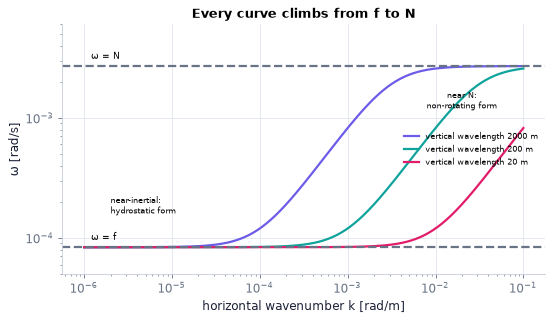

,omega,regime,err_nonrotating,err_hydrostatic,err_midrange
0,2 f,near-inertial,-0.2500,0.0039,-0.2471
1,√(f N),mid,-0.0310,0.0320,0.0000
2,N/2,near-buoyancy,-0.0038,0.3333,0.3282


In [148]:
k_ax = np.geomspace(1e-6, 1e-1, 300)                           # horizontal wavenumbers [rad/m]
fig, ax = plt.subplots(figsize=(6.8, 3.9))   # a new figure and its panel(s); figsize in inches
for m_, col in zip((2*np.pi/2000.0, 2*np.pi/200.0, 2*np.pi/20.0), (COLORS["accent"], COLORS["teal"], COLORS["rose"])):   # three vertical wavelengths
    ax.loglog(k_ax, GFD.inertia_gravity_omega(k_ax, m_, N_o, f35), color=col, label=f"vertical wavelength {2*np.pi/m_:.0f} m")   # Eq. (13.112)
ax.axhline(f35, color=COLORS["muted"], ls="--"); ax.axhline(N_o, color=COLORS["muted"], ls="--")   # the two limits
ax.text(1.2e-6, f35*1.15, "ω = f", fontsize=8); ax.text(1.2e-6, N_o*1.15, "ω = N", fontsize=8)     # their labels
ax.text(2e-6, 1.6e-4, "near-inertial:\nhydrostatic form", fontsize=7); ax.text(2e-2, 1.2e-3, "near N:\nnon-rotating form", fontsize=7, ha="center")   # the regimes
ax.set(xlabel="horizontal wavenumber k [rad/m]", ylabel="ω [rad/s]", title="Every curve climbs from f to N", ylim=(5e-5, 6e-3))   # axis labels (with units), title and fixed ranges of this panel
ax.legend(fontsize=7, loc="center right")   # the legend names every curve
plt.show()   # display the figure
rows = [dict(omega=nm, **{k_: (v_ if isinstance(v_, str) else round(float(v_), 4)) for k_, v_ in GFD.inertia_gravity_regime(w_, N_o, f35).items()})
        for nm, w_ in (("2 f", 2*f35), ("√(f N)", np.sqrt(f35*N_o)), ("N/2", N_o/2))]   # the three approximations at three frequencies
display(pd.DataFrame(rows))                                    # relative error in m^2 of each approximation

**What you see.** Frequency against horizontal wavenumber for three vertical wavelengths, on logarithmic axes; the table gives the relative error in $m^2$ of each approximate relation at three frequencies.

**How to read it.** Long, flat waves sit just above $f$ (rotation matters, buoyancy enters hydrostatically); short, steep ones approach $N$ (rotation is invisible). In the middle of the band, far from both limits, both approximations hold at once.

**What would change if…** …the latitude were lower? Then $f$ falls, the band widens downward and the near-inertial regime moves to longer periods.

> 📎 **Primer — slowly varying medium (WKB): amplitude and phase ansatz, valid when the medium changes little in one wavelength.** `P327` · If the "stiffness" of an oscillator equation $\hat w''+m^2(z)\hat w=0$ changes slowly, the solution still looks locally like a
wave, with a local wavenumber $m(z)$ and a slowly changing amplitude. Write $\hat w=A(z)e^{i\phi(z)}$, and demand that $A$
changes little over one wavelength. It fails where $m\to0$ (a turning point: the wave reflects).

In [149]:
z = np.linspace(0, 50, 5001); m = 1 + 0.02*z                  # the wavenumber doubles over 50 units
phase = np.cumsum(m)*(z[1]-z[0])                              # the phase is the running integral of m
w_wkb = np.cos(phase)/np.sqrt(m)                              # the amplitude falls like m^(-1/2)
print(f"amplitude at the start {w_wkb[0]:.2f}, near the end {np.abs(w_wkb[-200:]).max():.2f}")   # 1.00 and 0.71

amplitude at the start 1.00, near the end 0.71


📝 **Note.** **N111 [B]** **The WKB condition:** $H_Nm\gg1$ (the book writes $Hm\gg1$, with $H$ the scale over which $N$ varies): many vertical
wavelengths fit into the distance over which the stratification changes.

📝 **Note.** **N112 [C]** **Substituting** $\hat w=A(z)e^{i\phi(z)}$ gives $\dfrac{d^2A}{dz^2}+A\Big[m^2-\Big(\dfrac{d\phi}{dz}\Big)^2\Big]=0$ and
$2\dfrac{dA}{dz}\dfrac{d\phi}{dz}+A\dfrac{d^2\phi}{dz^2}=0$ (13.101)–(13.102).

📝 **Note.** **N113 [B]** **The eikonal.** Neglecting $A''$ gives $\dfrac{d\phi}{dz}=\pm m$, $\phi=\pm\displaystyle\int^zm\,dz$ (13.103): the phase gradient is
the local wavenumber.

📝 **Note.** **N114 [B]** **The WKB solution.** The second equation then integrates to $\hat w=\dfrac{A_0}{\sqrt m}\,e^{\pm i\int^zm\,dz}$ (13.104): the
amplitude grows where the wave is long, because the vertical energy flux must be the same at every level. (Stated; the book
prints these steps.)

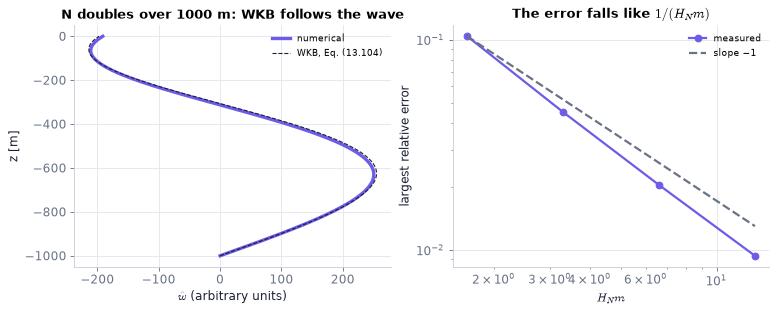

H_N m: [ 1.65  3.3   6.59 13.19] | error: [0.1037 0.0452 0.0203 0.0094] | error x H_N m: [0.171 0.149 0.134 0.123]


In [150]:
k_wk, w_wk = 1.0e-3, 4.0e-4                                    # horizontal wavenumber [rad/m] and frequency [rad/s] of the test wave
fig, (a, b) = plt.subplots(1, 2, figsize=(9.6, 3.8))   # a new figure and its panel(s); figsize in inches
Hm_list, err_list = [], []                                     # collected for the right panel
for D_ in (500.0, 1000.0, 2000.0, 4000.0):                     # four thicknesses of the layer over which N doubles [m]
    N_fn = lambda zz, D_=D_: N_o*(1 + 0.5*zz/D_)               # N rises from N/2 at z = -D to N at z = 0
    z_w = np.linspace(-D_, 0.0, 801)                           # the layer
    we = ch13.wkb_error(z_w, N_fn, k_wk, w_wk, f35)            # largest relative error of the WKB solution, and the value of H_N m
    Hm_list.append(we["Hm"]); err_list.append(we["max_rel_error"])
    if D_ == 1000.0:                                           # show the two solutions for one case
        m_z = np.sqrt(GFD.inertia_gravity_m2(k_wk, 0.0, w_wk, N_fn(z_w), f35))   # local vertical wavenumber, Eq. (13.99)
        w_num = ch13.vertical_structure_solve(z_w, N_fn, k_wk, w_wk, f35)        # numerical solution of Eq. (13.100): w = 0, dw/dz = 1 at the bottom
        w_wkb = GFD.wkb_vertical_structure(z_w, m_z, A0=1/np.sqrt(m_z[0])).imag  # Eq. (13.104), the combination with the same starting values
        a.plot(np.real(w_num), z_w, color=COLORS["accent"], lw=3, label="numerical")
        a.plot(w_wkb, z_w, "--", color=COLORS["ink"], lw=1, label="WKB, Eq. (13.104)")
a.set(xlabel=r"$\hat w$ (arbitrary units)", ylabel="z [m]", title="N doubles over 1000 m: WKB follows the wave")   # axis labels (with units), title and fixed ranges of this panel
a.legend(fontsize=8)   # the legend names every curve
b.loglog(Hm_list, err_list, "o-", color=COLORS["accent"], label="measured")   # error against H_N m
b.loglog(Hm_list, err_list[0]*Hm_list[0]/np.array(Hm_list), "--", color=COLORS["muted"], label="slope −1")   # a guide proportional to 1/(H_N m)
b.set(xlabel=r"$H_Nm$", ylabel="largest relative error", title="The error falls like $1/(H_Nm)$")   # axis labels (with units), title and fixed ranges of this panel
b.legend(fontsize=8)   # the legend names every curve
plt.show()   # display the figure
print("H_N m:", np.round(Hm_list, 2), "| error:", np.round(err_list, 4), "| error x H_N m:", np.round(np.array(err_list)*np.array(Hm_list), 3))   # measured

**What you see.** Left: the vertical structure of a wave in a layer whose $N$ doubles from bottom to top — numerical solution (purple) and WKB formula (dashed). Right: the largest relative error of the WKB formula against $H_Nm$.

**How to read it.** The wave is shorter and smaller where $N$ is larger, exactly as $A_0/\sqrt m$ says. The error is inversely proportional to $H_Nm$ (the points follow the slope −1 guide; the printed product is roughly constant) — not to its square.

**What would change if…** …the frequency approached the local $N$ somewhere? Then $m\to0$ there, the WKB formula blows up and the wave reflects (a turning point).

📝 **Note.** **N115 [C]** **The velocity field** (stated): continuity for $l=0$, $ik\hat u+\dfrac{d\hat w}{dz}=0$ (13.105).

📝 **Note.** **N116 [C]** $\hat u=\mp\dfrac{A_0\sqrt m}{k}e^{\pm i\int^zm\,dz}$ (13.106). ⚠️ Trap T15: $\sqrt m$ is treated as constant when $\hat w$ is
differentiated.

📝 **Note.** **N117 [C]** $\hat v=\pm\dfrac{if}{\omega}\dfrac{A_0\sqrt m}{k}e^{\pm i\int^zm\,dz}$ (13.107), from $\hat u/\hat v=i\omega/f$.

📝 **Note.** **N118 [B]** **The real fields:** $u=\mp\dfrac{A_0\sqrt m}{k}\cos\Big(kx\pm\displaystyle\int^zm\,dz-\omega t\Big)$,
$v=\mp\dfrac{A_0f\sqrt m}{\omega k}\sin\Big(kx\pm\displaystyle\int^zm\,dz-\omega t\Big)$,
$w=\dfrac{A_0}{\sqrt m}\cos\Big(kx\pm\displaystyle\int^zm\,dz-\omega t\Big)$ (13.108), upper signs for upward phase propagation
(`GFD.inertia_gravity_fields`).

📝 **Note.** **N120 [B]** **The horizontal hodograph at a point:** $u=\mp\cos\omega t$, $v=\pm\dfrac f\omega\sin\omega t$ (13.110): a clockwise ellipse in the
northern hemisphere ($f>0$; counter-clockwise for $f<0$), long axis along the direction of propagation, axis ratio $f/\omega$
(trap T7: the same ellipse as the $\omega/f$ of `C10`, quoted the other way up).

📝 **Note.** **N121 [B]** **The motion lies along the phase lines:** $\dfrac uw=\mp\dfrac mk=\mp\tan\theta$ (13.111), with $\theta=\tan^{-1}(m/k)$ the angle of
the wavevector with the horizontal (**not** latitude — trap T13).

In [151]:
N_uni = lambda zz: N_o + 0*zz                                  # uniform stratification, as a function of z
m_uni = np.sqrt(GFD.inertia_gravity_m2(k_w, 0.0, w_ig, N_o, f35))   # the vertical wavenumber that belongs to (k_w, w_ig): 2 pi/200 m
x_g, z_g = np.linspace(0.0, 1.0e4, 5), np.linspace(-200.0, 0.0, 5)  # a small grid: one horizontal and one vertical wavelength
u_g, v_g, w_g = GFD.inertia_gravity_fields(x_g, z_g, 0.0, k_w, w_ig, N_uni, f35)   # Eq. (13.108), upward phase propagation
u_h, v_h = GFD.inertia_gravity_hodograph(np.linspace(0, 2*np.pi/w_ig, 5), w_ig, f35)   # Eq. (13.110) over one period
print(f"k u + m w (motion along the crests) = {abs(k_w*u_g + m_uni*w_g).max()/abs(k_w*u_g).max():.1e} of k u")   # Eq. (13.111): zero
print(f"amplitude ratio |v|/|u| = {abs(v_g).max()/abs(u_g).max():.3f} = f/omega = {f35/w_ig:.3f}; hodograph points (u, v): {np.round(u_h, 2)}, {np.round(v_h, 2)}")   # the ellipse

k u + m w (motion along the crests) = 1.6e-16 of k u
amplitude ratio |v|/|u| = 0.840 = f/omega = 0.840; hodograph points (u, v): [-1. -0.  1.  0. -1.], [ 0.    0.84  0.   -0.84 -0.  ]


**What does this show?** On a small grid in a uniformly stratified layer: the velocity is perpendicular to the wavevector
($ku+mw=0$, i.e. the water moves along the crests), and the cross-wave current is $f/\omega$ times the along-wave one.

📝 **Note.** **N122 [B]** **The hodograph in both hemispheres** (our version of the book's sketches, `ch13.fig_inertia_gravity_orbit`): the horizontal
velocity at a fixed point over one wave period, for $f>0$ and for $f<0$. (That the water also moves along the sloping crests,
and that phase and group velocity are at right angles, is the content of note N121 and of derivation `D21` above.)

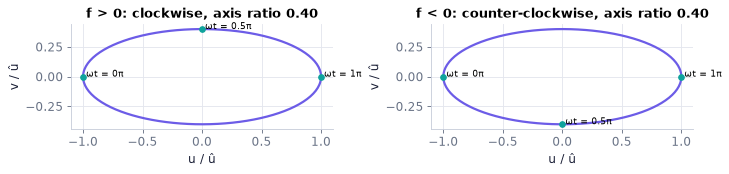

In [152]:
figO = ch13.fig_inertia_gravity_orbit()                        # two horizontal velocity hodographs: f > 0 and f < 0, for omega = 2.5 |f|
plt.show()   # display the figure

**What you see.** Two ellipses: the tip of the horizontal velocity vector $(u, v)$, in units of the amplitude of $u$, over one period — left for $f>0$, right for $f<0$. Dots mark the phases $\omega t=0$, $\pi/2$ and $\pi$.

**How to read it.** Follow the dots from $\omega t=0$ to $\pi/2$ to $\pi$: on the left the vector passes through positive $v$ on its way from $-u$ to $+u$, which is clockwise; on the right it passes through negative $v$, counter-clockwise. The long axis is along the direction of propagation and the axis ratio is $f/\omega=0.40$ here ($\omega=2.5\lvert f\rvert$).

**What would change if…** …$\omega$ approached $\lvert f\rvert$? The axis ratio tends to 1 and the ellipse becomes the inertial circle of `C10`.

In [153]:
z_hx = np.linspace(-400.0, 0.0, 161)                           # two vertical wavelengths of the 200 m wave [m]
figH = go.Figure()
for j, (sg, nm) in enumerate(((+1, "upward phase (energy downward)"), (-1, "downward phase (energy upward)"))):   # the two signs of Eq. (13.108)
    uh_, vh_, _ = GFD.inertia_gravity_fields(np.array([0.0]), z_hx, 0.0, k_w, w_ig, N_uni, f35, sign=sg)   # velocity at x = 0, t = 0, against depth
    scale = abs(uh_).max()                                     # normalise by the largest u
    figH.add_trace(go.Scatter3d(x=uh_[:, 0]/scale, y=vh_[:, 0]/scale, z=z_hx, mode="lines", line=dict(color=COLORS["accent"], width=6), name=nm, visible=(j == 0)))   # the helix
figH.update_layout(height=520, title="The current vector turns with depth: a helix (35° N)",
                   updatemenus=[dict(x=0.0, y=1.08, xanchor="left", buttons=[
                       dict(label="upward phase propagation", method="update", args=[{"visible": [True, False]}]),
                       dict(label="downward phase propagation", method="update", args=[{"visible": [False, True]}])])],
                   scene=dict(xaxis_title="u (normalised)", yaxis_title="v (normalised)", zaxis_title="z [m]"), margin=dict(l=0, r=0, t=60, b=0))   # axes and dropdown
figH.show()   # display the interactive figure (the slider works on the web page too)

**What does the code above do?**

The horizontal velocity at one place and time, plotted against depth: its tip traces a helix. The dropdown switches between
the two signs of the vertical wavenumber.

**What you see.** The tip of the horizontal current vector at successive depths: a flattened helix (an ellipse of axis ratio $f/\omega$ seen from above).

**How to read it.** Looking down from above in the northern hemisphere, the vector turns clockwise with increasing depth when the phase moves upward (energy going down) and counter-clockwise when it moves downward — the test oceanographers use to tell which way near-inertial energy is travelling.

**What would change if…** …$f<0$? Both senses reverse.

📝 **Note.** **N125 [B]** **Lee waves.** With $f$ negligible, $\omega^2=\dfrac{N^2k^2}{m^2+k^2}$ (13.113). A wave that stands still over the ground has its
frequency Doppler-shifted to zero, $\omega_0=\omega+\mathbf K\cdot\mathbf U=0$ (Chapter 7's $\omega_0=\omega+\mathbf U\cdot\mathbf K$ (7.9)), so
$\omega=kU$ and $U=\dfrac{N}{\sqrt{k^2+m^2}}$: only waves with $k<N/U$ exist. (Trap T15: $k$ here is a magnitude; the wavevector
points upstream.)

In [154]:
U_m, N_a = inp["U_mean"], inp["atm_N"]                         # a 17 m/s wind over a mountain; atmospheric N = 1.1e-2 1/s (our inputs)
m_lee = GFD.lee_wave_m(U_m, N_a, 2*np.pi/2.0e4)                # vertical wavenumber of a stationary wave 20 km long [1/m]
print(f"shortest stationary wavelength 2 pi U/N = {2*np.pi*U_m/N_a/1e3:.2f} km; a 20 km wave has m = {m_lee:.2e} 1/m (vertical wavelength {2*np.pi/m_lee/1e3:.1f} km)")   # the cut-off and one wave
try:                                                           # a 5 km wave is shorter than the cut-off
    GFD.lee_wave_m(U_m, N_a, 2*np.pi/5.0e3)
except ValueError as err:                                      # the function refuses
    print("a 5 km wave ->", err)

shortest stationary wavelength 2 pi U/N = 9.71 km; a 20 km wave has m = 5.66e-04 1/m (vertical wavelength 11.1 km)
a 5 km wave -> evanescent: k > N/U


**What does this show?** In a 17 m/s wind with $N=1.1\times10^{-2}$ s⁻¹ no stationary wave shorter than about 10 km exists; a
20 km wave has a vertical wavelength of about 11 km; asking for a 5 km wave raises an error ("evanescent").

📝 **Note.** **N126 [B]** **The lee-wave pattern** (our version of the book's sketch, `ch13.lee_wave_field`): streamlines over sinusoidal terrain 300 m
high.

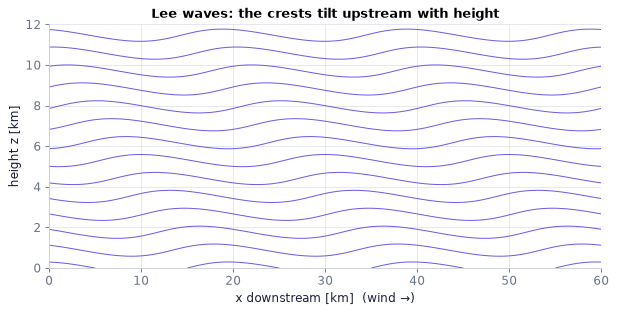

In [155]:
x_l = np.linspace(0.0, 6.0e4, 201); z_l = np.linspace(0.0, 1.2e4, 101)   # three wavelengths downstream, 12 km up [m]
lw = ch13.lee_wave_field(x_l, z_l, U_m, N_a, 2*np.pi/2.0e4, 300.0)        # stream function of wind + stationary wave (ours)
fig, ax = plt.subplots(figsize=(7.6, 3.8))   # a new figure and its panel(s); figsize in inches
ax.contour(x_l/1e3, z_l/1e3, lw["psi"], 16, colors=COLORS["accent"], linewidths=0.9)   # streamlines
ax.plot([0, 2*np.pi/lw["m"]/1e3*0 + 5.0], [0, 0], alpha=0)     # (keeps the axes starting at the ground)
ax.set(xlabel="x downstream [km]  (wind →)", ylabel="height z [km]", title=f"Lee waves: the crests tilt {lw['tilt']} with height")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure

**What you see.** Streamlines of a 17 m/s wind over wavy terrain: each streamline is a copy of the terrain, shifted in phase more and more with height.

**How to read it.** Join the crests of successive streamlines: the line leans upstream (to the left) with height. That tilt is what a wave with downward phase velocity and **upward** energy flux looks like — the mountain is the source.

**What would change if…** …the wind were stronger, so that $N/U<k$? The disturbance would decay with height instead of tilting: no wave, no upward energy flux.

**What would change if…** …the frequency is far below $f$? Then none of these waves is possible — but the slow root of the cubic of `C09` is. It needs
$\beta$ (`C15`).

---

## 13.15 Rossby Wave

**What is this section about?** The slow wave that owes its existence to the change of the Coriolis parameter with latitude.
Its crests always drift west; its energy can go either way.

### 🧩 Rossby waves: $\omega=-\dfrac{\beta k}{k^2+l^2+f_0^2/c^2}$ (13.118) `C15`

*The question:* The crests go west — so how can a storm track's energy go east, and how long does the ocean take to hear about a change in the wind?

#### The problem in plain words

The jet stream meanders in four or five great waves round the hemisphere; when one of them stalls, a region gets weeks of the
same weather. In the ocean, a change of wind in the east Pacific is felt in the west a year later at low latitudes, a decade
later at mid-latitudes. Both are Rossby waves. They are not held up by gravity like the waves of `C10` but by the conservation
of potential vorticity on a planet where $f$ grows toward the pole.

#### The idea

```
north ↑        ↻ (pushed north: f larger, so ζ must fall → clockwise spin)
─ ─ ─ ─ ─ ● ─ ─ ─ ─ ─ ─ ● ─ ─ ─ ─ ─   a line of columns along a latitude circle
                         ↺ (pushed south: f smaller, so ζ must rise → counter-clockwise spin)

between them the two spins push fluid NORTH on the western side of the northern bulge
and SOUTH on its eastern side  →  the whole pattern shifts WEST
```

This is the conservation law of `C13` in motion: a column displaced north or south must change its relative spin, and the
induced flow moves the displacement pattern westward (northern hemisphere shown; the direction is westward in both).

📝 **Note.** **N127 [B]** **Planetary waves.** Rossby waves exist only because of $\beta$, at $\omega\ll f$. The motion is *quasi-geostrophic*:
geostrophic to lowest order, with its slow evolution set by the small departures from geostrophy. (The book's observed height
map is replaced here by a synthetic wavenumber-5 field with its geostrophic wind.)

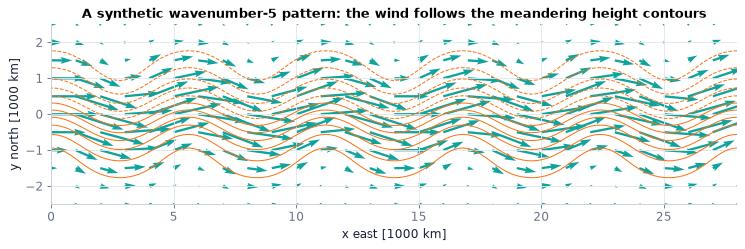

In [156]:
xr = np.linspace(0.0, 2.8e7, 141); yr = np.linspace(-2.5e6, 2.5e6, 41)   # once round the 35 N latitude circle (about 28 000 km), 5000 km in y [m]
Xr, Yr = np.meshgrid(xr, yr)                                   # grids indexed [j, i] = (y, x)
eta_r = -300.0*np.tanh(Yr/1.2e6) + 80.0*np.cos(2*np.pi*5*Xr/2.8e7)*np.exp(-(Yr/1.5e6)**2)   # a height field: low toward the pole plus five waves [m]
u_r, v_r = GFD.geostrophic_from_height(eta_r, xr[1] - xr[0], yr[1] - yr[0], f35)   # its geostrophic wind, Eq. (13.116)
fig, ax = plt.subplots(figsize=(9.2, 3.0))   # a new figure and its panel(s); figsize in inches
ax.contour(xr/1e6, yr/1e6, eta_r, 12, colors=COLORS["orange"], linewidths=0.9)   # height contours (orange = pressure)
ax.quiver(xr[::5]/1e6, yr[::4]/1e6, u_r[::4, ::5], v_r[::4, ::5], color=COLORS["teal"])   # the wind
ax.set(xlabel="x east [1000 km]", ylabel="y north [1000 km]", title="A synthetic wavenumber-5 pattern: the wind follows the meandering height contours")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure

**What you see.** A synthetic height field (orange contours; dashed where the height is below average, toward the pole) with five waves round a latitude circle, and its geostrophic wind (teal arrows, strongest where the contours are closest).

**How to read it.** The westerly jet meanders: poleward on one side of each trough, equatorward on the other. A column riding this flow is carried north and south — and must change its spin as it goes. That is the restoring mechanism of the wave.

**What would change if…** …there were only two or three waves round the circle? They would be longer, and — as the dispersion relation shows — drift westward faster relative to the air.

> 📎 **Primer — ordering in a small parameter: lowest order gives the balance, next order gives the evolution.** `P328` · When a small number $\varepsilon$ (here the Rossby number, or $\omega/f$) multiplies some terms, sort every term by how many
factors of $\varepsilon$ it carries. The largest terms must balance among themselves — that gives a *diagnostic* relation with
no time derivative (geostrophy). To learn how things change you must go to the next size of terms. So the small terms cannot
all be thrown away: the right ones decide the future.

In [157]:
eps = 0.1                              # a small parameter, e.g. the Rossby number
print(1.0, eps, eps**2)                # sizes of: Coriolis and pressure | acceleration and the divergent wind | products of wave amplitudes

1.0 0.1 0.010000000000000002


> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **completing the square into a circle** — $k^2+ak+l^2=b$ is $(k+a/2)^2+l^2=b+a^2/4$: a circle centred at $(-a/2,0)$. *(Ch. 11, P272)*
- **Fourier modes** — any periodic field is a sum of waves $e^{ikx}$; a linear constant-coefficient equation evolves each one on its own. *(Ch. 5, P142)*
- **Rayleigh equation with β; normal modes with complex c** — perturb a steady flow, drop products of small quantities, try $e^{ik(x-ct)}$: the flow is unstable if some mode has $c_i=\mathrm{Im}\,c>0$, because it then grows like $e^{kc_it}$. *(Ch. 9, P214)*
- **real and imaginary parts of a complex equation** — a complex equation is two real ones: its real part and its imaginary part must each hold. *(Ch. 11, P260)*

#### 🧮 Derivation — The quasi-geostrophic vorticity equation from potential-vorticity conservation `D22` ★★★ (Eq. 13.117: $\frac{\partial}{\partial t}\Big(\frac{\partial^2\eta}{\partial x^2}+\frac{\partial^2\eta}{\partial y^2}-\frac{f_0^2}{c^2}\eta\Big)+\beta\frac{\partial\eta}{\partial x}=0$)

**What we want to show.** Obtain one linear equation for the surface height of slow, nearly geostrophic motion on a β-plane — the equation whose waves are Rossby waves.

**Assumptions.** Small amplitude (steps 2–4); Ro ≪ 1 and ω ≪ f (step 5); βy ≪ f₀; flat bottom.

**The plan.**

1. Expand the conservation law.
2. Keep the terms with one small factor.
3. Replace the velocities by their geostrophic values — except inside the term that came from the divergence.
4. Tidy up.

**Tools we use** (each explained before this point): quotient rule (P265, reminder) · ordering in a small parameter (P328) · the geostrophic wind from a surface height (C02, C07)

**We start from**

$$ \dfrac{D}{Dt}\Big(\dfrac{\zeta+f}{h}\Big)=0\ \text{,}\ f=f_0+\beta y\ \text{(13.94), with a flat bottom so that}\ h=H+\eta $$

*In words:* Potential vorticity is conserved; depth = mean depth + surface displacement

---

**Step 1 of 10 — Expand the conservation law.**

$$ \begin{array}{l}(H+\eta)\Big(\dfrac{\partial\zeta}{\partial t}+u\dfrac{\partial\zeta}{\partial x}+v\dfrac{\partial\zeta}{\partial y}+\beta v\Big)-(\zeta+f_0)\Big(\dfrac{\partial\eta}{\partial t}+u\dfrac{\partial\eta}{\partial x}+v\dfrac{\partial\eta}{\partial y}\Big)=0 \\ \text{(13.114)}\end{array} $$

- *Why we can do this:* Quotient rule, then multiply by h²: $h\,D(\zeta+f)/Dt-(\zeta+f)\,Dh/Dt=0$; with $Df/Dt=\beta v$, $Dh/Dt=D\eta/Dt$, and f → f₀ in the coefficient.
- *In words:* Stretching and northward motion both change a column's vorticity.

---

**Step 2 of 10 — Mark the small quantities.**

$$ \zeta,\ \eta,\ u,\ v=O(\varepsilon);\qquad H,\ f_0,\ \beta=O(1) $$

- *Why we can do this:* A wave of small amplitude: every wave field carries one factor of a small number ε; the background does not.
- *In words:* Sorting terms by size.

---

**Step 3 of 10 — Identify the products of two small quantities.**

$$ \eta\dfrac{\partial\zeta}{\partial t},\ u\dfrac{\partial\zeta}{\partial x},\ v\dfrac{\partial\zeta}{\partial y},\ \eta\beta v,\ \zeta\dfrac{\partial\eta}{\partial t},\ u\dfrac{\partial\eta}{\partial x},\ v\dfrac{\partial\eta}{\partial y}=O(\varepsilon^2) $$

- *Why we can do this:* Each contains two wave fields, so it is smaller than the others by a factor ε and may be neglected.
- *In words:* These are the nonlinear terms.

---

**Step 4 of 10 — Keep the terms of first order.**

$$ H\dfrac{\partial\zeta}{\partial t}+H\beta v-f_0\dfrac{\partial\eta}{\partial t}=0\ \text{(13.115)} $$

- *Why we can do this:* What remains of step 1 after removing the terms of step 3.
- *In words:* Vorticity changes by northward motion (βv) and by stretching of the column (f₀ ∂η/∂t).

---

**Step 5 of 10 — Use geostrophic velocities.**

$$ u\simeq-\dfrac g{f_0}\dfrac{\partial\eta}{\partial y},\qquad v\simeq\dfrac g{f_0}\dfrac{\partial\eta}{\partial x}\ \text{(13.116)} $$

- *Why we can do this:* For ω ≪ f the momentum equations of D10's Result reduce to geostrophic balance with pressure gρη (≃ marks the approximation).
- *In words:* To lowest order the flow follows the height contours.

---

**Step 6 of 10 — Compute the vorticity.**

$$ \zeta=\dfrac{\partial v}{\partial x}-\dfrac{\partial u}{\partial y}=\dfrac g{f_0}\Big(\dfrac{\partial^2\eta}{\partial x^2}+\dfrac{\partial^2\eta}{\partial y^2}\Big) $$

- *Why we can do this:* Differentiate step 5; g and f₀ are constants.
- *In words:* A hill in the surface is a clockwise vortex (f > 0), a hollow a counter-clockwise one.

---

**Step 7 of 10 — Substitute into step 4.**

$$ \dfrac{gH}{f_0}\dfrac{\partial}{\partial t}\Big(\dfrac{\partial^2\eta}{\partial x^2}+\dfrac{\partial^2\eta}{\partial y^2}\Big)+\dfrac{gH\beta}{f_0}\dfrac{\partial\eta}{\partial x}-f_0\dfrac{\partial\eta}{\partial t}=0 $$

- *Why we can do this:* Steps 5 and 6 replace ζ and v. The term $f_0\,\partial\eta/\partial t$ is kept: it came from the divergence, which geostrophic velocities alone would give as zero.
- *In words:* One equation with η as the only unknown.

---

**Step 8 of 10 — Multiply by f₀/(gH).**

$$ \dfrac{\partial}{\partial t}\Big(\dfrac{\partial^2\eta}{\partial x^2}+\dfrac{\partial^2\eta}{\partial y^2}\Big)+\beta\dfrac{\partial\eta}{\partial x}-\dfrac{f_0^2}{gH}\dfrac{\partial\eta}{\partial t}=0 $$

- *Why we can do this:* A constant factor; it makes the coefficient of the first term one.
- *In words:* The stretching term now carries f₀²/(gH).

---

**Step 9 of 10 — Introduce the wave speed.**

$$ \dfrac{f_0^2}{gH}=\dfrac{f_0^2}{c^2}=\dfrac1{\Lambda^2},\qquad c=\sqrt{gH} $$

- *Why we can do this:* Here $c=\sqrt{gH}$ is the long-wave speed (D10); the ratio c/f₀ is the Rossby radius of C12.
- *In words:* The Rossby radius enters as the scale at which stretching matters as much as relative vorticity.

---

**Step 10 of 10 — Collect the time derivatives.**

$$ \dfrac{\partial}{\partial t}\Big(\dfrac{\partial^2\eta}{\partial x^2}+\dfrac{\partial^2\eta}{\partial y^2}-\dfrac{f_0^2}{c^2}\eta\Big)+\beta\dfrac{\partial\eta}{\partial x}=0\ \text{(13.117)} $$

- *Why we can do this:* Both the first and the last term of step 8 are time derivatives.
- *In words:* The bracket — relative vorticity minus stretching — can change only by the β-effect.

---

**Result**

$$ \dfrac{\partial}{\partial t}\Big(\dfrac{\partial^2\eta}{\partial x^2}+\dfrac{\partial^2\eta}{\partial y^2}-\dfrac{f_0^2}{c^2}\eta\Big)+\beta\dfrac{\partial\eta}{\partial x}=0\ \text{,}\ c=\sqrt{gH} $$

*In words:* The quasi-geostrophic form of the linearised potential-vorticity equation

**What it means.** "quasi-geostrophic" = geostrophic velocities everywhere *except* in the divergence, whose small ageostrophic part is what makes the flow evolve; the fast gravity waves have been filtered out (one time derivative instead of three). **Fails when:** the amplitude is large (keep the advection of the bracket by the geostrophic flow — the nonlinear quasi-geostrophic equation, beyond the book), near the equator, or over steep topography.

**Check it.** Units — every term is 1/(m s) ✓. Limits — β = 0: the bracket is steady (the adjusted state of D16, where it equalled its initial value); c → ∞ (rigid lid): the barotropic vorticity equation. Plane wave — it gives the dispersion relation of D23.

In [158]:
import sympy as sp                                            # symbolic algebra
x, y, t = sp.symbols("x y t", real=True)                      # east, north, time
g, H, f0, beta = sp.symbols("g H f_0 beta", positive=True)    # gravity, mean depth, f0, beta
eps = sp.symbols("epsilon")                                   # step 2: marks every small (wave) quantity
eta = sp.Function("eta")(x, y, t)                             # surface displacement
u = sp.Function("u")(x, y, t)                                 # velocities (not yet geostrophic)
v = sp.Function("v")(x, y, t)
zeta = sp.diff(v, x) - sp.diff(u, y)                          # relative vorticity
D = lambda F: sp.diff(F, t) + eps * u * sp.diff(F, x) + eps * v * sp.diff(F, y)   # D/Dt, u and v are small
full = (H + eps * eta) * (D(eps * zeta) + beta * eps * v) - (eps * zeta + f0) * D(eps * eta)   # step 1: (13.114)
lin = sp.expand(full).coeff(eps, 1)                           # steps 3-4: keep the terms with one small factor
assert sp.expand(lin - (H * sp.diff(zeta, t) + H * beta * v - f0 * sp.diff(eta, t))) == 0   # (13.115)
ug = -g / f0 * sp.diff(eta, y)                                # step 5: geostrophic u, (13.116a)
vg = g / f0 * sp.diff(eta, x)                                 # step 5: geostrophic v, (13.116b)
zg = sp.diff(vg, x) - sp.diff(ug, y)                          # step 6: geostrophic vorticity
assert sp.simplify(zg - g / f0 * (sp.diff(eta, x, 2) + sp.diff(eta, y, 2))) == 0
qg = H * sp.diff(zg, t) + H * beta * vg - f0 * sp.diff(eta, t)   # step 7: substitute into (13.115)
c2 = g * H                                                    # step 9: c^2 = gH
book = sp.diff(sp.diff(eta, x, 2) + sp.diff(eta, y, 2) - f0**2 / c2 * eta, t) + beta * sp.diff(eta, x)   # (13.117)
assert sp.simplify(sp.expand(qg * f0 / (g * H) - book)) == 0  # steps 8-10: multiply by f0/(gH)
k, l, w = sp.symbols("k l omega", real=True)                  # D23 step 1: a plane wave
wave = sp.exp(sp.I * (k * x + l * y - w * t))
disp = sp.simplify(book.subs(eta, wave).doit() / wave)        # what the wave must satisfy
sol = sp.solve(disp, w)[0]                                    # solve for the frequency
assert sp.simplify(sol + beta * k / (k**2 + l**2 + f0**2 / c2)) == 0   # (13.118)
print("D22 checks passed: (13.115), (13.117) and the dispersion relation (13.118)")

D22 checks passed: (13.115), (13.117) and the dispersion relation (13.118)


> ⚠️ **Common confusion (traps in `D22`):** Which products are dropped; the geostrophic velocity may be used everywhere except in the divergence, which is why the stretching term survives; f → f₀ except in β; a flat bottom is assumed.

📝 **Note.** **N128 [B]** **Potential-vorticity conservation expanded** (step 1 of `D22`):
$(H+\eta)\Big(\dfrac{\partial\zeta}{\partial t}+u\dfrac{\partial\zeta}{\partial x}+v\dfrac{\partial\zeta}{\partial y}+\beta v\Big)-(\zeta+f_0)\Big(\dfrac{\partial\eta}{\partial t}+u\dfrac{\partial\eta}{\partial x}+v\dfrac{\partial\eta}{\partial y}\Big)=0$ (13.114).

📝 **Note.** **N129 [B]** **Linearised** (step 4): $H\dfrac{\partial\zeta}{\partial t}+H\beta v-f_0\dfrac{\partial\eta}{\partial t}=0$ (13.115).

📝 **Note.** **N130 [B]** **Geostrophic velocities** (steps 5–6): $u\simeq-\dfrac g{f_0}\dfrac{\partial\eta}{\partial y}$, $v\simeq\dfrac g{f_0}\dfrac{\partial\eta}{\partial x}$ (13.116),
hence $\zeta=\dfrac g{f_0}\Big(\dfrac{\partial^2\eta}{\partial x^2}+\dfrac{\partial^2\eta}{\partial y^2}\Big)$.

📝 **Note.** **N131 [B]** **The quasi-geostrophic vorticity equation** (the result):
$\dfrac{\partial}{\partial t}\Big(\dfrac{\partial^2\eta}{\partial x^2}+\dfrac{\partial^2\eta}{\partial y^2}-\dfrac{f_0^2}{c^2}\eta\Big)+\beta\dfrac{\partial\eta}{\partial x}=0$, $c=\sqrt{gH}$ (13.117).

In [159]:
print("the quasi-geostrophic vorticity equation (13.117) follows from (13.94) ->", ch13.qg_vorticity_sympy()["ok"])   # the engine agrees: True

the quasi-geostrophic vorticity equation (13.117) follows from (13.94) -> True


**What does this show?** The engine repeats `D22` symbolically: expand, linearise, insert the geostrophic velocities.

#### 🧮 Derivation — Rossby-wave dispersion, phase speed, circles, group velocity, the mean-current form `D23` ★★ (Eq. 13.118: $\omega=-\frac{\beta k}{k^2+l^2+f_0^2/c^2}$)

**What we want to show.** Find the frequency of a Rossby wave and from it where its crests and its energy go.

**Assumptions.** As D22; uniform mean current in step 9. Shorthand: $F\equiv f_0^2/c^2=1/\Lambda^2$.

**The plan.**

1. Substitute.
2. Read the phase speed.
3. Rewrite as a circle in the wavenumber plane.
4. Differentiate for the group velocity.
5. Find where it changes sign.
6. Add a mean current.

**Tools we use** (each explained before this point): plane-wave substitution (P176) · completing the square into a circle (P272, reminder) · group velocity as a gradient (P326) · quotient rule (P265) · Doppler shift (Ch. 7, reminder)

**We start from**

$$ \begin{array}{l}\dfrac{\partial}{\partial t}\Big(\dfrac{\partial^2\eta}{\partial x^2}+\dfrac{\partial^2\eta}{\partial y^2}-\dfrac{f_0^2}{c^2}\eta\Big)+\beta\dfrac{\partial\eta}{\partial x}=0\ \text{(13.117) and} \\ \eta=\hat\eta\,e^{i(kx+ly-\omega t)}\end{array} $$

*In words:* The Result of D22 and a plane wave

---

**Step 1 of 9 — Substitute the plane wave.**

$$ \omega=-\dfrac{\beta k}{k^2+l^2+f_0^2/c^2}\ \text{(13.118)} $$

- *Why we can do this:* ∂/∂t → −iω, ∂/∂x → ik, ∂/∂y → il give $-i\omega\,(-k^2-l^2-F)+i\beta k=0$; divide by i and solve for ω.
- *In words:* The frequency is proportional to β and depends on the direction of the wavevector, not only on its length.

---

**Step 2 of 9 — Fix the sign convention.**

$$ \omega>0\ \Rightarrow\ k<0 $$

- *Why we can do this:* The denominator is positive and β > 0, so ω and k have opposite signs; the book takes ω positive, the code returns a signed ω for a signed k.
- *In words:* With positive frequency the wavevector always has a westward component.

---

**Step 3 of 9 — Form the zonal phase speed.**

$$ c_x=\dfrac\omega k=-\dfrac{\beta}{k^2+l^2+f_0^2/c^2}\ \text{(13.119)} $$

- *Why we can do this:* The phase of the wave is constant along x = (ω/k)t. The right side is negative for every k and l.
- *In words:* The crests of every Rossby wave drift westward.

---

**Step 4 of 9 — Rearrange into a circle.**

$$ \Big(k+\dfrac{\beta}{2\omega}\Big)^2+l^2=\Big(\dfrac{\beta}{2\omega}\Big)^2-\dfrac{f_0^2}{c^2} $$

- *Why we can do this:* Multiply step 1 by the denominator and divide by ω: $k^2+(\beta/\omega)k+l^2=-F$; complete the square in k.
- *In words:* All waves of one frequency lie on a circle centred on the negative k-axis.

---

**Step 5 of 9 — Differentiate with respect to k.**

$$ c_{gx}=\dfrac{\partial\omega}{\partial k}=\dfrac{\beta\,(k^2-l^2-F)}{(k^2+l^2+F)^2} $$

- *Why we can do this:* Quotient rule on step 1: $-\beta[(k^2+l^2+F)-2k^2]/(\ldots)^2$.
- *In words:* The eastward speed of the energy: its sign depends on the wavelength.

---

**Step 6 of 9 — Differentiate with respect to l.**

$$ c_{gy}=\dfrac{\partial\omega}{\partial l}=\dfrac{2\beta kl}{(k^2+l^2+F)^2} $$

- *Why we can do this:* Only the denominator depends on l; the gradient $(c_{gx},c_{gy})$ of ω is at right angles to the circles of step 4 and points to their centres.
- *In words:* Energy also moves north or south unless l = 0.

---

**Step 7 of 9 — Find where the zonal group velocity vanishes.**

$$ l=0:\quad c_{gx}=0\ \text{at}\ k=-\dfrac{f_0}{c},\qquad\omega_{max}=\dfrac{\beta c}{2f_0} $$

- *Why we can do this:* Set k² = F in step 5 (the negative root, by step 2) and insert into step 1. A zero slope of ω(k) is a maximum of ω.
- *In words:* No Rossby wave of this mode has a higher frequency; at this wavelength, 2πΛ, energy stands still.

---

**Step 8 of 9 — Read the two sides of the maximum.**

$$ k^2<F:\ c_{gx}<0;\qquad k^2>F:\ c_{gx}>0;\qquad k^2\ll F:\ c_x\simeq c_{gx}\simeq-\dfrac{\beta c^2}{f_0^2} $$

- *Why we can do this:* The sign of step 5's numerator for l = 0; for very long waves both speeds tend to the same constant −βΛ² (no dispersion).
- *In words:* Long waves carry energy west, short waves east.

---

**Step 9 of 9 — Add a uniform eastward current U.**

$$ c_x=U-\dfrac{\beta}{k^2+l^2+f_0^2/c^2}\ \text{(13.120);}\ c_x=0\ \Rightarrow\ \lambda=2\pi\sqrt{U/\beta} $$

- *Why we can do this:* Seen from the ground the frequency is ω + Uk (Chapter 7's $\omega_0=\omega+\mathbf U\cdot\mathbf K$ (7.9)), so the phase speed shifts by U; the wavelength is for F = 0, l = 0.
- *In words:* A westerly flow can hold a Rossby wave still.

---

**Result**

$$ \omega=-\dfrac{\beta k}{k^2+l^2+f_0^2/c^2}\ \text{;}\ c_x=\dfrac\omega k<0\ \text{always; (ours)}\ c_{gx}=\dfrac{\beta(k^2-l^2-f_0^2/c^2)}{(k^2+l^2+f_0^2/c^2)^2}\ \text{,}\ c_{gy}=\dfrac{2\beta kl}{(k^2+l^2+f_0^2/c^2)^2} $$

*In words:* Phase always west; energy west for waves longer than 2πΛ, east for shorter ones

**What it means.** The ocean adjusts to a change of wind by long Rossby waves crossing it westward (years at mid-latitudes, months in the tropics); atmospheric wave trains spread *downstream*, eastward; mountains anchor stationary waves in the westerlies. **Fails when:** within a few degrees of the equator; in strongly sheared currents (D24); for amplitudes large enough to advect themselves.

**Check it.** Units — β/k² = (1/(m s))·m² = m/s ✓. Limits — c → ∞: ω = −βk/K², and $c_{gx}=\beta(k^2-l^2)/K^4$; long-wave limit −βΛ². Numbers (first baroclinic mode, 35° N, Λ = 43.15 km) — 150 km wave: c_x = −0.82 cm/s, c_gx = +0.43 cm/s; 1000 km wave: −3.25 and −2.81 cm/s; ω_max = 4.05 × 10⁻⁷ s⁻¹ (180 days). Stationary wave — U = 17 m/s, 35° N: 5983 km. Code — complex-step derivatives of `GFD.rossby_omega`.

> ⚠️ **Common confusion (traps in `D23`):** With ω > 0 the zonal wavenumber is negative (trap T8); the "maximum" phase speed is a maximum of magnitude; the group-velocity arrows on the circles point inward; slip #12 — a round β and β at a stated latitude give speeds a fifth apart.

📝 **Note.** **N134 [B]** **The zonal phase speed** (step 3 of `D23`): $c_x=\dfrac\omega k=-\dfrac{\beta}{k^2+l^2+f_0^2/c^2}$ (13.119) — westward for every wave.

📝 **Note.** **N132 [B]** **Circles, group velocity, maximum frequency** (steps 4–8): curves of constant $\omega$ are the circles
$\Big(k+\dfrac\beta{2\omega}\Big)^2+l^2=\Big(\dfrac\beta{2\omega}\Big)^2-\dfrac{f_0^2}{c^2}$; the group velocity is
$\mathbf c_g=\mathbf e_x\dfrac{\partial\omega}{\partial k}+\mathbf e_y\dfrac{\partial\omega}{\partial l}$ with (ours)
$c_{gx}=\dfrac{\beta(k^2-l^2-f_0^2/c^2)}{(k^2+l^2+f_0^2/c^2)^2}$, $c_{gy}=\dfrac{2\beta kl}{(k^2+l^2+f_0^2/c^2)^2}$; and the largest
frequency is $\omega_{max}=\beta c/(2f_0)$, at $kc/f_0=-1$.

📝 **Note.** **N136 [B]** **On a mean current $U$** (step 9): $c_x=U-\dfrac{\beta}{k^2+l^2+f_0^2/c^2}$ (13.120); the wave stands still for
$\lambda=2\pi\sqrt{U/\beta}$ (barotropic case).

> ⚠️ **Common confusion (trap T8):** With $\omega$ taken positive the zonal wavenumber is negative. The "maximum" phase speed is a maximum of magnitude. The group
velocity is westward for long waves and eastward for short ones; drawn on the constant-$\omega$ circles its arrows point
inward.

#### ✏️ Tiny example: two Rossby waves by hand

Our 35° N value, rounded: $\beta=1.9\times10^{-11}$ m⁻¹ s⁻¹.

**(a) A barotropic atmospheric wave**, wavelength 6300 km ($k=-10^{-6}$ m⁻¹), $l=0$, $f_0^2/c^2$ negligible:

1. $\omega=-\beta k/k^2=\beta/\lvert k\rvert=1.9\times10^{-5}$ s⁻¹ → period 3.8 days.
2. $c_x=-\beta/k^2=-19$ m/s: westward at 19 m/s relative to the air.
3. In a westerly wind of 19 m/s it stands still — a stationary wave ($U=\beta/k^2$).

**(b) A long baroclinic ocean wave** with Rossby radius $\Lambda=43$ km:

4. $c_x\simeq-\beta\Lambda^2=-1.9\times10^{-11}\times1.85\times10^{9}=-0.035$ m/s ≈ −3 km per day.
5. An ocean 10 000 km wide is crossed in $10^{7}/0.035=2.9\times10^{8}$ s ≈ 9 years.

In [160]:
k_r = -k31                                                     # a 3100 km wave with k < 0, so that omega > 0 [rad/m]
c_bc = 3.6096                                                  # first-baroclinic speed N H/pi of our ocean [m/s]
for nm, c_ in (("external mode", c_ext), ("first baroclinic mode", c_bc)):   # two long-wave speeds
    w_ = GFD.rossby_omega(k_r, 0.0, beta35, f35, c_)           # Eq. (13.118) [rad/s]
    cx_ = GFD.rossby_phase_speed(k_r, 0.0, beta35, f35, c_)    # Eq. (13.119) [m/s]
    cgx_, _ = GFD.rossby_group_velocity(k_r, 0.0, beta35, f35, c_)   # group velocity (ours, D23) [m/s]
    print(f"{nm}: omega = {w_:.3e} 1/s (period {2*np.pi/w_/86400:.1f} days), c_x = {cx_:+.4f} m/s, c_gx = {cgx_:+.4f} m/s; 2 pi Lambda = {2*np.pi*c_/f35/1e3:.0f} km")   # crests west; energy east or west
wm = GFD.rossby_max_frequency(beta35, f35, c_bc)               # the largest frequency of baroclinic Rossby waves at 35 N
print(f"baroclinic: omega_max = {wm['omega_max']:.2e} 1/s -> shortest period {2*np.pi/wm['omega_max']/86400:.0f} days")   # nothing faster exists
print(f"long-wave speed -beta Lambda^2: {100*GFD.rossby_long_wave_speed(beta35, f35, c_bc):.2f} cm/s at 35 N, {100*GFD.rossby_long_wave_speed(beta12, f12, c_bc):.1f} cm/s at 12 N")   # non-dispersive and westward
print(f"a 10 000 km basin is crossed in {ch13.basin_crossing_time(1.0e7, inp['lat_rossby'], c_bc)/86400/365.25:.2f} years at 12 N and {ch13.basin_crossing_time(1.0e7, lat, c_bc)/86400/365.25:.2f} years at 35 N")   # the ocean's memory
print(f"stationary wavelength in a {inp['U_mean']:.0f} m/s westerly: {GFD.stationary_rossby_wavelength(inp['U_mean'], beta35)/1e3:.0f} km")   # Eq. (13.120)
print("circle of constant omega = 1e-6 1/s (external):", {k_: (v_ if isinstance(v_, bool) else f"{v_:.3e}") for k_, v_ in GFD.rossby_omega_circle(1.0e-6, beta35, f35, c_ext).items()})   # centre and radius

external mode: omega = 8.884e-06 1/s (period 8.2 days), c_x = -4.3833 m/s, c_gx = +4.0352 m/s; 2 pi Lambda = 15244 km
first baroclinic mode: omega = 7.023e-08 1/s (period 1035.5 days), c_x = -0.0346 m/s, c_gx = -0.0341 m/s; 2 pi Lambda = 271 km
baroclinic: omega_max = 4.05e-07 1/s -> shortest period 180 days
long-wave speed -beta Lambda^2: -3.49 cm/s at 35 N, -31.7 cm/s at 12 N
a 10 000 km basin is crossed in 1.00 years at 12 N and 9.08 years at 35 N
stationary wavelength in a 17 m/s westerly: 5983 km
circle of constant omega = 1e-6 1/s (external): {'center_k': '-9.376e-06', 'center_l': '0.000e+00', 'radius': '9.367e-06', 'exists': True}


**What does the code above do?**

1. `GFD.rossby_omega`, `GFD.rossby_phase_speed`, `GFD.rossby_group_velocity` are the dispersion relation, the phase speed and
   the group velocity; they return signed values for signed $k$.
2. The same 3100 km wave sends its energy **east** on the external mode (it is shorter than $2\pi\Lambda$) and **west** on the
   first baroclinic mode (it is longer than $2\pi\Lambda$); its crests go west in both.
3. `GFD.rossby_max_frequency`: baroclinic Rossby waves at 35° N have periods of half a year or more.
4. `GFD.rossby_long_wave_speed` is the long-wave limit $-\beta\Lambda^2$: centimetres per second, nine times faster at 12° than
   at 35°.
5. `ch13.basin_crossing_time`: a year at 12° N, nine years at 35° N — how long the ocean takes to hear about a change of wind.
6. `GFD.stationary_rossby_wavelength` is the wave that a westerly wind holds still, $2\pi\sqrt{U/\beta}$: about 6000 km in a
   17 m/s wind. This is the rigid-lid (barotropic) value; with a finite Rossby radius the condition is $U=\beta/(k^2+f_0^2/c^2)$
   and the stationary wave is slightly longer — the explainer below shows both.

📝 **Note.** **N135 [B]** **Long waves:** $c_x\simeq-\dfrac{\beta c^2}{f_0^2}=-\beta\Lambda^2$ — non-dispersive and westward (the pair of numbers in the cell
above).

> ⚠️ **slip #12 — the book prints** an exercise answer for this long-wave speed that follows only from a round value of $\beta$ **; the correct form is** $c_x\simeq-\beta c^2/f_0^2$ with $\beta$ evaluated at the stated latitude, which is about a fifth smaller (a remark on rounding; the exercise is not reproduced).

In [161]:
# From scratch: the dispersion relation typed out, and the group velocity by the complex-step trick
om = lambda k_, l_: -beta35*k_/(k_**2 + l_**2 + f35**2/c_bc**2)   # Eq. (13.118) for the first baroclinic mode
w_mine = om(k_r, 0.0)                                          # the frequency
h_cs = 1e-20                                                   # a tiny imaginary step
cg_cs = (np.imag(om(k_r + 1j*h_cs, 0.0))/h_cs, np.imag(om(k_r, 0.0 + 1j*h_cs))/h_cs)   # d omega/dk and d omega/dl
assert np.isclose(w_mine, GFD.rossby_omega(k_r, 0.0, beta35, f35, c_bc))                        # same frequency
assert np.allclose(cg_cs, GFD.rossby_group_velocity(k_r, 0.0, beta35, f35, c_bc), rtol=1e-12)   # same group velocity
print(f"✓ omega = {w_mine:.4e} 1/s; complex-step group velocity = ({cg_cs[0]:+.5f}, {cg_cs[1]:+.1e}) m/s agrees with the library")   # visible confirmation

✓ omega = 7.0229e-08 1/s; complex-step group velocity = (-0.03412, +0.0e+00) m/s agrees with the library


**What does the code above do?**

The *complex-step derivative*: perturb the argument by a tiny imaginary amount $ih$, take the imaginary part of the result and
divide by $h$. There is no subtraction, so no round-off — the derivative comes out to machine precision. It reproduces the
closed-form group velocity of `D23`.

📝 **Note.** **N133 [B]** **The dispersion diagram** (our version of the book's figure, `ch13.fig_rossby_dispersion`): on the left $\omega/\omega_{max}$
against $k\Lambda$ for $l=0$, with $\omega_{max}=\beta c/(2\lvert f_0\rvert)$ and $\Lambda=c/\lvert f_0\rvert$; on the right circles of
constant $\omega$ in the $(k\Lambda,\ l\Lambda)$ plane with group-velocity arrows.

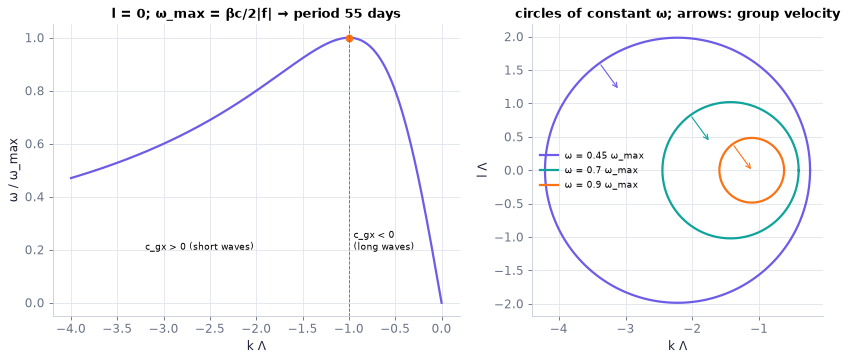

In [162]:
figRo = ch13.fig_rossby_dispersion()                           # omega/omega_max against k Lambda (l = 0), and circles of constant omega (35 N)
plt.show()   # display the figure

**What you see.** Left: the frequency (as a fraction of the largest possible one) against the zonal wavenumber — a curve that rises from zero, peaks at 1 where $k\Lambda=-1$, and falls again. Right: circles of constant frequency, with the group velocity drawn as arrows.

**How to read it.** Between the origin and the maximum (long waves) the curve is nearly a straight line: non-dispersive, energy westward. Beyond the maximum (short waves) the slope has the other sign: energy eastward. On the circles the arrows point inward.

**What would change if…** …the Rossby radius were infinite (barotropic, rigid lid)? There would be no maximum: every wave would send its energy east.

In [163]:
lam_ax = np.geomspace(5.0e4, 5.0e7, 80)                        # wavelengths from 50 km to 50 000 km [m]

def f8(logLam):                                                # curves for one Rossby radius, Lambda = 10**logLam km
    Lam_ = 10**logLam*1e3                                      # the radius [m]
    c_ = Lam_*f35                                              # the long-wave speed that gives this radius at 35 N [m/s]
    cx_ = GFD.rossby_phase_speed(-2*np.pi/lam_ax, 0.0, beta35, f35, c_)        # Eq. (13.119)
    cg_ = GFD.rossby_group_velocity(-2*np.pi/lam_ax, 0.0, beta35, f35, c_)[0]  # c_gx
    unit = beta35*Lam_**2                                      # the long-wave speed beta Lambda^2 used as the unit
    return {"phase speed c_x / (βΛ²): always westward": (lam_ax/1e3, cx_/unit),   # hand the result back to the caller
            "group velocity c_gx / (βΛ²): changes sign at λ = 2πΛ": (lam_ax/1e3, cg_/unit),
            "zero": (lam_ax/1e3, 0*lam_ax)}

figF8 = slider_figure(f8, "log10 of the Rossby radius Λ [km]", np.round(np.linspace(np.log10(20.0), np.log10(3000.0), 20), 3),
                      xlabel="wavelength λ [km]", ylabel="speed in units of βΛ²", title="Short waves send energy east, long waves west",
                      yrange=(-1.1, 0.2))                      # 20 slider positions, logarithmically spaced
figF8.update_xaxes(type="log", range=[np.log10(50.0), np.log10(5.0e4)])   # logarithmic wavelength axis
figF8.show()   # display the interactive figure (the slider works on the web page too)

**What does the code above do?**

`f8` returns the phase speed and the zonal group velocity against wavelength for one Rossby radius, both in units of the
long-wave speed $\beta\Lambda^2$. The slider moves the radius from 20 km (an ocean's internal mode) to 3000 km (an external
mode).

**What you see.** Phase speed (always negative: westward) and group velocity against wavelength. The group velocity is positive (eastward) for short waves, crosses zero at $\lambda=2\pi\Lambda$, and joins the phase speed at $-1$ for long waves.

**How to read it.** Sliding the radius shifts the crossing: for an internal mode almost every wave longer than a few hundred kilometres carries energy west; for the external mode even a 10 000 km wave carries it east.

**What would change if…** …a mean eastward current were added? Both curves would shift up by $U$ (in these units), and the wave with $c_x=0$ would stand still.

📝 **Note.** **N137 [B]** **The cubic of `C09` again:** $\omega^3-c^2\omega(k^2+l^2)-f_0^2\omega-c^2\beta k=0$ (13.121). For $\omega\ll f$ its first term drops and
the relation of this block follows.

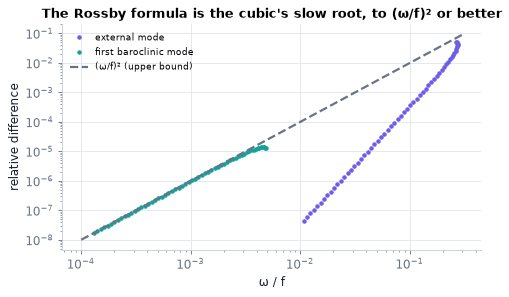

In [164]:
lam_sw = np.geomspace(3.0e5, 2.0e7, 60)                        # wavelengths [m] (35 N: three real roots for all of them)
fig, ax = plt.subplots(figsize=(6.0, 3.6))   # a new figure and its panel(s); figsize in inches
for nm, c_, col in (("external mode", c_ext, COLORS["accent"]), ("first baroclinic mode", c_bc, COLORS["teal"])):   # two modes
    slow = np.array([GFD.shallow_water_omega(2*np.pi/L_, 0.0, c_, f35, beta35)[1] for L_ in lam_sw])   # the slow root of the cubic
    ross = GFD.rossby_omega(2*np.pi/lam_sw, 0.0, beta35, f35, c_)   # Eq. (13.118) for the same waves
    ax.loglog(abs(ross)/f35, abs(slow/ross - 1), "o", ms=3, color=col, label=nm)   # relative difference against omega/f
ax.loglog([1e-4, 0.3], [1e-8, 0.09], "--", color=COLORS["muted"], label="(ω/f)² (upper bound)")   # a guide proportional to (omega/f)^2
ax.set(xlabel="ω / f", ylabel="relative difference", title="The Rossby formula is the cubic's slow root, to (ω/f)² or better")   # axis labels (with units), title and fixed ranges of this panel
ax.legend(fontsize=8)   # the legend names every curve
plt.show()   # display the figure

**What you see.** The relative difference between the slow root of the full cubic and the Rossby formula, for a sweep of wavelengths on two modes, against $\omega/f$.

**How to read it.** The guide $(\omega/f)^2$ is an upper bound. The baroclinic points sit on it. The external-mode points lie below it, because the error of dropping $\omega^3$ is really $\omega^2/(c^2K^2+f_0^2)$ and for these waves $c^2K^2\gg f_0^2$; it reaches a few per cent only at the longest external waves.

**What would change if…** …the latitude were low and the mode external? There the cubic may not even have three real roots (the caveat of `C09`).

> 📎 **Primer — two-dimensional FFT wavenumber grids (np.fft.fftfreq, np.fft.fft2).** `P329` · A field on a periodic grid is a sum of plane waves. `np.fft.fft2` returns their complex amplitudes; `2π·np.fft.fftfreq(n, d)`
gives the wavenumber that belongs to each array index (positive first, then negative). A linear equation with constant
coefficients moves each plane wave independently — multiply its amplitude by $e^{-i\omega t}$ and transform back: an exact
solution with no time stepping.

In [165]:
k = 2*np.pi*np.fft.fftfreq(8, d=1.0)       # wavenumbers of an 8-point periodic grid
print(np.round(k, 2))                      # [0, 0.79, 1.57, 2.36, -3.14, -2.36, -1.57, -0.79]

[ 0.    0.79  1.57  2.36 -3.14 -2.36 -1.57 -0.79]


> 🔧 **Our choice** — the animation below is an exact spectral evolution on a periodic line (`SW.qg_linear_evolve_1d`): each Fourier mode of a packet
(`GFD.rossby_packet_spectrum`) is advanced with its own frequency from $\omega=-\frac{\beta k}{k^2+l^2+f_0^2/c^2}$ *(13.118)*. No time stepping, no
numerical error beyond round-off.

In [166]:
nfr = 30 if FAST else 36                                       # number of frames
t_pk = np.linspace(0.0, 7.0e7, nfr)                            # 2.2 years of evolution [s]
packs = []                                                     # one wave packet per row: (x grid, wavenumbers, amplitudes, speeds, label)
for lam0, nm in ((1.5e5, "short wave, 150 km"), (1.0e6, "long wave, 1000 km")):   # shorter and longer than 2 pi Lambda = 271 km
    k0 = 2*np.pi/lam0                                          # central wavenumber [rad/m]
    kk, a0 = GFD.rossby_packet_spectrum(k0, k0/10, 48)         # 48 modes with Gaussian amplitudes around k0
    xx = np.linspace(-9*lam0, 9*lam0, 600)                     # eighteen wavelengths of the line [m]
    cpx = GFD.rossby_phase_speed(k0, 0.0, beta35, f35, c_bc)   # speed of the crests [m/s]
    cgx = GFD.rossby_group_velocity(k0, 0.0, beta35, f35, c_bc)[0]   # speed of the envelope [m/s]
    packs.append((xx, kk, a0, cpx, cgx, nm))
fig, axes = plt.subplots(2, 1, figsize=(6.8, 4.8))   # a new figure and its panel(s); figsize in inches
lines, marks = [], []
for ax, (xx, kk, a0, cpx, cgx, nm) in zip(axes, packs):        # set up the two rows
    (ln,) = ax.plot(xx/1e3, 0*xx, color=COLORS["accent"])      # the wave
    mk_g = ax.axvline(0, color=COLORS["orange"], lw=2)         # marker moving at the group velocity (the envelope)
    mk_p = ax.axvline(0, color=COLORS["muted"], ls="--")       # marker moving at the phase speed (a crest)
    ax.set(ylim=(-1.1, 1.1), xlim=(xx[0]/1e3, xx[-1]/1e3), ylabel="η (normalised)")   # axis labels (with units), title and fixed ranges of this panel
    ax.set_title(f"{nm}: crests {100*cpx:+.2f} cm/s (dashed), envelope {100*cgx:+.2f} cm/s (orange)", fontsize=8)   # label / range / scale of this axis
    lines.append(ln); marks.append((mk_g, mk_p))
axes[1].set_xlabel("x east [km]")   # label / range / scale of this axis

fig.canvas.draw(); fig.set_layout_engine("none")              # lay the figure out once, then freeze it: frames render much faster

def update(i):                                                 # frame i: both packets at time t_pk[i]
    for ln, (mk_g, mk_p), (xx, kk, a0, cpx, cgx, nm) in zip(lines, marks, packs):
        a_t = SW.qg_linear_evolve_1d(a0, kk, 0.0, t_pk[i], beta35, f35, c_bc)   # each mode's amplitude times exp(-i omega t)
        ln.set_ydata(np.real(np.exp(1j*np.outer(xx, kk)) @ a_t))                # the field: real part of the sum of modes
        mk_g.set_xdata([cgx*t_pk[i]/1e3]*2)                    # where the envelope should be
        mk_p.set_xdata([cpx*t_pk[i]/1e3]*2)                    # where a crest that started at x = 0 should be
    return lines   # hand the result back to the caller

show_animation(animate(update, frames=nfr, fig=fig, interval=100), player="video", dpi=50)   # a smooth video
plt.close(fig)                                                 # do not show the last frame a second time
plt.show()   # display the figure

**What does the code above do?**

1. Two packets on the first baroclinic mode at 35° N: one of 150 km waves (shorter than $2\pi\Lambda=271$ km), one of 1000 km
   waves (longer).
2. `SW.qg_linear_evolve_1d` multiplies each mode by $e^{-i\omega t}$; the field is the real part of the sum.
3. The dashed line moves at the phase speed, the orange line at the group velocity; the titles give both.

**What you see.** Two wave packets over about two years. In both, the crests (follow the dashed line) march west. The envelope (orange line) of the short-wave packet creeps **east**; that of the long-wave packet moves **west**, almost with its crests.

**How to read it.** Crests and energy part company: watch crests appear at the eastern edge of the short packet, travel through it and vanish at the western edge. At $\lambda=2\pi\Lambda$ the envelope would stand still.

**What would change if…** …the packets rode an eastward current of a few centimetres per second? Every speed shifts by $U$; the crests of one particular wavelength would stand still.

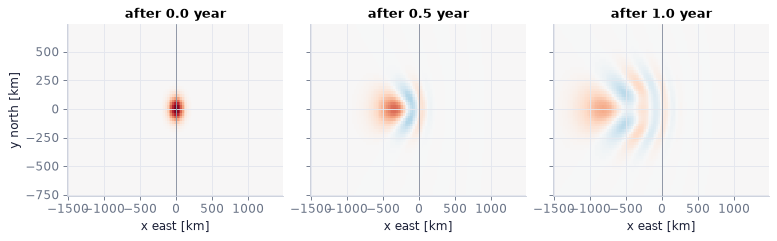

In [167]:
xe = np.linspace(-1.5e6, 1.5e6, 128, endpoint=False); ye = np.linspace(-7.5e5, 7.5e5, 64, endpoint=False)   # a periodic box 3000 km x 1500 km [m]
Xe, Ye = np.meshgrid(xe, ye)                                   # grids indexed [j, i]
eta_e0 = np.exp(-(Xe**2 + Ye**2)/(1.0e5)**2)                   # a Gaussian eddy 100 km in radius (height normalised to 1)
fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.9), sharey=True)   # a new figure and its panel(s); figsize in inches
for ax, yrs in zip(axes, (0.0, 0.5, 1.0)):                     # three times [years]
    eta_t = SW.qg_linear_evolve(eta_e0, xe, ye, yrs*3.156e7, beta35, f35, c_bc)   # exact evolution of Eq. (13.117) on the periodic box
    ax.pcolormesh(xe/1e3, ye/1e3, eta_t, cmap="RdBu_r", vmin=-1.0, vmax=1.0, shading="auto")   # the height field (red high, blue low)
    ax.axvline(0, color=COLORS["muted"], lw=0.6)   # a thin reference line
    ax.set(title=f"after {yrs:.1f} year", xlabel="x east [km]")   # axis labels (with units), title and fixed ranges of this panel
axes[0].set_ylabel("y north [km]")   # label / range / scale of this axis
plt.show()   # display the figure

**What you see.** A Gaussian eddy on the first baroclinic mode, evolved exactly by the linear quasi-geostrophic equation for one year on a box that is periodic in both directions (whatever leaves through one edge re-enters through the opposite one).

**How to read it.** The eddy drifts west at a few kilometres per day (the long-wave speed), weakens, and leaves a train of shorter waves to its **east** — the short waves, whose energy travels eastward. The run is stopped before the eddy reaches the western edge of the periodic box.

**What would change if…** …$\beta=0$? The eddy would simply sit there: a steady geostrophic vortex.

📝 **Note.** **N138 [C]** **Where it fails.** This relation fails within a few degrees of the equator, where geostrophy itself breaks down. Equatorial
waves — the equatorial Kelvin wave and the equatorial radius $\sqrt{c/\beta}$ — are beyond the book; pointer: any text on
equatorial dynamics.

#### 🎮 Interactive: The crests go west — so how does the energy go east?

**Why interactive rather than a static figure:** a packet whose crests march west while its envelope moves east cannot be drawn still; marked columns show each one's vorticity change as it is displaced; a mean flow slows the crests to a standstill.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Play the short-wave preset and follow one crest and the envelope separately.
- Drag the wavelength through 2πΛ and watch the status flip from 'energy east' to 'energy west'.
- Add a mean flow until the crests stand still; read the wavelength.
- Click a column to see its displacement, βy and the vorticity it must have.

In [168]:
show_viz("ch13", "rossby_waves")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/rossby_waves]

---

## 13.16 Barotropic Instability

**What is this section about?** Chapter 11's question — when is a shear flow unstable? — asked again on the β-plane. The
answer is Rayleigh's criterion with one change: what must change sign is the gradient of *absolute* vorticity. (This section
continues block `C15`.)

📝 **Note.** **N139 [B]** **Constant depth** turns potential-vorticity conservation into conservation of absolute vorticity:
$\Big(\dfrac{\partial}{\partial t}+\mathbf u\cdot\nabla\Big)(\zeta+f)=0$ (13.122). `SW.barotropic_vorticity_rhs` is its spectral
right-hand side (used in `C17`).

📝 **Note.** **N140 [B]** **Linearised about a zonal current $U(y)$**, with $u'=-\partial\psi/\partial y$, $v'=\partial\psi/\partial x$, $\bar\zeta=-dU/dy$:
$\dfrac{\partial}{\partial t}(\nabla^2\psi)+U\dfrac{\partial}{\partial x}(\nabla^2\psi)+\Big(\beta-\dfrac{d^2U}{dy^2}\Big)\dfrac{\partial\psi}{\partial x}=0$ (13.123)
(steps 1–3 of `D24`).

> 🔁 **Recap — Rayleigh's equation, now with β `R30`** (Ch. 11, $(U-c)\big(\frac{d^2\phi}{dy^2}-k^2\phi\big)-\frac{d^2U}{dy^2}\phi=0$ (11.81)). For normal modes $\psi=\hat\psi(y)e^{ik(x-ct)}$:
$(U-c)\Big[\dfrac{d^2}{dy^2}-k^2\Big]\hat\psi+\Big[\beta-\dfrac{d^2U}{dy^2}\Big]\hat\psi=0$ — Chapter 11's Rayleigh equation with $-U''$
replaced by $\beta-U''$. ⚠️ Trap T14: the stream function has the opposite sign to Chapter 11's; the eigenvalue $c$ does not
care.

#### 🧮 Derivation — The Rayleigh–Kuo criterion `D24` ★★ (Eq. 13.124: $\frac{d}{dy}(\bar\zeta+f)=\beta-\frac{d^2U}{dy^2}$)

**What we want to show.** Find a condition without which a zonal current U(y) on a β-plane cannot be unstable. The book says Chapter 11's analysis "carries over" and does not show it.

**Assumptions.** Inviscid; barotropic (no depth variation); β-plane; walls at y₁, y₂ (or decay) where the perturbation vanishes.

**The plan.**

1. Split the flow into a zonal current plus a small perturbation.
2. Linearise.
3. Introduce a stream function and normal modes.
4. Multiply by the complex conjugate, integrate, and take the imaginary part.

**Tools we use** (each explained before this point): linear stability and normal modes with a complex phase speed (Ch. 11, P214, reminders) · integration by parts (P218a) · real and imaginary parts of a complex equation (P260) · necessary vs sufficient (P255)

**We start from**

$$ \Big(\dfrac{\partial}{\partial t}+\mathbf u\cdot\nabla\Big)(\zeta+f)=0\ \text{(13.122)} $$

*In words:* With constant depth, absolute vorticity is conserved following the horizontal flow

---

**Step 1 of 8 — Decompose the flow.**

$$ u=U(y)+u',\quad v=v',\quad\zeta=\bar\zeta+\zeta',\quad\bar\zeta=-\dfrac{dU}{dy} $$

- *Why we can do this:* A steady zonal current satisfies the Start exactly (nothing varies along x and v = 0); primes mark a small disturbance.
- *In words:* Basic flow plus perturbation.

---

**Step 2 of 8 — Linearise.**

$$ \dfrac{\partial\zeta'}{\partial t}+U\dfrac{\partial\zeta'}{\partial x}+v'\dfrac{d}{dy}\big(\bar\zeta+f\big)=0 $$

- *Why we can do this:* Insert step 1 and drop products of two primed quantities; $\bar\zeta+f$ depends on y only, so only v′ advects it.
- *In words:* The perturbation vorticity is carried by the current and created by moving fluid across the background vorticity gradient.

---

**Step 3 of 8 — Introduce the stream function.**

$$ \dfrac{\partial}{\partial t}\big(\nabla^2\psi\big)+U\dfrac{\partial}{\partial x}\big(\nabla^2\psi\big)+\Big(\beta-\dfrac{d^2U}{dy^2}\Big)\dfrac{\partial\psi}{\partial x}=0\ \text{(13.123)} $$

- *Why we can do this:* With $u'=-\partial\psi/\partial y$, $v'=\partial\psi/\partial x$: $\zeta'=\nabla^2\psi$; and $d(\bar\zeta+f)/dy=-U''+\beta$.
- *In words:* One equation for one unknown.

---

**Step 4 of 8 — Insert a normal mode.**

$$ (U-c)\Big[\dfrac{d^2}{dy^2}-k^2\Big]\hat\psi+\Big[\beta-\dfrac{d^2U}{dy^2}\Big]\hat\psi=0,\qquad\psi=\hat\psi(y)\,e^{ik(x-ct)} $$

- *Why we can do this:* ∂/∂t → −ikc, ∂/∂x → ik; divide by ik. A complex $c=c_r+ic_i$ with $c_i>0$ means growth like $e^{kc_it}$.
- *In words:* Rayleigh's equation of Chapter 11 with β added to the vorticity gradient.

---

**Step 5 of 8 — Divide by U − c, multiply by the conjugate, integrate.**

$$ \displaystyle\int_{y_1}^{y_2}\hat\psi^*\Big(\dfrac{d^2\hat\psi}{dy^2}-k^2\hat\psi\Big)dy+\displaystyle\int_{y_1}^{y_2}\dfrac{\beta-U''}{U-c}\,\lvert\hat\psi\rvert^2\,dy=0 $$

- *Why we can do this:* If $c_i\neq0$ then U − c is never zero and the division is allowed; multiplying by $\hat\psi^*$ turns $\hat\psi$ into the real quantity $\lvert\hat\psi\rvert^2$.
- *In words:* A weighted average of the equation over the channel.

---

**Step 6 of 8 — Integrate the first term by parts.**

$$ -\displaystyle\int_{y_1}^{y_2}\Big(\Big\lvert\dfrac{d\hat\psi}{dy}\Big\rvert^2+k^2\lvert\hat\psi\rvert^2\Big)dy+\displaystyle\int_{y_1}^{y_2}\dfrac{\beta-U''}{U-c}\,\lvert\hat\psi\rvert^2\,dy=0 $$

- *Why we can do this:* Integration by parts gives $\int\hat\psi^*\hat\psi''dy=[\hat\psi^*\hat\psi']-\int\lvert\hat\psi'\rvert^2dy$, and the boundary term vanishes because $\hat\psi=0$ on the walls.
- *In words:* The first integral is real and negative.

---

**Step 7 of 8 — Take the imaginary part.**

$$ c_i\displaystyle\int_{y_1}^{y_2}\dfrac{\beta-U''}{\lvert U-c\rvert^2}\,\lvert\hat\psi\rvert^2\,dy=0 $$

- *Why we can do this:* Write $\dfrac1{U-c}=\dfrac{U-c_r+ic_i}{\lvert U-c\rvert^2}$; the first integral of step 6 has no imaginary part.
- *In words:* Either the mode does not grow, or this integral is zero.

---

**Step 8 of 8 — Draw the conclusion.**

$$ c_i\neq0\ \Rightarrow\ \dfrac{d}{dy}\big(\bar\zeta+f\big)=\beta-\dfrac{d^2U}{dy^2}\ \text{changes sign in}\ (y_1,y_2)\ \text{(13.124)} $$

- *Why we can do this:* The weight $\lvert\hat\psi\rvert^2/\lvert U-c\rvert^2$ is positive, so the integral can vanish only if β − U″ is positive in some places and negative in others.
- *In words:* Instability needs the gradient of absolute vorticity to change sign.

---

**Result**

$$ \begin{array}{l}\text{a necessary condition for barotropic instability is that}\ \dfrac{d}{dy}(\bar\zeta+f)=\beta-\dfrac{d^2U}{dy^2} \\ \text{changes sign within the flow}\end{array} $$

*In words:* Rayleigh's inflection-point criterion with β

**What it means.** β stabilises: a current must be sharp enough for its own curvature U″ to beat β somewhere. The quantity that must change sign is the cross-stream gradient of the basic state's potential vorticity — the same gradient that Rossby waves propagate on. **Fails when (as a test):** it is necessary, not sufficient: a flow that passes may still be stable.

**Check it.** Limit — β = 0: Rayleigh's criterion of Chapter 11 (U″ must change sign). Number — our easterly jet $U=-U_0\,\mathrm{sech}^2(y/L)$ (where $\mathrm{sech}\,y\equiv1/\cosh y$, a smooth bump) with U₀ = 14 m/s at 12° N: the largest U″ is 2U₀/L², so the criterion is met for L < 1118 km and not beyond; a westerly jet of the same shape needs L < 646 km. Code — `GFD.rayleigh_kuo_criterion`.

> ⚠️ **Common confusion (traps in `D24`):** Necessary, not sufficient; the β term comes from v′ d(ζ̄ + f)/dy; the stream-function sign differs from Chapter 11's (trap T14) — the eigenvalue c is unaffected; the division in step 5 needs c_i ≠ 0.

📝 **Note.** **N141 [B]** **The Rayleigh–Kuo criterion:** a necessary (not sufficient) condition for instability is that
$\dfrac{d}{dy}(\bar\zeta+f)=\beta-\dfrac{d^2U}{dy^2}$ (13.124) changes sign somewhere in the flow (the book says the analysis of
Chapter 11 carries over and does not show it; `D24` does).

In [169]:
y_j = np.linspace(-3.0e6, 3.0e6, 1201)                         # north-south distance from the jet axis [m]
for L_j in (4.0e5, 1.2e6):                                     # two jet half-widths: 400 km and 1200 km
    U_j = -14.0/np.cosh(y_j/L_j)**2                            # an easterly jet of 14 m/s at 12 N (ours)
    rk = GFD.rayleigh_kuo_criterion(y_j, U_j, beta12)          # does beta - U'' change sign?
    Upp = np.gradient(np.gradient(U_j, y_j), y_j)              # U'' by differences, for the hand-written test
    mine = bool(np.any(np.diff(np.sign(beta12 - Upp[2:-2])) != 0))   # the same test in one line
    assert mine == rk["changes_sign"]                          # same verdict as the library
    print(f"L = {L_j/1e3:.0f} km: largest U'' = 2 U0/L^2 = {2*14.0/L_j**2:.2e} against beta = {beta12:.2e} -> gradient changes sign: {rk['changes_sign']} ({'may be unstable' if rk['changes_sign'] else 'stable by the criterion'})")   # the verdict
print(f"widest easterly jet that can be unstable: L = sqrt(2 U0/beta) = {np.sqrt(2*14.0/beta12)/1e3:.0f} km; the same jet as a westerly needs L < {np.sqrt(2*14.0/(3*beta12))/1e3:.0f} km")   # easterly jets are easier to destabilise
print("beta = 0 (Chapter 11's criterion): inflection points at y =", np.round(ch11.rayleigh_criterion(y_j, U=-14.0/np.cosh(y_j/4.0e5)**2)["y_I"]/1e3), "km")   # Rayleigh's own test
Us = lambda yy: 1/np.cosh(yy)**2                               # non-dimensional westerly jet U = sech^2 y
Usp = lambda yy: -2*np.tanh(yy)/np.cosh(yy)**2                 # its first derivative
Uspp = lambda yy: (4*np.tanh(yy)**2 - 2/np.cosh(yy)**2)/np.cosh(yy)**2   # its second derivative
k_list = (1.4,) if FAST else (1.0, 1.4, 1.8)                   # wavenumbers in units of 1/L
b_list = (0.0, 0.3, 0.6, 0.7)                                  # beta in units of U0/L^2
growth = {k_: [ch13.rayleigh_kuo_eigs(k_, Us, Usp, Uspp, b_, bc="decay", y_max=16, parity="even")["growth_rate"] for b_ in b_list] for k_ in k_list}   # k c_i for each pair
print("growth rate k c_i [U0/L] of the sech^2 westerly jet at k = 1.4, beta = 0, 0.3, 0.6, 0.7:", np.round(growth[1.4], 4))   # beta stabilises

L = 400 km: largest U'' = 2 U0/L^2 = 1.75e-10 against beta = 2.24e-11 -> gradient changes sign: True (may be unstable)
L = 1200 km: largest U'' = 2 U0/L^2 = 1.94e-11 against beta = 2.24e-11 -> gradient changes sign: False (stable by the criterion)
widest easterly jet that can be unstable: L = sqrt(2 U0/beta) = 1118 km; the same jet as a westerly needs L < 646 km
beta = 0 (Chapter 11's criterion): inflection points at y = [-263.  263.] km


growth rate k c_i [U0/L] of the sech^2 westerly jet at k = 1.4, beta = 0, 0.3, 0.6, 0.7: [0.1191 0.0744 0.0151 0.    ]


**What does the code above do?**

1. `GFD.rayleigh_kuo_criterion(y, U, beta)` tests whether $\beta-U''$ changes sign; the one-line hand test gives the same
   verdict (the `assert`).
2. A 400 km wide easterly jet of 14 m/s at 12° N passes the test for possible instability; a 1200 km wide one does not.
3. Because $\beta$ adds to $-U''$, an easterly jet is easier to destabilise than a westerly one of the same shape.
4. `ch13.rayleigh_kuo_eigs` solves the Rayleigh equation with β numerically (Chapter 11's contour solver, with β passed as its
   own argument) for the non-dimensional westerly jet $U=\mathrm{sech}^2y$, where $\mathrm{sech}\,y\equiv1/\cosh y$ is a smooth bump
   of height 1 and width about 1 (with $\cosh y=(e^y+e^{-y})/2$): the growth rate falls as β rises and no growing mode
   is found at β = 0.7, beyond the largest $U''$ of this jet (2/3) — as the criterion requires.

📝 **Note.** **N142 [B]** **The profile and its vorticity** (our version of the book's figure): $U(y)$, $\bar\zeta$, $f$ and $\bar\zeta+f$ for the 400 km
jet, with the growth rates computed above.

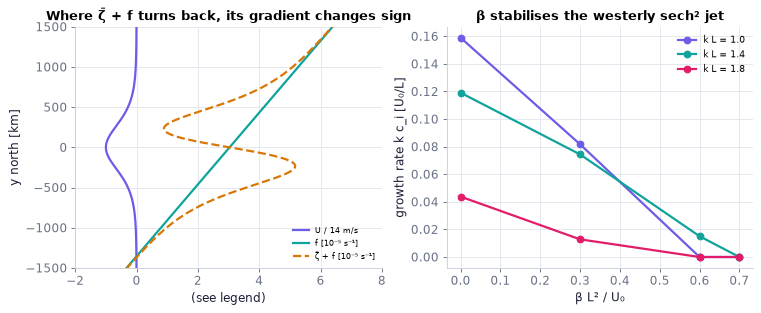

for scale: our 400 km, 14 m/s jet at 12 N has beta L^2/U0 = 0.26


In [170]:
U_4 = -14.0/np.cosh(y_j/4.0e5)**2                              # the 400 km easterly jet again [m/s]
zeta_b = -np.gradient(U_4, y_j)                                # its relative vorticity, zeta_bar = -dU/dy [1/s]
f_y = f12 + beta12*y_j                                         # planetary vorticity on the beta-plane [1/s]
fig, (a, b) = plt.subplots(1, 2, figsize=(9.4, 3.8))   # a new figure and its panel(s); figsize in inches
a.plot(U_4/14.0, y_j/1e3, color=COLORS["accent"], label="U / 14 m/s")                       # the jet
a.plot(f_y*1e5, y_j/1e3, color=COLORS["teal"], label="f [10⁻⁵ s⁻¹]")                        # planetary vorticity
a.plot((zeta_b + f_y)*1e5, y_j/1e3, "--", color=COLORS["amber"], label="ζ̄ + f [10⁻⁵ s⁻¹]")  # absolute vorticity (amber)
a.set(ylim=(-1500, 1500), xlim=(-2, 8), xlabel="(see legend)", ylabel="y north [km]", title="Where ζ̄ + f turns back, its gradient changes sign")   # axis labels (with units), title and fixed ranges of this panel
a.legend(fontsize=7)   # the legend names every curve
for k_, col in zip(growth, (COLORS["accent"], COLORS["teal"], COLORS["rose"])):   # growth rate against beta
    b.plot(b_list, growth[k_], "o-", color=col, label=f"k L = {k_}")
b.set(xlabel="β L² / U₀", ylabel="growth rate k c_i [U₀/L]", title="β stabilises the westerly sech² jet")   # axis labels (with units), title and fixed ranges of this panel
b.legend(fontsize=8)   # the legend names every curve
plt.show()   # display the figure
print(f"for scale: our 400 km, 14 m/s jet at 12 N has beta L^2/U0 = {beta12*(4.0e5)**2/14.0:.2f}")   # where the real jet sits on the right panel

**What you see.** Left: the easterly jet, the planetary vorticity $f$ (a straight line) and the absolute vorticity $\bar\zeta+f$ (dashed). Right: computed growth rates of the $\mathrm{sech}^2$ westerly jet against β.

**How to read it.** Where the dashed curve turns back, its gradient $\beta-U''$ changes sign: there, fluid columns can exchange places without violating conservation of absolute vorticity, and a wave can feed on the jet. On the right, growth weakens with β and stops near $\beta L^2/U_0=2/3$.

**What would change if…** …the jet were wider? The curvature $U''$ shrinks like $1/L^2$; once it is everywhere below β the dashed curve is monotonic and the flow is stable.

**What would change if…** …the flow has no horizontal shear at all, only a vertical one — the thermal wind of `C03`? There is no inflection point and
Ri is far above ¼, yet it is unstable: baroclinic instability (`C16`).

---

## 13.17 Baroclinic Instability

**What is this section about?** Why mid-latitude weather exists. A wind that increases with height over sloping density
surfaces is unstable to waves a few thousand kilometres long; they grow by carrying warm air poleward and upward and cold air
equatorward and downward. ⚠️ Here $z=0$ is the lower lid and $z=H$ the upper one; $\alpha$ is a scaled wavenumber, not the
expansion coefficient; $\Lambda=NH/f$ has no $\pi$.

### 🧩 The Eady problem: $c=\dfrac{U_0}{2}\pm\dfrac{U_0}{\alpha H}\sqrt{\Big(\dfrac{\alpha H}{2}-\tanh\dfrac{\alpha H}{2}\Big)\Big(\dfrac{\alpha H}{2}-\coth\dfrac{\alpha H}{2}\Big)}$ (13.141) `C16`

*The question:* The jet stream has no inflection point and a Richardson number far above ¼ — so where do storms come from?

#### The problem in plain words

The tropics are warm, the poles cold, and in between the surfaces of constant density tilt — a little, about one part in five
hundred. That tilt is stored energy: if cold air could slide down the slope under warm air sliding up it, the centre of mass
would fall. Rotation forbids the direct slide (`C03`: the tilted state is in balance). But a wave of the right size can do it
sideways, and once it starts, it feeds itself. The waves are the highs and lows of the weather map; their size, about 4600 km for our
inputs, and their growth time, a day or two, come out of one formula. *The problem solved here is known as the
Eady problem.*

> ⚠️ **slip #13 — the book credits** the theory of this instability to one named author, whose first name is misspelt
> **; only the spelling is asserted here.** Who should be credited is not asserted (we have not read the original papers
> first-hand). We say only that the problem solved in this section, with the phase speed $c=\dfrac{U_0}{2}\pm\dots$ of the
> heading, is known as the Eady problem.

#### The idea

Two lids, and on each lid a wave that exists because temperature varies along it (an "edge wave"). The lower one, left alone,
drifts east slowly; the upper one sits in a fast eastward wind but itself propagates west relative to it. If they can feel each
other through the layer, they lock: each one's flow strengthens the other. They can feel each other only if the wavelength is
long compared with the layer's Rossby radius.

📝 **Note.** **N143 [B]** **The basic state** (`ch13.eady_basic_state`): density surfaces sloping up toward the pole; by the thermal wind (`C03`) the
eastward flow increases with height.

In [171]:
N_a, H_a, U0_a = inp["atm_N"], inp["atm_H"], inp["atm_U0"]     # our atmosphere: N = 1.1e-2 1/s, H = 9 km, U0 = 27 m/s at the upper lid
bs = ch13.eady_basic_state(np.linspace(-1.0e6, 1.0e6, 5), np.linspace(0.0, H_a, 5), N=N_a, f=f35, H=H_a, U0=U0_a, rho0=1.2)   # density rho(z, y), wind U(z), slope
print(f"slope of the density surfaces f U0/(N^2 H) = {bs['slope']:.2e} (about 1 in {1/bs['slope']:.0f}); Richardson number N^2 H^2/U0^2 = {(N_a*H_a/U0_a)**2:.1f}")   # gentle slope, large Ri
print("wind at the five levels [m/s]:", np.round(bs["U"], 2))   # U = U0 z/H

slope of the density surfaces f U0/(N^2 H) = 2.07e-03 (about 1 in 482); Richardson number N^2 H^2/U0^2 = 13.4
wind at the five levels [m/s]: [ 0.    6.75 13.5  20.25 27.  ]


**What does this show?** The density surfaces slope by about 1 in 480, the wind rises linearly from 0 to 27 m/s, and the
Richardson number is about 13 — far above the ¼ that Chapter 11's shear instability needs. Whatever makes storms, it is not
that.

> 📎 **Primer — available potential energy and the wedge of sloping convection.** `P332` · Only part of a fluid's potential energy can ever be released: the part that would be freed by flattening the density surfaces.
A parcel exchange releases energy only if the heavier parcel ends up lower *and* was the denser one at the same level: its path
must lie inside the wedge between the horizontal and the sloping density surface. Steeper than the surface: it costs energy
(ordinary static stability). Flatter than horizontal: impossible.

In [172]:
slope_rho = 2.07e-3                               # slope of our density surfaces (computed above)
for s in (0.5, 1.0, 1.5):                         # slope of the exchange path / slope of the density surface
    print(s, "releases energy" if 0 < s < 1 else "does not")

0.5 releases energy
1.0 does not
1.5 does not


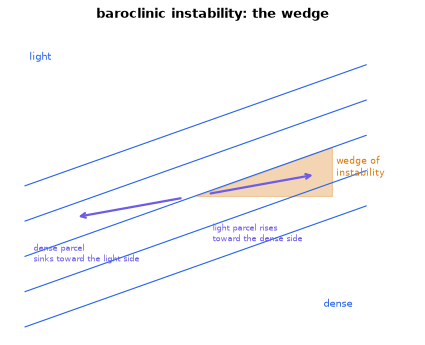

In [173]:
figW = draw_eady_wedge()                                       # our sketch: the wedge between the horizontal and a density surface
plt.show()   # display the figure

**What you see.** Sloping density surfaces (blue lines; light fluid above, dense below), the shaded wedge between the horizontal and one of those surfaces, and two arrows along a path inside the wedge: a light parcel rising toward the dense side, a dense parcel sinking toward the light side.

**How to read it.** Both arrows are flatter than the density surfaces but not level: such an exchange puts light fluid higher and dense fluid lower, so the centre of mass falls. Growing baroclinic waves move air along such paths: poleward and up, equatorward and down.

**What would change if…** …the density surfaces were level? The wedge closes: nothing to release, no instability.

📝 **Note.** **N144 [C]** **The starting set**, for the total flow on an f-plane, hydrostatic and inviscid:
$\dfrac{\partial u}{\partial t}+u\dfrac{\partial u}{\partial x}+v\dfrac{\partial u}{\partial y}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}$,
$\dfrac{\partial v}{\partial t}+u\dfrac{\partial v}{\partial x}+v\dfrac{\partial v}{\partial y}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}$,
$0=-\dfrac{\partial p}{\partial z}-\rho g$, $\dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}=0$,
$\dfrac{\partial\rho}{\partial t}+u\dfrac{\partial\rho}{\partial x}+v\dfrac{\partial\rho}{\partial y}+w\dfrac{\partial\rho}{\partial z}=0$ (13.125)
(⚠️ trap T15: no $w\,\partial u/\partial z$ in the momentum equations).

📝 **Note.** **N145 [C]** **Basic state plus perturbation** (13.126): $u=U(z)+u'$, $v=v'$, $w=w'$, $\rho=\bar\rho(y,z)+\rho'$, $p=\bar p(y,z)+p'$.

📝 **Note.** **N146 [C]** **The basic state is geostrophic and hydrostatic** (13.127): $fU=-\dfrac1{\rho_0}\dfrac{\partial\bar p}{\partial y}$,
$0=-\dfrac{\partial\bar p}{\partial z}-\bar\rho g$.

> 📎 **Primer — non-trivial solutions of a homogeneous 2 × 2 system: the determinant must vanish.** `P330` · Two equations $a\,A+b\,B=0$ and $c\,A+d\,B=0$ always have the solution $A=B=0$. They have another one only if the two equations
say the same thing, i.e. the determinant $ad-bc$ is zero. When the coefficients contain an unknown (a frequency, a phase
speed), "determinant = 0" is the equation that fixes it.

In [174]:
c = sp.symbols("c")                               # an unknown, like the phase speed
M = sp.Matrix([[c, -1], [-4, c]])                 # a toy system whose coefficients contain it
print("values of c with a non-trivial solution:", sp.solve(M.det(), c))   # [-2, 2]

values of c with a non-trivial solution: [-2, 2]


> 📎 **Primer — hyperbolic half-angle identities and coth.** `P331` · The function $\coth x=\cosh x/\sinh x=1/\tanh x$ is large near 0 and tends to 1 for large $x$. Two identities turn products at
the half argument into functions of the full argument: $2\sinh x\cosh x=\sinh2x$ and $\cosh^2x+\sinh^2x=\cosh2x$; hence
$\tanh x+\coth x=2\coth2x$.

In [175]:
x = 0.8                                                    # any positive number
print("tanh x + coth x =", round(np.tanh(x) + 1/np.tanh(x), 4), "; 2 coth 2x =", round(2/np.tanh(2*x), 4))   # equal
print("x = coth x at x =", round(brentq(lambda x: x - 1/np.tanh(x), 0.5, 3), 5))   # 1.19968

tanh x + coth x = 2.17 ; 2 coth 2x = 2.17
x = coth x at x = 1.19968


> 🔁 **Tools from earlier chapters used in this block** (one line each; the full primers are in the chapters named)

- **cosh, sinh, tanh** — $\cosh x=(e^x+e^{-x})/2$, $\sinh x=(e^x-e^{-x})/2$, $\tanh x=\sinh x/\cosh x$; $(\cosh)'=\sinh$, $(\sinh)'=\cosh$. *(Ch. 7, P168)*
- **`scipy.optimize.minimize_scalar`** — `minimize_scalar(F, bounds=(a, b), method="bounded")` finds the minimum of a function of one variable on an interval (maximise by minimising `-F`). *(Ch. 7, P170)*
- **Chebyshev eigen-solve as an independent route** — on Chebyshev points a derivative becomes a dense matrix that is accurate to many digits with few points, so a differential eigenproblem becomes a small matrix one. *(Ch. 11, P258)*
- **mean of a product of two wave fields** — over a wavelength, the mean of $\mathrm{Re}(\hat a\,e^{i\phi})\,\mathrm{Re}(\hat b\,e^{i\phi})$ is $\tfrac12\mathrm{Re}(\hat a\,\hat b^*)$: only the in-phase parts contribute. *(Ch. 7, P178)*

#### 🧮 Derivation — The Eady basic state and perturbation equation `D25` ★★★ (Eq. 13.136: $\Big(\frac{\partial}{\partial t}+U\frac{\partial}{\partial x}\Big)\Big[\nabla_H^2p'+\frac{f^2}{N^2}\frac{\partial^2p'}{\partial z^2}\Big]=0$)

**What we want to show.** Derive the equation governing small quasi-geostrophic disturbances on a wind that increases linearly with height in a uniformly stratified, rotating layer.

**Assumptions.** Quasi-geostrophic (Ro ≪ 1); f-plane; uniform N; hydrostatic; constant ∂ρ̄/∂y; vertical advection of momentum neglected (trap T15).

**The plan.**

1. Split into a basic state and a perturbation.
2. Find the basic wind from the thermal wind.
3. Linearise the vorticity equation.
4. Express ζ′ and w′ through the pressure perturbation.
5. Substitute.

**Tools we use** (each explained before this point): ordering in a small parameter (P328) · cross-differentiation (P177) · thermal wind (C03, D04) · linearisation

**We start from**

$$ \begin{array}{l}\text{the f-plane, hydrostatic, inviscid set (13.125):} \\ \dfrac{\partial u}{\partial t}+u\dfrac{\partial u}{\partial x}+v\dfrac{\partial u}{\partial y}-fv=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial x}\ \text{,} \\ \dfrac{\partial v}{\partial t}+u\dfrac{\partial v}{\partial x}+v\dfrac{\partial v}{\partial y}+fu=-\dfrac1{\rho_0}\dfrac{\partial p}{\partial y}\ \text{,}\ 0=-\dfrac{\partial p}{\partial z}-\rho g\ \text{,} \\ \dfrac{\partial u}{\partial x}+\dfrac{\partial v}{\partial y}+\dfrac{\partial w}{\partial z}=0\ \text{,} \\ \dfrac{\partial\rho}{\partial t}+u\dfrac{\partial\rho}{\partial x}+v\dfrac{\partial\rho}{\partial y}+w\dfrac{\partial\rho}{\partial z}=0\end{array} $$

*In words:* Momentum, hydrostatics, mass, density; no friction, f constant

---

**Step 1 of 13 — Decompose.**

$$ u=U(z)+u',\ \ v=v',\ \ w=w',\ \ \rho=\bar\rho(y,z)+\rho',\ \ p=\bar p(y,z)+p'\ \text{(13.126)} $$

- *Why we can do this:* A zonal wind that varies only with height, in balance with a density field that varies northward and upward; primes are small.
- *In words:* Basic state plus perturbation.

---

**Step 2 of 13 — Write the balance of the basic state.**

$$ fU=-\dfrac1{\rho_0}\dfrac{\partial\bar p}{\partial y},\qquad0=-\dfrac{\partial\bar p}{\partial z}-\bar\rho g\ \text{(13.127)} $$

- *Why we can do this:* Insert the unprimed fields into the Start: with no perturbation only the geostrophic and hydrostatic balances remain.
- *In words:* The basic wind is geostrophic and hydrostatic.

---

**Step 3 of 13 — Eliminate the basic pressure.**

$$ \dfrac{dU}{dz}=\dfrac{g}{f\rho_0}\dfrac{\partial\bar\rho}{\partial y}\ \text{(13.128), so}\ U=\dfrac{U_0z}{H} $$

- *Why we can do this:* ∂/∂z of the first and ∂/∂y of the second share the mixed derivative of p̄ (the thermal-wind move of D04); a constant density gradient and U(0) = 0 give a linear wind.
- *In words:* Denser toward the pole means a westerly wind growing with height.

---

**Step 4 of 13 — Form the vorticity equation of the total flow.**

$$ \dfrac{\partial\zeta}{\partial t}+u\dfrac{\partial\zeta}{\partial x}+v\dfrac{\partial\zeta}{\partial y}-(\zeta+f)\dfrac{\partial w}{\partial z}=0\ \text{(13.129)} $$

- *Why we can do this:* Cross-differentiate the two momentum equations as in D17 steps 1–6 (now β = 0) and replace the horizontal divergence by −∂w/∂z from continuity.
- *In words:* Vorticity is advected and created by vertical stretching.

---

**Step 5 of 13 — Linearise.**

$$ \dfrac{\partial\zeta'}{\partial t}+U\dfrac{\partial\zeta'}{\partial x}-f\dfrac{\partial w'}{\partial z}=0\ \text{(13.130)} $$

- *Why we can do this:* The basic flow has no vertical vorticity (U depends on z only); drop products of primed quantities and ζ′ against f.
- *In words:* Stretching of the planetary vorticity is the only source.

---

**Step 6 of 13 — Use geostrophic perturbation velocities.**

$$ u'\simeq-\dfrac1{\rho_0f}\dfrac{\partial p'}{\partial y},\qquad v'\simeq\dfrac1{\rho_0f}\dfrac{\partial p'}{\partial x}\ \text{(13.131)} $$

- *Why we can do this:* To lowest order in the Rossby number the perturbation is geostrophic too (D03).
- *In words:* The disturbance winds follow the disturbance isobars.

---

**Step 7 of 13 — Compute the perturbation vorticity.**

$$ \zeta'=\dfrac{\partial v'}{\partial x}-\dfrac{\partial u'}{\partial y}=\dfrac1{\rho_0f}\nabla_H^2p'\ \text{(13.132)} $$

- *Why we can do this:* Differentiate step 6; ρ₀ and f are constants.
- *In words:* A low is a cyclonic vortex.

---

**Step 8 of 13 — Linearise the density equation.**

$$ \dfrac{\partial\rho'}{\partial t}+U\dfrac{\partial\rho'}{\partial x}+v'\dfrac{\partial\bar\rho}{\partial y}-\dfrac{\rho_0N^2w'}{g}=0\ \text{(13.133)} $$

- *Why we can do this:* Keep terms with one primed factor; write $\partial\bar\rho/\partial z=-\rho_0N^2/g$. The term $v'\,\partial\bar\rho/\partial y$ is where the basic state's tilt enters.
- *In words:* Density changes by advection along the flow, by north–south motion across the basic gradient, and by vertical motion.

---

**Step 9 of 13 — Use hydrostatic balance of the perturbation.**

$$ 0=-\dfrac{\partial p'}{\partial z}-\rho'g\ \Rightarrow\ \rho'=-\dfrac1g\dfrac{\partial p'}{\partial z}\ \text{(13.134)} $$

- *Why we can do this:* Subtract the basic-state balance of step 2 from the hydrostatic equation of the total flow.
- *In words:* Density anomalies are vertical gradients of the pressure anomaly.

---

**Step 10 of 13 — Solve the density equation for w′.**

$$ w'=-\dfrac1{\rho_0N^2}\Big[\Big(\dfrac{\partial}{\partial t}+U\dfrac{\partial}{\partial x}\Big)\dfrac{\partial p'}{\partial z}-\dfrac{dU}{dz}\dfrac{\partial p'}{\partial x}\Big]\ \text{(13.135)} $$

- *Why we can do this:* Insert step 9, step 6 for v′, and step 3 in the form $\partial\bar\rho/\partial y=(f\rho_0/g)\,dU/dz$; multiply by $g/(\rho_0N^2)$.
- *In words:* Rising motion is diagnosed from the pressure field.

---

**Step 11 of 13 — Differentiate w′ in z.**

$$ \dfrac{\partial w'}{\partial z}=-\dfrac1{\rho_0N^2}\Big[\Big(\dfrac{\partial}{\partial t}+U\dfrac{\partial}{\partial x}\Big)\dfrac{\partial^2p'}{\partial z^2}+\dfrac{dU}{dz}\dfrac{\partial^2p'}{\partial x\,\partial z}-\dfrac{dU}{dz}\dfrac{\partial^2p'}{\partial x\,\partial z}-\dfrac{d^2U}{dz^2}\dfrac{\partial p'}{\partial x}\Big] $$

- *Why we can do this:* Product rule: the z-derivative also acts on U(z) inside the advection operator and on dU/dz in the last term; N is uniform.
- *In words:* Four terms, two of them equal and opposite.

---

**Step 12 of 13 — Cancel and use the linear wind.**

$$ \dfrac{\partial w'}{\partial z}=-\dfrac1{\rho_0N^2}\Big(\dfrac{\partial}{\partial t}+U\dfrac{\partial}{\partial x}\Big)\dfrac{\partial^2p'}{\partial z^2} $$

- *Why we can do this:* The two shear terms cancel exactly; the last vanishes because $d^2U/dz^2=0$ for $U=U_0z/H$.
- *In words:* The stretching depends only on the curvature of the pressure in z.

---

**Step 13 of 13 — Substitute into the vorticity equation.**

$$ \Big(\dfrac{\partial}{\partial t}+U\dfrac{\partial}{\partial x}\Big)\Big[\nabla_H^2p'+\dfrac{f^2}{N^2}\dfrac{\partial^2p'}{\partial z^2}\Big]=0\ \text{(13.136)} $$

- *Why we can do this:* Insert steps 7 and 12 into step 5 and multiply by ρ₀f.
- *In words:* The bracket — the perturbation's potential vorticity — is carried along by the basic wind.

---

**Result**

$$ \Big(\dfrac{\partial}{\partial t}+U\dfrac{\partial}{\partial x}\Big)\Big[\nabla_H^2p'+\dfrac{f^2}{N^2}\dfrac{\partial^2p'}{\partial z^2}\Big]=0 $$

*In words:* Quasi-geostrophic perturbations on an eastward current U(z)

**What it means.** In the interior nothing can create perturbation potential vorticity, so a normal mode has none there — the whole instability lives in what happens at the two lids (D26). **Fails when:** β matters (the Charney problem, beyond the book), N or the shear vary with height (interior potential-vorticity gradients appear), or Ro is not small.

**Check it.** Units — ∇²p′ and (f²/N²) ∂²p′/∂z² are both Pa/m² ✓. Limit — U = 0: the bracket is steady. Structure — the bracket is ρ₀f times (relative vorticity + stretching), the three-dimensional cousin of D22's bracket.

In [176]:
import sympy as sp                                            # symbolic algebra
x, y, z, t = sp.symbols("x y z t", real=True)                 # east, north, up, time
f, N, rho0, g, U0, H = sp.symbols("f N rho_0 g U_0 H", positive=True)   # constants of the Eady problem
p = sp.Function("p")(x, y, z, t)                              # perturbation pressure p'
U = U0 * z / H                                                # step 3: the basic flow, linear in z
adv = lambda F: sp.diff(F, t) + U * sp.diff(F, x)             # d/dt + U d/dx (following the basic flow)
drho_dy = f * rho0 / g * sp.diff(U, z)                        # step 3: thermal wind solved for d(rho-bar)/dy
vp = sp.diff(p, x) / (rho0 * f)                               # step 6: geostrophic v'
up = -sp.diff(p, y) / (rho0 * f)                              # step 6: geostrophic u'
zeta = sp.diff(vp, x) - sp.diff(up, y)                        # step 7: perturbation vorticity
assert sp.simplify(zeta - (sp.diff(p, x, 2) + sp.diff(p, y, 2)) / (rho0 * f)) == 0   # (13.132)
rhop = -sp.diff(p, z) / g                                     # step 9: hydrostatic perturbation
wsym = sp.symbols("w")                                        # unknown w' in the density equation
dens = adv(rhop) + vp * drho_dy - rho0 * N**2 * wsym / g      # step 8: (13.133)
wp = sp.solve(dens, wsym)[0]                                  # step 10: solve it for w'
book_w = -(adv(sp.diff(p, z)) - sp.diff(U, z) * sp.diff(p, x)) / (rho0 * N**2)   # (13.135)
assert sp.simplify(wp - book_w) == 0
vort = adv(zeta) - f * sp.diff(wp, z)                         # step 5: (13.130) with zeta' and w' put in
lap = sp.diff(p, x, 2) + sp.diff(p, y, 2)                     # horizontal Laplacian of p'
book = adv(lap + f**2 / N**2 * sp.diff(p, z, 2))              # (13.136)
assert sp.simplify(sp.expand(vort * rho0 * f - book)) == 0    # steps 11-13: the two shear terms have cancelled
print("D25 checks passed: (13.132), (13.135) and the Eady equation (13.136)")

D25 checks passed: (13.132), (13.135) and the Eady equation (13.136)


> ⚠️ **Common confusion (traps in `D25`):** The density equation keeps $v'\,\partial\bar\rho/\partial y$ — that is where the shear enters; when ∂/∂z acts on w′ the two shear terms cancel; vertical advection of momentum is neglected silently (trap T15); α in the next block is a scaled wavenumber, not the thermal expansion coefficient (trap T13).

📝 **Note.** **N147 [B]** **The thermal wind of the basic state** (step 3 of `D25`): $\dfrac{dU}{dz}=\dfrac g{f\rho_0}\dfrac{\partial\bar\rho}{\partial y}$ (13.128), so
$U=\dfrac{U_0z}H$.

📝 **Note.** **N148 [C]** **Vorticity with stretching** (step 4): $\dfrac{\partial\zeta}{\partial t}+u\dfrac{\partial\zeta}{\partial x}+v\dfrac{\partial\zeta}{\partial y}-(\zeta+f)\dfrac{\partial w}{\partial z}=0$ (13.129).

📝 **Note.** **N149 [B]** **Its linear form** (step 5): $\dfrac{\partial\zeta'}{\partial t}+U\dfrac{\partial\zeta'}{\partial x}-f\dfrac{\partial w'}{\partial z}=0$ (13.130).

📝 **Note.** **N150 [C]** **Geostrophic perturbations** (step 6): $u'\simeq-\dfrac1{\rho_0f}\dfrac{\partial p'}{\partial y}$, $v'\simeq\dfrac1{\rho_0f}\dfrac{\partial p'}{\partial x}$ (13.131).

📝 **Note.** **N151 [B]** **Vorticity from pressure** (step 7): $\zeta'=\dfrac1{\rho_0f}\nabla_H^2p'$ (13.132).

📝 **Note.** **N152 [B]** **The linear density equation** (step 8): $\dfrac{\partial\rho'}{\partial t}+U\dfrac{\partial\rho'}{\partial x}+v'\dfrac{\partial\bar\rho}{\partial y}-\dfrac{\rho_0N^2w'}{g}=0$ (13.133).

📝 **Note.** **N153 [C]** **Hydrostatic perturbations** (step 9): $0=-\dfrac{\partial p'}{\partial z}-\rho'g$ (13.134).

📝 **Note.** **N154 [B]** **The vertical velocity from the pressure** (step 10):
$w'=-\dfrac1{\rho_0N^2}\Big[\Big(\dfrac\partial{\partial t}+U\dfrac\partial{\partial x}\Big)\dfrac{\partial p'}{\partial z}-\dfrac{dU}{dz}\dfrac{\partial p'}{\partial x}\Big]$ (13.135)
(`GFD.eady_vertical_velocity`).

📝 **Note.** **N155 [B]** **The perturbation equation** (the result of `D25`):
$\Big(\dfrac\partial{\partial t}+U\dfrac\partial{\partial x}\Big)\Big[\nabla_H^2p'+\dfrac{f^2}{N^2}\dfrac{\partial^2p'}{\partial z^2}\Big]=0$ (13.136). The bracket is the
perturbation potential vorticity; it is carried by the basic flow and is zero in the interior for a normal mode — so
everything happens at the two lids.

In [177]:
print("the Eady perturbation equation (13.136) follows from the set (13.125) ->", ch13.eady_qg_sympy()["ok"])   # the engine agrees: True

the Eady perturbation equation (13.136) follows from the set (13.125) -> True


**What does this show?** The engine eliminates $w'$ between the vorticity and density equations and is left with the
potential-vorticity equation, as in `D25`.

#### 🧮 Derivation — The Eady boundary conditions, the 2 × 2 system and the phase speed `D26` ★★★ (Eq. 13.141: $c=\frac{U_0}{2}\pm\frac{U_0}{\alpha H}\sqrt{\Big(\frac{\alpha H}{2}-\tanh\frac{\alpha H}{2}\Big)\Big(\frac{\alpha H}{2}-\coth\frac{\alpha H}{2}\Big)}$)

**What we want to show.** Solve the Eady equation between two rigid lids and find the phase speed of its waves — and with it, when they grow. The book leaves the algebra to the reader.

**Assumptions.** Rigid horizontal lids; unbounded in x and y; U ≠ c in the interior (step 2).

**The plan.**

1. Insert a wave.
2. Solve the vertical structure with hyperbolic functions centred at mid-depth.
3. Write w′ = 0 on each lid in terms of the pressure.
4. Demand a non-trivial solution of the resulting 2 × 2 system.
5. Reduce the determinant to a quadratic in c.

**Tools we use** (each explained before this point): normal modes (Ch. 11, reminder) · non-trivial solutions of a homogeneous 2 × 2 system (P330) · hyperbolic identities and coth (P331) · the quadratic formula with a possibly negative discriminant (P159, reminder)

**We start from**

$$ \begin{array}{l}\Big(\dfrac{\partial}{\partial t}+U\dfrac{\partial}{\partial x}\Big)\Big[\nabla_H^2p'+\dfrac{f^2}{N^2}\dfrac{\partial^2p'}{\partial z^2}\Big]=0\ \text{(13.136) with}\ U=U_0z/H\ \text{and}\ w'=0\ \text{at} \\ \text{z = 0 and z = H}\end{array} $$

*In words:* The Result of D25; no flow through the lids

---

**Step 1 of 12 — Insert a wave.**

$$ p'=\hat p(z)\,e^{i(kx+ly-\omega t)}\ \text{(13.137)} $$

- *Why we can do this:* The coefficients depend on z only, so the solution may be taken as a plane wave in x, y, t with an unknown vertical structure.
- *In words:* A wave whose strength varies with height.

---

**Step 2 of 12 — Substitute into the Start.**

$$ \dfrac{d^2\hat p}{dz^2}-\alpha^2\hat p=0\ \text{(13.138)} $$

- *Why we can do this:* The operator gives the factor $ik(U-c)$ with $c=\omega/k$, non-zero in the interior; the bracket gives $-(k^2+l^2)\hat p+(f^2/N^2)\hat p''$.
- *In words:* Between the lids the perturbation's potential vorticity is zero.

---

**Step 3 of 12 — Name the scaled wavenumber.**

$$ \alpha^2\equiv\dfrac{N^2}{f^2}\big(k^2+l^2\big)\ \text{(13.139)} $$

- *Why we can do this:* A definition; 1/α is the height over which a disturbance of horizontal wavenumber K is felt, and αH = K × (NH/f).
- *In words:* A wave's vertical reach is its horizontal scale times f/N.

---

**Step 4 of 12 — Write the solution about mid-depth.**

$$ \hat p=A\cosh\alpha\Big(z-\dfrac H2\Big)+B\sinh\alpha\Big(z-\dfrac H2\Big)\ \text{(13.140)} $$

- *Why we can do this:* cosh and sinh are two independent solutions; centring them at H/2 makes the two lids mirror images and shortens the algebra.
- *In words:* An even part and an odd part about the middle of the layer.

---

**Step 5 of 12 — Express w′ = 0 through the pressure.**

$$ \Big(\dfrac{\partial}{\partial t}+U\dfrac{\partial}{\partial x}\Big)\dfrac{\partial p'}{\partial z}-\dfrac{U_0}{H}\dfrac{\partial p'}{\partial x}=0\ \text{at}\ z=0\ \text{and}\ z=H $$

- *Why we can do this:* Set the bracket of D25's $w'=-\dfrac1{\rho_0N^2}\Big[\Big(\dfrac{\partial}{\partial t}+U\dfrac{\partial}{\partial x}\Big)\dfrac{\partial p'}{\partial z}-\dfrac{dU}{dz}\dfrac{\partial p'}{\partial x}\Big]$ (13.135) to zero; U = 0 at the lower lid, U₀ at the upper.
- *In words:* On each lid, advection of the temperature anomaly balances advection of the basic temperature.

---

**Step 6 of 12 — Insert the wave.**

$$ (U-c)\dfrac{d\hat p}{dz}-\dfrac{U_0}{H}\hat p=0\ \text{at}\ z=0\ (U=0)\ \text{and}\ z=H\ (U=U_0) $$

- *Why we can do this:* ∂/∂t → −ikc and ∂/∂x → ik; divide by ik.
- *In words:* Two conditions on the vertical structure.

---

**Step 7 of 12 — Evaluate the structure on the lids.**

$$ \hat p(0)=A\cosh X-B\sinh X,\quad\hat p'(0)=\alpha(-A\sinh X+B\cosh X),\quad X\equiv\dfrac{\alpha H}2 $$

- *Why we can do this:* At z = 0 the argument is −X; cosh is even and sinh odd. At z = H the argument is +X, so the same expressions hold with +B sinh X and +A sinh X.
- *In words:* The even and odd parts add on one lid and subtract on the other.

---

**Step 8 of 12 — Write the two conditions.**

$$ A\Big[\alpha c\sinh X-\dfrac{U_0}H\cosh X\Big]+B\Big[-\alpha c\cosh X+\dfrac{U_0}H\sinh X\Big]=0\ \text{;}\ A\Big[\alpha(U_0-c)\sinh X-\dfrac{U_0}H\cosh X\Big]+B\Big[\alpha(U_0-c)\cosh X-\dfrac{U_0}H\sinh X\Big]=0 $$

- *Why we can do this:* Insert step 7 into step 6 and collect the terms with A and with B. These are the book's pair.
- *In words:* Two homogeneous equations for A and B.

---

**Step 9 of 12 — Set the determinant to zero and expand.**

$$ \alpha^2c\,(U_0-c)\sinh\alpha H-\alpha\dfrac{U_0^2}{H}\cosh\alpha H+\dfrac{U_0^2}{H^2}\sinh\alpha H=0 $$

- *Why we can do this:* A non-trivial (A, B) needs a vanishing determinant; after multiplying out, use $2\sinh X\cosh X=\sinh2X$ and $\cosh^2X+\sinh^2X=\cosh2X$ with 2X = αH.
- *In words:* One equation for the phase speed.

---

**Step 10 of 12 — Divide by α² sinh αH.**

$$ c^2-U_0c+\dfrac{U_0^2}{\alpha H}\coth\alpha H-\dfrac{U_0^2}{\alpha^2H^2}=0 $$

- *Why we can do this:* sinh αH > 0 for αH > 0; coth = cosh/sinh.
- *In words:* A quadratic in c.

---

**Step 11 of 12 — Solve the quadratic.**

$$ c=\dfrac{U_0}2\pm\dfrac{U_0}{\alpha H}\sqrt{\dfrac{\alpha^2H^2}4-\alpha H\coth\alpha H+1} $$

- *Why we can do this:* Quadratic formula; take the factor $U_0/(\alpha H)$ out of the root. If the radicand is negative the two roots are complex conjugates.
- *In words:* Both waves move, on average, at the mid-level wind speed.

---

**Step 12 of 12 — Factor the radicand.**

$$ c=\dfrac{U_0}2\pm\dfrac{U_0}{\alpha H}\sqrt{\Big(\dfrac{\alpha H}2-\tanh\dfrac{\alpha H}2\Big)\Big(\dfrac{\alpha H}2-\coth\dfrac{\alpha H}2\Big)}\ \text{(13.141)} $$

- *Why we can do this:* Multiply the two brackets out: $(X-\tanh X)(X-\coth X)=X^2-X(\tanh X+\coth X)+1$; then use the identity $\tanh X+\coth X=2\coth2X$ of the primer.
- *In words:* The sign of a product of two simple factors decides stability.

---

**Result**

$$ c=\dfrac{U_0}2\pm\dfrac{U_0}{\alpha H}\sqrt{\Big(\dfrac{\alpha H}2-\tanh\dfrac{\alpha H}2\Big)\Big(\dfrac{\alpha H}2-\coth\dfrac{\alpha H}2\Big)} $$

*In words:* The Eady phase speed: complex, hence growth, when the second factor is negative

**What it means.** The first factor is always positive (x > tanh x); the second is negative for long waves (x < coth x). So every wave longer than a cut-off is unstable: a sheared, stratified, rotating flow has no stable range at long wavelengths. Whenever c is complex, one of the conjugate pair grows. **Fails when:** the lids are not rigid (a tropopause, a free surface), β is included, or the shear is not uniform.

**Check it.** Units — c in m/s ✓ (αH dimensionless). Limits — αH → ∞: both factors → αH/2, c → U₀/2 ± U₀/2, i.e. c → 0 and c → U₀: two separate edge waves, each riding with the wind at its own lid. Numbers — αH = 1: c = (0.5 ± 0.2511 i) U₀; αH = 3: c = 0.3384 U₀ and 0.6616 U₀. Independent route — a Chebyshev eigen-solve (`ch13.eady_numeric_eigs`).

In [178]:
import sympy as sp                                            # symbolic algebra
z = sp.symbols("z", real=True)                                # height, 0 <= z <= H
al, H, U0 = sp.symbols("alpha H U_0", positive=True)          # scaled wavenumber, depth, top speed
c, A, B = sp.symbols("c A B")                                 # phase speed (may be complex) and the two constants
phat = A * sp.cosh(al * (z - H / 2)) + B * sp.sinh(al * (z - H / 2))   # step 4: (13.140)
bc = lambda zz: ((U0 * zz / H - c) * sp.diff(phat, z) - U0 / H * phat).subs(z, zz)   # steps 5-6: w' = 0 at z = zz
rows = [sp.expand(bc(0)), sp.expand(bc(H))]                   # step 7: the two boundary conditions
M = sp.Matrix([[r.coeff(A), r.coeff(B)] for r in rows])       # step 8: coefficients of A and B
X = al * H / 2                                                # the half-argument alpha H / 2
det = sp.simplify(M.det().rewrite(sp.exp))                    # step 9: the determinant (as exponentials)
quad = c**2 - U0 * c + U0**2 / (al * H) * sp.coth(al * H) - U0**2 / (al * H)**2   # step 10: the quadratic
ratio = sp.simplify((det / quad.rewrite(sp.exp)))             # they must differ by a factor without c
assert c not in ratio.free_symbols
rad = (X - sp.tanh(X)) * (X - sp.coth(X))                     # step 12: the radicand of (13.141)
c_plus = U0 / 2 + U0 / (al * H) * sp.sqrt(rad)                # (13.141), upper sign
val = quad.subs(c, c_plus).subs({al: sp.Rational(7, 5), H: 1, U0: 1})   # a wavenumber inside the unstable band
assert abs(sp.N(val, 30)) < 1e-25                             # steps 11-12: (13.141) solves the quadratic
val2 = quad.subs(c, c_plus).subs({al: 3, H: 2, U0: 5})        # and one beyond the cut-off
assert abs(sp.N(val2, 30)) < 1e-25
print("D26 checks passed: determinant -> quadratic in c -> (13.141); c at alpha*H = 1.4:",
      sp.N(c_plus.subs({al: sp.Rational(7, 5), H: 1, U0: 1}), 6))

D26 checks passed: determinant -> quadratic in c -> (13.141); c at alpha*H = 1.4: 0.5 + 0.215819*I


> ⚠️ **Common confusion (traps in `D26`):** The lid condition is w′ = 0 written in terms of the pressure — at z = H the extra term with U₀ appears; solving about mid-depth is what makes the determinant a quadratic in c − U₀/2; tanh and coth must not be swapped; growth needs the product under the root to be negative.

📝 **Note.** **N156 [C]** **The wave solution** (step 1 of `D26`): $p'=\hat p(z)e^{i(kx+ly-\omega t)}$ (13.137).

📝 **Note.** **N157 [B]** **Vertical structure** (step 2): $\dfrac{d^2\hat p}{dz^2}-\alpha^2\hat p=0$ (13.138).

📝 **Note.** **N158 [B]** **The scaled wavenumber** (step 3): $\alpha^2\equiv\dfrac{N^2}{f^2}(k^2+l^2)$ (13.139) (`GFD.eady_alpha`).

📝 **Note.** **N159 [C]** **Solution about mid-depth** (step 4): $\hat p=A\cosh\alpha\Big(z-\dfrac H2\Big)+B\sinh\alpha\Big(z-\dfrac H2\Big)$ (13.140).

📝 **Note.** **N160 [B]** **The lids** (steps 5–8). No flow through them, $w'=0$, gives
$\dfrac{\partial^2p'}{\partial t\,\partial z}-\dfrac{U_0}H\dfrac{\partial p'}{\partial x}=0$ at $z=0$ and
$\dfrac{\partial^2p'}{\partial t\,\partial z}-\dfrac{U_0}H\dfrac{\partial p'}{\partial x}+U_0\dfrac{\partial^2p'}{\partial x\,\partial z}=0$ at $z=H$, and with the
solution above the 2 × 2 system
$A\Big[\alpha c\sinh\dfrac{\alpha H}2-\dfrac{U_0}H\cosh\dfrac{\alpha H}2\Big]+B\Big[-\alpha c\cosh\dfrac{\alpha H}2+\dfrac{U_0}H\sinh\dfrac{\alpha H}2\Big]=0$,
$A\Big[\alpha(U_0-c)\sinh\dfrac{\alpha H}2-\dfrac{U_0}H\cosh\dfrac{\alpha H}2\Big]+B\Big[\alpha(U_0-c)\cosh\dfrac{\alpha H}2-\dfrac{U_0}H\sinh\dfrac{\alpha H}2\Big]=0$
(`ch13.eady_matrix(c, alphaH, U0, H)`).

#### ✏️ Tiny example: storm size and growth time by hand

Our inputs, rounded: $f=8.4\times10^{-5}$ s⁻¹ (35° N), $N=1.1\times10^{-2}$ s⁻¹, $H=9$ km, $U_0=27$ m/s.

1. Eady radius $\Lambda_E=NH/f=1.1\times10^{-2}\times9000/8.4\times10^{-5}=1.18\times10^{6}$ m ≈ 1180 km.
2. Fastest wave (ours, computed): $\alpha H=1.6061$, so $k=1.6061/\Lambda_E$ and the wavelength is $2\pi/k=3.9120\times1180$ km ≈ 4600 km.
3. Growth rate $\sigma=0.30982\times fU_0/(NH)=0.30982\times8.4\times10^{-5}\times27/99=7.1\times10^{-6}$ s⁻¹.
4. e-folding time $1/\sigma=1.4\times10^{5}$ s ≈ 1.6 days.
5. Shortest unstable wave: $2.6187\times1180$ km ≈ 3100 km; anything shorter is two neutral edge waves.

#### 🧮 Derivation — The Eady cut-off, the unstable band, the fastest wave and the maximum growth rate `D27` ★★ (Eq. 13.142: $\frac{HN}{f}<\frac{\alpha_cH}{k}$)

**What we want to show.** Turn the phase-speed formula into the numbers a climate scientist uses: which wavelengths grow, which grows fastest, and how fast in days. The book states the result without the steps and stops at the wavelength; the growth rate in physical units is **ours, computed** (no citation).

**Assumptions.** l = 0 for the wavelengths and the maximum; x ≡ αH/2.

**The plan.**

1. Find when the radicand is negative.
2. Solve the marginal condition numerically.
3. Write the growth rate k c_i and scale it.
4. Maximise it numerically.
5. Put units back.

**Tools we use** (each explained before this point): graphical roots (P316) · `brentq` (P108, reminder) · `minimize_scalar` (P170, reminder)

**We start from**

$$ c=\dfrac{U_0}2\pm\dfrac{U_0}{\alpha H}\sqrt{\Big(\dfrac{\alpha H}2-\tanh\dfrac{\alpha H}2\Big)\Big(\dfrac{\alpha H}2-\coth\dfrac{\alpha H}2\Big)}\ \text{(13.141)} $$

*In words:* The Result of D26

---

**Step 1 of 6 — Find the sign of each factor.**

$$ x-\tanh x>0\ \text{for all}\ x>0;\qquad x-\coth x<0\iff x<\coth x $$

- *Why we can do this:* tanh x < x for every positive x, while coth x falls from +∞ toward 1 and so crosses the rising line x exactly once.
- *In words:* Only the second factor can change sign.

---

**Step 2 of 6 — Solve the marginal condition.**

$$ \dfrac{\alpha_cH}2=\coth\dfrac{\alpha_cH}2\ \Rightarrow\ \alpha_cH=2.3994 $$

- *Why we can do this:* The radicand is zero where x = coth x; this transcendental equation is solved by `brentq` (x_c = 1.19968). Ours, computed to five digits.
- *In words:* Waves with αH below 2.3994 are unstable.

---

**Step 3 of 6 — Translate into wavelength.**

$$ \begin{array}{l}\dfrac{HN}{f}<\dfrac{\alpha_cH}{k}\ \text{(13.142; the book prints}\ \alpha_cH\ \text{as a rounded number), i.e.} \\ \lambda>\dfrac{2\pi}{\alpha_cH}\Lambda=2.6187\,\Lambda,\quad\Lambda\equiv\dfrac{HN}f\end{array} $$

- *Why we can do this:* For l = 0, α = Nk/f, so αH = kΛ; αH < α_cH is the printed inequality, and λ = 2π/k.
- *In words:* Only waves longer than 2.62 Eady radii grow.

---

**Step 4 of 6 — Write the growth rate.**

$$ \sigma=kc_i=\dfrac{fU_0}{NH}\,G(x),\qquad G(x)=\sqrt{(x-\tanh x)(\coth x-x)} $$

- *Why we can do this:* A wave $e^{ik(x-ct)}$ grows like $e^{kc_it}$; from the Start $c_i=(U_0/\alpha H)\,G$, and for l = 0, k/α = f/N.
- *In words:* The growth rate is a universal curve G times fU₀/(NH).

---

**Step 5 of 6 — Maximise G.**

$$ G_{max}=0.30982\ \text{at}\ x=0.80306,\ \text{i.e.}\ \alpha H=1.6061,\quad\lambda=\dfrac{2\pi}{1.6061}\Lambda=3.9120\,\Lambda $$

- *Why we can do this:* G is zero at x = 0 and at x_c and positive between; a bounded scalar maximiser finds the peak. Ours, computed.
- *In words:* The fastest-growing wave is 3.91 Eady radii long.

---

**Step 6 of 6 — Put the units back.**

$$ \sigma_{max}=0.30982\,\dfrac{f}{N}\dfrac{dU}{dz},\qquad\text{e-folding time}=\dfrac1{\sigma_{max}} $$

- *Why we can do this:* U₀/H is the shear dU/dz; the result no longer contains the depth H.
- *In words:* Storms grow faster where the shear is strong, the stratification weak and the latitude high.

---

**Result**

$$ \begin{array}{l}\text{unstable for}\ \alpha H<\alpha_cH=2.3994\ \text{(wavelengths above 2.6187 Λ); fastest at αH = 1.6061} \\ \text{(3.9120 Λ) with (ours)}\ \sigma_{max}=0.30982\,\dfrac fN\dfrac{dU}{dz}\end{array} $$

*In words:* The Eady growth rate

**What it means.** The atmosphere's storms and the ocean's mesoscale eddies are the same instability at two Rossby radii; "Eady growth rate" maps are this formula evaluated from analysed winds and temperatures. **Fails when:** the real profile departs from uniform shear and N; β and friction lower the growth rate and remove the long-wave instability in practice.

**Check it.** Units — (s⁻¹/s⁻¹)(s⁻¹) = s⁻¹ ✓. Limits — x → 0: G ≈ x/√3 → 0 (long waves grow slowly, although c_i is largest there); x → x_c: G → 0. Numbers — atmosphere (35° N, N = 1.1 × 10⁻² s⁻¹, H = 9 km, U₀ = 27 m/s): Λ = 1183 km, e-folding 1.64 days, fastest wavelength 4630 km, cut-off 3099 km; ocean (N = 5 × 10⁻³ s⁻¹, H = 1 km, U₀ = 0.1 m/s): 60 km, 22 days, 234 km.

> ⚠️ **Common confusion (traps in `D27`):** The growth rate is k c_i, not c_i; this Λ = NH/f has no π (trap T11); the constants are ours, computed — quote them to five digits and never as the book's rounded values; l ≠ 0 reduces the growth rate by the factor k/K.

📝 **Note.** **N161 [B]** **The cut-off.** The marginal condition is $\dfrac{\alpha_cH}2=\coth\Big(\dfrac{\alpha_cH}2\Big)$; the flow is unstable for
$\alpha H<\alpha_cH$, i.e. $\dfrac{HN}f<\dfrac{\alpha_cH}{\sqrt{k^2+l^2}}$, and for $l=0$ $\dfrac{HN}f<\dfrac{\alpha_cH}k$ (13.142) (the book prints
$\alpha_cH$ as a rounded number). With $\Lambda\equiv\dfrac{HN}f$ the unstable wavelengths are $\lambda>(2\pi/\alpha_cH)\,\Lambda$.

> ⚠️ **Common confusion (trap T11):** This $\Lambda=NH/f$ has **no** $\pi$: it is about three times the internal radius $NH/(\pi f)$ of `C12`.

📝 **Note.** **N162 [B]** **Not in the book — ours** (the book stops at the wavelength): the maximum growth rate
$\sigma_{max}=0.30982\,\dfrac fN\dfrac{dU}{dz}$ at $\alpha H=1.6061$ ($l=0$), and its e-folding time. The five-digit constants are
ours, computed by `GFD.eady_fastest()`; the values 0.3098 and 1.606 were checked first-hand against
K. Emanuel's MIT OpenCourseWare notes for course 12.803, Lecture 19 (`reference/ch13/SOURCES.md`).

In [179]:
fast = GFD.eady_fastest()                                      # the fastest-growing wave (l = 0), by a bounded maximisation
fac = GFD.eady_factors(fast["alphaH"])                         # the two brackets under the root of Eq. (13.141)
print(f"cut-off alpha_c H = {GFD.eady_critical():.5f}; fastest alpha H = {fast['alphaH']:.4f}, growth rate = {fast['sigma_nd']:.5f} f U0/(N H), c_i = {fast['ci_over_U0']:.4f} U0")   # ours, computed
print(f"factors at the fastest wave: (x - tanh x) = {fac['tanh_factor']:+.4f}, (x - coth x) = {fac['coth_factor']:+.4f} -> negative product, complex c")   # why it grows
c1 = GFD.eady_phase_speed(1.0, U0_a); c3 = GFD.eady_phase_speed(3.0, U0_a)   # Eq. (13.141) at alpha H = 1 (unstable) and 3 (neutral)
print(f"alpha H = 1: c = {c1.real:.2f} + {c1.imag:.2f} i m/s (growing);  alpha H = 3: c = {c3.real/U0_a:.4f} U0, real (neutral)")   # complex vs real
Lam_E = GFD.rossby_radius_internal(N_a, H_a, f35, with_pi=False)             # the Eady radius N H/f (no pi) [m]
sig = GFD.eady_max_growth_rate(f=f35, N=N_a, dUdz=U0_a/H_a)                  # sigma_max = 0.30982 (f/N) dU/dz [1/s]
t_e = GFD.eady_time_scale(f=f35, N=N_a, dUdz=U0_a/H_a)                       # its e-folding time [s]
print(f"atmosphere, 35 N: Lambda_E = {Lam_E/1e3:.0f} km, sigma_max = {sig:.3e} 1/s, e-folding {t_e/86400:.3f} days, fastest wavelength {2*np.pi/fast['alphaH']*Lam_E/1e3:.0f} km, cut-off {2*np.pi/GFD.eady_critical()*Lam_E/1e3:.0f} km")   # weather systems
print(f"check: growth rate from k = 1.6061/Lambda_E: {GFD.eady_growth_rate(fast['alphaH']/Lam_E, 0.0, N_a, f35, H_a, U0_a):.3e} 1/s")   # the same number
Lam_O = GFD.rossby_radius_internal(5.0e-3, 1000.0, f35, with_pi=False)       # an ocean twin: N = 5e-3 1/s over the top 1000 m
print(f"ocean twin (U0 = 0.1 m/s): Lambda_E = {Lam_O/1e3:.1f} km, e-folding {GFD.eady_time_scale(f=f35, N=5.0e-3, dUdz=0.1/1000.0)/86400:.1f} days, fastest wavelength {2*np.pi/fast['alphaH']*Lam_O/1e3:.0f} km")   # mesoscale eddies

cut-off alpha_c H = 2.39936; fastest alpha H = 1.6061, growth rate = 0.30982 f U0/(N H), c_i = 0.1929 U0
factors at the fastest wave: (x - tanh x) = +0.1373, (x - coth x) = -0.6990 -> negative product, complex c
alpha H = 1: c = 13.50 + 6.78 i m/s (growing);  alpha H = 3: c = 0.6616 U0, real (neutral)
atmosphere, 35 N: Lambda_E = 1183 km, sigma_max = 7.068e-06 1/s, e-folding 1.637 days, fastest wavelength 4630 km, cut-off 3099 km
check: growth rate from k = 1.6061/Lambda_E: 7.068e-06 1/s
ocean twin (U0 = 0.1 m/s): Lambda_E = 59.8 km, e-folding 22.3 days, fastest wavelength 234 km


**What does the code above do?**

1. `GFD.eady_critical()` solves $x=\coth x$; `GFD.eady_fastest()` maximises the growth rate (ours, computed).
2. `GFD.eady_factors` shows why there is growth: below the cut-off the second bracket is negative, the root is imaginary and
   $c$ is complex.
3. `GFD.eady_phase_speed(alphaH, U0)` is $c$ from the formula of this block: complex at $\alpha H=1$, real at $\alpha H=3$.
4. `GFD.eady_max_growth_rate` and `GFD.eady_time_scale` are called **by keyword** (`f=`, `N=`, `dUdz=`): sibling functions
   take $N$ before $f$, and swapping two positional numbers would give a wrong answer without any error.
5. For our atmosphere: an Eady radius of about 1200 km, storms about 4600 km long that grow by a factor $e$ in 1.6 days.
6. For an ocean thermocline: a radius of 60 km, eddies about 230 km across that take three weeks — the ocean's "weather".

In [180]:
# From scratch: the determinant of the 2 x 2 system is a quadratic in c — three evaluations give its coefficients
detM = lambda c_: np.linalg.det(ch13.eady_matrix(c_, 1.4, U0_a, H_a))   # the determinant for a trial phase speed c [m/s] at alpha H = 1.4
d0, d1, d2 = detM(0.0), detM(1.0), detM(2.0)                   # its value at three trial speeds
qa = (d2 - 2*d1 + d0)/2; qb = d1 - d0 - qa; qc = d0            # the quadratic q_a c^2 + q_b c + q_c through the three values
roots = np.roots([qa, qb, qc])                                 # its two zeros: the two phase speeds
c_grow = roots[np.argmax(roots.imag)]                          # the one with positive imaginary part (the growing wave)
assert np.isclose(c_grow, GFD.eady_phase_speed(1.4, U0_a))     # same as Eq. (13.141)
k14 = 1.4/Lam_E                                                # the wavenumber with alpha H = 1.4 [rad/m]
c_cheb = ch13.eady_numeric_eigs(k14, 0.0, N_a, f35, H_a, U0_a)["c"]   # an independent route: Chebyshev eigen-solve of Eq. (13.136) with the lid conditions
print(f"✓ determinant route: c = ({c_grow.real/U0_a:.4f} + {c_grow.imag/U0_a:.4f} i) U0; formula: same; Chebyshev route differs by {abs(c_cheb - c_grow)/U0_a:.1e} U0")   # visible confirmation

✓ determinant route: c = (0.5000 + 0.2158 i) U0; formula: same; Chebyshev route differs by 1.3e-11 U0


**What does the code above do?**

"The determinant must vanish" (primer above), done numerically: the determinant of `ch13.eady_matrix` is a quadratic in $c$,
so three evaluations fix it and `np.roots` gives its zeros. The growing root equals the closed form; a completely independent
numerical solution of the differential equation (`ch13.eady_numeric_eigs`, on Chebyshev points) agrees as well.

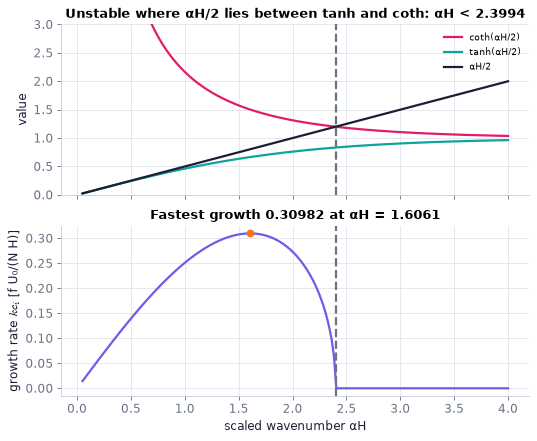

In [181]:
aH = np.linspace(0.05, 4.0, 400)                               # the scaled wavenumber alpha H
x_h = aH/2                                                     # half of it
growth_nd = np.array([aH_*GFD.eady_phase_speed(aH_, 1.0).imag for aH_ in aH])   # k c_i in units of f U0/(N H): alpha H times c_i/U0
fig, (a, b) = plt.subplots(2, 1, figsize=(6.6, 5.4), sharex=True)   # a new figure and its panel(s); figsize in inches
a.plot(aH, 1/np.tanh(x_h), color=COLORS["rose"], label="coth(αH/2)")       # coth x
a.plot(aH, np.tanh(x_h), color=COLORS["teal"], label="tanh(αH/2)")         # tanh x
a.plot(aH, x_h, color=COLORS["ink"], label="αH/2")                         # the line x
a.axvline(GFD.eady_critical(), color=COLORS["muted"], ls="--")             # the cut-off, where x = coth x
a.set(ylim=(0, 3), ylabel="value", title=f"Unstable where αH/2 lies between tanh and coth: αH < {GFD.eady_critical():.4f}")   # axis labels (with units), title and fixed ranges of this panel
a.legend(fontsize=8)   # the legend names every curve
b.plot(aH, growth_nd, color=COLORS["accent"])                              # the growth rate
b.plot(fast["alphaH"], fast["sigma_nd"], "o", color=COLORS["orange"])      # its maximum
b.axvline(GFD.eady_critical(), color=COLORS["muted"], ls="--")   # a thin reference line
b.set(xlabel="scaled wavenumber αH", ylabel="growth rate $kc_i$ [f U₀/(N H)]", title=f"Fastest growth {fast['sigma_nd']:.5f} at αH = {fast['alphaH']:.4f}")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure

**What you see.** Upper: $\coth x$, $\tanh x$ and the line $x=\alpha H/2$. Lower: the growth rate against the scaled wavenumber, with its maximum marked; the dashed line is the cut-off.

**How to read it.** The radicand of the phase-speed formula is negative exactly where the straight line lies between the two curves — to the left of the crossing $x=\coth x$. There the growth rate rises from zero, peaks, and falls back to zero at the cut-off.

**What would change if…** …$l\neq0$? The same curve read at $\alpha=(N/f)\sqrt{k^2+l^2}$; the growth rate carries the factor $k/K$ and is smaller.

> ⚠️ **Common confusion:** The growth rate is $kc_i$, not $c_i$. The imaginary part $c_i$ is largest as $k\to0$, where nothing grows.

In [182]:
lam_e = np.linspace(1.0e6, 1.2e7, 70)                          # wavelengths from 1000 km to 12 000 km [m]

def f9(U0_):                                                   # growth rate against wavelength for one wind difference U0 [m/s]
    sig_ = np.array([GFD.eady_growth_rate(2*np.pi/L_, 0.0, N_a, f35, H_a, U0_) for L_ in lam_e])*86400   # [1/day]
    return {"growth rate k c_i (atmosphere: N = 1.1e-2 1/s, H = 9 km, 35° N)": (lam_e/1e3, sig_),   # hand the result back to the caller
            "cut-off wavelength 2.62 Λ_E (shorter waves are neutral)": ([2*np.pi/GFD.eady_critical()*Lam_E/1e3]*2, [0.0, 1.2])}

figF9 = slider_figure(f9, "wind difference U₀ between the lids", np.arange(5.0, 50.1, 2.5), unit="m/s", xlabel="wavelength [km]",
                      ylabel="growth rate [1/day]", title="More shear: faster storms of the same size", yrange=(0, 1.25))   # 19 slider positions
figF9.show()   # display the interactive figure (the slider works on the web page too)
for U0_ in (10.0, 27.0, 50.0):                                 # three shears
    print(f"U0 = {U0_:4.0f} m/s: e-folding time {GFD.eady_time_scale(f=f35, N=N_a, dUdz=U0_/H_a)/86400:.2f} days")   # inversely proportional to the shear

U0 =   10 m/s: e-folding time 4.42 days
U0 =   27 m/s: e-folding time 1.64 days
U0 =   50 m/s: e-folding time 0.88 days


**What does the code above do?**

`f9` evaluates `GFD.eady_growth_rate` over a range of wavelengths for one value of the wind difference between the lids; the
vertical line is the cut-off. The printed lines give the e-folding time for three shears.

**What you see.** The growth rate (per day) against wavelength. Nothing grows below the cut-off near 3100 km; the maximum sits near 4600 km for every shear.

**How to read it.** The shear sets how fast storms grow (the curve scales with $U_0$); the stratification, depth and latitude set how big they are (through $\Lambda_E=NH/f$).

**What would change if…** …$N$ doubled? The radius $\Lambda_E$ doubles — storms twice as long — and the growth rate halves.

> ▶️ **Live cell.** The widget below needs a running Python kernel. On the web page it is frozen — open this notebook in Colab (button at the top) or run it locally to drag the sliders.

In [183]:
def eady_live(N=1.1e-2, H=9000.0, U0=27.0, lat_deg=35.0):      # free buoyancy frequency [1/s], depth [m], wind difference [m/s], latitude [degrees]
    f_ = GFD.coriolis_parameter(np.deg2rad(lat_deg))           # Coriolis parameter there
    Lam_ = GFD.rossby_radius_internal(N, H, f_, with_pi=False) # Eady radius N H/f [m]
    lam_ = np.linspace(0.5, 8.0, 200)*Lam_                     # wavelengths from 0.5 to 8 Eady radii
    sig_ = np.array([GFD.eady_growth_rate(2*np.pi/L_, 0.0, N, f_, H, U0) for L_ in lam_])*86400   # growth rate [1/day]
    fig, ax = plt.subplots(figsize=(6.0, 3.4))   # a new figure and its panel(s); figsize in inches
    ax.plot(lam_/1e3, sig_, color=COLORS["accent"])            # the growth curve
    ax.set(xlabel="wavelength [km]", ylabel="growth rate [1/day]", title=f"Λ_E = {Lam_/1e3:.0f} km, e-folding {GFD.eady_time_scale(f=f_, N=N, dUdz=U0/H)/86400:.2f} days")   # axis labels (with units), title and fixed ranges of this panel
    plt.show()   # display the figure

_ = live(eady_live, N=(0.004, 0.02, 0.001), H=(1000.0, 12000.0, 500.0), U0=(1.0, 50.0, 1.0), lat_deg=(15.0, 75.0, 5.0))   # four sliders

interactive(children=(FloatSlider(value=0.012, continuous_update=False, description='N', layout=Layout(width='…

**What does the code above do?**

Four free sliders — stratification, depth, wind difference, latitude — and the growth curve with the Eady radius and the
e-folding time in its title. On the web page the slider figure above carries the same idea.

📝 **Note.** **N163 [B]** **Energetics** (stated; the integrations are Chapter 11's energy-equation moves, whose result there was
$\frac d{dt}\int\frac12u_i^2\,dV=-\int u_iu_j\frac{\partial U_i}{\partial x_j}\,dV-\Lambda$ (11.88) with $\Lambda$ the dissipation). Here the perturbation
kinetic energy $K_E\equiv\dfrac{\rho_0}2\displaystyle\int(u'^2+v'^2)\,dx\,dy\,dz$ grows through the buoyancy flux alone,
$\dfrac{dK_E}{dt}=-g\displaystyle\int w'\rho'\,dx\,dy\,dz$ — not through the Reynolds stress against the shear.

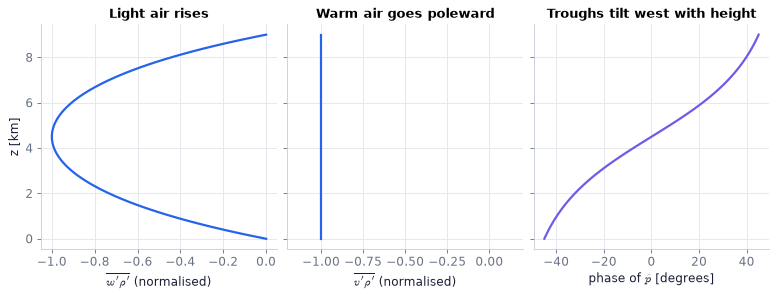

w'rho' <= 0 at every height: True; sign of the heat flux v'T': +1 (poleward); phase difference between the lids: 90.0 degrees


In [184]:
z_e = np.linspace(0.0, H_a, 121)                               # heights between the lids [m]
fl = GFD.eady_fluxes(z_e, fast["alphaH"], U0_a, H_a, N_a, f35, 1.2)   # wave-averaged fluxes of the fastest mode (unit pressure amplitude)
md = GFD.eady_mode(z_e, fast["alphaH"], U0_a, H_a)             # its vertical structure: amplitude and phase of p-hat
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.6), sharey=True)   # a new figure and its panel(s); figsize in inches
axes[0].plot(fl["w_rho"]/abs(fl["w_rho"]).max(), z_e/1e3, color=COLORS["blue"])   # mean of w' rho' (normalised)
axes[0].set(xlabel=r"$\overline{w'\rho'}$ (normalised)", ylabel="z [km]", title="Light air rises")   # axis labels (with units), title and fixed ranges of this panel
axes[1].plot(fl["v_rho"]/abs(fl["v_rho"]).max(), z_e/1e3, color=COLORS["blue"])   # mean of v' rho' (normalised)
axes[1].set(xlabel=r"$\overline{v'\rho'}$ (normalised)", title="Warm air goes poleward", xlim=(-1.2, 0.2))   # axis labels (with units), title and fixed ranges of this panel
axes[2].plot(np.degrees(md["phase"]), z_e/1e3, color=COLORS["accent"])            # phase of the pressure wave against height
axes[2].set(xlabel="phase of $\\hat p$ [degrees]", title="Troughs tilt west with height")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure
print(f"w'rho' <= 0 at every height: {bool((fl['w_rho'] <= 1e-12*abs(fl['w_rho']).max()).all())}; sign of the heat flux v'T': {fl['v_T_sign']:+.0f} (poleward); phase difference between the lids: {np.degrees(fl['phase_tilt']):.1f} degrees")   # the three signatures

**What you see.** For the fastest-growing mode: the vertical density flux, the northward density flux, and the phase of the pressure wave, each against height.

**How to read it.** The vertical flux is negative everywhere inside the layer (light fluid up, heavy fluid down — potential energy is released); the northward density flux is negative (light, warm air poleward); and the phase increases with height: the troughs lean westward by a quarter wavelength between the lids.

**What would change if…** …the wave were shorter than the cut-off? No tilt, no fluxes, no growth: two edge waves that do not feel each other.

In [185]:
nfr = 30 if FAST else 36                                       # number of frames
k_f = fast["alphaH"]/Lam_E                                     # wavenumber of the fastest mode [rad/m]
c_f = GFD.eady_phase_speed(fast["alphaH"], U0_a)               # its complex phase speed [m/s]
x_e = np.linspace(0.0, 2*2*np.pi/k_f, 120)                     # two wavelengths in x [m]
t_an = np.linspace(0.0, 3*t_e, nfr)                            # three e-folding times [s]
p_hat = md["p_hat"][:, None]                                   # complex vertical structure p-hat(z)
fig, ax = plt.subplots(figsize=(6.8, 3.4))   # a new figure and its panel(s); figsize in inches
im = ax.imshow(np.zeros((len(z_e), len(x_e))), origin="lower", aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1,
               extent=[0, x_e[-1]/1e3, 0, H_a/1e3])            # the pressure perturbation in a longitude-height section
ax.set(xlabel="x east [km]", ylabel="z [km]")   # axis labels (with units), title and fixed ranges of this panel
fig.colorbar(im, label="p' (renormalised each e-folding)")   # the colour scale and what it measures

fig.canvas.draw(); fig.set_layout_engine("none")              # lay the figure out once, then freeze it: frames render much faster

def update(i):                                                 # frame i: the growing, travelling wave at time t_an[i]
    grow = np.exp((k_f*c_f.imag*t_an[i]) % 1.0)/np.e           # amplitude e^(sigma t), reset after every e-folding
    field = np.real(p_hat*np.exp(1j*k_f*(x_e[None, :] - c_f.real*t_an[i])))*grow   # Re[p-hat exp(ik(x - c_r t))] e^(sigma t)
    im.set_data(field)                                         # new picture
    ax.set_title(f"fastest Eady mode: t = {t_an[i]/86400:.2f} days = {t_an[i]/t_e:.2f} e-folding times (basic wind → 0 to {U0_a:.0f} m/s, bottom to top)", fontsize=8)   # label / range / scale of this axis
    return (im,)   # hand the result back to the caller

show_animation(animate(update, frames=nfr, fig=fig, interval=100), player="video", dpi=50)   # a smooth video
plt.close(fig)                                                 # do not show the last frame a second time
plt.show()   # display the figure

**What does the code above do?**

The pressure perturbation of the fastest-growing mode, $\mathrm{Re}\,[\hat p(z)e^{ik(x-ct)}]$, in a longitude–height section over
three e-folding times. The amplitude is reset after each e-folding (otherwise it would leave the colour scale); the title is
the clock.

**What you see.** Highs (red) and lows (blue) that lean westward with height, travel east at half the upper-lid wind, and brighten (grow) until the amplitude is reset.

**How to read it.** The westward tilt is the signature of a growing baroclinic wave: it puts poleward flow where the air is warm. The pattern moves at $U_0/2$ — the wind at mid-level, the "steering level".

**What would change if…** …$\alpha H=3$ (a wave shorter than the cut-off)? No tilt and no growth: two separate edge waves passing each other.

#### 🎮 Interactive: Where do storms come from?

**Why interactive rather than a static figure:** sliding the wavenumber through the cut-off turns a growing, westward-tilting mode into two separate neutral edge waves; changing the shear, the stratification or the latitude rescales the growth curve and prints the e-folding time in days and the preferred wavelength in kilometres.

Start with the **Walkthrough**; the **Explain** tab works every number out with your settings, and the **Derivation** tab steps through the same derivation as above.

**What to try:**
- Use the preset 'fastest-growing wave' and read the e-folding time.
- Drag the wavelength shorter until the status changes to 'two neutral edge waves'.
- Double N: what happens to the growth rate and to the preferred wavelength?
- Switch to the ocean mode: mesoscale eddies instead of weather systems.

In [186]:
show_viz("ch13", "eady_instability")   # full-width explainer; ⤢ Full screen for more room

[explainer ch13/eady_instability]

**What would change if…** …the growing eddies become strong enough to interact with each other? Then we are in turbulence — but of an unusual, nearly
two-dimensional kind (`C17`).

---

## 13.18 Geostrophic Turbulence

**What is this section about?** What turbulence does when rotation and stratification keep it nearly two-dimensional. Chapter
12's cascade runs backwards: energy moves to *larger* scales. ⚠️ In this section $\alpha$ is the enstrophy flux, $\eta$ (once)
the Kolmogorov length, $l$ an eddy size.

### 🧩 Fjørtoft's argument: with $S_0=S_1+S_2$ and $K_0^2S_0=K_1^2S_1+K_2^2S_2$, $\dfrac{S_1}{S_2}=\dfrac{K_2-K_0}{K_0-K_1}\,\dfrac{K_2+K_0}{K_1+K_0}$ and $\dfrac{K_1^2S_1}{K_2^2S_2}=\dfrac{K_1^2}{K_2^2}\,\dfrac{K_2^2-K_0^2}{K_0^2-K_1^2}$ (13.145) `C17`

*The question:* Why do the eddies of the atmosphere and ocean merge into bigger eddies and jets instead of breaking down into smaller ones?

#### The problem in plain words

Stir a cup of coffee and the swirls break into smaller swirls until viscosity erases them (Ch. 12). Jupiter's atmosphere does
the opposite: small storms merge into large ones and into bands that have lasted centuries. So do ocean eddies. The difference
is one extra conservation law. In flat, two-dimensional flow a vortex cannot be stretched, so the total squared vorticity —
the enstrophy — is conserved along with the energy. Two conserved quantities are too many for a simple downhill cascade.

#### The idea

A see-saw: energy and enstrophy sit on the same wavenumbers, but enstrophy weighs them by $K^2$. Move some energy to higher
$K$ and the enstrophy goes up; to keep it fixed you must move *more* energy to lower $K$.

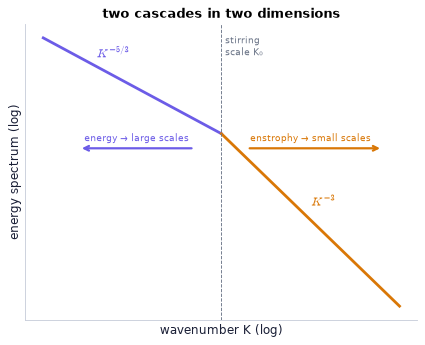

In [187]:
figA = draw_cascade_arrows()                                   # our sketch: energy to small wavenumbers, enstrophy to large ones
plt.show()   # display the figure

**What you see.** A sketch of the energy spectrum against wavenumber (both logarithmic) with the stirring scale $K_0$ in the middle: the energy arrow points to small wavenumbers (large eddies), the enstrophy arrow to large wavenumbers (small eddies). The two slopes written on the branches are explained in `D29` below.

**How to read it.** The two conserved quantities leave the injection scale in opposite directions — the opposite of Chapter 12's three-dimensional cascade, where energy goes to small scales.

**What would change if…** …the flow could stretch vortices (three dimensions)? Enstrophy would no longer be conserved and the energy would be free to go downscale.

> 🔁 **Recap — Where the energy finally goes `R31`** (Ch. 12 §12.7 (C07–C08)). Energy must still reach the Kolmogorov scale to be dissipated; three-dimensional turbulence does that through the cascade with
spectrum $S_{11}=C_1\bar\varepsilon^{2/3}k_1^{-5/3}$ (12.54, in its corrected form). Internal waves are a suggested route from the
large eddies to it.

> 📎 **Primer — enstrophy: mean-square vorticity, and its spectrum K²S(K).** `P333` · Enstrophy is to vorticity what kinetic energy is to velocity: its mean square. A Fourier mode of wavenumber $K$ with velocity
amplitude $\hat u$ has vorticity amplitude $K\hat u$ (a derivative multiplies by $K$), so its share of the enstrophy is $K^2$
times its share of the energy.

In [188]:
K = np.array([1.0, 2.0, 4.0]); S = np.array([4.0, 2.0, 1.0])   # energy in three modes
print("energy =", S.sum(), "; enstrophy =", (K**2*S).sum(), "; enstrophy per mode:", K**2*S)   # 7; 28, most of it in the SMALLEST scale

energy = 7.0 ; enstrophy = 28.0 ; enstrophy per mode: [ 4.  8. 16.]


📝 **Note.** **N164 [B]** **Geostrophic turbulence** is nearly two-dimensional (rotation, stratification and thinness suppress $w$) and has no vortex
stretching. With isotropic spectra, $\overline{u^2}=\displaystyle\int_0^\infty S(K)\,dK$ and
$\overline{\zeta^2}=\displaystyle\int_0^\infty K^2S(K)\,dK$ (`GFD.enstrophy_spectrum(K, S)` is $K^2S$).

> ⚠️ **Common confusion (trap T16):** This $S$ is one-sided in $K$ with no factor ½; Chapter 12's spectra were two-sided, with $\int S$ equal to the variance of one
velocity component.

📝 **Note.** **N165 [B]** **Two conservation statements** (inviscid, two-dimensional): $\dfrac d{dt}\displaystyle\int_0^\infty S(K)\,dK=0$ and
$\dfrac d{dt}\displaystyle\int_0^\infty K^2S(K)\,dK=0$ (13.143)–(13.144) (`SW.barotropic_invariants(zeta, L)` returns both integrals
for a vorticity field).

#### 🧮 Derivation — Fjørtoft's ratios `D28` ★ (Eq. 13.145: $\frac{S_1}{S_2}=\frac{K_2-K_0}{K_0-K_1}\,\frac{K_2+K_0}{K_1+K_0},\ \ \frac{K_1^2S_1}{K_2^2S_2}=\frac{K_1^2}{K_2^2}\,\frac{K_2^2-K_0^2}{K_0^2-K_1^2}$)

**What we want to show.** If nonlinear interactions move the energy at one wavenumber to one smaller and one larger wavenumber while conserving both energy and enstrophy, find how it is shared.

**Assumptions.** All the energy goes to exactly two wavenumbers; inviscid; two-dimensional.

**The plan.**

1. Treat the two sums as two linear equations for S₁ and S₂.
2. Eliminate one unknown.
3. Form the ratios.

**Tools we use** (each explained before this point): two linear equations in two unknowns (P57, reminder) · difference of two squares

**We start from**

$$ \begin{array}{l}S_0=S_1+S_2\ \text{and}\ K_0^2S_0=K_1^2S_1+K_2^2S_2\ \text{with}\ K_1<K_0<K_2\ \text{— "energy conserved; enstrophy (K² × energy)} \\ \text{conserved", the three-mode form of}\ \dfrac d{dt}\displaystyle\int_0^\infty S(K)\,dK=0\ \text{and}\ \dfrac d{dt}\displaystyle\int_0^\infty K^2S(K)\,dK=0 \\ \text{(13.143)–(13.144).}\end{array} $$

*In words:* Energy and enstrophy are both conserved while energy moves between three wavenumbers

---

**Step 1 of 5 — Write the two constraints as a system.**

$$ S_1+S_2=S_0,\qquad K_1^2S_1+K_2^2S_2=K_0^2S_0 $$

- *Why we can do this:* S₀ and the three wavenumbers are given; S₁ and S₂ are the unknowns. Two equations, two unknowns: no freedom is left.
- *In words:* The split is completely determined by the two conservation laws.

---

**Step 2 of 5 — Eliminate S₁.**

$$ \big(K_2^2-K_1^2\big)S_2=\big(K_0^2-K_1^2\big)S_0 $$

- *Why we can do this:* Multiply the first equation by K₁² and subtract it from the second.
- *In words:* The share that goes to the small scale.

---

**Step 3 of 5 — Eliminate S₂.**

$$ \big(K_2^2-K_1^2\big)S_1=\big(K_2^2-K_0^2\big)S_0 $$

- *Why we can do this:* Multiply the first by K₂² and subtract the second.
- *In words:* The share that goes to the large scale.

---

**Step 4 of 5 — Divide.**

$$ \dfrac{S_1}{S_2}=\dfrac{K_2^2-K_0^2}{K_0^2-K_1^2}=\dfrac{K_2-K_0}{K_0-K_1}\,\dfrac{K_2+K_0}{K_1+K_0}\ \text{(13.145), first member} $$

- *Why we can do this:* Step 3 over step 2; then factor each difference of squares.
- *In words:* The energy ratio is larger than the ratio of the wavenumber gaps, because K₂ + K₀ > K₁ + K₀.

---

**Step 5 of 5 — Multiply by K₁²/K₂².**

$$ \dfrac{K_1^2S_1}{K_2^2S_2}=\dfrac{K_1^2}{K_2^2}\,\dfrac{K_2^2-K_0^2}{K_0^2-K_1^2}\ \text{(13.145), second member} $$

- *Why we can do this:* The enstrophy at a wavenumber is K² times its energy.
- *In words:* The enstrophy ratio: for comparable gaps it is smaller than 1.

---

**Result**

$$ \dfrac{S_1}{S_2}=\dfrac{K_2-K_0}{K_0-K_1}\,\dfrac{K_2+K_0}{K_1+K_0}\ \text{and}\ \dfrac{K_1^2S_1}{K_2^2S_2}=\dfrac{K_1^2}{K_2^2}\,\dfrac{K_2^2-K_0^2}{K_0^2-K_1^2} $$

*In words:* More energy to the larger scale, more enstrophy to the smaller

**What it means.** In nearly two-dimensional (geostrophic) turbulence energy cascades to large scales and enstrophy to small scales — the reverse of Chapter 12's three-dimensional cascade; eddies merge and grow. **Fails when:** the flow is three-dimensional (vortex stretching destroys enstrophy conservation) or strongly dissipative.

**Check it.** Units — both ratios are pure numbers ✓. Number — K₁ = K₀/3, K₂ = 3K₀/2: S₁/S₂ = 1.40625, enstrophy ratio 0.06944; S₁ = 0.5844 S₀, S₂ = 0.4156 S₀. Limit — K₁ → K₀: all the energy stays at K₀ (S₂ → 0). Code — `np.linalg.solve`.

> ⚠️ **Common confusion (traps in `D28`):** All the energy is assumed to go to just two wavenumbers; the second ratio is the inverse statement, not an independent one; the spectrum here is one-sided with no factor ½ (trap T16).

#### ✏️ Tiny example: where the energy of wavenumber 6 goes

Energy $S_0=1$ at $K_0=6$ is moved to $K_1=2$ and $K_2=9$ ($K_1=K_0/3$, $K_2=3K_0/2$).

1. Energy: $S_1+S_2=1$.
2. Enstrophy: $4S_1+81S_2=36$.
3. Subtract 4 × (1) from (2): $77S_2=32$ → $S_2=0.416$, $S_1=0.584$.
4. Energy ratio $S_1/S_2=1.41$: more energy went to the **larger** scale.
5. Enstrophy shares: $4\times0.584=2.34$ against $81\times0.416=33.66$, ratio 0.069: fourteen times more enstrophy went to the
   **smaller** scale.
6. Formula check: $\frac{K_2-K_0}{K_0-K_1}\frac{K_2+K_0}{K_1+K_0}=(3/4)(15/8)=1.406$ ✓.

In [189]:
r_f = GFD.fjortoft_transfer(1.0, 1/3, 1.5)                     # Eq. (13.145): energy at K0 = 1 shared between K1 = 1/3 and K2 = 3/2
print(f"S1 = {r_f['S1']:.4f}, S2 = {r_f['S2']:.4f}; energy ratio S1/S2 = {r_f['energy_ratio']:.5f}; enstrophy ratio = {r_f['enstrophy_ratio']:.5f} (= 1/{1/r_f['enstrophy_ratio']:.1f})")   # the triad of the worked example
for K2 in (1.2, 1.5, 2.0, 4.0):                                # move the small-scale partner further out
    rr = GFD.fjortoft_transfer(1.0, 1/3, K2)                   # same K1
    print(f"K2/K0 = {K2}: energy to large scale {100*rr['S1']:.0f} %, enstrophy to small scale {100/(1 + rr['enstrophy_ratio']):.0f} %")   # the two shares
print("enstrophy spectrum K^2 S of the primer's three modes:", GFD.enstrophy_spectrum(np.array([1.0, 2.0, 4.0]), np.array([4.0, 2.0, 1.0])))   # K^2 S

S1 = 0.5844, S2 = 0.4156; energy ratio S1/S2 = 1.40625; enstrophy ratio = 0.06944 (= 1/14.4)
K2/K0 = 1.2: energy to large scale 33 %, enstrophy to small scale 96 %
K2/K0 = 1.5: energy to large scale 58 %, enstrophy to small scale 94 %
K2/K0 = 2.0: energy to large scale 77 %, enstrophy to small scale 91 %
K2/K0 = 4.0: energy to large scale 94 %, enstrophy to small scale 90 %
enstrophy spectrum K^2 S of the primer's three modes: [ 4.  8. 16.]


**What does the code above do?**

1. `GFD.fjortoft_transfer(K0, K1, K2)` solves the two conservation equations for the shares $S_1$, $S_2$.
2. For the triad of the worked example, 58 % of the energy goes to the larger scale and 94 % of the enstrophy to the smaller.
3. The further out the small-scale partner, the larger the share of the energy that goes up-scale (from a third to more than
   nine tenths in the sweep); the enstrophy goes mostly down-scale in every case (90 % or more).

In [190]:
# From scratch: two equations, two unknowns
K0, K1, K2, S0 = 1.0, 1/3, 1.5, 1.0                            # the triad and the energy to be shared
A_f = np.array([[1.0, 1.0], [K1**2, K2**2]])                   # rows: energy conservation, enstrophy conservation
S1, S2 = np.linalg.solve(A_f, [S0, K0**2*S0])                  # the two shares
assert np.allclose([S1, S2], [r_f["S1"], r_f["S2"]])           # same as the library
print(f"✓ S1 = {S1:.4f}, S2 = {S2:.4f} from a 2 x 2 linear solve — the same as GFD.fjortoft_transfer")   # visible confirmation

✓ S1 = 0.5844, S2 = 0.4156 from a 2 x 2 linear solve — the same as GFD.fjortoft_transfer


**What does the code above do?**

Fjørtoft's argument is nothing more than two linear equations in two unknowns.

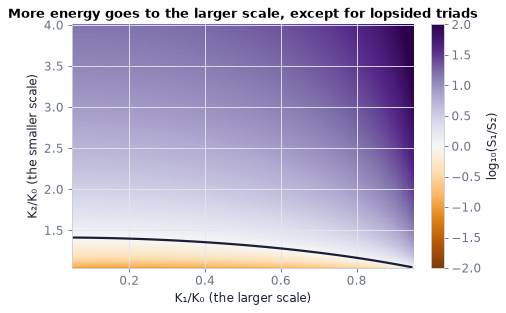

fraction of this triad plane with S1 > S2: 92 %


In [191]:
k1 = np.linspace(0.05, 0.95, 200); k2 = np.linspace(1.05, 4.0, 200)   # K1/K0 below 1 and K2/K0 above 1
K1g, K2g = np.meshgrid(k1, k2)                                 # all triads
ratio = (K2g - 1)/(1 - K1g)*(K2g + 1)/(K1g + 1)                # Eq. (13.145), first member: S1/S2 with K0 = 1
fig, ax = plt.subplots(figsize=(6.0, 3.8))   # a new figure and its panel(s); figsize in inches
pm = ax.pcolormesh(k1, k2, np.log10(ratio), cmap="PuOr", vmin=-2, vmax=2, shading="auto")   # log10 of the energy ratio
ax.contour(k1, k2, ratio, [1.0], colors=COLORS["ink"])         # the line S1 = S2
fig.colorbar(pm, label="log₁₀(S₁/S₂)")   # the colour scale and what it measures
ax.set(xlabel="K₁/K₀ (the larger scale)", ylabel="K₂/K₀ (the smaller scale)", title="More energy goes to the larger scale, except for lopsided triads")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure
print(f"fraction of this triad plane with S1 > S2: {100*(ratio > 1).mean():.0f} %")   # how common up-scale transfer is

**What you see.** The energy ratio $S_1/S_2$ for every triad: purple where more energy goes to the larger scale, orange where more goes to the smaller; the black line is $S_1=S_2$.

**How to read it.** Over most of the plane the ratio exceeds 1. It falls below 1 only when the large-scale partner is very far from $K_0$ and the small-scale partner very near — and even then the *enstrophy* still goes mostly to the small scale.

**What would change if…** …a triad symmetric in wavenumber, $K_0-K_1=K_2-K_0$? The ratio is $(K_2+K_0)/(K_1+K_0)>1$: always up-scale.

#### 🧮 Derivation — The enstrophy spectrum K²S(K), the −3 range and the Rhines length `D29` ★★

**What we want to show.** Justify three statements the book makes in passing: that enstrophy is distributed as K²S(K); that the enstrophy-cascading range has a spectrum proportional to K⁻³; and that eddies stop growing at a length √(u/β). All three are presented as **ours, computed** — no citation.

**Assumptions.** Isotropic, two-dimensional, non-divergent; an inertial range in which only one flux matters.

**The plan.**

1. Get the K² weighting from the vorticity of one Fourier mode.
2. List the dimensions.
3. Find the exponents of each inertial range by dimensional analysis.
4. Compare two terms of the vorticity equation for the Rhines length.

**Tools we use** (each explained before this point): derivative of a Fourier mode (P142, reminder) · the Π theorem (Ch. 1, reminder) · dominant balance (P198, reminder) · enstrophy (P333)

**We start from**

$$ \begin{array}{l}\overline{u^2}=\displaystyle\int_0^\infty S(K)\,dK\ \text{and}\ \overline{\zeta^2}=\displaystyle\int_0^\infty K^2S(K)\,dK\ \text{(the book's definitions in §13.18),} \\ \text{and the barotropic vorticity equation}\ \Big(\dfrac{\partial}{\partial t}+\mathbf u\cdot\nabla\Big)(\zeta+f)=0\ \text{(13.122).}\end{array} $$

---

**Step 1 of 7 — Take the vorticity of one Fourier mode.**

$$ (u,v)=(\hat u,\hat v)\,e^{i(kx+ly)}\ \Rightarrow\ \hat\zeta=i\big(k\hat v-l\hat u\big) $$

- *Why we can do this:* By definition $\zeta=\partial v/\partial x-\partial u/\partial y$, and each derivative of a Fourier mode is a multiplication by ik or il.
- *In words:* In wavenumber space taking a curl is algebra.

---

**Step 2 of 7 — Use non-divergence.**

$$ k\hat u+l\hat v=0\ \Rightarrow\ \lvert\hat\zeta\rvert^2=\big(k^2+l^2\big)\big(\lvert\hat u\rvert^2+\lvert\hat v\rvert^2\big)=K^2\big(\lvert\hat u\rvert^2+\lvert\hat v\rvert^2\big) $$

- *Why we can do this:* A non-divergent velocity is perpendicular to its wavevector, so the cross product in step 1 has the full length K times the speed.
- *In words:* Each mode's enstrophy is K² times its energy: the enstrophy spectrum is K²S(K).

---

**Step 3 of 7 — List the dimensions.**

$$ [S]=\mathrm{m^3\,s^{-2}},\quad[K]=\mathrm{m^{-1}},\quad[\varepsilon]=\mathrm{m^2\,s^{-3}},\quad[\alpha]=\mathrm{s^{-3}} $$

- *Why we can do this:* S dK is a velocity squared; ε is energy per mass per time; α (the enstrophy flux in this section) is vorticity squared per time.
- *In words:* The enstrophy flux contains no length at all.

---

**Step 4 of 7 — Find the exponents of the enstrophy range.**

$$ S=C_Z\,\alpha^a K^b:\quad-2=-3a,\quad3=-b\ \Rightarrow\ S\propto\alpha^{2/3}K^{-3} $$

- *Why we can do this:* If the spectrum there depends only on α and K, both sides must have the same powers of seconds and metres (one dimensionless group).
- *In words:* Toward small scales the spectrum falls as K⁻³.

---

**Step 5 of 7 — Do the same for the energy range.**

$$ S=C_E\,\varepsilon^a K^b:\quad-2=-3a,\quad3=2a-b\ \Rightarrow\ S\propto\varepsilon^{2/3}K^{-5/3} $$

- *Why we can do this:* The same argument with ε in place of α; it is Kolmogorov's argument of Chapter 12, although here the energy flux is toward large scales.
- *In words:* Toward large scales the spectrum has the familiar −5/3 slope.

---

**Step 6 of 7 — Compare two terms of the vorticity equation.**

$$ \mathbf u\cdot\nabla\zeta\sim\dfrac{u^2}{l^2},\qquad\beta v\sim\beta u $$

- *Why we can do this:* For eddies of speed u and size l, ζ ~ u/l and its gradient ~ u/l²; the term βv comes from $\mathbf u\cdot\nabla f=\beta v$.
- *In words:* Eddies advect each other's vorticity; β makes them radiate Rossby waves.

---

**Step 7 of 7 — Equate them.**

$$ \dfrac{u^2}{l^2}=\beta u\ \Rightarrow\ l\sim\sqrt{\dfrac u\beta} $$

- *Why we can do this:* Small eddies are dominated by advection (turbulence), large ones by β (waves); the crossover is where the two terms are equal.
- *In words:* The inverse cascade stalls at this size, and the flow organises into east–west jets of about this width.

---

**Result**

$$ \begin{array}{l}\text{enstrophy spectrum}\ K^2S(K)\ \text{;}\ S\propto\alpha^{2/3}K^{-3}\ \text{in the enstrophy range and}\ S\propto\varepsilon^{2/3}K^{-5/3}\ \text{in} \\ \text{the energy range;}\ l\sim\sqrt{u/\beta}\end{array} $$

*In words:* Two inertial ranges and a stopping scale

**What it means.** Energy injected at the scale of baroclinic eddies moves up-scale until β turns eddies into waves: the alternating jets of the giant planets and of the ocean are of this width. **Fails when:** there is no clean inertial range (our 64² demo has none: the K⁻³ range is not resolved there and no slope is quoted from it), or dissipation and forcing overlap the range.

**Check it.** Units — $\alpha^{2/3}K^{-3}$ = s⁻² m³ ✓; $\varepsilon^{2/3}K^{-5/3}$ = m^(4/3) s⁻² m^(5/3) = m³ s⁻² ✓; √(u/β) = √((m/s)(m s)) = m ✓. Code — `DIM.pi_groups` returns exponents (2/3, −3). Number — 35° N: √(u/β) = 833 km for u = 13 m/s and 65 km for u = 0.08 m/s.

> ⚠️ **Common confusion (traps in `D29`):** The letter α is the enstrophy flux [s⁻³] in this section (trap T13); the exponents are exact rationals from the Π theorem, the constants C_E, C_Z are not given by it; nothing here is a benchmark — it is dimensional reasoning.

📝 **Note.** **N166 [B]** **Two inertial ranges** (ours, computed by the dimensional argument of `D29`; no source is cited): $S(K)\propto\varepsilon^{2/3}K^{-5/3}$
where an energy flux $\varepsilon$ passes toward small $K$, and $S(K)\propto\alpha^{2/3}K^{-3}$ where an enstrophy flux $\alpha$ passes
toward large $K$. The exponents follow from units alone, as in Chapter 1's Π theorem.

📝 **Note.** **N167 [B]** **Where the up-scale transfer stops** (ours, by the scale argument of `D29`): at the length $l\sim\sqrt{u/\beta}$ where an eddy's
turnover rate matches the Rossby-wave frequency; beyond it the motion is wave-like and elongates into zonal jets
(`GFD.rhines_length`).

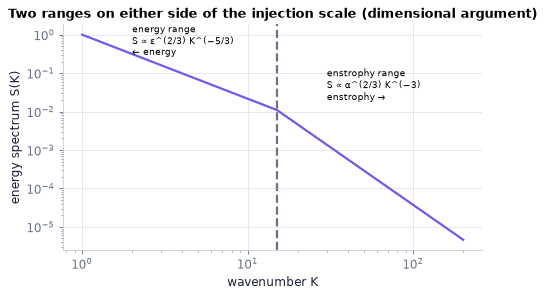

stopping length sqrt(u/beta) at 35 N: atmosphere 833 km, ocean 65 km
dimensional check: eps^a K^b has the units of S (m^3 s^-2) for a = 0.6667, b = -1.6667


In [192]:
K_ax = np.geomspace(1.0, 200.0, 200)                           # wavenumbers (arbitrary units)
S_ax = GFD.two_d_cascade_spectrum(K_ax, 15.0, 1.0, 15.0**2)    # the two power laws, joined at the injection wavenumber K0 = 15 (shape only)
fig, ax = plt.subplots(figsize=(6.0, 3.6))   # a new figure and its panel(s); figsize in inches
ax.loglog(K_ax, S_ax, color=COLORS["accent"])                  # the spectrum
ax.axvline(15.0, color=COLORS["muted"], ls="--")               # the injection scale
ax.text(2.0, S_ax[0]*0.3, "energy range\nS ∝ ε^(2/3) K^(−5/3)\n← energy", fontsize=8)        # left range
ax.text(30.0, S_ax[0]*0.02, "enstrophy range\nS ∝ α^(2/3) K^(−3)\nenstrophy →", fontsize=8)  # right range
ax.set(xlabel="wavenumber K", ylabel="energy spectrum S(K)", title="Two ranges on either side of the injection scale (dimensional argument)")   # axis labels (with units), title and fixed ranges of this panel
plt.show()   # display the figure
u_atm, u_oc = inp["u_rms"]                                     # rms eddy speeds: 13 m/s (atmosphere) and 0.08 m/s (ocean), our inputs
print(f"stopping length sqrt(u/beta) at 35 N: atmosphere {GFD.rhines_length(u_atm, beta35)/1e3:.0f} km, ocean {GFD.rhines_length(u_oc, beta35)/1e3:.0f} km")   # where eddies turn into waves and jets
ex = np.linalg.solve(np.array([[2.0, -1.0], [-3.0, 0.0]]), [3.0, -2.0])   # exponents (a, b) of eps^a K^b: metres 2a - b = 3, seconds -3a = -2
print(f"dimensional check: eps^a K^b has the units of S (m^3 s^-2) for a = {ex[0]:.4f}, b = {ex[1]:.4f}")   # 2/3 and -5/3

**What you see.** The shape of the energy spectrum of two-dimensional turbulence forced at one scale (dashed line): a gentler slope on the large-scale side, a steeper one on the small-scale side.

**How to read it.** Energy leaks toward the left, enstrophy toward the right. The exponents come from units alone (last printed line: $\varepsilon$ in m² s⁻³ and $K$ in m⁻¹ combine to m³ s⁻² only as $\varepsilon^{2/3}K^{-5/3}$). The stopping length is several hundred kilometres in the atmosphere and tens in the ocean.

**What would change if…** …$\beta$ were zero? Nothing would stop the growth of the eddies short of the size of the domain.

> 📎 **Primer — the Jacobian J(ψ, ζ) and a pseudo-spectral step with 2/3 de-aliasing.** `P334` · The advection of vorticity by the flow it induces is $\mathbf u\cdot\nabla\zeta=\psi_x\zeta_y-\psi_y\zeta_x\equiv J(\psi,\zeta)$ (subscripts are
derivatives). A pseudo-spectral model takes derivatives in Fourier space (multiply by $ik$ — exact), multiplies fields on the
grid (cheap), and zeroes the top third of the wavenumbers before each product so that the product's new short waves do not
fold back onto long ones (aliasing). This model is OUR choice; the book describes such calculations only in words.

In [193]:
n = 8; k = np.fft.fftfreq(n, 1/n)                  # integer wavenumbers 0..3, -4..-1
print("kept by the 2/3 rule:", np.abs(k) <= n/3)   # only |k| <= 2 survive

kept by the 2/3 rule: [ True  True  True False False False  True  True]


📝 **Note.** **N168 [B]** **Not in the book — ours; a qualitative demonstration.** Decaying two-dimensional turbulence,
$\dfrac{\partial\zeta}{\partial t}+J(\psi,\zeta)+\beta\dfrac{\partial\psi}{\partial x}=\nu\nabla^2\zeta$ with $\zeta=\nabla^2\psi$, without and with $\beta$.

> 🔧 **Our choice** — **our numerical model, cached**: two pseudo-spectral runs on a 64 × 64 grid (`SW.barotropic_run`, fourth-order Runge–Kutta,
2/3 rule), ten saved frames each, loaded with `ch13.load_reference_run`. At this resolution the steep small-scale range is
**not** resolved: everything said about these runs is qualitative, and no spectral slope is read off them.

In [194]:
runs_t = [ch13.load_reference_run("turbulence_f"), ch13.load_reference_run("turbulence_beta")]   # our two cached runs (beta = 0, beta > 0), or None
if any(r_ is None for r_ in runs_t):                           # a cache is missing
    print("a cached turbulence run is absent — regenerate it with scripts/ch13_make_caches.py; the sketch and the spectrum figure above stand on their own")
else:
    zet = [np.asarray(r_["zeta"], dtype=float) for r_ in runs_t]   # vorticity fields zeta(t, y, x)
    shown = [0, 1, 2, 4, 6, 9]                                 # six of the ten saved times (keeps the page light)
    fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.8))   # a new figure and its panel(s); figsize in inches
    ims = [axes[j].imshow(zet[j][0], origin="lower", cmap="RdBu_r", vmin=-abs(zet[j][0]).max(), vmax=abs(zet[j][0]).max()) for j in (0, 1)]   # the two fields
    for ax, ttl in zip(axes[:2], ("no β", "with β")):
        ax.set_xticks([]); ax.set_yticks([])                   # no tick marks on the pictures
        ax.set_title(ttl, fontsize=9)   # label / range / scale of this axis
    for r_, ls, nm in ((runs_t[0], "-", "no β"), (runs_t[1], "--", "with β")):   # the two invariants against time
        axes[2].plot(r_["t"], r_["energy"]/r_["energy"][0], ls, color=COLORS["accent"], label=f"energy, {nm}")
        axes[2].plot(r_["t"], r_["enstrophy"]/r_["enstrophy"][0], ls, color=COLORS["amber"], label=f"enstrophy, {nm}")
    clock = axes[2].axvline(0, color=COLORS["muted"])          # a moving time marker
    axes[2].set(xlabel="time (model units)", ylabel="fraction of the initial value", title="Enstrophy decays, energy much less")   # axis labels (with units), title and fixed ranges of this panel
    axes[2].legend(fontsize=6)   # the legend names every curve

    fig.canvas.draw(); fig.set_layout_engine("none")              # lay the figure out once, then freeze it: frames render much faster

    def update(n_):                                            # frame n_: the two vorticity fields at the saved time shown[n_]
        i = shown[n_]                                          # index of that saved time
        for j in (0, 1):
            ims[j].set_data(zet[j][i])                         # new field
            ims[j].set_clim(-abs(zet[j][i]).max(), abs(zet[j][i]).max())   # rescale the colours to this frame
        clock.set_xdata([runs_t[0]["t"][i]]*2)                 # move the time marker
        return ims   # hand the result back to the caller

    show_animation(animate(update, frames=len(shown), fig=fig, interval=700), player="frames", dpi=36)   # step with the buttons
    plt.close(fig)                                             # do not show the last frame a second time
    for r_, z_, nm in zip(runs_t, zet, ("no beta", "with beta")):   # the numbers behind the pictures
        E_hat = abs(np.fft.fft2(z_[-1]))**2                    # squared vorticity amplitudes of the last frame …
        kk = 2*np.pi*np.fft.fftfreq(z_.shape[-1], d=float(r_["L"])/z_.shape[-1])   # … and their wavenumbers
        K2 = kk[None, :]**2 + kk[:, None]**2; K2[0, 0] = 1.0   # K^2 on the grid (the mean mode is skipped)
        E_k = E_hat/K2; E_k[0, 0] = 0.0                        # energy per mode = |zeta-hat|^2 / K^2
        print(f"{nm}: energy falls to {r_['energy'][-1]/r_['energy'][0]:.2f}, enstrophy to {r_['enstrophy'][-1]/r_['enstrophy'][0]:.2f} of the start; energy centroid K_E {r_['K_E'][0]:.1f} -> {r_['K_E'][-1]:.1f}; zonal (k_x = 0) share of the energy at the end: {E_k[:, 0].sum()/E_k.sum():.2f}")   # qualitative summary

no beta: energy falls to 0.73, enstrophy to 0.21 of the start; energy centroid K_E 8.6 -> 3.2; zonal (k_x = 0) share of the energy at the end: 0.11
with beta: energy falls to 0.73, enstrophy to 0.22 of the start; energy centroid K_E 8.6 -> 3.6; zonal (k_x = 0) share of the energy at the end: 0.29


**What does the code above do?**

1. The two cached runs are loaded (if a file were missing the cell would say so and stop).
2. The left and middle panels show the vorticity field without and with β; the right panel the energy and the enstrophy as
   fractions of their initial values, with a marker at the time of the frame.
3. `player="frames"` lets you step through six of the ten saved times.
4. The printed lines summarise each run: how much energy and enstrophy are left, where the energy-weighted mean wavenumber
   $K_E$ has moved, and what share of the energy sits in the zonal ($k_x=0$) modes at the end.

**What you see.** Many small vortices merging into a few large ones (left); with β (middle) the pattern stretches east–west into bands. Right: enstrophy drops to about a fifth of its initial value while energy keeps most of its own.

**How to read it.** Qualitatively — and only qualitatively, at 64 × 64 — this is Fjørtoft's argument at work: enstrophy is drained at small scales by the viscosity while the energy survives and moves to larger scales (the centroid $K_E$ falls, printed lines). With β the zonal share of the energy is markedly larger: the beginning of jets.

**What would change if…** …the grid were much finer? The small-scale range would be resolved and its slope could be compared with the dimensional argument of `D29`; we make no such claim from these runs.

*↪ **S01** Exercises 13.1–13.8 are not reproduced. The one result the text relies on — the group velocity of
inertia–gravity waves — is derivation `D21` in `C14`. · **S02** Literature and supplemental reading: see the book's list; this
notebook cites only what was read first-hand.*

**What would change if…** …the fluid is a gas moving so fast that its own compressibility matters, or a wing rather than a planet? Those are Chapters
14 and 15. For climate dynamics, the next steps beyond this book are the equatorial waves named in `C15` and the wind-driven
gyre named in `C05`.

---

## ✅ What should have clicked

- `C01` — On a thin shell only the vertical part of the earth's spin, $f=2\Omega\sin\theta$ *(13.8)*, turns the wind.
- `C02` — Slow flow runs along the isobars because that is the only direction in which Coriolis can cancel the pressure force.
- `C03` — A horizontal temperature gradient sets how the wind changes with height.
- `C04` — Friction against rotation makes a layer of fixed thickness in which the current spirals.
- `C05` — The wind-driven transport is at right angles to the wind and does not depend on the eddy viscosity; its divergence pumps water up or down.
- `C06` — Near the ground friction lets the wind cross isobars toward low pressure: air rises in lows.
- `C07` — Three equations for surface height and two velocities hold all the dynamics of a thin layer.
- `C08` — A stratified ocean is a stack of such layers; the first internal one is about a metre deep.
- `C09` — One cubic: two fast gravity waves and one slow wave that needs β.
- `C10` — Rotation puts a floor $f$ under gravity-wave frequencies and turns currents into ellipses.
- `C11` — A coast replaces the missing cross-shore flow with a slope; the wave runs with the coast on its right ($f>0$).
- `C12` — Beyond a Rossby radius $c/f$ rotation holds a slope up against gravity.
- `C13` — Each column keeps $(\zeta+f)/h$.
- `C14` — Internal waves live between $f$ and $N$; the slope of the crests sets the frequency.
- `C15` — Rossby crests drift west because displaced columns must change their spin; energy goes east for short waves.
- `C16` — Storms grow by sliding fluid along the wedge between level and density surfaces, at a rate $0.30982\,(f/N)\,dU/dz$ (ours, computed).
- `C17` — Two conserved quantities send energy to large scales and enstrophy to small.

**What later chapters build on**

- Ch. 15: the shallow-water ↔ gas-dynamics analogy uses $\sqrt{gH}$ as the "sound speed".
- Climate-dynamics work beyond the book: `fluidpy.core.gfd`, `vertical_modes` and `shallow_water` are importable on their own.

**Not taught here (and where to find it)**
- equatorial waves and the equatorial radius of deformation (any text on equatorial dynamics)
- the wind-driven gyre and western boundary currents (dynamical oceanography texts)
- the moist adiabat and pressure coordinates (dynamic meteorology texts)
- quasi-geostrophic theory in a continuously stratified fluid beyond the Eady problem, and the Charney problem
- observed data figures (replaced here by our own model output)